# Module 3 — From a pattern to a decision, and a model as a service

**Data Mining and Analysis (course code CE3) · Aalborg University, Copenhagen**

Module 3 is three decks and this is one notebook in three parts, in the decks'
order.

| Part | Deck | The question | Laboratory |
|---|---|---|---|
| 3.0 | `Module3.0.pptx` — Beer and diapers | What does a rise in sales need before a cause can be named? | none; the receipts are simulated |
| 3.1 | `Module3.1.pptx` — Deploying a model as a service I | Which version answered, is the request possible, and what does a mistake cost? | Lab 1 — the gate; Lab 2 — the contract; Lab 3 — the threshold |
| 3.2 | `Module3.2.pptx` — Deploying a model as a service II | Does the served model give the trained answer, and in time? | Lab 4 — skew and honest speed |

**How to read it.** Every code cell has a short note above it: the *goal*, *why*
it is done, *what the code does*, and *so what* — what the result lets you say.
Cells that begin `# Source: … verbatim` are copied from the repository's files
— the lab solutions, the machinery they run on, and the deck's own figure
scripts — so the code you read is the code that runs. Cells that draw a figure
name the slide they reproduce. Formulas are written in Python with `sympy` and
displayed as LaTeX. A line `deck … computed …` is a number a slide prints,
recomputed; if the two ever disagree the notebook stops.

**How to run it.** From `Module 3/exercises`, after `bash setup.sh` and
`pip install -r ../notebook/requirements.txt`. It runs in a few minutes; most of
that is MLflow logging a 95-megabyte candidate model.

**Data.** Part 3.0 has no real dataset: its receipts are simulated by
`slides/simulate_receipts.py` (seed 20260927), and every number on its slides
comes from that simulation. Parts 3.1 and 3.2 run on what the labs run on:
phone traces generated by `exercises/data/make_phones.py` from the archive's
measured rates (seed 20200122, 10,800 rows for 22 January), the two forests
`exercises/service/models.py` trains on them, the MLflow store it writes, and
`exercises/data/bus_slice.csv.gz` — shuttle VJRD1A10224000055 on 22 and 23
January 2020, 48,290 readings. No row describes a person.

## Set-up

**Goal.** Load the libraries, and define the small tools every later cell uses.

**Why.** A notebook that claims to reproduce three decks needs a way to show a figure, a formula and a number side by side with what the slide printed.

**What the code does.** `show()` renders a plotly figure to a static PNG embedded in the notebook, so it displays anywhere, including offline; `show_png()` embeds a picture a script saved. `formula()` displays sympy expressions as LaTeX. `agrees()` prints a number the deck states beside the same number computed here and stops the run when they differ; `beside()` prints two numbers that are expected to differ, with the reason. MLflow's download progress bars are switched off, because they print timings that change on every run.

**So what.** If a deck and the code ever disagree, this notebook fails to run rather than quietly showing a different number.

In [1]:
import json
import math
import os
import shutil
import sys
import tempfile
import types
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import sympy as sp
from scipy import stats
from IPython.display import Image, Math, display

warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=UserWarning, module="mlflow")
os.environ["MLFLOW_ENABLE_ARTIFACTS_PROGRESS_BAR"] = "false"
pd.set_option("display.width", 120)

NAVY, GREEN_OK = "#1F2A5A", "#2E8B57"


def show(fig, name, width=1000, height=560):
    """Draw a plotly figure as a static image inside the notebook."""
    fig.update_layout(template="plotly_white", width=width, height=height)
    if fig.layout.margin.t is None:          # unless the figure asked for its own room
        fig.update_layout(margin=dict(l=70, r=30, t=70, b=60))
    display(Image(fig.to_image(format="png", width=width, height=height, scale=1)))


def show_png(path):
    """Embed a picture a script saved to disk."""
    display(Image(filename=str(path)))


def formula(*parts):
    """Display sympy expressions (or LaTeX strings) side by side."""
    pieces = [p if isinstance(p, str) else sp.latex(p, order="none") for p in parts]
    display(Math(r"\qquad ".join(pieces)))


def agrees(what, computed, stated, places):
    """A number the deck states, recomputed here. Stops the run on a mismatch."""
    mine = round(float(computed), places)
    if abs(mine - float(stated)) > 0.5 * 10 ** -places + 1e-12:
        raise AssertionError(f"{what}: the deck says {stated}, the code gives {mine}")
    print(f"  {what:<66} deck {stated:<10} computed {int(mine) if places == 0 else mine}")


DIFFERENCES = []   # every beside() call, gathered for the closing table


def beside(what, computed, stated, why):
    """Two numbers that are expected to differ, printed with the reason."""
    DIFFERENCES.append((what, str(computed), str(stated), why))
    print(f"  {what}: computed here {computed}, stated {stated} — {why}")

### A working copy of the exercises

The labs write: a registry file, a local MLflow store, figures under `out/`.
A notebook that ran the solutions inside `exercises/` would overwrite whatever a
student has there. So the first thing it does is copy the exercises folder —
the sources only — to a temporary directory and move into it.

**Goal.** Work in a copy of `exercises/`, never in the student's folder.

**Why.** Lab 1 moves a registry pointer and logs runs to MLflow; Lab 4 reads the store; the solutions write under `out/`. None of that may touch a student's own files.

**What the code does.** Copies the folder without anything a run generates (the Parquet tables, the hand-off, the trained artefacts, the MLflow store, `out/`), then changes the working directory to the copy. Every path the labs use is relative to `exercises/`, so the verbatim code below works unchanged; the generated files are rebuilt from nothing further down, exactly as `setup.sh` builds them.

**So what.** Every number below comes from a store this notebook built itself, the same on every run, and your `exercises/` is exactly as you left it.

In [2]:
SOURCE = Path.cwd()
assert (SOURCE / "lab_support.py").exists(), "run this notebook from Module 3/exercises"
SLIDES = SOURCE.parent / "slides"                 # read only: the decks' recorded numbers
COURSE = SOURCE.parent.parent                     # read only: Modules 1 and 2's measured.json
GENERATED = shutil.ignore_patterns(
    "out", "landing", "mlruns.db", "mlartifacts", "__pycache__", "*.parquet", "handoff",
    "MANIFEST.json", "artefacts", "timing.json", "DATA_PROFILE.md", ".your_attempt")
WORK = Path(tempfile.mkdtemp(prefix="module3_notebook_")) / "exercises"
shutil.copytree(SOURCE, WORK, ignore=GENERATED)
os.chdir(WORK)
print("working in a temporary copy of exercises/, which holds:",
      ", ".join(sorted(p.name for p in WORK.iterdir() if not p.name.startswith("."))))

working in a temporary copy of exercises/, which holds: Makefile, READING.md, README.md, _narrate.py, apply.py, concepts.json, constraints.txt, data, lab_support.py, labs, requirements.txt, service, setup.sh, solutions, verify


**Goal.** Let verbatim code that imports the course's own files find this notebook's definitions instead.

**Why.** The lab files import each other (`from service.models import …` inside `lab_support.py`, `from _narrate import …` inside each solution's demonstration). This notebook imports none of them: it defines them in its own cells.

**What the code does.** `as_module()` wraps names already defined here as a module and registers it, so that an `import` inside verbatim code returns the notebook's objects.

**So what.** The code you read in a cell is the code that runs, even when a file imports another file.

In [3]:
def as_module(name, names):
    """Register the notebook's own definitions of `names` as the module `name`."""
    module = types.ModuleType(name)
    for attribute in names:
        setattr(module, attribute, globals()[attribute])
    sys.modules[name] = module
    if "." in name:
        parent, _, child = name.rpartition(".")
        package = sys.modules.get(parent) or types.ModuleType(parent)
        package.__path__ = []
        setattr(package, child, module)
        sys.modules[parent] = package
    return module

---
# Part 3.0 — Beer and diapers: from a story to a decision

*Deck: `Module3.0.pptx`. Slides: "Beer and diapers — from a story to a decision",
the aims, and "What you need already, and three beliefs to drop".*

The session connects Modules 1 and 2 to a question outside any pipeline: a pattern
in receipts is not yet a decision. It works backwards from a sales curve to the
data, the model and the test, and ends with a definition of data mining and data
science. Three beliefs are dropped on the way: that items bought together are bought
because of each other — they may only share a purchase cycle, such as the weekly
shop (Manchanda, Ansari & Gupta, 1999); that a pattern true in every group is true in the whole
(Simpson, 1951); and that averaging over windows makes data normal — it does so only
when the windows are alike.

**The story and the finding** (*slide: "The story is a legend; the documented finding
is a time-of-day pattern"*). The legend says a shop moved beer beside diapers and
sales rose; no record of that exists. What is documented is a 1992 Teradata analysis
of 1.2 million Osco Drug receipts, in which beer and diapers were bought together
more often between 17:00 and 19:00; the products were not moved, so no sales effect
was ever measured (Power, 2002). No link with age or sex was reported (Whitehorn, 2006).

**The data of this part.** There is no real dataset for this case, so the deck
simulates one year of till receipts, and every number and figure of Module 3.0
comes from that simulation. The notebook runs the same simulation, with the same
seed, and recomputes every number from it.

### One year of simulated receipts

**Goal.** Simulate the year of receipts every 3.0 slide is drawn from.

**Why.** A causal argument needs to know the truth it is arguing about. A simulation states it: four shopper groups (man or woman, baby at home or not), each with a chance of buying beer and a chance of buying diapers given beer; a card that parents hold more often; a summer peak for beer; an evening boost for parents at 17 and 18 h. The receipt records none of the groups — only card holders are known.

**What the code does.** Runs `slides/simulate_receipts.py` verbatim: 365 days, a footfall per day drawn from a gamma law (weekdays about 1,500 receipts, weekends about 2,400), and one row per receipt with the hour, the day type, the card holder's segment if there is a card, and whether beer and diapers were bought. It writes the receipts to `receipts.csv.gz` in the working copy.

**So what.** About 630,000 receipts. By construction, beer and diapers go together inside every group and apart in the whole — Simpson's paradox, planted so it can be found.

In [4]:
# Source: Module 3/slides/simulate_receipts.py — lines 19–76, verbatim
# References: (Simpson, 1951; Power, 2002)

import json
import gzip
import numpy as np
import pandas as pd

SEED = 20260927
rng = np.random.default_rng(SEED)

DAYS = 365
HOURS = list(range(8, 22))          # shop open 08:00 to 21:59
SEGMENTS = ["man, no baby", "woman, no baby", "man, baby", "woman, baby"]
SEGMENT_SHARE = np.array([0.36, 0.40, 0.11, 0.13])
CARD_RATE = {"man, no baby": 0.25, "woman, no baby": 0.30,
             "man, baby": 0.55, "woman, baby": 0.60}

# Chance that a receipt from segment w carries beer, and diapers given beer or
# given no beer. These are hypotheses, not measurements.
P_BEER = {"man, no baby": 0.38, "woman, no baby": 0.20,
          "man, baby": 0.12, "woman, baby": 0.05}
P_DIAPERS_GIVEN_BEER = {"man, no baby": 0.006, "woman, no baby": 0.006,
                        "man, baby": 0.55, "woman, baby": 0.55}
P_DIAPERS_GIVEN_NO_BEER = {"man, no baby": 0.004, "woman, no baby": 0.004,
                           "man, baby": 0.42, "woman, baby": 0.42}
EVENING_BOOST = 1.35   # multiplies P(diapers | beer) for parents at 17-18 h

# Footfall: weekday and weekend differ, and every day has extra random spread
# (gamma factor) so that counts are more spread than a Poisson count would be.
MEAN_RECEIPTS = {"weekday": 1500, "weekend": 2400}
HOUR_WEIGHT = np.array([3, 5, 6, 7, 8, 7, 6, 7, 9, 11, 10, 7, 4, 2], float)
HOUR_WEIGHT /= HOUR_WEIGHT.sum()
# Beer has a summer peak; diapers do not.
def season(day):
    return 1 + 0.35 * np.sin(2 * np.pi * (day - 110) / 365)

rows = []
for day in range(DAYS):
    weekday = day % 7 < 5
    kind = "weekday" if weekday else "weekend"
    n = int(rng.gamma(shape=40, scale=MEAN_RECEIPTS[kind] / 40))
    hours = rng.choice(HOURS, size=n, p=HOUR_WEIGHT)
    seg = rng.choice(4, size=n, p=SEGMENT_SHARE)
    for h, s in zip(hours, seg):
        w = SEGMENTS[s]
        p_beer = min(1, P_BEER[w] * season(day))
        beer = rng.random() < p_beer
        p_d = P_DIAPERS_GIVEN_BEER[w] if beer else P_DIAPERS_GIVEN_NO_BEER[w]
        if beer and "baby" in w and "no" not in w and 17 <= h <= 18:
            p_d = min(1, p_d * EVENING_BOOST)
        diapers = rng.random() < p_d
        card = rng.random() < CARD_RATE[w]
        rows.append((day, int(h), kind, w if card else "", beer, diapers))

df = pd.DataFrame(rows, columns=["day", "hour", "day_type", "segment_if_card",
                                 "beer", "diapers"])
df["segment_true"] = ""  # not written: the receipt does not know it
df.drop(columns="segment_true", inplace=True)
with gzip.open("receipts.csv.gz", "wt") as f:
    df.to_csv(f, index=False)

**Goal.** Measure the simulated year the way the deck measures it.

**Why.** Every number on the 3.0 slides is one of these measurements.

**What the code does.** Runs the second half of `simulate_receipts.py` verbatim: the two-by-two table of beer against diapers for all receipts, for card holders, for parents and for non-parents, with support, confidence and lift; the share of receipts with both items by hour and by day; the daily beer counts by day type; and the layout example. It writes `measured_3.0.json` and the daily and hourly tables.

**So what.** The next cell checks that this run reproduces the recorded file exactly.

In [5]:
# Source: Module 3/slides/simulate_receipts.py — lines 78–157, verbatim
# References: (Agrawal, Imieliński & Swami, 1993; Brin, Motwani & Silverstein, 1997)

# ---------------------------------------------------------------- measures
def two_by_two(d):
    n = len(d)
    b = int(d.beer.sum()); dd = int(d.diapers.sum())
    both = int((d.beer & d.diapers).sum())
    support = both / n
    confidence = both / b if b else float("nan")
    lift = support / ((b / n) * (dd / n)) if b and dd else float("nan")
    return dict(receipts=n, beer=b, diapers=dd, both=both,
                beer_no_diapers=b - both, diapers_no_beer=dd - both,
                neither=n - b - dd + both,
                support=round(support, 4), confidence=round(confidence, 3),
                lift=round(lift, 2),
                diapers_share_given_beer=round(both / b, 4),
                diapers_share_given_no_beer=round((dd - both) / (n - b), 4))

m = {}
m["seed"] = SEED
m["days"] = DAYS
m["all"] = two_by_two(df)
known = df[df.segment_if_card != ""]
m["card_share"] = round(len(known) / len(df), 3)
m["card_holders"] = two_by_two(known)
parents = known[known.segment_if_card.str.contains("baby") & ~known.segment_if_card.str.contains("no baby")]
others = known[known.segment_if_card.str.contains("no baby")]
m["parents"] = two_by_two(parents)
m["non_parents"] = two_by_two(others)
m["parents_share_of_card_holders"] = round(len(parents) / len(known), 3)
m["parents_share_assumed_population"] = float(SEGMENT_SHARE[2:].sum())

# Hourly and daily windows: share of receipts with both items.
hourly = df.groupby("hour").agg(receipts=("beer", "size"),
                                both=("beer", lambda s: 0)).reset_index()
both = (df.beer & df.diapers)
hourly["both"] = df.assign(b=both).groupby("hour").b.sum().values
hourly["share"] = hourly.both / hourly.receipts
m["hourly_share_both"] = {int(h): round(float(v), 5) for h, v in zip(hourly.hour, hourly.share)}
m["share_both_17_18"] = round(float(hourly[hourly.hour.isin([17, 18])].both.sum()
                                    / hourly[hourly.hour.isin([17, 18])].receipts.sum()), 5)
m["share_both_other_hours"] = round(float(hourly[~hourly.hour.isin([17, 18])].both.sum()
                                          / hourly[~hourly.hour.isin([17, 18])].receipts.sum()), 5)
daily = df.assign(b=both).groupby(["day", "day_type"]).agg(
    receipts=("beer", "size"), beer=("beer", "sum"), diapers=("diapers", "sum"),
    both=("b", "sum")).reset_index()
daily["share_both"] = daily.both / daily.receipts
m["daily_share_both_mean"] = round(float(daily.share_both.mean()), 5)
m["daily_share_both_sd"] = round(float(daily.share_both.std()), 5)
for k in ("weekday", "weekend"):
    sub = daily[daily.day_type == k]
    m[f"daily_beer_count_{k}_mean"] = round(float(sub.beer.mean()), 1)
    m[f"daily_beer_count_{k}_sd"] = round(float(sub.beer.std()), 1)
    m[f"daily_receipts_{k}_mean"] = round(float(sub.receipts.mean()), 1)
m["daily_beer_count_all_sd"] = round(float(daily.beer.std()), 1)
m["daily_beer_share_all_sd"] = round(float((daily.beer / daily.receipts).std()), 5)
daily.to_csv("daily_counts.csv", index=False)
hourly.to_csv("hourly_counts.csv", index=False)

# Expected margin for two layouts: hypothesised effect of moving the shelves.
# alpha = margin per unit in DKK (example). Only parents respond to distance.
alpha_beer, alpha_diapers = 6.0, 20.0
N = int(round(daily.receipts.mean()))
p_parent = float(SEGMENT_SHARE[2:].sum())
pb_parent = float(np.average([P_BEER["man, baby"], P_BEER["woman, baby"]],
                             weights=SEGMENT_SHARE[2:]))
pb_other = float(np.average([P_BEER["man, no baby"], P_BEER["woman, no baby"]],
                            weights=SEGMENT_SHARE[:2]))
pd_parent = float(np.mean([0.44, 0.44]))  # roughly P(diapers | parent)
pd_other = 0.0045
near_lift_beer = 1.10   # hypothesis: near shelves raise parents' beer purchases 10 %
def margin(pb_par):
    return N * (p_parent * (alpha_beer * pb_par + alpha_diapers * pd_parent)
                + (1 - p_parent) * (alpha_beer * pb_other + alpha_diapers * pd_other))
m["layout_example"] = dict(N=N, p_parent=round(p_parent, 2), pb_parent_far=round(pb_parent, 3),
                           pb_parent_near=round(pb_parent * near_lift_beer, 3),
                           pb_other=round(pb_other, 3), pd_parent=pd_parent, pd_other=pd_other,
                           alpha_beer=alpha_beer, alpha_diapers=alpha_diapers,
                           margin_far=round(margin(pb_parent)),
                           margin_near=round(margin(pb_parent * near_lift_beer)),
                           gain=round(margin(pb_parent * near_lift_beer) - margin(pb_parent)))
json.dump(m, open("measured_3.0.json", "w"), indent=1)

**Goal.** Compare this run's measurements with the ones the deck was built from.

**Why.** `slides/measured_3.0.json` is the recorded archive of the 3.0 deck's numbers. If the simulation is deterministic, the two files are the same.

**What the code does.** Loads the recorded file and compares it with the one just written, key by key.

**So what.** Identical: every 3.0 number below is the deck's number, recomputed.

In [6]:
recorded = json.loads((SLIDES / "measured_3.0.json").read_text())
rerun = json.loads(Path("measured_3.0.json").read_text())
differing = [key for key in recorded if recorded[key] != rerun.get(key)]
assert not differing, f"the simulation no longer reproduces measured_3.0.json: {differing}"
print(f"measured_3.0.json reproduced exactly: {len(recorded)} entries, "
      f"{rerun['all']['receipts']:,} receipts, seed {rerun['seed']}")

measured_3.0.json reproduced exactly: 23 entries, 629,932 receipts, seed 20260927


### A single year of sales cannot separate a layout change from the season

*Slide: "A single year of sales cannot separate a layout change from the season".* The five 3.0 figures are drawn by the deck's own script, `slides/make_figs_3.0.py`, on the simulation above.

**Goal.** Load the simulated tables the way the figure script loads them.

**Why.** Running the deck's figure script on this run's output is the surest way to reproduce the deck's figures.

**What the code does.** Runs the first lines of `make_figs_3.0.py` verbatim: matplotlib settings, the palette, and the three tables the simulation wrote. Its figures are saved to `figures_3.0/` inside the working copy.

**So what.** The next five figures are the deck's, recomputed.

In [7]:
# Source: Module 3/slides/make_figs_3.0.py — lines 10–32, verbatim

import gzip
import json
from pathlib import Path

import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

OUT = Path("figures_3.0"); OUT.mkdir(exist_ok=True)
INK, ACCENT, MUTED, WARM = "#0B0B0B", "#2A78D6", "#7A7975", "#C8571B"
plt.rcParams.update({"font.family": "DejaVu Sans", "font.size": 11,
                     "axes.spines.top": False, "axes.spines.right": False,
                     "axes.edgecolor": MUTED, "axes.labelcolor": INK,
                     "xtick.color": MUTED, "ytick.color": MUTED,
                     "axes.grid": True, "grid.color": "#E4E3E0", "grid.linewidth": 0.6})

m = json.load(open("measured_3.0.json"))
daily = pd.read_csv("daily_counts.csv")
hourly = pd.read_csv("hourly_counts.csv")
with gzip.open("receipts.csv.gz", "rt") as f:
    df = pd.read_csv(f)

**Goal.** Draw one year of weekly beer-and-diaper margin.

**Why.** A rise in summer is expected every year: beer sells more when it is warm. To blame a rise on the shop, you need the sales that would have happened anyway — last year's curve, or shops that did not change.

**What the code does.** Sums the daily counts by week and prices them at an example margin of 6 DKK per beer and 20 DKK per pack of diapers.

**So what.** The curve peaks in summer by construction. One year of it cannot say whether a layout change in June did anything.

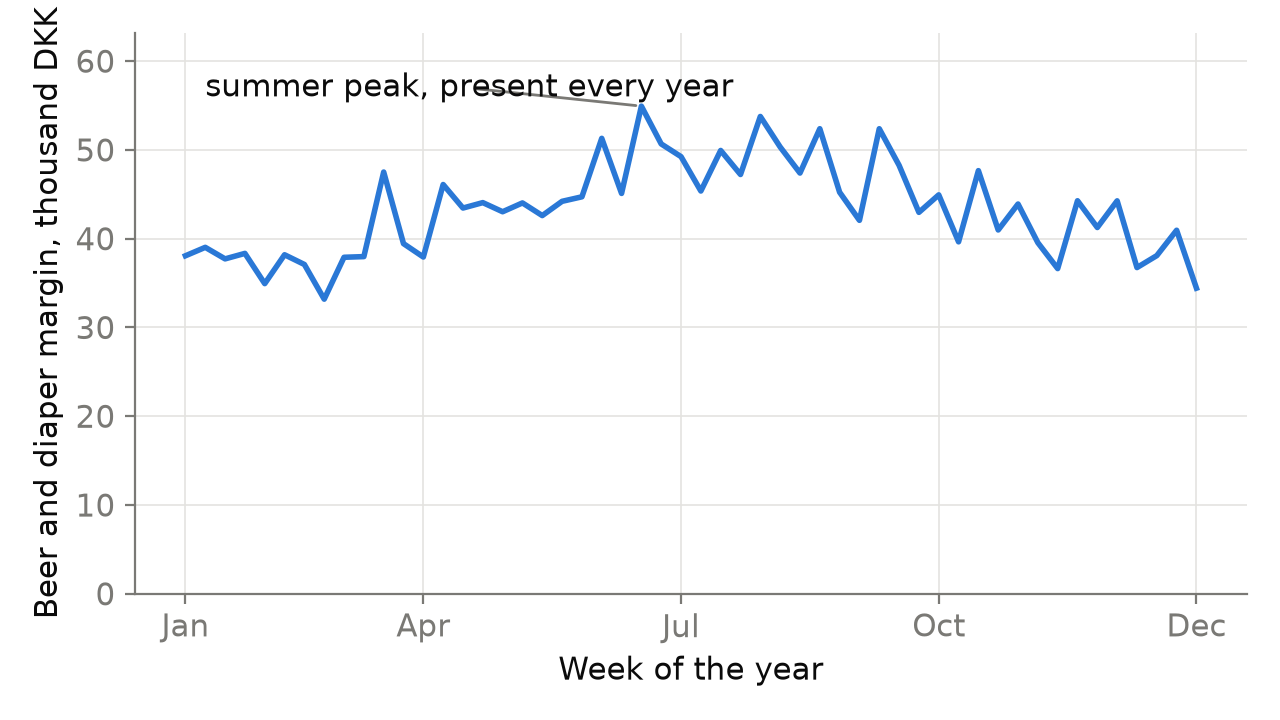

In [8]:
# Source: Module 3/slides/make_figs_3.0.py — lines 34–49, verbatim; the last line shows the picture they saved

# 1. One year of weekly revenue: the summer peak is the season.
ALPHA_B, ALPHA_D = 6.0, 20.0  # margin per unit, DKK, example
daily["week"] = daily.day // 7
weekly = daily.groupby("week").agg(beer=("beer", "sum"), diapers=("diapers", "sum"))
weekly = weekly[weekly.index < 52]
revenue = ALPHA_B * weekly.beer + ALPHA_D * weekly.diapers
fig, ax = plt.subplots(figsize=(6.4, 3.6), dpi=200)
ax.plot(weekly.index + 1, revenue / 1000, color=ACCENT, lw=2)
ax.set_xlabel("Week of the year"); ax.set_ylabel("Beer and diaper margin, thousand DKK")
ax.set_xticks([1, 13, 26, 39, 52]); ax.set_xticklabels(["Jan", "Apr", "Jul", "Oct", "Dec"])
peak = int(revenue.idxmax()) + 1
ax.annotate("summer peak, present every year", xy=(peak, revenue.max() / 1000),
            xytext=(peak - 22, revenue.max() / 1000 * 1.02), color=INK,
            arrowprops=dict(arrowstyle="-", color=MUTED))
ax.set_ylim(0, revenue.max() / 1000 * 1.15)
fig.tight_layout(); fig.savefig(OUT / "fig_sales_curve.png"); plt.close(fig)

show_png(OUT / "fig_sales_curve.png")

### The chance of buying beer depends on who buys

*Slide: "The chance of buying beer depends on who buys, and that is a hypothesis".*

**Goal.** Write the conditional probability the slide defines, and check the simulation against the guesses it was built on.

**Why.** A probability is a share of receipts; a conditional probability is the same share inside one group. The slide's table is the simulation's input, not a measurement.

**What the code does.** Displays the definition, then measures the share of card holders' receipts carrying beer in each segment and prints it beside the value the simulation was given. The measured shares differ slightly because the summer season multiplies the chance.

**So what.** The hypothesis in, the shares out: the simulation does what it says.

In [9]:
beer, w = sp.symbols(r"\mathrm{beer} w")
P = sp.Function("P")
formula(sp.Eq(P(sp.Symbol(r"\mathrm{beer} \mid w")),
              P(sp.Symbol(r"\mathrm{beer\ and\ } w")) / P(w), evaluate=False))
carded = df.dropna(subset=["segment_if_card"])
measured = carded.groupby("segment_if_card")["beer"].mean()
print("chance a receipt carries beer — the slide's value (the simulation's input) "
      "and the share measured on card holders' receipts")
for segment, given in P_BEER.items():
    print(f"  {segment:16} slide {given:.2f}   measured {measured[segment]:.3f}")

<IPython.core.display.Math object>

chance a receipt carries beer — the slide's value (the simulation's input) and the share measured on card holders' receipts
  man, no baby     slide 0.38   measured 0.380
  woman, no baby   slide 0.20   measured 0.199
  man, baby        slide 0.12   measured 0.117
  woman, baby      slide 0.05   measured 0.050


### A receipt records what was bought and when, not who

*Slide: "A receipt records what was bought and when, not who bought it".*

**Goal.** Draw the three daily counts a receipt file yields.

**Why.** Each day gives three counts — beer only, diapers only, both — and each count adds one yes or no per receipt. Only card holders say who they are.

**What the code does.** Runs block 2 of `make_figs_3.0.py` verbatim, then checks the card holders' share.

**So what.** The rare count, receipts with both, is the one the story is about, and the one a daily average treats worst.

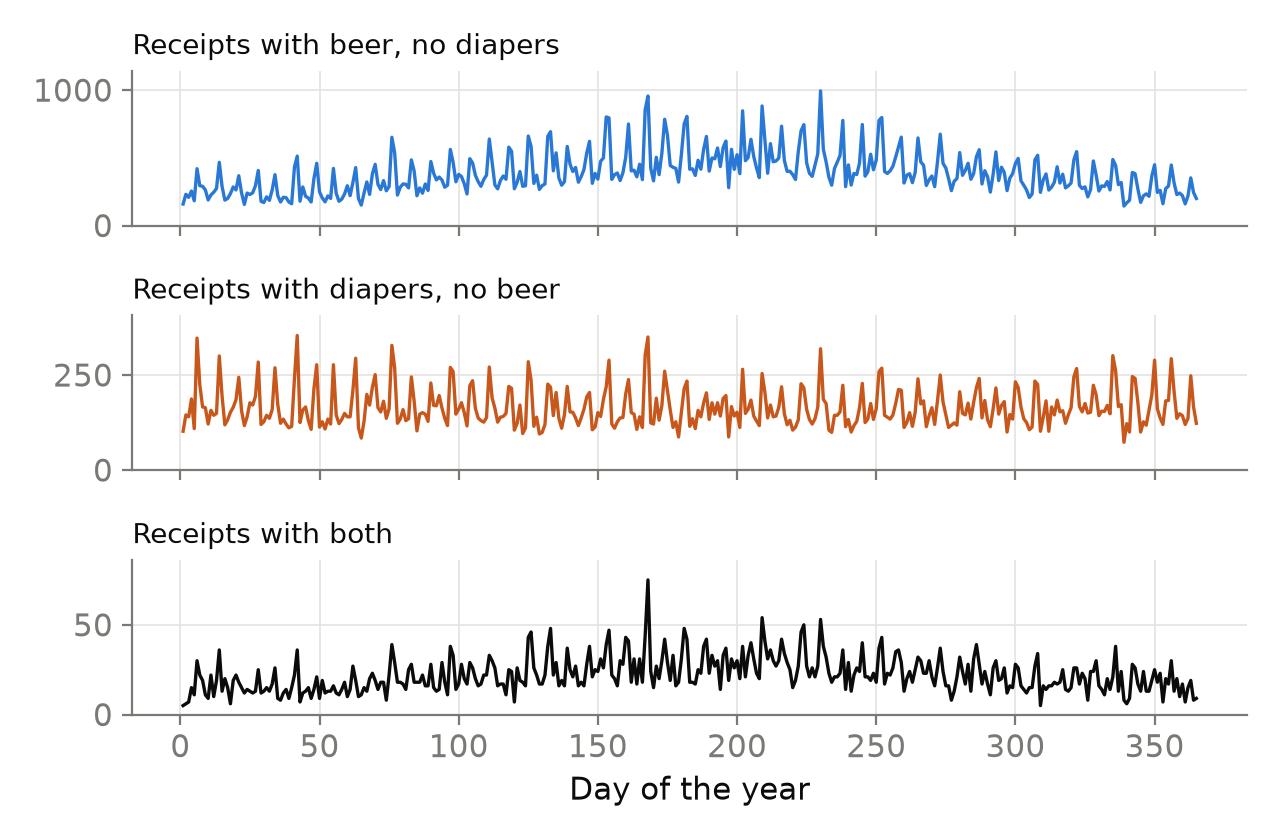

  loyalty-card receipts, per cent of all                             deck 35         computed 35


In [10]:
# Source: Module 3/slides/make_figs_3.0.py — lines 51–61, verbatim; the last line shows the picture they saved

# 2. Three daily counts from the receipts.
fig, axes = plt.subplots(3, 1, figsize=(6.4, 4.2), dpi=200, sharex=True)
series = [("Receipts with beer, no diapers", daily.beer - daily.both, ACCENT),
          ("Receipts with diapers, no beer", daily.diapers - daily.both, WARM),
          ("Receipts with both", daily.both, INK)]
for ax, (label, y, c) in zip(axes, series):
    ax.plot(daily.day + 1, y, color=c, lw=1.2)
    ax.set_title(label, loc="left", fontsize=10, color=INK)
    ax.set_ylim(0, y.max() * 1.15)
axes[-1].set_xlabel("Day of the year")
fig.tight_layout(); fig.savefig(OUT / "fig_daily_counts.png"); plt.close(fig)

show_png(OUT / "fig_daily_counts.png")
agrees("loyalty-card receipts, per cent of all", 100 * m["card_share"], 35, 0)

### Averaging inside windows gives a bell only when the windows are alike

*Slide: "Averaging inside windows gives a bell curve only when the windows are alike".*

**Goal.** Show the daily beer count as two bells, and the daily share as one.

**Why.** The central limit theorem needs alike outcomes. Weekdays and weekends differ in footfall, so a daily count mixes two populations; dividing by the day's receipts removes that split, while the season still spreads the values.

**What the code does.** Runs block 3 of `make_figs_3.0.py` verbatim and prints the two means.

**So what.** Two bells, one share. And the theorem must not be applied to small counts such as the rare receipts with both items.

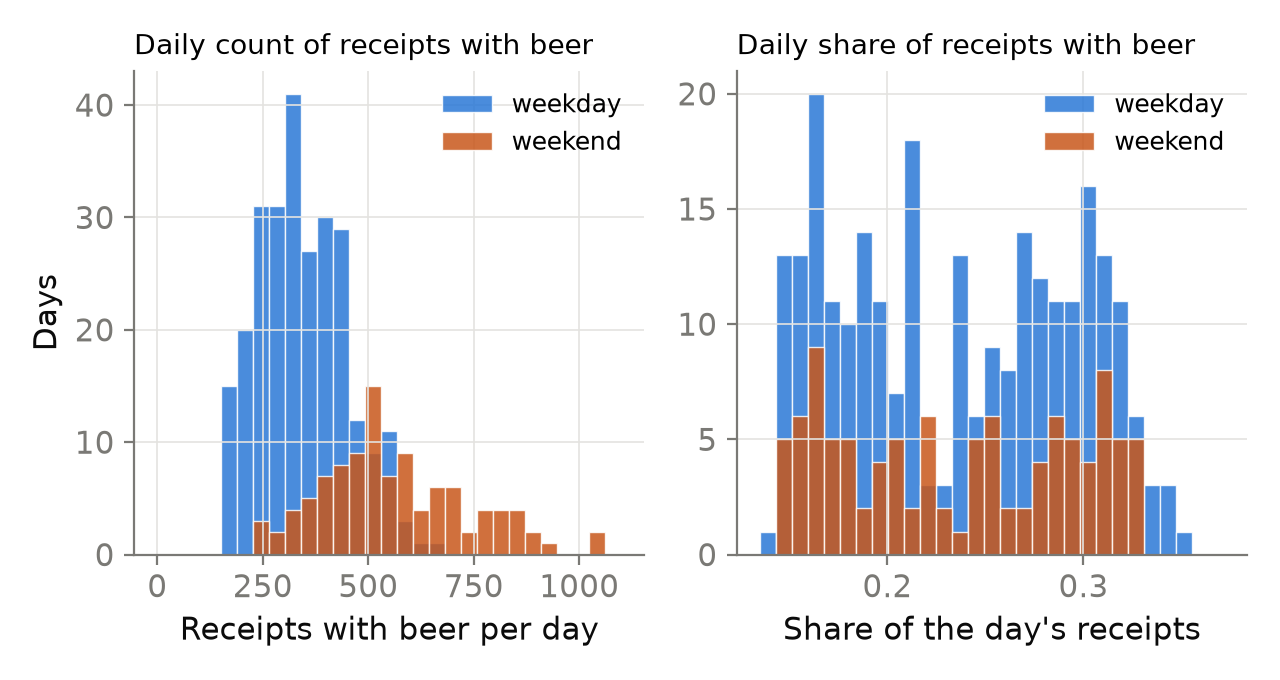

receipts with beer per day: weekdays 345.2, weekends 562.9 (means)


In [11]:
# Source: Module 3/slides/make_figs_3.0.py — lines 63–79, verbatim; the last line shows the picture they saved

# 3. Daily beer count: two bells when day types are mixed; one bell for the share.
fig, axes = plt.subplots(1, 2, figsize=(6.4, 3.4), dpi=200)
bins = np.linspace(0, daily.beer.max() * 1.05, 30)
for kind, c in (("weekday", ACCENT), ("weekend", WARM)):
    sub = daily[daily.day_type == kind]
    axes[0].hist(sub.beer, bins=bins, color=c, alpha=0.85, edgecolor="white", lw=0.5, label=kind)
axes[0].set_title("Daily count of receipts with beer", loc="left", fontsize=10)
axes[0].set_xlabel("Receipts with beer per day"); axes[0].set_ylabel("Days")
axes[0].legend(frameon=False, fontsize=9)
share = daily.beer / daily.receipts
bins2 = np.linspace(share.min() * 0.95, share.max() * 1.05, 30)
for kind, c in (("weekday", ACCENT), ("weekend", WARM)):
    sub = daily[daily.day_type == kind]
    axes[1].hist(sub.beer / sub.receipts, bins=bins2, color=c, alpha=0.85, edgecolor="white", lw=0.5, label=kind)
axes[1].set_title("Daily share of receipts with beer", loc="left", fontsize=10)
axes[1].set_xlabel("Share of the day's receipts"); axes[1].legend(frameon=False, fontsize=9)
fig.tight_layout(); fig.savefig(OUT / "fig_two_bells.png"); plt.close(fig)

show_png(OUT / "fig_two_bells.png")
print(f"receipts with beer per day: weekdays {m['daily_beer_count_weekday_mean']}, weekends {m['daily_beer_count_weekend_mean']} (means)")

### The window decides what can be seen

*Slide: "A daily window hides the 17:00 to 19:00 pattern that an hourly window shows".*

**Goal.** Count the share of receipts with both items per hour, and per day.

**Why.** The documented finding was an hour-of-day pattern (Power, 2002). A window must be shorter than the pattern it is meant to show.

**What the code does.** Runs block 4 of `make_figs_3.0.py` verbatim and prints the share in the evening hours against the rest.

**So what.** Per hour, 17 and 18 h stand out; per day, only the season is left.

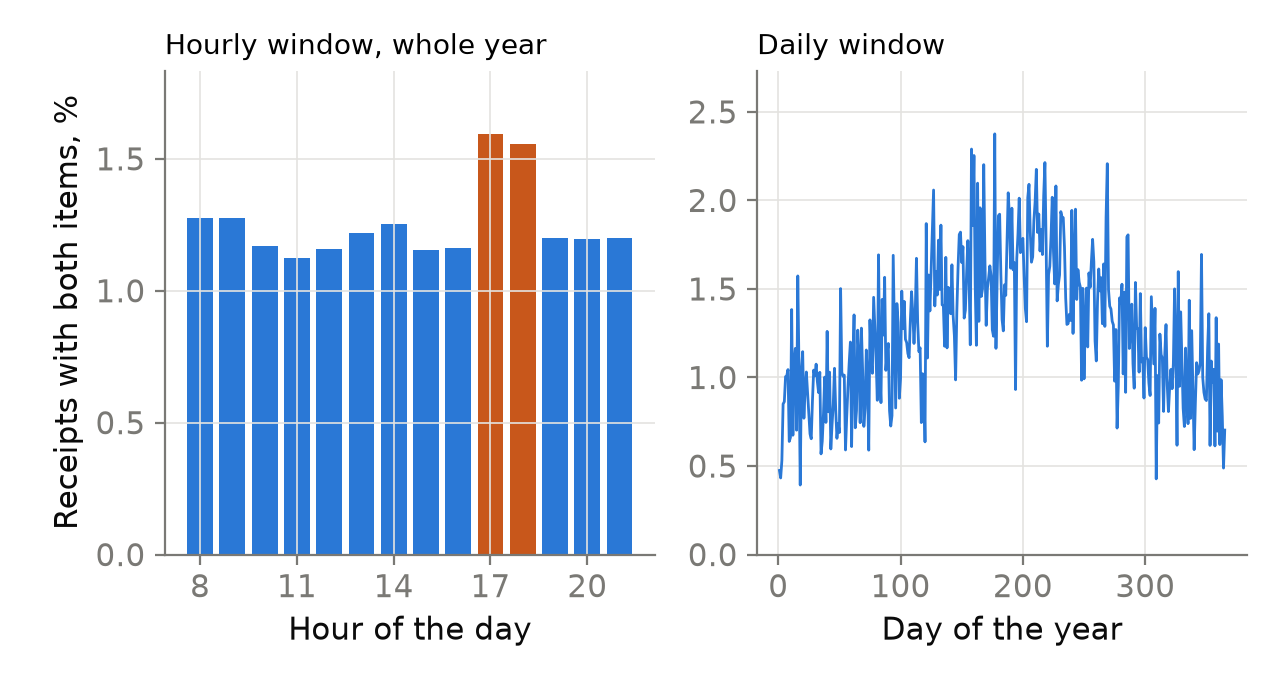

share of receipts with both items: 17-18 h 1.58 %, other hours 1.19 %


In [12]:
# Source: Module 3/slides/make_figs_3.0.py — lines 81–92, verbatim; the last line shows the picture they saved

# 4. Hourly window shows 17-18 h; daily window hides it.
fig, axes = plt.subplots(1, 2, figsize=(6.4, 3.4), dpi=200)
cols = [WARM if h in (17, 18) else ACCENT for h in hourly.hour]
axes[0].bar(hourly.hour, hourly.share * 100, color=cols, width=0.8)
axes[0].set_title("Hourly window, whole year", loc="left", fontsize=10)
axes[0].set_xlabel("Hour of the day"); axes[0].set_ylabel("Receipts with both items, %")
axes[0].set_xticks([8, 11, 14, 17, 20])
axes[1].plot(daily.day + 1, daily.share_both * 100, color=ACCENT, lw=1)
axes[1].set_title("Daily window", loc="left", fontsize=10)
axes[1].set_xlabel("Day of the year"); axes[1].set_ylim(0, daily.share_both.max() * 100 * 1.15)
axes[0].set_ylim(0, hourly.share.max() * 100 * 1.15)
fig.tight_layout(); fig.savefig(OUT / "fig_hour_vs_day.png"); plt.close(fig)

show_png(OUT / "fig_hour_vs_day.png")
print(f"share of receipts with both items: 17-18 h {100 * m['share_both_17_18']:.2f} %, other hours {100 * m['share_both_other_hours']:.2f} %")

### Support, confidence and lift

*Slides: "Three numbers say how often two items share a receipt" and "Step by step: lift by hand from the year's two-by-two table of receipts".*

**Goal.** Write the three association measures, and check that the two ways the deck writes lift are one function.

**Why.** Support and confidence are the measures of association-rule mining (Agrawal, Imieliński & Swami, 1993); lift, which its authors called interest, divides the share with both by the share independence predicts (Brin, Motwani & Silverstein, 1997).

**What the code does.** Builds each measure in sympy from the counts n, n_B, n_D and n_BD, and simplifies the difference between lift written with shares and lift written with counts.

**So what.** The difference is zero: the slide's two forms are the same number.

In [13]:
n, nB, nD, nBD = sp.symbols("n n_B n_D n_BD", positive=True)
support, confidence = nBD / n, nBD / nB
lift_counts = nBD * n / (nB * nD)
lift_shares = (nBD / n) / ((nB / n) * (nD / n))
formula(sp.Eq(sp.Symbol(r"\mathrm{support}"), support, evaluate=False),
        sp.Eq(sp.Symbol(r"\mathrm{confidence}"), confidence, evaluate=False),
        sp.Eq(sp.Symbol(r"\mathrm{lift}"), lift_counts, evaluate=False))
print("lift as shares minus lift as counts, simplified:", sp.simplify(lift_shares - lift_counts))

<IPython.core.display.Math object>

lift as shares minus lift as counts, simplified: 0


**Goal.** Compute the three numbers by hand from the year's table, as the slide does.

**Why.** A library's answer can only be checked by someone who has computed it once.

**What the code does.** Reads the four cells of the two-by-two table from the measurements and recomputes support, confidence and lift, with the shares of beer and of diapers the slide rounds to 0.236 and 0.108.

**So what.** Lift 0.50: across all receipts, beer buyers carry diapers less often than chance.

In [14]:
table = m["all"]
for what, key, stated in (("beer and diapers", "both", 8054), ("beer, no diapers", "beer_no_diapers", 140583),
                          ("diapers, no beer", "diapers_no_beer", 60125), ("neither", "neither", 421170),
                          ("with beer", "beer", 148637), ("with diapers", "diapers", 68179),
                          ("all receipts", "receipts", 629932)):
    agrees(f"receipts: {what}", table[key], stated, 0)
n_all = table["receipts"]
agrees("support = 8,054 / 629,932", table["both"] / n_all, 0.0128, 4)
agrees("confidence = 8,054 / 148,637", table["both"] / table["beer"], 0.054, 3)
agrees("share with beer", table["beer"] / n_all, 0.236, 3)
agrees("share with diapers", table["diapers"] / n_all, 0.108, 3)
agrees("lift", float(lift_counts.subs({n: n_all, nB: table["beer"], nD: table["diapers"],
                                       nBD: table["both"]})), 0.50, 2)

  receipts: beer and diapers                                         deck 8054       computed 8054
  receipts: beer, no diapers                                         deck 140583     computed 140583
  receipts: diapers, no beer                                         deck 60125      computed 60125
  receipts: neither                                                  deck 421170     computed 421170
  receipts: with beer                                                deck 148637     computed 148637
  receipts: with diapers                                             deck 68179      computed 68179
  receipts: all receipts                                             deck 629932     computed 629932
  support = 8,054 / 629,932                                          deck 0.0128     computed 0.0128
  confidence = 8,054 / 148,637                                       deck 0.054      computed 0.054
  share with beer                                                    deck 0.236      computed 0.

### Simpson's paradox in the card holders' receipts

*Slide: "Beer buyers avoid diapers in the whole, and seek them inside every group".*

**Goal.** Recompute the slide's table: the diaper share with and without beer, for parents, non-parents and all card holders.

**Why.** An association inside every group can reverse when the groups are pooled (Simpson, 1951). Which table to believe is not a question the counts can answer; the causal story answers it — here, parenthood drives both purchases (Pearl, 2014).

**What the code does.** Builds the table from the measurements and checks every cell the slide prints.

**So what.** Lift 1.36 and 1.35 inside the groups, 0.56 pooled. Use the lift inside each group.

In [15]:
rows = []
for label, key in (("Parents", "parents"), ("Non-parents", "non_parents"), ("All card holders", "card_holders")):
    g = m[key]
    rows.append({"group": label, "receipts": g["receipts"], "with beer": g["beer"],
                 "of which diapers": g["both"], "share": round(100 * g["diapers_share_given_beer"], 1),
                 "without beer": g["receipts"] - g["beer"], "of which diapers ": g["diapers_no_beer"],
                 "share ": round(100 * g["diapers_share_given_no_beer"], 1), "lift": g["lift"]})
display(pd.DataFrame(rows).set_index("group"))
for label, key, receipts, beer_, both_, share_b, share_nb, lift in (
        ("parents", "parents", 87578, 6928, 4089, 59.0, 42.2, 1.36),
        ("non-parents", "non_parents", 132287, 36551, 220, 0.6, 0.4, 1.35),
        ("all card holders", "card_holders", 219865, 43479, 4309, 9.9, 19.5, 0.56)):
    g = m[key]
    agrees(f"{label}: receipts", g["receipts"], receipts, 0)
    agrees(f"{label}: with beer", g["beer"], beer_, 0)
    agrees(f"{label}: with both", g["both"], both_, 0)
    agrees(f"{label}: diaper share with beer, per cent", 100 * g["both"] / g["beer"], share_b, 1)
    agrees(f"{label}: diaper share without beer, per cent",
           100 * g["diapers_no_beer"] / (g["receipts"] - g["beer"]), share_nb, 1)
    agrees(f"{label}: lift", g["lift"], lift, 2)

,receipts,with beer,of which diapers,share,without beer,of which diapers,share,lift
group,,,,,,,,
Parents,87578,6928,4089,59.0,80650,34058,42.2,1.36
Non-parents,132287,36551,220,0.6,95736,369,0.4,1.35
All card holders,219865,43479,4309,9.9,176386,34427,19.5,0.56


  parents: receipts                                                  deck 87578      computed 87578
  parents: with beer                                                 deck 6928       computed 6928
  parents: with both                                                 deck 4089       computed 4089
  parents: diaper share with beer, per cent                          deck 59.0       computed 59.0
  parents: diaper share without beer, per cent                       deck 42.2       computed 42.2
  parents: lift                                                      deck 1.36       computed 1.36
  non-parents: receipts                                              deck 132287     computed 132287
  non-parents: with beer                                             deck 36551      computed 36551
  non-parents: with both                                             deck 220        computed 220
  non-parents: diaper share with beer, per cent                      deck 0.6        computed 0.6
  non-pa

### Reweighting to the population's shares

*Slide: "Reweighting to 24 % parents fixes the diaper rate: 10.8 %, not 17.6 %".*

**Goal.** Write the post-stratified rate.

**Why.** Parents hold loyalty cards more often, so they are 39.8 % of card holders' receipts but 24 % of all shoppers. Any rate parents drive is inflated among card holders: selection bias. The card changes who you see, not how each group shops.

**What the code does.** Writes the rate as the sum over groups of the group's share times the group's rate, in sympy, and evaluates it with the card holders' shares and with the population's.

**So what.** 17.6 % against 10.8 %: the same two group rates, recombined with different shares.

In [16]:
share, rate_parent, rate_other = sp.symbols(r"\pi \rho_{\mathrm{parent}} \rho_{\mathrm{other}}", positive=True)
rate = share * rate_parent + (1 - share) * rate_other
formula(sp.Eq(sp.Symbol(r"\hat{\rho}"), rate, evaluate=False))
parents, others = m["parents"], m["non_parents"]
r_parent = parents["diapers"] / parents["receipts"]
r_other = others["diapers"] / others["receipts"]
agrees("parents' diaper rate, per cent (38,147 / 87,578)", 100 * r_parent, 43.6, 1)
agrees("non-parents' diaper rate, per cent (589 / 132,287)", 100 * r_other, 0.45, 2)
agrees("parents' share of card holders' receipts", m["parents_share_of_card_holders"], 0.398, 3)
uncorrected = float(rate.subs({share: 0.398, rate_parent: 0.436, rate_other: 0.0045}))
corrected = float(rate.subs({share: 0.24, rate_parent: 0.436, rate_other: 0.0045}))
agrees("uncorrected, card-holder shares, per cent", 100 * uncorrected, 17.6, 1)
agrees("corrected, all-shopper shares, per cent", 100 * corrected, 10.8, 1)
agrees("diaper receipts to stock for, per 10,000 receipts, corrected", 10000 * round(corrected, 3), 1080, 0)
agrees("the same, uncorrected", 10000 * round(uncorrected, 3), 1760, 0)

<IPython.core.display.Math object>

  parents' diaper rate, per cent (38,147 / 87,578)                   deck 43.6       computed 43.6
  non-parents' diaper rate, per cent (589 / 132,287)                 deck 0.45       computed 0.45
  parents' share of card holders' receipts                           deck 0.398      computed 0.398
  uncorrected, card-holder shares, per cent                          deck 17.6       computed 17.6
  corrected, all-shopper shares, per cent                            deck 10.8       computed 10.8
  diaper receipts to stock for, per 10,000 receipts, corrected       deck 1080       computed 1080
  the same, uncorrected                                              deck 1760       computed 1760


**Goal.** Draw the reweighting as bars, and check it against the truth the simulation knows.

**Why.** The slide draws the three steps as boxes. The simulation can do what a shop cannot: it knows every receipt's diaper status, so the corrected rate can be compared with the rate over all receipts.

**What the code does.** Draws the two group rates, then the two recombined rates, and beside them the share of all 629,932 receipts that carry diapers.

**So what.** The corrected 10.8 % matches the whole-population share; the card holders' 17.6 % overstates it by more than 60 per cent.

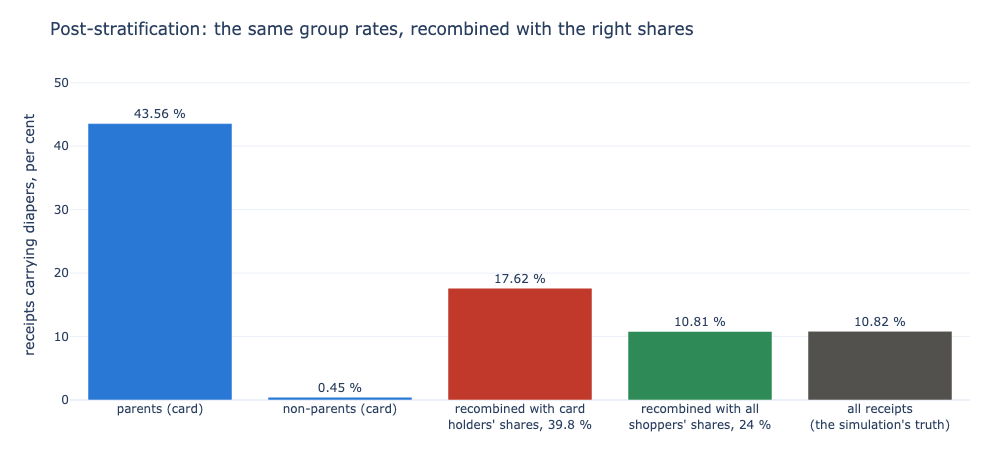

  share of all receipts carrying diapers, per cent                   deck 10.8       computed 10.8


In [17]:
everyone = m["all"]["diapers"] / m["all"]["receipts"]
labels = ["parents (card)", "non-parents (card)", "recombined with card<br>holders' shares, 39.8 %",
          "recombined with all<br>shoppers' shares, 24 %", "all receipts<br>(the simulation's truth)"]
values = [100 * r_parent, 100 * r_other, 100 * uncorrected, 100 * corrected, 100 * everyone]
fig = go.Figure(go.Bar(x=labels, y=values, marker_color=["#2A78D6", "#2A78D6", "#C0392B", "#2E8B57", "#52514E"],
                       text=[f"{v:.2f} %" for v in values], textposition="outside"))
fig.update_layout(title="Post-stratification: the same group rates, recombined with the right shares",
                  yaxis_title="receipts carrying diapers, per cent", yaxis_range=[0, 52], showlegend=False)
show(fig, "reweighting", height=460)
agrees("share of all receipts carrying diapers, per cent", 100 * everyone, 10.8, 1)

### A quantity the shop decides

*Slide: "Sales depend on who shops and on a shelf distance the shop decides".*

**Goal.** Draw the two layouts, far and near, with the distance d between the shelves.

**Why.** d is set by the shop, not chosen by customers and not recorded on receipts. A quantity set by a decision is an intervention, written do(d) (Pearl, 2009): receipts from layout A say nothing about layout B.

**What the code does.** Runs block 5 of `make_figs_3.0.py` verbatim.

**So what.** To learn P(both | w, do(d)) for the other layout, the other layout must be tried.

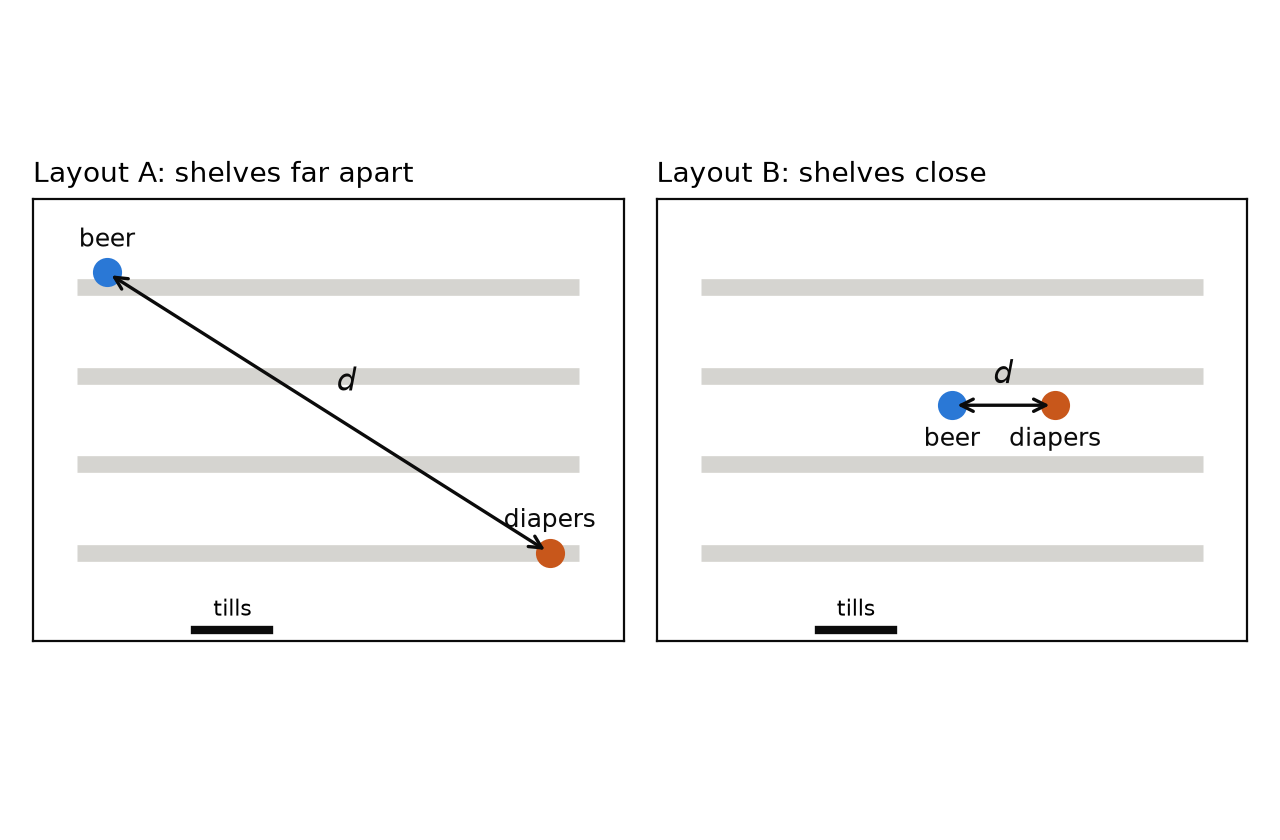

In [18]:
# Source: Module 3/slides/make_figs_3.0.py — lines 94–112, verbatim; the last line shows the picture they saved

# 5. Floor plan: the distance d between the two shelves is chosen by the store.
fig, axes = plt.subplots(1, 2, figsize=(6.4, 4.2), dpi=200)
for ax, (title, beer_xy, diaper_xy) in zip(axes, [
        ("Layout A: shelves far apart", (1.0, 5.0), (7.0, 1.2)),
        ("Layout B: shelves close", (4.0, 3.2), (5.4, 3.2))]):
    ax.set_xlim(0, 8); ax.set_ylim(0, 6); ax.set_aspect("equal"); ax.grid(False)
    ax.set_xticks([]); ax.set_yticks([])
    for s in ax.spines.values(): s.set_visible(True); s.set_color(INK)
    for y in (1.2, 2.4, 3.6, 4.8):
        ax.plot([0.6, 7.4], [y, y], color="#D5D4D0", lw=6, solid_capstyle="butt")
    ax.plot([2.2, 3.2], [0.15, 0.15], color=INK, lw=3); ax.text(2.7, 0.35, "tills", ha="center", fontsize=8)
    bx, by = beer_xy; dx, dy = diaper_xy
    off = -0.55 if "close" in title else 0.35
    ax.scatter([bx], [by], s=90, color=ACCENT, zorder=3); ax.text(bx, by + off, "beer", ha="center", fontsize=9, color=INK)
    ax.scatter([dx], [dy], s=90, color=WARM, zorder=3); ax.text(dx, dy + off, "diapers", ha="center", fontsize=9, color=INK)
    ax.annotate("", xy=(dx, dy), xytext=(bx, by), arrowprops=dict(arrowstyle="<->", color=INK, lw=1.2))
    ax.text((bx + dx) / 2 + (0 if "close" in title else 0.25), (by + dy) / 2 + 0.3, "d", fontsize=11, style="italic", color=INK, ha="center")
    ax.set_title(title, loc="left", fontsize=10)
fig.tight_layout(); fig.savefig(OUT / "fig_floor.png"); plt.close(fig)

show_png(OUT / "fig_floor.png")

### The expected margin of a chosen layout

*Slide: "Expected margin for a chosen layout sums over who buys and what they buy".*

**Goal.** Write the expected weekly margin under a layout, and the shelf effect.

**Why.** The margin sums over shopper groups w and products k: every product is in the sum, so a sales loss in another aisle counts too.

**What the code does.** Builds E[M | do(d)] = N Σ_w P(w) Σ_k α_k P(k | w, do(d)) in sympy, then evaluates the slide's example: diapers only, N = 10,000 receipts per week, an assumed 20 DKK margin per pack, the corrected shares 24 % and 76 %, and the card holders' rates 43.6 % and 0.45 %.

**So what.** 21,612 DKK per week for one layout. The shelf effect is the difference between two such numbers, and only an experiment measures both.

In [19]:
N_, alpha, w_, k_, W, K_ = sp.symbols(r"N \alpha w k W K")
Pw = sp.Function("P")(w_)
Pk = sp.Function("P")(sp.Symbol(r"k \mid w, do(d)"))
margin_formula = N_ * sp.Sum(Pw * sp.Sum(sp.Indexed(alpha, k_) * Pk, (k_, 1, K_)), (w_, 1, W))
formula(sp.Eq(sp.Symbol(r"\mathbb{E}[M \mid do(d)]"), margin_formula, evaluate=False))
expected_under = lambda layout: sp.Symbol(rf"\mathbb{{E}}[M \mid do(d_{{\mathrm{{{layout}}}}})]")
shelf_effect = sp.Add(expected_under("near"), -expected_under("far"), evaluate=False)
formula(sp.Eq(sp.Symbol(r"\Delta_{\mathrm{shelf}}"), shelf_effect, evaluate=False))
parent_part = sp.Rational(24, 100) * 20 * sp.Rational(436, 1000)
other_part = sp.Rational(76, 100) * 20 * sp.Rational(45, 10000)
agrees("parents' term, DKK per receipt", parent_part, 2.0928, 4)
agrees("others' term, DKK per receipt", other_part, 0.0684, 4)
agrees("margin per receipt, DKK", parent_part + other_part, 2.1612, 4)
agrees("margin per week, 10,000 receipts, DKK", 10000 * (parent_part + other_part), 21612, 0)
lay = m["layout_example"]
beside("the simulation's own layout example (measured_3.0.json, not on a slide): margin per day, far and near",
       f"{lay['margin_far']:,} and {lay['margin_near']:,} DKK, gain {lay['gain']} DKK",
       "N = 10,000 per week",
       f"that example uses the simulation's {lay['N']:,} receipts a day, beer as well as diapers, "
       "and a hypothesised 10 % rise in parents' beer; the slide's example is diapers only")

<IPython.core.display.Math object>

<IPython.core.display.Math object>

  parents' term, DKK per receipt                                     deck 2.0928     computed 2.0928
  others' term, DKK per receipt                                      deck 0.0684     computed 0.0684
  margin per receipt, DKK                                            deck 2.1612     computed 2.1612
  margin per week, 10,000 receipts, DKK                              deck 21612      computed 21612
  the simulation's own layout example (measured_3.0.json, not on a slide): margin per day, far and near: computed here 6,213 and 6,233 DKK, gain 20 DKK, stated N = 10,000 per week — that example uses the simulation's 1,726 receipts a day, beer as well as diapers, and a hypothesised 10 % rise in parents' beer; the slide's example is diapers only


### Testing a layout

*Slides: "To test a layout, a random draw decides which stores get it" and "If stores
cannot be drawn at random, use difference in differences".*

**A/B test.** Choose the outcome first — total margin per receipt, not beer plus
diapers; let chance decide which half of the stores gets layout B; run whole weeks;
compare the two averages (Drèze, Hoch & Purk, 1994). Chance cannot favour busy stores, so the two
groups differ only in the layout. Few stores, or shoppers crossing between groups,
spoil the test (Kohavi, Tang & Xu, 2020).

**Difference in differences.** When the shelves have already moved, or managers
picked the stores, compare how much each group *changed* (Card & Krueger, 1994). Season and
prices hit both groups and subtract out. The assumption — parallel trends — fails
if another event, such as local roadworks, hits one group only; a flat gap before
the move supports it, and only a random draw makes it hold by design. With one
store only, intervention analysis (Box & Tiao, 1975) or a synthetic control (Abadie, Diamond & Hainmueller, 2010)
also rest on assumptions.

**Goal.** Write the difference-in-differences estimator and evaluate the slide's example.

**Why.** Subtracting the unchanged stores' change removes whatever hit both groups.

**What the code does.** Builds the estimator in sympy and substitutes the slide's invented margins per receipt: 6.10 before and 6.40 after in the changed stores, 6.05 and 6.25 in the unchanged ones.

**So what.** 0.10 DKK per receipt — an effect of the layout only if the trends were parallel.

In [20]:
mean_margin = lambda when, stores: sp.Symbol(rf"\bar{{M}}^{{\mathrm{{{when}}}}}_{{\mathrm{{{stores}}}}}")
Mca, Mcb = mean_margin("after", "changed"), mean_margin("before", "changed")
Mua, Mub = mean_margin("after", "unchanged"), mean_margin("before", "unchanged")
did = sp.Add(sp.Add(Mca, -Mcb, evaluate=False),                   # unevaluated, so the two
             sp.Mul(-1, sp.Add(Mua, -Mub, evaluate=False), evaluate=False),   # changes stay visible
             evaluate=False)
formula(sp.Eq(sp.Symbol(r"\mathrm{effect}"), did, evaluate=False))
example = did.subs({Mca: sp.Rational(640, 100), Mcb: sp.Rational(610, 100),
                    Mua: sp.Rational(625, 100), Mub: sp.Rational(605, 100)})
agrees("(6.40 - 6.10) - (6.25 - 6.05), DKK per receipt", example, 0.10, 2)

<IPython.core.display.Math object>

  (6.40 - 6.10) - (6.25 - 6.05), DKK per receipt                     deck 0.1        computed 0.1


### Transport, and a definition

*Slides: "A beer-and-diapers rule from one country may not hold in another" and
"Data science speaks mathematics and answers for the decisions it drives".*

A rule describes one population: one chain, one country, one period. Behaviour
measured in one society often differs in another, and the samples behavioural
science draws on are unusually narrow (Henrich, Heine & Norenzayan, 2010). A rule transfers only if each
shopper group buys each product at the same rate in both places — transportability,
or external validity (Pearl & Bareinboim, 2014) — and once a store acts on a rule,
behaviour can shift (Lucas, 1976). Before using it abroad: rerun the analysis on
local receipts, then test the layout locally.

The deck closes on a definition, in the instructor's words: data mining finds
patterns in data collected for other purposes (Hand, Mannila & Smyth, 2001); data science carries
them from a specific question to a decision, including the test that shows they
hold (Tukey, 1962; Donoho, 2017); and because its models often act on people directly,
at scale, with no person in between, it answers for the decisions it drives
(Regulation (EU) 2024/1689, Art. 14). Module 3.1 takes a model from a pattern to a service whose
decisions can be checked.

---
# Part 3.1 — Deploying a model as a service, I

*Deck: `Module3.1.pptx`. A model that other programs can ask, and that can prove which
version answered.*

**The hook** (*slide: "A good model with a careless cutoff loses to no model at
all"*). A bus operator asks a model: is this person aboard? The dumbest rule —
always answer aboard — costs the operator 1,663 vehicle-hours on the 3,241 test
rows. The trained model with the 0.5 cutoff every library uses costs 2,054, about
24 per cent worse than no model. The same model with a cutoff computed from one
line of arithmetic costs 1,590, and nothing was retrained. These numbers are
recomputed in Block three below. The module is about everything after the model:
the service around it, the cutoff, the check at the door, and the proof of which
version answered.

**Three beliefs to drop** (*slide: "What you need already, and three beliefs to
drop"*): using a model means proving which copy answered, not copying it
somewhere; a 0.5 threshold is not neutral — it assumes a false positive and a false
negative cost the same; and no error does not mean working.

**Six words** (*slide: "Six words are used all day"*): a *model* applies a rule
learnt from examples; a *service* waits for questions from other programs; a
*request* is one question; a *version* is one saved copy of a model with a name
that never changes; a *data contract* declares what the service accepts, checked
before the model is asked; *aboard* means the phone's owner was on the shuttle.

**Four objectives** (*slide: "Four objectives state their reason before their
task"*): accept a better model without editing the service (Block one); refuse
impossible values before the model is asked (Block two); compute the cutoff from
the two prices (Block three); cause training–serving skew on purpose, then prevent
it (Block four, in Part 3.2).

**Every symbol** (*slide: "Every symbol used today"*): p the model's probability
that the person was aboard; t the cutoff, aboard when p ≥ t; y the true answer, 1
aboard; C_FP = 1 vehicle-hour, a bus sent for nobody; C_FN = 4 vehicle-hours, a
passenger left waiting; K the total cost; speed in metres per second; rssi1, rssi2,
rssiC the signal strengths heard from the beacons, in decibel-milliwatts.

## The service, built from nothing

Before any lab runs, `bash setup.sh` prepares everything the labs read: the phone
traces, the two trained models, the fifty-line registry and the MLflow store. This
section does the same in the working copy, with all the code on the page: the
generator, the training script, the hand-off table and the support file the four
labs share.

**The model is a stand-in.** The four modelling sessions between Module 2 and
Module 3 produce the model this course would rather serve. Until that artefact is
agreed, the labs need something to promote, refuse, threshold and skew, so
`service/models.py` trains two small forests from Module 2's generated table. When
the real artefact arrives it drops into `service/artefacts/` and nothing downstream
changes — which is release by indirection, the subject of Block one.

**Goal.** Let the generator's path constants resolve inside a notebook.

**Why.** `make_phones.py` finds its calibration file relative to its own location (`__file__`), which a notebook does not have.

**What the code does.** Points `__file__` at the generator in the working copy.

**So what.** The next cell can be copied from the file unchanged.

In [21]:
__file__ = str(WORK / "data" / "make_phones.py")

**Goal.** Define the phone-trace generator.

**Why.** The real `passengers.csv` traces sixteen identifiable volunteers and is personal data, so it is not in the repository. What ships is a generator whose rates — how often each beacon is heard, how often the target is aboard, the row counts — were measured from the real file and written into `calibration.json`.

**What the code does.** Copies `data/make_phones.py` verbatim: twelve phones on 22 January, fifteen minutes each at 0.993 seconds, a ride that makes 56.3 per cent of rows aboard, beacons heard at the archive's measured rates and absent when weak, and a `bus_id` present exactly when aboard — the leak Module 2 hunts.

**So what.** The table every lab of 3.1 and 3.2 reads is generated here, deterministically.

In [22]:
# Source: Module 3/exercises/data/make_phones.py — HERE, CALIBRATION, SEED, BEACONS, PROXIMITY, RANGE_METRES, STRENGTH_AT_ONE_METRE, PATH_LOSS, generate, verbatim

import json
import pathlib
import numpy as np
import pandas as pd


HERE = pathlib.Path(__file__).resolve().parent


CALIBRATION = json.loads((HERE / "calibration.json").read_text())


SEED = 20200122


BEACONS = ["rssiA", "rssiB", "rssiC", "rssi1", "rssi2"]


PROXIMITY = {"rssiA": "proxA", "rssiB": "proxB", "rssiC": "proxC",
             "rssi1": "prox1", "rssi2": "prox2"}


# A beacon is heard when it is near. Signal strength falls with distance, so the
# absence is a consequence of geometry rather than of a dropped packet -- which
# is exactly what makes it missing-not-at-random.
RANGE_METRES = 25.0


STRENGTH_AT_ONE_METRE = -45.0


PATH_LOSS = 2.4


def generate(day: str = "2020-01-22", seed: int = SEED,
             with_truth: bool = False) -> pd.DataFrame:
    """One day of phone traces. Set with_truth to keep the hidden columns."""
    rng = np.random.default_rng(seed)
    phones = CALIBRATION["phones_per_day"][day]
    interval = CALIBRATION["phone_interval_s"]
    # The labelled rows are the basis for everything below, because that is the
    # population the per-state beacon shares were measured over. The all-rows
    # absence share in calibration.json is a different population -- it includes
    # the second day, which carries no labels at all.
    aboard_share = CALIBRATION["aboard_share_of_labelled"] / 100

    start = pd.Timestamp(f"{day} 09:00:00", tz="UTC")
    per_phone = 900  # fifteen minutes each, enough for windows without being slow

    frames = []
    for phone in range(phones):
        clock = start + pd.to_timedelta(np.arange(per_phone) * interval, unit="s")
        # Nanosecond resolution, matching what pd.to_datetime gives on the
        # vehicle file. Mismatched resolutions make merge_asof refuse, which is
        # a real nuisance but not the lesson of any lab here.
        clock = clock.astype("datetime64[ns, UTC]")

        # A journey: waiting at a stop, riding, then waiting again. The rider is
        # near the vehicle beacons only while aboard.
        # One ride per phone, long enough that the aboard share matches the
        # archive's labelled rows: 56.3 per cent aboard, 43.7 not.
        ride = int(round(aboard_share * per_phone))
        boarding = int(rng.integers(0, max(1, per_phone - ride)))
        position = np.arange(per_phone)
        is_aboard = (position >= boarding) & (position < boarding + ride)

        # Distance to each beacon. Note what this does NOT do: tie hearing a
        # vehicle beacon to being aboard. The archive says that link is not
        # there -- "this beacon was heard" agrees with "aboard" on 42 to 48 per
        # cent of labelled rows, against a base rate of 56.3. The whole trial
        # fits in a box about 67 by 86 metres (Module 1), and beacon range is
        # tens of metres, so being near a stop beacon and being on the vehicle
        # are not separable by proximity here.
        #
        # So closeness is its own process, and each beacon is heard at the rate
        # the archive measured for each state. What survives, because it is real,
        # is that the readings which ARE absent are the far and weak ones.
        distances = {}
        for name in BEACONS:
            wander = rng.normal(0, 1.0, per_phone).cumsum()
            wander = (wander - wander.min()) / (np.ptp(wander) or 1.0)
            distances[name] = 1.0 + wander * 95.0

        frame = pd.DataFrame({
            "phone_id": f"p{phone:02d}",
            "timestamp_utc": clock,
            # The same trap as the archive: a column named `timestamp` that is
            # local time, sitting beside the one that is not.
            "timestamp": clock.tz_convert("Europe/Copenhagen").tz_localize(None),
            "speed": np.where(is_aboard, rng.uniform(0, 3.5, per_phone),
                              rng.uniform(0, 1.4, per_phone)).round(3),
            "stationary": (~is_aboard).astype(int),
        })

        for name in BEACONS:
            distance = np.clip(distances[name], 0.5, None)
            true_strength = (STRENGTH_AT_ONE_METRE
                             - 10 * PATH_LOSS * np.log10(distance)
                             + rng.normal(0, 2.0, per_phone))

            # Heard at the archive's measured rate, separately for aboard and
            # not-aboard rows, and within each state the strongest are heard.
            # Both the marginal absence rate and the (weak) association with the
            # label then match the real file rather than a story about it.
            heard = np.zeros(per_phone, dtype=bool)
            for state, share_table in ((True, CALIBRATION["beacon_heard_when_aboard"]),
                                       (False, CALIBRATION["beacon_heard_when_not_aboard"])):
                rows = is_aboard if state else ~is_aboard
                count = int(rows.sum())
                if count == 0:
                    continue
                keep = int(round(share_table[name] / 100 * count))
                if keep == 0:
                    continue
                cutoff = np.sort(true_strength[rows])[::-1][keep - 1]
                heard |= rows & (true_strength >= cutoff)

            frame[f"{name}_true"] = true_strength.round(1)
            frame[name] = np.where(heard, true_strength.round(1), np.nan)
            # The same absence, encoded a second way: -1 rather than empty.
            bands = np.select(
                [true_strength > -60, true_strength > -75], [1, 2], default=3)
            frame[PROXIMITY[name]] = np.where(heard, bands, -1)

        frame["label"] = np.where(is_aboard, "Bus 1", "Stop C")
        frame["label2"] = np.where(is_aboard, "IN", "OUT")
        # The leak. Present exactly when aboard, as in the archive.
        frame["bus_id"] = np.where(is_aboard, "VJRD1A10224000055", None)
        frame["aboard_truth"] = is_aboard
        frames.append(frame)

    everything = pd.concat(frames, ignore_index=True).sort_values(
        ["timestamp_utc", "phone_id"]).reset_index(drop=True)

    if with_truth:
        return everything
    hidden = [c for c in everything.columns if c.endswith("_true")] + ["aboard_truth"]
    return everything.drop(columns=hidden)

**Goal.** Make the generator importable under its file's name.

**Why.** `service/models.py` and `data/prepare.py` both run `from make_phones import generate`; without this they would look for a file the notebook never imports.

**What the code does.** Registers the five names just defined as the module `make_phones`.

**So what.** The training script below finds this generator, not a second copy of it.

In [23]:
make_phones = as_module("make_phones", ["CALIBRATION", "SEED", "BEACONS", "PROXIMITY", "generate"])

**Goal.** Run the generator's own demonstration.

**Why.** It checks the generated table against the archive's measured absence shares.

**What the code does.** The lines below are `make_phones.py`'s `__main__` block, verbatim.

**So what.** The shares land near the archive's, and the absence is encoded twice — an empty signal strength and a proximity of −1 — on exactly the same rows.

In [24]:
# Source: Module 3/exercises/data/make_phones.py — demonstration step 0, verbatim

phones = generate()
print(f"{len(phones):,} rows, {phones.shape[1]} columns, "
      f"{phones['phone_id'].nunique()} phones")
print("\nabsent share, generated against the archive's measured share:")
for name in BEACONS:
    measured = CALIBRATION["beacon_absent_share"][name]
    print(f"  {name:7} generated {phones[name].isna().mean() * 100:5.1f} %"
          f"   archive {measured:5.1f} %")
same = all((phones[r].isna() == (phones[p] == -1)).all() for r, p in PROXIMITY.items())
print(f"\nabsence encoded twice, and the two agree everywhere: {same}")

10,800 rows, 18 columns, 12 phones

absent share, generated against the archive's measured share:
  rssiA   generated  94.8 %   archive  86.3 %
  rssiB   generated  96.3 %   archive  73.2 %
  rssiC   generated  69.3 %   archive  70.7 %
  rssi1   generated  88.7 %   archive  57.0 %
  rssi2   generated  74.9 %   archive  83.8 %

absence encoded twice, and the two agree everywhere: True


**Goal.** Write the two days of phone traces where the labs read them.

**Why.** `setup.sh` runs `data/prepare.py`, whose step 2 writes one Parquet file per day, so that no lab depends on a generator running at import time.

**What the code does.** Generates each day in `calibration.json` and writes `data/phones_<day>.parquet` (this is prepare.py's step 2, written out; the rest of prepare.py is the subprocess that trains the models, which the next cells do in place).

**So what.** 10,800 rows for the training day, the number the labs quote.

In [25]:
for day in CALIBRATION["phones_per_day"]:
    traces = generate(day=day, with_truth=False)
    traces.to_parquet(WORK / "data" / f"phones_{day}.parquet", index=False)
    print(f"generated phones_{day}.parquet: {len(traces):,} rows x {traces.shape[1]} columns")
agrees("rows of the training day, 22 January", len(pd.read_parquet("data/phones_2020-01-22.parquet")), 10800, 0)

generated phones_2020-01-22.parquet: 10,800 rows x 18 columns


generated phones_2020-01-23.parquet: 7,200 rows x 18 columns
  rows of the training day, 22 January                               deck 10800      computed 10800


**Goal.** Let the training script's path constants resolve.

**Why.** `service/models.py` also finds its folders from `__file__`.

**What the code does.** Points `__file__` at it in the working copy.

**So what.** The artefacts and the MLflow store land inside the copy.

In [26]:
__file__ = str(WORK / "service" / "models.py")

**Goal.** Define the table, the stored transform and the pipeline that carries it.

**Why.** Order is part of the contract: swap two columns and every request still succeeds and every answer is wrong. So the transform is fitted once, on the training rows, and stored with the model — the one implementation of the preparation, used by the request path, the batch path and the registered pipeline alike (Breck et al., 2019; Huyen, 2022).

**What the code does.** Copies the constants, `build_table`, `fit_transform`, `apply_transform`, the `StoredTransform` step and `as_pipeline` from `service/models.py`, verbatim. The `stationary` column is deliberately left out: in the generated table it is the target inverted.

**So what.** One preparation: median fill, then z-score, in the stored order.

In [27]:
# Source: Module 3/exercises/service/models.py — HERE, EXERCISES, ARTEFACTS, DATA, SEED, FEATURES, TARGET, ABOARD, DAY, PREPARED_TABLE, STORE, ARTEFACT_ROOT, EXPERIMENT, REGISTERED_MODEL, CHAMPION, METRIC, build_table, fit_transform, apply_transform, StoredTransform, as_pipeline, verbatim
# References: (Breck et al., 2019)

import contextlib
import hashlib
import io
import json
import logging
import pathlib
import pickle
import shutil
import sys
import numpy as np
import pandas as pd
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline


HERE = pathlib.Path(__file__).resolve().parent


EXERCISES = HERE.parent


ARTEFACTS = HERE / "artefacts"


DATA = EXERCISES / "data"


SEED = 20200122


# The declared input, in order. Order is part of the contract, not a detail --
# swap two columns and every request still succeeds and every answer is wrong.
#
# `stationary` is deliberately NOT here. In the generated table it is the target
# inverted, so a model given it scores 1.0000 and has learned nothing. Module 2's
# find_leaks() catches it alongside bus_id, which is the point of that lab.
FEATURES = ["speed", "rssi1", "rssi2", "rssiC"]


TARGET = "label2"


ABOARD = "IN"


# The service is trained on the labelled day. The second day carries no labels
# at all (Module 2 measured it), which is why Module 5 exists.
DAY = "2020-01-22"


PREPARED_TABLE = DATA / f"phones_{DAY}.parquet"


# The MLflow store: one sqlite file for tracking and registry, artefacts beside
# it. Both are gitignored -- setup.sh rebuilds them in seconds -- and both are
# rewritten from nothing by build(), so their content is deterministic apart from
# run identifiers and timestamps, which nothing here ever compares.
STORE = EXERCISES / "mlruns.db"


ARTEFACT_ROOT = EXERCISES / "mlartifacts"


EXPERIMENT = "aboard-service"


REGISTERED_MODEL = "aboard"


CHAMPION, CHALLENGER = "champion", "challenger"


METRIC = "accuracy"           # the agreed metric, agreed once, before any candidate


def build_table() -> pd.DataFrame:
    """Module 2's output: generated phone traces, one row per reading.

    Reads the Parquet that setup.sh prepared when it is there and falls back to
    the generator when it is not; the two are the same rows. The sort that
    follows is kept exactly as it was when the models were first measured: the
    train/test split is positional, so the row order is part of every number on
    the slides, and it must not move.
    """
    if PREPARED_TABLE.exists():
        phones = pd.read_parquet(PREPARED_TABLE)
    else:
        logging.getLogger("service").warning(
            "data/%s is missing -- generating the table instead; run  bash setup.sh",
            PREPARED_TABLE.name)
        from make_phones import generate
        phones = generate(day=DAY, with_truth=False)
    return phones.sort_values("timestamp_utc").reset_index(drop=True)


def fit_transform(train: pd.DataFrame) -> dict:
    """Module 2's fitted transform, stored so the service prepares input identically."""
    return {
        "features": list(FEATURES),
        "medians": {c: float(train[c].median()) for c in FEATURES},
        "means": {c: float(train[c].mean()) for c in FEATURES},
        "stds": {c: float(train[c].std(ddof=0)) or 1.0 for c in FEATURES},
    }


def apply_transform(frame: pd.DataFrame, fitted: dict) -> pd.DataFrame:
    """Fill and scale with the stored constants, in the stored order.

    The one implementation of the preparation. The single-request path, the
    batch path and the registered pipeline all call this; two implementations
    would be two things that must stay correct forever.
    """
    out = pd.DataFrame(index=frame.index)
    for column in fitted["features"]:
        values = pd.Series(frame[column], index=frame.index, dtype="float64")
        values = values.fillna(fitted["medians"][column])
        out[column] = (values - fitted["means"][column]) / fitted["stds"][column]
    return out[fitted["features"]]


class StoredTransform(BaseEstimator, TransformerMixin):
    """The stored transform as a scikit-learn step, so it travels with the model.

    A registered model is asked with a *named* frame. This step reads the
    columns by name, fills an absent value from the stored median, scales with
    the stored mean and standard deviation, and hands the forest the four
    columns in the stored order -- whatever order the caller sent them in. It
    fits nothing: the constants were fitted on the training rows by
    fit_transform() and are carried inside the object.
    """

    def __init__(self, fitted: dict):
        self.fitted = fitted

    def fit(self, X, y=None):
        return self                                    # already fitted, deliberately

    def transform(self, X):
        return apply_transform(pd.DataFrame(X), self.fitted).to_numpy()


def as_pipeline(artefact: dict) -> Pipeline:
    """The artefact as one object: preparation first, then the forest."""
    return Pipeline([("prepare", StoredTransform(artefact["transform"])),
                     ("forest", artefact["model"])])

**Goal.** Define the training of the two models, and the fifty-line registry.

**Why.** The gate in Lab 1 has to refuse something, and refusing a *worse* model is easy. Refusing a bigger, newer, slower model that is not better is the decision people get wrong, so the candidate is built to be exactly that.

**What the code does.** Copies `train_and_save` verbatim: split by time at 70 per cent of the rows, fit the transform on the first part, train v1 (100 trees, depth 6) and v2 (500 trees, no depth limit), measure accuracy on the later rows, pickle each with its transform, and write `metrics.json` and `registry.json` — the pointer `approved` and its history.

**So what.** Two artefacts and a registry that names v1.

In [28]:
# Source: Module 3/exercises/service/models.py — train_and_save, verbatim

import contextlib
import hashlib
import io
import json
import logging
import pathlib
import pickle
import shutil
import sys
import numpy as np
import pandas as pd
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline


def train_and_save() -> dict:
    """Train v1 and v2, pickle each with its transform, write metrics.json and registry.json."""
    ARTEFACTS.mkdir(parents=True, exist_ok=True)
    table = build_table()

    # Split by time, because Module 2 measured why a random split lies.
    cut = int(len(table) * 0.7)
    train, test = table.iloc[:cut], table.iloc[cut:]

    fitted = fit_transform(train)
    x_train, x_test = apply_transform(train, fitted), apply_transform(test, fitted)
    y_train = (train[TARGET] == ABOARD).astype(int)
    y_test = (test[TARGET] == ABOARD).astype(int)

    models = {
        # The champion: a shallow forest. Modest, small, fast.
        "v1": RandomForestClassifier(n_estimators=100, max_depth=6,
                                     random_state=SEED, n_jobs=1),
        # The candidate: five times the trees and no depth limit. More capacity,
        # more parameters, more disk, more latency -- and *worse* on data from a
        # later stretch of time, because the extra capacity went into memorising
        # the training period. This is the model the gate has to refuse, and
        # refusing it is harder than refusing something obviously broken.
        "v2": RandomForestClassifier(n_estimators=500, max_depth=None,
                                     random_state=SEED, n_jobs=1),
    }

    record = {}
    for version, model in models.items():
        # Fitted on plain arrays: a served request is a list of numbers, not a
        # named frame, and fitting on names makes sklearn warn on every call.
        model.fit(x_train.to_numpy(), y_train)
        accuracy = float((model.predict(x_test.to_numpy()) == y_test).mean())
        path = ARTEFACTS / f"model_{version}.pkl"
        path.write_bytes(pickle.dumps({"model": model, "transform": fitted}))
        record[version] = {
            "version": version,
            "kind": type(model).__name__,
            "accuracy": round(accuracy, 4),
            "size_bytes": path.stat().st_size,
            "trained_on_rows": int(len(train)),
            "features": list(FEATURES),
            "seed": SEED,
        }

    (ARTEFACTS / "metrics.json").write_text(json.dumps(record, indent=1))
    # The registry: a name pointing at a version. Release is moving the pointer.
    (ARTEFACTS / "registry.json").write_text(json.dumps(
        {"approved": "v1", "history": ["v1"]}, indent=1))
    return record

**Goal.** Define the MLflow store: open it, record the environment and the data, log both runs, alias the better one.

**Why.** Months later, "which model answered, trained on what, with which settings?" has to be a lookup rather than an investigation (Schelter et al., 2018, § 2; Zaharia et al., 2018, § 3).

**What the code does.** Copies the store functions verbatim. Each training run records its parameters, the agreed metric, the environment actually running, the data window and a checksum of it, and the pipeline with a signature inferred from rows where all four features are present; the alias `champion` goes on the more accurate version. (Zaharia et al. describe the run record; the registry, the alias and the signature came to MLflow after that paper.)

**So what.** The industrial version of the fifty-line registry, written as it happens.

In [29]:
# Source: Module 3/exercises/service/models.py — open_store, environment_pins, data_checksum, signature_rows, log_to_registry, reset_store, build, load_artefact, load_metrics, load_registered, verbatim
# References: (Zaharia et al., 2018, § 3, the run record; Schelter et al., 2018, § 2)

import contextlib
import hashlib
import io
import json
import logging
import pathlib
import pickle
import shutil
import sys
import numpy as np
import pandas as pd
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline


def open_store(root: pathlib.Path | None = None):
    """Point MLflow at a local store and return a client for it.

    Tracking and registry share one sqlite file, `<root>/mlruns.db`; artefacts
    go under `<root>/mlartifacts/`. No server, no network. The default root is
    the exercises directory -- the module's own store, written by build() -- and
    a check or a solution passes a temporary directory instead, so that nothing
    it logs can disturb what the labs read.

    Two quiet-downs, both deliberate. MLflow resets its own logger to INFO when
    it is imported, so the level is set after the import, not before. And the
    first touch of a new store runs a schema migration that narrates itself on
    stderr through a logging config file that also installs a handler on the
    root logger; that narration is not this module's story, so it goes to a sink
    and the handler it left behind is removed.
    """
    import mlflow
    from mlflow.tracking import MlflowClient

    root = EXERCISES if root is None else pathlib.Path(root)
    root.mkdir(parents=True, exist_ok=True)
    for noisy in ("mlflow", "alembic"):
        logging.getLogger(noisy).setLevel(logging.WARNING)

    uri = "sqlite:///" + str(root / "mlruns.db")
    root_logger = logging.getLogger()
    handlers_before = list(root_logger.handlers)
    with contextlib.redirect_stderr(io.StringIO()):
        mlflow.set_tracking_uri(uri)
        mlflow.set_registry_uri(uri)
        if mlflow.get_experiment_by_name(EXPERIMENT) is None:
            mlflow.create_experiment(
                EXPERIMENT, artifact_location=(root / "mlartifacts").as_uri())
    for handler in root_logger.handlers:
        if handler not in handlers_before:
            root_logger.removeHandler(handler)
    logging.getLogger("alembic").setLevel(logging.WARNING)
    mlflow.set_experiment(EXPERIMENT)
    return MlflowClient()


def environment_pins() -> list[str]:
    """The libraries the artefact needs, at the versions actually running.

    Recorded from the process that trained the model, not reconstructed from a
    requirements file that may or may not be what was installed. Months later,
    "which scikit-learn unpickles this forest?" is then a lookup.
    """
    import cloudpickle
    import sklearn
    return [f"scikit-learn=={sklearn.__version__}", f"pandas=={pd.__version__}",
            f"numpy=={np.__version__}", f"cloudpickle=={cloudpickle.__version__}"]


def data_checksum(frame: pd.DataFrame) -> str:
    """A hash of the values the model was fitted on, so the run names its data."""
    values = pd.util.hash_pandas_object(frame, index=False).to_numpy()
    return hashlib.sha256(values.tobytes()).hexdigest()


def signature_rows(frame: pd.DataFrame, rows: int = 200) -> pd.DataFrame:
    """Raw rows with every feature present, to infer the signature from.

    A column that is absent in the example rows is inferred as optional, and an
    optional column may be left out of a request without complaint. Every one of
    the four features is required at the model's door -- an absent *value* is a
    NaN inside a present column, and the stored median fills it -- so the
    signature is inferred from rows where all four are present.
    """
    return frame[FEATURES].dropna().head(rows).reset_index(drop=True)


def log_to_registry(record: dict) -> dict:
    """Log v1 and v2 as runs of the local store, register both, alias the better one.

    What a training run records, and why: parameters (so the settings are not
    reconstructed from a notebook that has moved on), the agreed metric (so the
    gate has a number), the environment (so the artefact can be unpickled), the
    data window and its checksum (so "trained on what?" is a lookup), and the
    artefact itself with its signature -- names, types, order -- which is the
    mechanism that stops columns being switched around at serving time.
    """
    import mlflow
    from mlflow.models import infer_signature

    client = open_store()
    table = build_table()
    cut = int(len(table) * 0.7)
    train, test = table.iloc[:cut], table.iloc[cut:]
    example = signature_rows(train)

    logged = {}
    for version, facts in record.items():
        artefact = load_artefact(version)
        pipeline = as_pipeline(artefact)
        # Written as the run happens, not reconstructed afterwards.
        params = {
            "n_estimators": artefact["model"].n_estimators,
            "max_depth": artefact["model"].max_depth,
            "random_state": SEED,
            "features": ",".join(FEATURES),
            "split": "first 70 per cent of rows by time",
            "train_rows": int(len(train)),
            "test_rows": int(len(test)),
            "data_window": f"{DAY}, generated phone traces, seed {SEED}",
            "data_checksum": data_checksum(train),
            "metric": METRIC,
        }
        metrics = {
            METRIC: float(facts["accuracy"]),
            "size_bytes": float(facts["size_bytes"]),
            "trees": float(len(artefact["model"].estimators_)),
        }
        with contextlib.redirect_stderr(io.StringIO()), mlflow.start_run(run_name=version):
            mlflow.log_params(params)
            mlflow.log_metrics(metrics)
            info = mlflow.sklearn.log_model(
                pipeline, artifact_path="model",
                serialization_format=mlflow.sklearn.SERIALIZATION_FORMAT_CLOUDPICKLE,
                signature=infer_signature(example, pipeline.predict_proba(example)),
                input_example=example.head(2),
                registered_model_name=REGISTERED_MODEL,
                # The service needs the probability, not the label.
                pyfunc_predict_fn="predict_proba",
                pip_requirements=environment_pins())
        logged[version] = {"registered_version": int(info.registered_model_version),
                           "accuracy": float(facts["accuracy"])}

    # The gate, applied to the store: the champion is the better of the two on
    # the agreed metric, and a tie keeps what came first. The candidate is aliased
    # too, so that "challenger" is a name and not a file.
    versions = list(logged)
    champion = versions[0]
    for version in versions[1:]:
        if logged[version]["accuracy"] > logged[champion]["accuracy"]:
            champion = version
    challenger = next(v for v in versions if v != champion)
    client.set_registered_model_alias(REGISTERED_MODEL, CHAMPION,
                                      logged[champion]["registered_version"])
    client.set_registered_model_alias(REGISTERED_MODEL, CHALLENGER,
                                      logged[challenger]["registered_version"])
    return logged


def reset_store() -> None:
    """Start the store from nothing, so that its content is the same on every build."""
    if STORE.exists():
        STORE.unlink()
    if ARTEFACT_ROOT.exists():
        shutil.rmtree(ARTEFACT_ROOT)


def build() -> dict:
    """Everything setup.sh needs from this file: pickles, metrics, both registries.

    It ends by loading both aliases once. That is a smoke test -- if the champion
    cannot be read back from a fresh process, setup should fail here rather than
    in a student's check -- and it also settles the store's contents: MLflow
    writes a small `registered_model_meta` marker into a version's artefact
    directory the first time that version is loaded through `models:/name@alias`.
    Counting the files before that first load records a number no lab will ever
    see again, and check 0 would then report the store as tampered with the first
    time Lab 4 asks the registry a question.
    """
    record = train_and_save()
    reset_store()
    logged = log_to_registry(record)
    for version in record:
        record[version]["mlflow_version"] = logged[version]["registered_version"]
    for alias in (CHAMPION, CHALLENGER):
        load_registered(alias)
    return record


def load_artefact(version: str) -> dict:
    """{"model": ..., "transform": ...} — the pair, never one without the other."""
    return pickle.loads((ARTEFACTS / f"model_{version}.pkl").read_bytes())


def load_metrics() -> dict:
    return json.loads((ARTEFACTS / "metrics.json").read_text())


def load_registered(alias: str = CHAMPION):
    """The model behind an alias, as the platform serves it: schema enforced."""
    import mlflow
    open_store()
    with contextlib.redirect_stderr(io.StringIO()):
        return mlflow.pyfunc.load_model(f"models:/{REGISTERED_MODEL}@{alias}")

**Goal.** Make the training script importable under its package name.

**Why.** `lab_support.py` and `data/prepare.py` import from `service.models`; each import must return the definitions above.

**What the code does.** Registers every name defined from `service/models.py` as the module `service.models`, inside a package `service`.

**So what.** One copy of the training code in the whole notebook.

In [30]:
service_models = as_module("service.models", [
    "HERE", "EXERCISES", "ARTEFACTS", "DATA", "SEED", "FEATURES", "TARGET", "ABOARD", "DAY",
    "PREPARED_TABLE", "STORE", "ARTEFACT_ROOT", "EXPERIMENT", "REGISTERED_MODEL", "CHAMPION",
    "CHALLENGER", "METRIC", "build_table", "fit_transform", "apply_transform", "StoredTransform",
    "as_pipeline", "train_and_save", "open_store", "environment_pins", "data_checksum",
    "signature_rows", "log_to_registry", "reset_store", "build", "load_artefact", "load_metrics",
    "load_registered"])

**Goal.** Train both models and write both registries — `setup.sh`'s training step.

**Why.** Everything in Blocks one to four reads what this step writes.

**What the code does.** Runs the `__main__` block of `service/models.py`, verbatim: `build()` trains, pickles, writes the registry, starts the MLflow store from nothing, logs both runs and loads both aliases once as a smoke test.

**So what.** v1 at 0.8180 and v2 at 0.7291 on the later rows: the candidate is 8.9 points *less* accurate, and 258 times larger.

In [31]:
# Source: Module 3/exercises/service/models.py — demonstration step 0, verbatim

for version, facts in build().items():
    print(f"{version}  {facts['kind']:24} accuracy {facts['accuracy']:.4f}  "
          f"{facts['size_bytes']:>9,} bytes  registered as version "
          f"{facts['mlflow_version']}")

v1  RandomForestClassifier   accuracy 0.8180    368,336 bytes  registered as version 1
v2  RandomForestClassifier   accuracy 0.7291  94,917,711 bytes  registered as version 2


**Goal.** Let the hand-off builder's path constants resolve.

**Why.** `data/prepare.py` finds the exercises folder from `__file__`, like the two scripts above.

**What the code does.** Points `__file__` at `data/prepare.py` in the working copy.

**So what.** The hand-off lands in the copy's `data/handoff/`.

In [32]:
__file__ = str(WORK / "data" / "prepare.py")

**Goal.** Define the table Module 2 hands over, in Module 2's schema.

**Why.** Lab 2's contract is graded against the hand-off's `feature_columns`: a service whose door accepts different fields from the table upstream promises is documenting something else.

**What the code does.** Copies the hand-off's constants and `build_handoff` from `data/prepare.py`, verbatim: one row per phone per instant, the stored transform's columns, a mask beside every filled column, the split point recorded as an instant.

**So what.** The hand-off is built by the same preparation the service stores.

In [33]:
# Source: Module 3/exercises/data/prepare.py — HERE, EXERCISES, HANDOFF_SCHEMA, HANDOFF, build_handoff, verbatim

import json
import pathlib
import subprocess
import sys
import numpy as np
import pandas as pd


HERE = pathlib.Path(__file__).resolve().parent          # exercises/data


EXERCISES = HERE.parent


# --------------------------------------------------------------------------
# The hand-off from Module 2
# --------------------------------------------------------------------------
# Module 2's Lab 4 ends by writing one table and one manifest describing it --
# `handoff_table(aligned, fitted, ledger, target, train_fraction)`, schema
# version 1.0, landing in `Module 2/exercises/out/handoff/`. That file is the
# only thing Module 2 produces which another person ever opens, and this module
# is the first person to open it.
#
# It is rebuilt here rather than copied for two reasons. A student clones this
# repository without Module 2's `out/` directory, which is generated and
# gitignored; and the shape has to be verifiable by check 0 in this module's own
# terms. So this writes Module 2's shape over this module's own day: one row per
# phone per window, the stored transform's columns filled and scaled, a mask
# beside every column something was filled in and beside no other, the split
# point recorded as an instant, and the transform and the ledger inside the
# manifest.
#
# The window here is the phone's own reporting instant, which is what makes
# (phone_id, window) unique: these phones report every 0.993 seconds, so a
# one-second floor would occasionally put two readings of one phone in one
# window. The ledger records that choice, as Module 2's does.
#
# WHAT IS HONESTLY DIFFERENT, and it is the open handover this module's DONE.md
# names: Module 2's own demonstration aggregates to a five-second grain and
# names its feature columns phone_speed, rssi1, rssi2 and bus_speed, with a
# target that is the SHARE of a window's readings that were aboard. This
# module's stand-in service is fitted on the per-reading columns speed, rssi1,
# rssi2 and rssiC with a binary target, because the four modelling sessions that
# sit between Module 2 and Module 3 are what decide the final feature set. When
# that decision is made, this file is replaced by Module 2's own, and Lab 2's
# contract and check 2 follow its `feature_columns` without a line of the
# service changing. That is release by indirection applied to a schema, and it
# is why the check compares the two rather than trusting either.
HANDOFF_SCHEMA = "1.0"


HANDOFF = HERE / "handoff"


def build_handoff() -> pd.DataFrame:
    """Module 2's schema, over this module's day. Returns the table it wrote."""
    import json as _json
    from service.models import (FEATURES, TARGET, ABOARD, build_table, fit_transform,
                                DAY, SEED)

    table = build_table()
    cut = int(len(table) * 0.7)
    fitted = fit_transform(table.iloc[:cut])

    out = pd.DataFrame({"phone_id": table["phone_id"].to_numpy(),
                        "window": table["timestamp_utc"].to_numpy()})
    mask_columns = []
    for column in fitted["features"]:
        values = pd.Series(table[column].to_numpy(), dtype="float64")
        absent = values.isna()
        filled = values.fillna(fitted["medians"][column])
        out[column] = ((filled - fitted["means"][column]) / fitted["stds"][column]).to_numpy()
        # The mask goes beside the value, and only where the fill did something.
        # A mask of all noughts on a complete column is a column of noise.
        if bool(absent.any()):
            name = f"{column}_missing"
            out[name] = absent.astype(int).to_numpy()
            mask_columns.append(name)
    out[TARGET] = (table[TARGET].to_numpy() == ABOARD).astype(int)

    # The split point is an instant, not a row number: rows are reordered,
    # filtered and appended, and instants are not. Every row sharing the cut
    # instant lands on the same side, which is why the cut is moved to the start
    # of the window the row at the fraction sits in.
    split_point = out["window"].iloc[min(cut, len(out) - 1)]
    trains = out["window"] < split_point
    out["split"] = np.where(trains, "train", "test")

    HANDOFF.mkdir(parents=True, exist_ok=True)
    out.to_parquet(HANDOFF / "table.parquet", index=False)
    manifest = {
        "schema_version": HANDOFF_SCHEMA,
        "source": "Module 2, Lab 4, handoff_table(); rebuilt here by data/prepare.py "
                  "over Module 3's own day so that this repository clones on its own",
        "rows": int(len(out)),
        "columns": int(out.shape[1]),
        "key": ["phone_id", "window"],
        "feature_columns": list(fitted["features"]),
        "mask_columns": mask_columns,
        "target": TARGET,
        "split_point": str(split_point),
        "train_fraction": 0.7,
        "train_rows": int(trains.sum()),
        "test_rows": int((~trains).sum()),
        "transform": fitted,
        "ledger": {"grain": "the phone's own reporting instant, about 0.993 seconds apart",
                   "phone_rows_in": int(len(table)),
                   "rows_out": int(len(out)),
                   "rows_dropped": 0,
                   "drop_reasons": {},
                   "day": DAY,
                   "seed": SEED,
                   # Said out loud rather than smoothed over. service/models.py
                   # cuts the training set POSITIONALLY at 70 per cent of the
                   # rows, and that row number falls inside an instant: twelve
                   # phones report together, so eleven of that instant's rows
                   # train and one tests. This table applies Module 2's rule
                   # instead -- the split point is the instant itself, and every
                   # row sharing it lands on the test side -- which is why the
                   # two differ by eleven rows. The service's models were
                   # measured before this table existed and are not retrained to
                   # match; the difference is 0.1 per cent of the rows, and it is
                   # named in DONE.md rather than left for somebody to find.
                   "split_rule": "the split point is an instant; no window straddles it",
                   "service_positional_cut_rows": int(cut)},
    }
    (HANDOFF / "manifest.json").write_text(_json.dumps(manifest, indent=1, default=str))
    return out

**Goal.** Build the hand-off and read its manifest.

**Why.** The manifest is what Lab 2 reads to know which fields the door must accept.

**What the code does.** Runs `build_handoff()` and prints the table's shape, the schema version, the feature columns and the mask columns the manifest records.

**So what.** The manifest's feature columns are the four the service is trained on.

In [34]:
handoff = build_handoff()
manifest = json.loads((HANDOFF / "manifest.json").read_text())
print(f"data/handoff/: {len(handoff):,} rows x {handoff.shape[1]} columns, schema "
      f"{manifest['schema_version']}, feature columns {manifest['feature_columns']}, "
      f"masks {manifest['mask_columns']}")

data/handoff/: 10,800 rows x 11 columns, schema 1.0, feature columns ['speed', 'rssi1', 'rssi2', 'rssiC'], masks ['rssi1_missing', 'rssi2_missing', 'rssiC_missing']


### The support file the four labs share

`exercises/lab_support.py` holds the unsolved marker and the service's parts, so
that a lab, a check and a solution say the same word for the same thing. Nothing
here is imported from it: the next cells *are* it.

**Goal.** Let `lab_support.py`'s path constant resolve.

**Why.** It finds the exercises folder from `__file__`.

**What the code does.** Points `__file__` at it in the working copy.

**So what.** The next cell is the file, unchanged.

In [35]:
__file__ = str(WORK / "lab_support.py")

**Goal.** Define the names, the three states of a check, and the loaders every lab calls.

**Why.** A check says "not written yet" (exit 2), "written, not right" (exit 1) and "this machine is not set up" (exit 3) as three different things, because a student told the second while the third is true hunts for a bug that is not there.

**What the code does.** Copies `lab_support.py` verbatim. Its loaders import from `service.models`, which resolves to the definitions above.

**So what.** `load_artefact`, `load_metrics`, `registry_path`, `open_store`, `load_registered` and `as_pipeline` are the whole interface the labs see.

In [36]:
# Source: Module 3/exercises/lab_support.py — HERE, REGISTERED_MODEL, CHAMPION, CHALLENGER, FEATURES, HANDOFF_SCHEMA, HANDOFF_KEYS, NotSolved, EnvironmentNotReady, _trained, load_table, load_artefact, load_metrics, load_handoff, registry_path, open_store, load_registered, as_pipeline, environment_pins, verbatim

import logging
import pathlib
import subprocess
import sys
import pandas as pd


HERE = pathlib.Path(__file__).resolve().parent


# The store's names, so a lab, a check and a solution all say the same word.
REGISTERED_MODEL = "aboard"          # the registered model, one name for every version


CHAMPION = "champion"                # the alias the service loads; release moves it


CHALLENGER = "challenger"            # the alias of the candidate waiting at the gate


FEATURES = ["speed", "rssi1", "rssi2", "rssiC"]


# --------------------------------------------------------------------------
# The shape of the table Module 2 hands over
# --------------------------------------------------------------------------
# Module 2's Lab 4 ends by writing one table and one manifest that describes it:
# one row per phone per window, the stored transform's columns filled and
# scaled, a mask beside every column something was filled in and beside no
# other, the split point recorded as an INSTANT rather than a row number, and
# the fitted transform and the conservation ledger stored inside the manifest.
# Its schema version is 1.0 and its own copy lands in
# `Module 2/exercises/out/handoff/`, which is generated and never committed.
#
# `data/prepare.py` writes this module's copy under `data/handoff/`, so that
# this repository clones and runs on its own; the comment at the head of that
# function says what is faithfully Module 2's and what is this module's
# stand-in. Lab 2's contract is graded against `feature_columns` here, so a
# service whose door accepts a different set of fields from the table upstream
# promises fails check 2 rather than being discovered by somebody retraining.
HANDOFF_SCHEMA = "1.0"


HANDOFF_KEYS = ("schema_version", "rows", "columns", "key", "feature_columns",
                "mask_columns", "target", "split_point", "train_rows", "test_rows",
                "transform", "ledger")


class NotSolved(Exception):
    """A lab stub raises this. The check turns it into exit code 2.

    It is not an error. It means "you have not written this yet", which is a
    different state from "you wrote it and it is wrong", and the checks say so.
    """


class EnvironmentNotReady(Exception):
    """The tools or the data this module needs are missing. The checks exit 3.

    A third state, separate from the other two, because "this machine is not set
    up" is not "your code is wrong". A student told the second while the first is
    true goes hunting for a bug that was never there. Every check imports it from
    here, so the modules share one class rather than several with the same name.
    """


def _trained(artefact: str) -> None:
    """Build the stand-in models if setup.sh has never been run in this clone.

    Without this, a fresh clone reports all four labs as *wrong*: the artefacts
    are absent, loading one raises FileNotFoundError, and the harness prints
    exit 1 — its code for "you wrote it and it is not right yet". The fault is
    the missing setup, so say that instead.

    The build runs as a subprocess, exactly as setup.sh runs it, so that the
    MLflow store it writes is the same store setup.sh would have written -- the
    registered pipeline is pickled by value when service/models.py is the main
    script, and by reference to this directory when it is imported, and only the
    first can be read from anywhere.
    """
    from service import models

    if not (models.ARTEFACTS / artefact).exists() or not models.STORE.exists():
        logging.getLogger("lab_support").warning(
            "service/artefacts/%s or the MLflow store is missing -- building the "
            "stand-in models now; run  bash setup.sh  to do this once, properly", artefact)
        subprocess.run([sys.executable, str(models.HERE / "models.py")], check=False)
    if not (models.ARTEFACTS / artefact).exists():
        raise EnvironmentNotReady(
            f"service/artefacts/{artefact} is still missing after training the "
            "stand-in models")


def load_table() -> pd.DataFrame:
    """Module 2's output: one row per phone reading, split by time downstream.

    Reads data/phones_2020-01-22.parquet, which setup.sh prepared, and falls back
    to the generator with a warning when it is absent. Same rows either way.
    """
    from service.models import build_table
    return build_table()


def load_artefact(version: str = "v1") -> dict:
    """{"model": ..., "transform": ...} — the pair, never one without the other."""
    _trained(f"model_{version}.pkl")
    from service.models import load_artefact as _load
    return _load(version)


def load_metrics() -> dict:
    """What each version measured when it was trained. The gate reads this."""
    _trained("metrics.json")
    from service.models import load_metrics as _load
    return _load()


def load_handoff():
    """(table, manifest) — the table Module 2 hands over and the manifest describing it.

    Raises EnvironmentNotReady rather than FileNotFoundError when setup.sh has
    never run, because "your data is not there" and "your code is wrong" are
    different states and the checks keep them apart.
    """
    import json

    folder = HERE / "data" / "handoff"
    if not (folder / "manifest.json").exists():
        logging.getLogger("lab_support").warning(
            "data/handoff/ is missing -- preparing the datasets now; run  bash setup.sh  "
            "to do this once, properly")
        subprocess.run([sys.executable, str(HERE / "data" / "prepare.py")], check=False)
    if not (folder / "manifest.json").exists():
        raise EnvironmentNotReady(
            "data/handoff/manifest.json is still missing after running data/prepare.py")
    manifest = json.loads((folder / "manifest.json").read_text())
    missing = [key for key in HANDOFF_KEYS if key not in manifest]
    if missing:
        raise EnvironmentNotReady(
            f"data/handoff/manifest.json is not schema {HANDOFF_SCHEMA}: it has no "
            f"{', '.join(missing)}")
    return pd.read_parquet(folder / "table.parquet"), manifest


def registry_path() -> pathlib.Path:
    _trained("registry.json")
    return HERE / "service" / "artefacts" / "registry.json"


def open_store(root: pathlib.Path | None = None):
    """Point MLflow at a local store and return an MlflowClient for it.

    With no argument: the module's own store, exercises/mlruns.db, which
    setup.sh wrote and Lab 4 reads. With a directory: a fresh store there --
    what a check does, and what a solution does under out/, so that nothing
    logged for demonstration can disturb what the labs read.
    """
    from service.models import open_store as _open
    return _open(root)


def load_registered(alias: str = CHAMPION):
    """The model behind an alias in the module's store, as the platform serves it.

    Returns an MLflow pyfunc model. Ask it with a one-row pandas frame whose
    columns are the raw request fields, in any order: the signature restores
    the order, and refuses a column it was not trained with.
    """
    _trained("model_v1.pkl")
    from service.models import load_registered as _load
    return _load(alias)


def as_pipeline(artefact: dict):
    """An artefact as one scikit-learn object: the stored transform, then the forest.

    This is what the store registers -- the preparation travels with the model,
    so a named request is filled, scaled and ordered by the artefact itself.
    """
    from service.models import as_pipeline as _wrap
    return _wrap(artefact)


def environment_pins() -> list[str]:
    """The libraries the artefact needs, at the versions actually running."""
    from service.models import environment_pins as _pins
    return _pins()

**Goal.** Give the solutions the narration helpers they print with.

**Why.** Each solution's demonstration tells its story through `narrator`, `show_table` and `save_figure`.

**What the code does.** Copies `narrator` and `show_table` verbatim from `exercises/_narrate.py`.

**So what.** The demonstrations further down print through these. Their lines start with the seconds since the notebook began, which differ from run to run.

In [37]:
# Source: Module 3/exercises/_narrate.py — _START, _Elapsed, narrator, show_table, verbatim

import html
import logging
import pathlib
import sys
import time


_START = time.time()


class _Elapsed(logging.Formatter):
    """Seconds since the run began, then the lab, then the sentence."""

    def format(self, record):
        record.elapsed = f"{time.time() - _START:6.2f}s"
        return super().format(record)


def narrator(lab: int) -> logging.Logger:
    """A logger that writes to stdout, unbuffered, prefixed by the lab number.

    INFO is the default: every step a reader would want to see is INFO. DEBUG is
    for the arithmetic inside a step, and `python3 solutions/lab_0K.py -v` turns
    it on.
    """
    logger = logging.getLogger(f"lab{lab}")
    if not logger.handlers:
        handler = logging.StreamHandler(sys.stdout)
        handler.setFormatter(_Elapsed("%(elapsed)s  lab %(name)s  %(message)s"))
        logger.addHandler(handler)
        logger.propagate = False
    logger.name = str(lab)
    logger.setLevel(logging.DEBUG if "-v" in sys.argv else logging.INFO)
    # Third-party chatter (mlflow, alembic, urllib3) drowns the narrative.
    for noisy in ("alembic", "mlflow", "urllib3", "git"):
        logging.getLogger(noisy).setLevel(logging.WARNING)
    return logger


def show_table(frame, title: str, max_rows: int = 12, logger=None) -> None:
    """Print a titled table. Long frames are shown head and tail, never hidden."""
    import pandas as pd
    out = logger.info if logger else print
    out(f"--- {title} ({len(frame)} rows) ---")
    with pd.option_context("display.width", 120, "display.max_columns", 30,
                           "display.float_format", lambda v: f"{v:.4g}"):
        if len(frame) <= max_rows:
            text = frame.to_string()
        else:
            half = max_rows // 2
            text = frame.head(half).to_string() + "\n   ...\n" + frame.tail(half).to_string()
    for line in text.splitlines():
        out("    " + line)

**Goal.** Show the solutions' figures in the notebook instead of writing them to disk.

**Why.** In the terminal `save_figure` writes `out/lab_0K_<name>.html`, which a notebook reader would have to open by hand.

**What the code does.** Defines `save_figure` with the file's layout, drawing the figure in place — the one function of `_narrate.py` that is not copied — and registers the three helpers as the module `_narrate`, which the demonstrations import.

**So what.** The demonstrations run unchanged, and their figures appear under them.

In [38]:
def save_figure(fig, name, lab, logger=None, width=1000, height=560):
    """The notebook's save_figure: the layout of exercises/_narrate.py, shown in place
    instead of written to out/lab_0K_<name>.html."""
    fig.update_layout(template="plotly_white", width=width, height=height,
                      margin=dict(l=60, r=30, t=60, b=60))
    show(fig, f"lab_{lab:02d}_{name}", width=width, height=height)


_narrate = as_module("_narrate", ["narrator", "show_table", "save_figure"])

**Goal.** Read what the two versions measured when they were trained.

**Why.** The gate, the verdict and the four drivers all start from this file.

**What the code does.** Loads `service/artefacts/metrics.json` through `lab_support.load_metrics()`.

**So what.** The numbers Block one argues about.

In [39]:
METRICS = load_metrics()
display(pd.DataFrame(METRICS).T[["kind", "accuracy", "size_bytes", "trained_on_rows", "seed"]])
agrees("accuracy of v1, the model in service", METRICS["v1"]["accuracy"], 0.818, 3)
agrees("accuracy of v2, the candidate", METRICS["v2"]["accuracy"], 0.7291, 4)
agrees("the candidate is less accurate by, points", 100 * (METRICS["v1"]["accuracy"] - METRICS["v2"]["accuracy"]), 8.9, 1)

,kind,accuracy,size_bytes,trained_on_rows,seed
v1,RandomForestClassifier,0.818,368336,7559,20200122
v2,RandomForestClassifier,0.7291,94917711,7559,20200122


  accuracy of v1, the model in service                               deck 0.818      computed 0.818
  accuracy of v2, the candidate                                      deck 0.7291     computed 0.7291
  the candidate is less accurate by, points                          deck 8.9        computed 8.9


## The case

*Slides: "Where this sits — five modules, one case, one thread" and "The case — two
shuttles, sixteen phones, five beacons".* Two automated shuttles ran a fixed loop in
Copenhagen on 22 and 23 January 2020, reporting position, speed and payload about
twice a second; sixteen volunteers carried instrumented phones; beacons sat on the
two vehicles and at three stops; researchers recorded by hand where each person
was. (The first slide's picture is a frame of the trial's camera video and is not
reproduced; the medallion-architecture picture and the data-preparation poster that
follow are not reproduced either — see `figure_map.json`.)

**Goal.** Draw the loop from the vehicle's own positions.

**Why.** The slide shows a screenshot of the route with its three stops. The shipped slice holds the vehicle's own GPS fixes, which draw the same loop, and its door log, which marks where it stopped to let people on and off.

**What the code does.** Converts latitude and longitude to metres east and north of the loop's corner (one degree of latitude is 111.32 km; a degree of longitude is that times the cosine of the latitude), draws every fix by day, and marks the fixes where a door was open. Then it measures, for each day, how far the fixes reach and how many leave the southern edge of the box.

**So what.** Only the 23 January fixes draw the loop. On 22 January all but about 2 per cent of the fixes stay on a straight stretch about 52 metres long and 6 wide along the southern edge, and about half of that day's moving speed readings are negative — the vehicle went back and forth rather than round. The whole route fits in a box of about 67 by 86 metres; a loop that short is why being near a stop beacon and being on the vehicle cannot be told apart by radio.

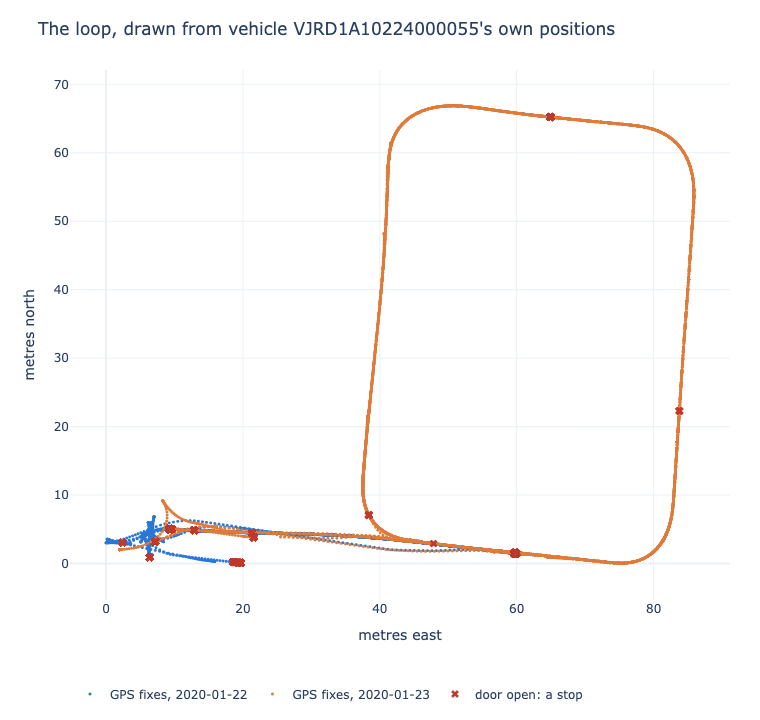

  north-south extent of the route, metres                            deck 67         computed 67
  east-west extent of the route, metres                              deck 86         computed 86
2020-01-22: 2nd-98th percentile of the fixes 8-60 m east, 0-6 m north; fixes more than 10 m north 1.9 %; moving readings with a negative speed 48.7 %
2020-01-23: 2nd-98th percentile of the fixes 7-85 m east, 1-65 m north; fixes more than 10 m north 27.3 %; moving readings with a negative speed 4.5 %
  rows in the vehicle file: computed here 48,290 rows, 22 columns, 1 vehicle, stated 53,155 rows and 22 columns from 2 vehicles — the slide counts the archive's bus file, which is not shipped; the labs ship the slice of one vehicle, and the route box is the same


In [40]:
bus = pd.read_csv("data/bus_slice.csv.gz", low_memory=False)
latitude0 = bus["lat"].mean()
east = (bus["lon"] - bus["lon"].min()) * 111320 * math.cos(math.radians(latitude0))
north = (bus["lat"] - bus["lat"].min()) * 111320
day = pd.to_datetime(bus["utc_time"], utc=True).dt.date.astype(str)
fig = go.Figure()
for which, colour in (("2020-01-22", "#2A78D6"), ("2020-01-23", "#E07B39")):
    here = day == which
    fig.add_scatter(x=east[here], y=north[here], mode="markers", marker=dict(size=3, color=colour),
                    name=f"GPS fixes, {which}")
doors = bus["door_state"].eq("opened")
fig.add_scatter(x=east[doors], y=north[doors], mode="markers", name="door open: a stop",
                marker=dict(size=7, color="#C0392B", symbol="x"))
fig.update_layout(title=f"The loop, drawn from vehicle {bus['vehicle_id'].iloc[0]}'s own positions",
                  xaxis_title="metres east", yaxis_title="metres north",
                  yaxis=dict(scaleanchor="x", scaleratio=1), legend=dict(orientation="h", y=-0.15))
show(fig, "route_map", width=760, height=720)
agrees("north-south extent of the route, metres", north.max(), 67, 0)
agrees("east-west extent of the route, metres", east.max(), 86, 0)
for which in ("2020-01-22", "2020-01-23"):
    here, moving = day == which, (day == which) & bus["speed"].ne(0)
    print(f"{which}: 2nd-98th percentile of the fixes {east[here].quantile(0.02):.0f}-{east[here].quantile(0.98):.0f} m east, "
          f"{north[here].quantile(0.02):.0f}-{north[here].quantile(0.98):.0f} m north; "
          f"fixes more than 10 m north {100 * (north[here] > 10).mean():.1f} %; "
          f"moving readings with a negative speed {100 * (bus.loc[moving, 'speed'] < 0).mean():.1f} %")
beside("rows in the vehicle file", f"{len(bus):,} rows, {bus.shape[1]} columns, "
       f"{bus['vehicle_id'].nunique()} vehicle", "53,155 rows and 22 columns from 2 vehicles",
       "the slide counts the archive's bus file, which is not shipped; the labs ship the slice "
       "of one vehicle, and the route box is the same")

**Goal.** Put the module's position on the data it will serve.

**Why.** The slide says labels cover 100 per cent of the first day and none of the second: next day no one is writing labels, which is why Module 5 exists.

**What the code does.** Reads the archive figure from Module 2's recorded `measured.json`, and measures the same share on the generated phone tables the labs use.

**So what.** The generated traces label both days, so the lab data cannot show the gap; the archive number is the slide's, and it is printed beside the lab data's.

In [41]:
module2 = json.loads((COURSE / "Module 2" / "slides" / "measured.json").read_text())
archive = module2["label_coverage_per_day"]["value"]
for which in ("2020-01-22", "2020-01-23"):
    generated = 100 * pd.read_parquet(f"data/phones_{which}.parquet")["label2"].notna().mean()
    beside(f"rows carrying a label on {which}, per cent", f"{generated:.1f} (generated phones)",
           f"{archive[which]:.1f} (archive, Module 2's measured.json)",
           "make_phones.py labels every row it generates; only the archive lacks the second day's labels")

  rows carrying a label on 2020-01-22, per cent: computed here 100.0 (generated phones), stated 100.0 (archive, Module 2's measured.json) — make_phones.py labels every row it generates; only the archive lacks the second day's labels
  rows carrying a label on 2020-01-23, per cent: computed here 100.0 (generated phones), stated 0.0 (archive, Module 2's measured.json) — make_phones.py labels every row it generates; only the archive lacks the second day's labels


---
## Block one — Keeping a record, and releasing a model

*Slides: "A model measured once in a notebook cannot answer for itself later",
"Three words for this block are the record, the artefact and the metric" and "A
training run writes five facts down while it is happening".*

A notebook measures a model once, on questions its author already holds. A service
answers questions it has never seen, sent by another program, months later — and
must name the model behind any past answer and say what it was trained on. That
record cannot be reconstructed afterwards, so a training run writes five facts
while it happens: the settings, the metric the gate will use (agreed before any
candidate existed), the environment with every version fixed, the window of data
and a checksum of it, and the artefact — the model and its preparation saved as one
file (Schelter et al., 2018). `log_to_registry()` above wrote exactly these.

### The model registry, release and rollback

*Slides: "Definition — the model registry", "A release is done in five steps, and the service is not one of them" and "A rollback is the release done backwards, in three steps".*

**Goal.** Define the gate and the rollback as the Lab 1 solution writes them.

**Why.** A registry is a list of saved versions with one entry naming the version in service. With each version's metadata and lineage recorded — who trained it, with which settings, on which data — "which model, trained on what?" becomes a query rather than an investigation (Schelter et al., 2018, § 2).

**What the code does.** Copies the lab's agreed metric and `promote_if_better` and `rollback` from `solutions/lab_01.py`, with their docstrings. The docstrings credit these definitions to Zaharia et al. (2018), as the deck does; that paper describes MLflow's run record, not this registry (see the closing notes).

**So what.** Promotion is one write to one entry; rollback is the same write backwards, which is why it can be trusted at three in the morning.

In [42]:
# Source: Module 3/exercises/solutions/lab_01.py — LAB, METRIC, HIGHER_IS_BETTER, promote_if_better, rollback, verbatim
# References: (Schelter et al., 2018, § 2)

import json
import pathlib
import sys
import tempfile
import mlflow
import mlflow.sklearn
import pandas as pd
from mlflow.models import infer_signature
from mlflow.tracking import MlflowClient


LAB = 1


METRIC = "accuracy"


HIGHER_IS_BETTER = True


def promote_if_better(registry: dict, candidate: str, metrics: dict):
    """Promote only on the agreed metric, and say why when you do not.

    Definition graded by the check:
        promote(candidate) ⇔ m(candidate) > m(approved) + δ, with δ = 0 here (a tie is refused) and δ = 0.01 in Module 5
        (Zaharia et al., 2018). Slide: "Definition — the gate".

    The thing worth noticing is what this function refuses to look at. It does
    not know how large the candidate is, how new it is, how long it took to
    train, how much it cost, or who is keen on it. It compares one number.

    That narrowness is the whole value. Every one of those other properties is
    an argument somebody will make in a meeting, and the gate exists precisely
    so that the argument has already been settled — in the open, before there
    was a candidate to be enthusiastic about.

    The margin is a choice, and it is written down: nought here, so that a tie
    is refused; one point in Module 5. Module 4's Wilson interval on the number
    of labels is where a principled margin comes from — a difference smaller
    than the label noise is not a difference.
    """
    approved = registry["approved"]
    if candidate not in metrics:
        return False, f"candidate {candidate} has no measured metrics"
    if approved not in metrics:
        return False, f"approved model {approved} has no measured metrics"

    candidate_score = metrics[candidate][METRIC]
    approved_score = metrics[approved][METRIC]
    better = candidate_score > approved_score if HIGHER_IS_BETTER else candidate_score < approved_score

    if not better:
        return False, (
            f"candidate {candidate} scored {candidate_score:.4f} on {METRIC} against "
            f"approved {approved} at {approved_score:.4f}; not promoted")

    registry["approved"] = candidate
    # History is append-only, so that rollback is a step backwards rather than
    # an archaeology exercise.
    registry.setdefault("history", []).append(candidate)
    return True, (
        f"candidate {candidate} scored {candidate_score:.4f} on {METRIC} against "
        f"approved {approved} at {approved_score:.4f}; promoted")


def rollback(registry: dict) -> str:
    """Step the pointer back. The same move as promotion, in reverse.

    Definition graded by the check:
        serve(name) = artefact[approved]; promote: approved ← candidate, history ← history + [candidate]; rollback: history ← history[:−1], approved ← history[−1]
        (Zaharia et al., 2018; Schelter et al., 2018). Slide: "Definition — release by indirection".

    Worth saying out loud: rollback is not a special emergency procedure. It is
    the ordinary release mechanism run backwards, which is exactly why it can be
    trusted at three in the morning. A rollback path that is a different
    mechanism from the release path is a rollback path nobody has tested.
    """
    history = registry.get("history", [])
    if len(history) < 2:
        return registry["approved"]          # nothing to go back to
    history.pop()
    registry["approved"] = history[-1]
    return registry["approved"]

**Goal.** Ask the fifty-line registry to release the candidate.

**Why.** The candidate is bigger, newer, slower — and worse on the agreed metric.

**What the code does.** Reads `registry.json`, asks `promote_if_better` about v2 on a copy, and prints the registry after the refusal.

**So what.** Refused, with a reason quoting both scores, and the pointer exactly where it was.

In [43]:
registry_now = json.loads(registry_path().read_text())
print("registry.json:", registry_now)
trial = json.loads(json.dumps(registry_now))
print("promote v2?", promote_if_better(trial, "v2", METRICS))
print("after the refusal:", trial, "- unchanged:", trial == registry_now)

registry.json: {'approved': 'v1', 'history': ['v1']}
promote v2? (False, 'candidate v2 scored 0.7291 on accuracy against approved v1 at 0.8180; not promoted')
after the refusal: {'approved': 'v1', 'history': ['v1']} - unchanged: True


### Registries in practice, and release by indirection

*Slides: "Commercial model registries in practice" and "Definition — release by indirection".* The first slide shows vendors' logos and screenshots (MLflow, SageMaker, Azure ML, Vertex AI, Databricks Unity Catalog, Weights & Biases); they are not reproduced. In the MLOps architecture derived by Kreuzberger, Kühl & Hirschl (2023), the model registry is component C6, which stores the trained models with their metadata; MLflow, SageMaker and Azure ML are among their examples.

**Goal.** Write the definition of release by indirection.

**Why.** The service loads whichever artefact the entry marks approved, so a release never touches the service's code. MLOps tools call the pattern model aliasing — MLflow's `@champion`; general software calls it the pointer or symlink pattern.

**What the code does.** Writes the three statements of the definition card in sympy — a promotion or a rollback is written as the value of the entry after the move, approved′ — then checks them on the registry: promote a hypothetical better candidate, then roll back.

**So what.** The entry moves; the service's code does not. Indirection must not be relied on when the new model expects different input columns — that is what the signature is for.

In [44]:
entry_name, entry = sp.Symbol(r"\mathrm{name}"), sp.Symbol(r"\mathrm{approved}")
entry_after = sp.Symbol(r"\mathrm{approved}'")          # the entry after the move
entry_history = sp.IndexedBase(r"\mathrm{history}")
formula(sp.Eq(sp.Function(r"\mathrm{serve}")(entry_name), sp.Function(r"\mathrm{artefact}")(entry)))
formula(sp.Implies(sp.Symbol(r"\mathrm{promote}"), sp.Eq(entry_after, sp.Symbol(r"\mathrm{candidate}"))),
        sp.Implies(sp.Symbol(r"\mathrm{rollback}"), sp.Eq(entry_after, entry_history[-1])))
better = {version: dict(facts) for version, facts in METRICS.items()}
better["v2"]["accuracy"] = round(METRICS["v1"]["accuracy"] + 0.05, 4)
trial = json.loads(json.dumps(registry_now))
print("promote a hypothetical v2 five points better:", promote_if_better(trial, "v2", better)[0], trial)
print("rollback ->", rollback(trial), trial)

<IPython.core.display.Math object>

<IPython.core.display.Math object>

promote a hypothetical v2 five points better: True {'approved': 'v2', 'history': ['v1', 'v2']}
rollback -> v1 {'approved': 'v1', 'history': ['v1']}


### The same record in MLflow

*Slides: "MLflow: record, signature and registry", "Definition — model signature", "The signature checks a request in four steps before the model sees it" and "Definition — release by alias".* MLflow is free software that writes one record per training run (Zaharia et al., 2018, § 3). The slide shows a screenshot of the MLflow demonstration server, which is not reproduced; the next cell reads the module's own store instead.

**Goal.** Read back what the store recorded for the two training runs.

**Why.** The record is only worth something if it can be queried months later.

**What the code does.** Opens the working copy's MLflow store and lists, for each run, the settings, the data window and checksum, the metrics, and the registered version with its aliases.

**So what.** One registered model, `aboard`, two versions, and the alias `champion` on version 1. (Zaharia et al. describe tracking, projects and models; the registry and its aliases were added to MLflow later, and are documented with the tool rather than in that paper.)

In [45]:
client = open_store()
experiment = client.get_experiment_by_name(EXPERIMENT)
versions = {int(v.version): v for v in client.search_model_versions(f"name='{REGISTERED_MODEL}'")}
record = []
for run in sorted(client.search_runs([experiment.experiment_id]), key=lambda r: r.info.run_name):
    version = next(v for v in versions.values() if v.run_id == run.info.run_id)
    record.append({"run": run.info.run_name, "registered version": int(version.version),
                   "aliases": ", ".join(sorted(version.aliases)),
                   "n_estimators": run.data.params["n_estimators"], "max_depth": run.data.params["max_depth"],
                   "data checksum": run.data.params["data_checksum"][:16] + "…",
                   "accuracy": run.data.metrics["accuracy"], "size_bytes": int(run.data.metrics["size_bytes"])})
display(pd.DataFrame(record).set_index("run"))

,registered version,aliases,n_estimators,max_depth,data checksum,accuracy,size_bytes
run,,,,,,,
v1,1,,100,6,377d063229c227cf…,0.8180,368336
v2,2,,500,None,377d063229c227cf…,0.7291,94917711


**Goal.** Write the signature the store records, and read the champion's.

**Why.** A model knows its columns by position. The signature is the list of names, types and order recorded with it, enforced every time it is asked (Breck et al., 2019).

**What the code does.** Writes the three statements of the definition card in sympy, entry by entry for i = 1 … k — acceptance as a product of indicators, one per entry — then loads `models:/aboard@champion` and prints the input names the platform will enforce.

**So what.** speed, rssi1, rssi2, rssiC, in that order. A signature must not be trusted to catch a column whose name is right and unit wrong.

In [46]:
i_, k_ = sp.Symbol("i", integer=True), sp.Symbol("k", integer=True, positive=True)
S_, names_, types_ = sp.IndexedBase("S"), sp.IndexedBase(r"\mathrm{name}"), sp.IndexedBase(r"\mathrm{type}")
x_ = sp.Symbol("x")
column_of = lambda j: sp.Symbol(rf"x[\mathrm{{name}}_{{{j}}}]")
for_each_entry = sp.And(sp.Le(1, i_), sp.Le(i_, k_))
indicator = sp.Function(r"\mathbf{1}")
formula(sp.Eq(S_[i_], sp.Tuple(names_[i_], types_[i_]), evaluate=False), for_each_entry)
# "for every i" as a product of indicators, since sympy has no quantifier
formula(sp.Eq(indicator(sp.Function(r"\mathrm{accept}")(x_)),
              sp.Product(indicator(sp.And(sp.Symbol(r"\mathrm{name}_i \in \mathrm{columns}(x)"),
                                          sp.Eq(sp.Function(r"\mathrm{type}")(column_of("i")), types_[i_]))),
                         (i_, 1, k_))))
formula(sp.Eq(sp.Indexed(sp.IndexedBase(r"\mathrm{input}"), i_), column_of("i")), for_each_entry)
champion_model = load_registered(CHAMPION)
enforced = champion_model.metadata.get_input_schema().input_names()
print("the champion's signature:", enforced)
assert enforced == FEATURES

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

the champion's signature: ['speed', 'rssi1', 'rssi2', 'rssiC']


**Goal.** Define the logging of a training run and the alias move, as the Lab 1 solution writes them.

**Why.** Part (b) of Lab 1: the same two models in a real registry, with their signature, and release as the move of one alias.

**What the code does.** Copies `log_training_run` and `promote_by_alias` from `solutions/lab_01.py`. Their docstrings credit the signature to Zaharia et al. (2018), as the deck does; that paper describes the run record only (see the closing notes).

**So what.** Logging a run registers a new version; promoting moves one alias.

In [47]:
# Source: Module 3/exercises/solutions/lab_01.py — log_training_run, promote_by_alias, verbatim
# References: (Zaharia et al., 2018, § 3, the run record only — the signature, registry and alias are the deck's attribution, see the closing notes)

import json
import pathlib
import sys
import tempfile
import mlflow
import mlflow.sklearn
import pandas as pd
from mlflow.models import infer_signature
from mlflow.tracking import MlflowClient


def log_training_run(name: str, model, X, y_pred, params: dict, metrics: dict) -> int:
    """One run, recorded as it happens; the model becomes a version of one name.

    Definition graded by the check:
        S = (name_i, type_i)_{i=1..k}, recorded with the model; accept(x) ⇔ ∀i: name_i ∈ columns(x) ∧ type(x[name_i]) = type_i; input = (x[name_1], …, x[name_k])
        (Zaharia et al., 2018). Slide: "Definition — model signature".

    Four things are written inside the run, and each answers a question that
    otherwise needs an investigation months later. The parameters: what was
    set. The metrics: what was measured, on the agreed metric. The environment:
    which library versions can unpickle this artefact — recorded from the
    process that trained it, not reconstructed from a file. And the model with
    its signature: the names, types and order of the columns it was trained on,
    which the platform enforces on every request from now on.
    """
    with mlflow.start_run(run_name=name):
        mlflow.log_params(params)
        mlflow.log_metrics(metrics)
        info = mlflow.sklearn.log_model(
            model, artifact_path="model",
            serialization_format=mlflow.sklearn.SERIALIZATION_FORMAT_CLOUDPICKLE,
            signature=infer_signature(X, y_pred),
            input_example=X.head(2),
            registered_model_name=REGISTERED_MODEL,
            pyfunc_predict_fn="predict_proba",       # the service needs the probability
            pip_requirements=environment_pins())      # the environment, as it actually is
    return int(info.registered_model_version)


def promote_by_alias(client: MlflowClient, name: str, version, alias: str = CHAMPION) -> str:
    """Release is moving the alias. Rollback is moving it back.

    Definition graded by the check:
        alias: name@alias → version; promote: alias[champion] ← version; rollback: alias[champion] ← previous version; serve(models:/name@champion)
        (Zaharia et al., 2018). Slide: "Definition — release by alias".

    The service loads models:/aboard@champion. It never learns a version
    number, so a release changes nothing in the service and a rollback is this
    same call with the previous version — the fifty-line registry of part (a),
    kept by a platform.
    """
    client.set_registered_model_alias(name, alias, str(version))
    return str(client.get_model_version_by_alias(name, alias).version)

**Goal.** Write the definition of release by alias, and read where the two aliases point.

**Why.** An alias is the fifty-line registry's `approved` entry, kept by the platform: the service asks for a name and an alias, and the registry answers with a version.

**What the code does.** Writes the three statements of the definition card in sympy — the alias as a function from (name, alias) to a version, and a move as its value afterwards, alias′ — then asks the store where `champion` and `challenger` point.

**So what.** The service resolves `models:/aboard@champion` and never learns a version number.

In [48]:
alias_of, alias_after = sp.Function(r"\mathrm{alias}"), sp.Function(r"\mathrm{alias}'")
champion_ = (sp.Symbol(r"\mathrm{name}"), sp.Symbol(r"\mathrm{champion}"))
formula(sp.Eq(alias_of(*champion_), sp.Symbol(r"\mathrm{version}")))
formula(sp.Implies(sp.Symbol(r"\mathrm{promote}"), sp.Eq(alias_after(*champion_), sp.Symbol(r"\mathrm{version}_{\mathrm{new}}"))),
        sp.Implies(sp.Symbol(r"\mathrm{rollback}"), sp.Eq(alias_after(*champion_), sp.Symbol(r"\mathrm{version}_{\mathrm{previous}}"))))
print("champion ->", client.get_model_version_by_alias(REGISTERED_MODEL, CHAMPION).version,
      "  challenger ->", client.get_model_version_by_alias(REGISTERED_MODEL, CHALLENGER).version)

<IPython.core.display.Math object>

<IPython.core.display.Math object>

champion -> 1   challenger -> 2


### The promotion metric, and what feeds it

*Slides: "A metric is measured against labels, and the labels are measurements too",
"Definition — the promotion metric", "What feeds the metric — four drivers, measured
on this module's two models" and "Weights — how much each driver counts".*

A label is itself a measurement, written by a person, and its error rate is not
nought — so the gate needs a margin. The promotion metric is one number, agreed
before any candidate exists; here it is accuracy on later rows neither model trained
on. One number is a deliberate simplification: it is fed by several drivers, and a
driver weighted zero is lost. This module gives every driver except accuracy a
weight of zero, and says so.

**Goal.** Bring in the deck's figure code, so the slides' figures are drawn by the slides' own functions.

**Why.** Five figures of 3.1 and 3.2 come from `slides/make_figs.py`, and it also measures the work each forest does per request.

**What the code does.** Copies the palette, the prices, the departure constants and the measuring functions from `make_figs.py`, verbatim.

**So what.** From here on a figure labelled *the slide's own code* is the deck's figure, recomputed from the models trained above.

In [49]:
# Source: Module 3/slides/make_figs.py — BLUE, COST_FALSE_POSITIVE, SEATS, CONTRACT_SPEED_MARGIN, scored_test_set, measure_work_per_request, total_cost, cost_of_always_aboard, cost_of_always_not_aboard, cheapest_threshold, jensen_departure, load_artefact_model, verbatim

import json
import sys
from pathlib import Path
import numpy as np
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from scipy import stats


# The course palette: reference blue, current orange, neutral grey, and red only
# for what fails.
BLUE, ORANGE, GREY, RED = "#2A78D6", "#E07B39", "#52514E", "#C0392B"


COST_FALSE_POSITIVE, COST_FALSE_NEGATIVE = 1.0, 4.0


# The departure Modules 3 and 4 share. Twelve seats, demand Poisson with mean
# ten: the same prices as the threshold above, read as a capacity decision.
SEATS, MEAN_DEMAND = 12, 10.0


# The contract's speed bounds are Module 1's measured range for this vehicle,
# widened by a margin that is stated rather than folded in. Lab 2 declares the
# same margin; check 2 grades the relation between the two.
CONTRACT_SPEED_MARGIN = 1.0


def scored_test_set():
    """The champion's probabilities on the later stretch of time, and the truth."""
    from service.models import load_artefact, build_table, apply_transform

    artefact = load_artefact("v1")
    table = build_table()
    test = table.iloc[int(len(table) * 0.7):]
    prepared = apply_transform(test, artefact["transform"]).to_numpy()
    probabilities = artefact["model"].predict_proba(prepared)[:, 1]
    truth = (test["label2"] == "IN").astype(int).to_numpy()
    return artefact, prepared, probabilities, truth


def measure_work_per_request(model, prepared):
    """How much work the model does to answer one request, counted exactly.

    This replaced a wall-clock timing. The timing was measured by committed code
    and was still not reproducible: two consecutive rebuilds of measured.json
    disagreed by roughly a factor of two, because a duration is a property of the
    machine and the moment as much as of the model. Both values reached a slide,
    and tools/check_determinism.sh names "a timing measurement" as exactly the
    kind of wobble that has to be pinned before a deck is trusted.

    So the deck reports the work instead. A forest answers by walking each tree
    from its root to a leaf, and `decision_path` gives the nodes actually visited
    for each row, so this is a count of the comparisons performed, not an
    estimate of them. It is the same on every machine, in every run, forever.

    It is deliberately *not* a prediction of the latency: a real request also
    pays a fixed per-call overhead that belongs to the runtime rather than to the
    model. Block four's slide says so.
    """
    visited, _ = model.decision_path(prepared)
    per_request = np.asarray(visited.sum(axis=1)).ravel()
    return {"trees": int(len(model.estimators_)),
            "nodes_in_the_forest": int(sum(tree.tree_.node_count
                                           for tree in model.estimators_)),
            "decision_nodes_per_request": round(float(per_request.mean()), 1)}


def total_cost(probabilities, truth, threshold):
    """The realised cost of these decisions, on the rule the whole module uses.

    Aboard when the probability is at or above the threshold. For a continuous
    score the choice between >= and > moves nothing, and it is still made once
    here so that the stub, the check, the figures and the slides cannot drift
    apart.
    """
    said = probabilities >= threshold
    false_positive = int((said & (truth == 0)).sum())
    false_negative = int(((~said) & (truth == 1)).sum())
    return false_positive * COST_FALSE_POSITIVE + false_negative * COST_FALSE_NEGATIVE


def cost_of_always_aboard(truth):
    """Say "aboard" to everybody. Every not-aboard row is then a false positive."""
    return int((truth == 0).sum()) * COST_FALSE_POSITIVE


def cost_of_always_not_aboard(truth):
    """Say "not aboard" to everybody. Every aboard row is then a false negative."""
    return int((truth == 1).sum()) * COST_FALSE_NEGATIVE


def cheapest_threshold(probabilities, truth):
    """The threshold that actually costs least, and what it costs.

    The cost is a step function: with the rule "aboard when p >= t" it can only
    change where a predicted probability sits, so the candidates are the
    predicted probabilities themselves. Scanning them is exact and needs no grid,
    which means the answer does not move when somebody changes the resolution of
    the sweep.
    """
    candidates = np.unique(probabilities)
    costs = [total_cost(probabilities, truth, t) for t in candidates]
    best = int(np.argmin(costs))
    return float(candidates[best]), costs[best]


def jensen_departure():
    """The shared worked example, computed exactly from the Poisson mass function.

    One departure: `SEATS` seats, demand D Poisson with mean `MEAN_DEMAND`. The
    passengers left standing are max(0, D - c), priced at C_fn each; that hinge
    is convex, so the cost of the average day is not the average cost of the days
    (Jensen, 1906). Module 4 proves the inequality and reads these numbers from
    Module 3, so this function is the single place they are computed.

    Exact sums, no simulation: the tail two hundred above the mean contributes
    less than 1e-300, and every machine gets the same digits.
    """
    demand = np.arange(0, int(MEAN_DEMAND) + 200)
    mass = stats.poisson.pmf(demand, MEAN_DEMAND)
    shortfall = float((np.maximum(0, demand - SEATS) * mass).sum())
    empty = float((np.maximum(0, SEATS - demand) * mass).sum())
    critical_fractile = COST_FALSE_NEGATIVE / (COST_FALSE_POSITIVE + COST_FALSE_NEGATIVE)
    cost_at_mean = COST_FALSE_NEGATIVE * max(0.0, MEAN_DEMAND - SEATS)
    mean_cost = COST_FALSE_NEGATIVE * shortfall
    return {
        "capacity_seats": SEATS,
        "mean_demand": MEAN_DEMAND,
        "demand_law": "Poisson",
        "price_false_positive": int(COST_FALSE_POSITIVE),
        "price_false_negative": int(COST_FALSE_NEGATIVE),
        "cost_at_mean_demand": round(cost_at_mean, 3),
        "mean_cost": round(mean_cost, 3),
        "jensen_gap": round(mean_cost - cost_at_mean, 3),
        "expected_shortfall_passengers": round(shortfall, 3),
        "expected_empty_seats": round(empty, 3),
        "probability_demand_exceeds_capacity": round(
            float(1 - stats.poisson.cdf(SEATS, MEAN_DEMAND)), 3),
        "critical_fractile": round(critical_fractile, 3),
        "capacity_at_critical_fractile": int(
            stats.poisson.ppf(critical_fractile, MEAN_DEMAND)),
        "cdf_at_capacity": round(float(stats.poisson.cdf(SEATS, MEAN_DEMAND)), 3),
    }


def load_artefact_model(version):
    from service.models import load_artefact
    return load_artefact(version)["model"]

**Goal.** Show the deck's figures in place, and score the test period once for every later cell.

**Why.** `make_figs.py`'s `write()` saves `figures/<name>.png` for the deck; a notebook should show the picture under the code that drew it. And Blocks one to four all ask the same question of the same rows: what did the model in service say on the test period?

**What the code does.** Defines `write()` with the script's layout, drawing the figure in place — the one function of `make_figs.py` that is not copied — then runs `scored_test_set()`: the approved artefact, its prepared test rows, its probabilities and the truth.

**So what.** 3,241 test rows, split by time, about half of them aboard.

In [50]:
def write(figure, name, height=620, width=1100):
    """make_figs.py's write(), shown in place instead of written to figures/."""
    figure.update_layout(template="plotly_white", font=dict(size=15),
                         title_font=dict(size=19), margin=dict(t=70, l=80, r=40, b=70))
    display(Image(figure.to_image(format="png", width=width, height=height, scale=1)))


ARTEFACT_V1, X_TEST, P_TEST, Y_TEST = scored_test_set()
print(f"test period: {len(Y_TEST):,} rows, {int(Y_TEST.sum()):,} aboard, "
      f"{int((Y_TEST == 0).sum()):,} not aboard")

test period: 3,241 rows, 1,578 aboard, 1,663 not aboard


**Goal.** Define the figure of the four drivers, as the deck's script writes it.

**Why.** Quality, operating cost, footprint and robustness. The slide draws the two drivers on which the two models differ most.

**What the code does.** Copies `figure_gate()` from `make_figs.py`, verbatim.

**So what.** The next cell draws it on this notebook's two models.

In [51]:
# Source: Module 3/slides/make_figs.py — figure_gate, verbatim

import json
import sys
from pathlib import Path
import numpy as np
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from scipy import stats


def figure_gate(metrics):
    """Three measures, three scales — so two panels, never two y-axes on one."""
    labels = ["v1<br>approved", "v2<br>candidate"]
    accuracy = [metrics[v]["accuracy"] for v in ("v1", "v2")]
    megabytes = [metrics[v]["size_bytes"] / 1e6 for v in ("v1", "v2")]

    figure = make_subplots(rows=1, cols=2,
                           subplot_titles=("What matters", "What is persuasive"))
    figure.add_trace(go.Bar(x=labels, y=accuracy, marker_color=[BLUE, ORANGE],
                            text=[f"{v:.4f}" for v in accuracy], textposition="outside",
                            showlegend=False), row=1, col=1)
    figure.add_trace(go.Bar(x=labels, y=megabytes, marker_color=[BLUE, ORANGE],
                            text=[f"{v:.1f}" for v in megabytes], textposition="outside",
                            showlegend=False), row=1, col=2)
    figure.update_yaxes(title_text="accuracy on later data (share of rows)",
                        range=[0, max(accuracy) * 1.3], row=1, col=1)
    figure.update_yaxes(title_text="artefact on disk (megabytes)",
                        range=[0, max(megabytes) * 1.3], row=1, col=2)
    figure.update_xaxes(title_text="model version", row=1, col=1)
    figure.update_xaxes(title_text="model version", row=1, col=2)
    write(figure, "gate", height=560)

**Goal.** Measure the four drivers on the two models and draw the two that differ most.

**Why.** Operating cost is counted, not timed: a forest answers by walking each tree from root to leaf, and `decision_path` counts the nodes visited, which is the same on every machine — a stopwatch is not.

**What the code does.** Runs `figure_gate()` on `metrics.json`, then counts decision nodes per request over the test period with `measure_work_per_request()`, and checks every number the slide prints.

**So what.** The candidate does 17.7 times the work and is 258 times larger on disk, for 8.9 points less accuracy. Only the first driver reaches the gate.

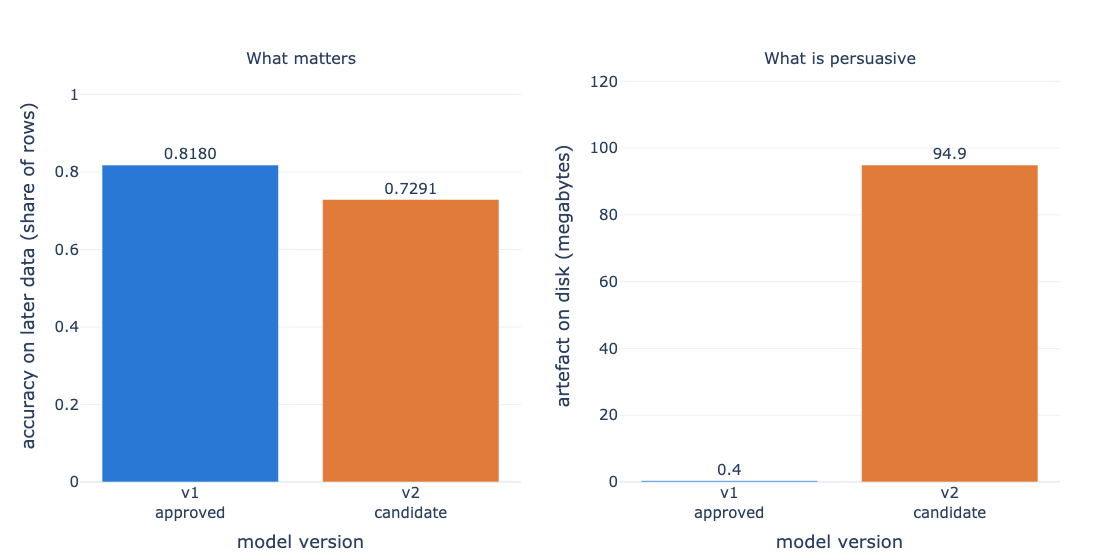

  accuracy on later rows, model in service                           deck 0.818      computed 0.818
  accuracy on later rows, candidate                                  deck 0.7291     computed 0.7291
  work per request, model in service (decision nodes)                deck 575.4      computed 575.4
  work per request, candidate (decision nodes)                       deck 10165.1    computed 10165.1
  the candidate's work, times the model in service's                 deck 17.7       computed 17.7
  size on disk, candidate, MB                                        deck 94.92      computed 94.92
  size on disk, model in service, MB                                 deck 0.37       computed 0.37
  how many times larger                                              deck 258        computed 258


In [52]:
figure_gate(METRICS)
WORK_PER_REQUEST = {v: measure_work_per_request(load_artefact_model(v), X_TEST) for v in ("v1", "v2")}
agrees("accuracy on later rows, model in service", METRICS["v1"]["accuracy"], 0.818, 3)
agrees("accuracy on later rows, candidate", METRICS["v2"]["accuracy"], 0.7291, 4)
agrees("work per request, model in service (decision nodes)", WORK_PER_REQUEST["v1"]["decision_nodes_per_request"], 575.4, 1)
agrees("work per request, candidate (decision nodes)", WORK_PER_REQUEST["v2"]["decision_nodes_per_request"], 10165.1, 1)
WORK_MULTIPLE = round(WORK_PER_REQUEST["v2"]["decision_nodes_per_request"] / WORK_PER_REQUEST["v1"]["decision_nodes_per_request"], 1)
agrees("the candidate's work, times the model in service's", WORK_MULTIPLE, 17.7, 1)
agrees("size on disk, candidate, MB", METRICS["v2"]["size_bytes"] / 1e6, 94.92, 2)
agrees("size on disk, model in service, MB", METRICS["v1"]["size_bytes"] / 1e6, 0.37, 2)
agrees("how many times larger", METRICS["v2"]["size_bytes"] / METRICS["v1"]["size_bytes"], 258, 0)

### Value and cost, both in euro

*Slides: "Definition — value and cost, both in euro", "Figure — the Pareto front in cost and value" and "Boiled down — the same gate, as five MLflow calls".* (The weighted cost function and the Pareto front in accuracy and work are on hidden slides and are not reproduced.)

**Goal.** Write value, cost and net benefit, and work the slide's example for the model in service.

**Why.** With both sides in euro no weights are needed: the best option is the one with the largest net benefit V − C (Provost & Fawcett, 2013, ch. 7).

**What the code does.** Builds the three definitions in sympy and evaluates them with the slide's illustrative prices — a million requests a year, 1 € gross value per request, 2 € per mistake, 10⁻⁵ € per unit of work, 100 € per development hour, 200 hours — and the model's measured accuracy (0.818 at the cutoff 0.5) and work (575.4 nodes).

**So what.** V = 6.36 × 10⁵ €, C = 2.58 × 10⁴ €, net 6.10 × 10⁵ €, as on the slide.

In [53]:
R, g, e_m, e_w, e_h, h, acc, wk = sp.symbols(r"R g e_{m} e_{w} e_{h} h a w", positive=True)
V_expr = R * g - R * (1 - acc) * e_m                  # the latency and size penalties are nought here
C_expr = h * e_h + R * wk * e_w
V_, C_ = sp.symbols("V C")
penalty = lambda what: sp.Symbol(rf"P_{{\mathrm{{{what}}}}}")
formula(sp.Eq(C_, sp.Add(sp.Symbol(r"C_{\mathrm{development}}"), sp.Symbol(r"C_{\mathrm{operation}}"), evaluate=False)),
        sp.Eq(V_, sp.Add(sp.Symbol(r"V_{\mathrm{gross}}"), -penalty("mistakes"), -penalty("latency"), -penalty("size"),
                         evaluate=False)),
        sp.Eq(sp.Symbol(r"\mathrm{Net}"), sp.Add(V_, -C_, evaluate=False)))
formula(sp.Eq(sp.Symbol(r"P_{\mathrm{mistakes}}"), R * (1 - acc) * e_m, evaluate=False),
        sp.Eq(sp.Symbol(r"C_{\mathrm{operation}}"), R * wk * e_w, evaluate=False))
PRICES = {R: 10**6, g: 1, e_m: 2, e_w: sp.Rational(1, 10**5), e_h: 100, h: 200}
V_service = float(V_expr.subs(PRICES | {acc: sp.Rational(818, 1000)}))
C_service = float(C_expr.subs(PRICES | {wk: sp.Float(WORK_PER_REQUEST["v1"]["decision_nodes_per_request"])}))
agrees("V, model in service, 10^5 euro", V_service / 1e5, 6.36, 2)
agrees("C, model in service, 10^4 euro", C_service / 1e4, 2.58, 2)
agrees("net benefit, model in service, 10^5 euro", (V_service - C_service) / 1e5, 6.10, 2)

<IPython.core.display.Math object>

<IPython.core.display.Math object>

  V, model in service, 10^5 euro                                     deck 6.36       computed 6.36
  C, model in service, 10^4 euro                                     deck 2.58       computed 2.58
  net benefit, model in service, 10^5 euro                           deck 6.1        computed 6.1


**Goal.** Redraw the slide's Pareto front in cost and value, and place the two measured models on it.

**Why.** An option is dominated if another is both cheaper and more valuable; the options nobody dominates are the only ones worth arguing about, and in euro the best of them is the one with the largest V − C.

**What the code does.** Draws the slide's seven points and its two lines from the chart's own values — five of the seven options are illustrative — then computes the model in service's point and the candidate's from their measured accuracy and work at the slide's prices, and the line of equal net benefit through tuned boosting, V − C = 6.25 × 10⁵ €.

**So what.** The model in service lands on the slide's point. The candidate does not: its position on the slide needs penalties and development hours the deck does not state. The slide's dashed line is also a little steeper than a line of equal net benefit.

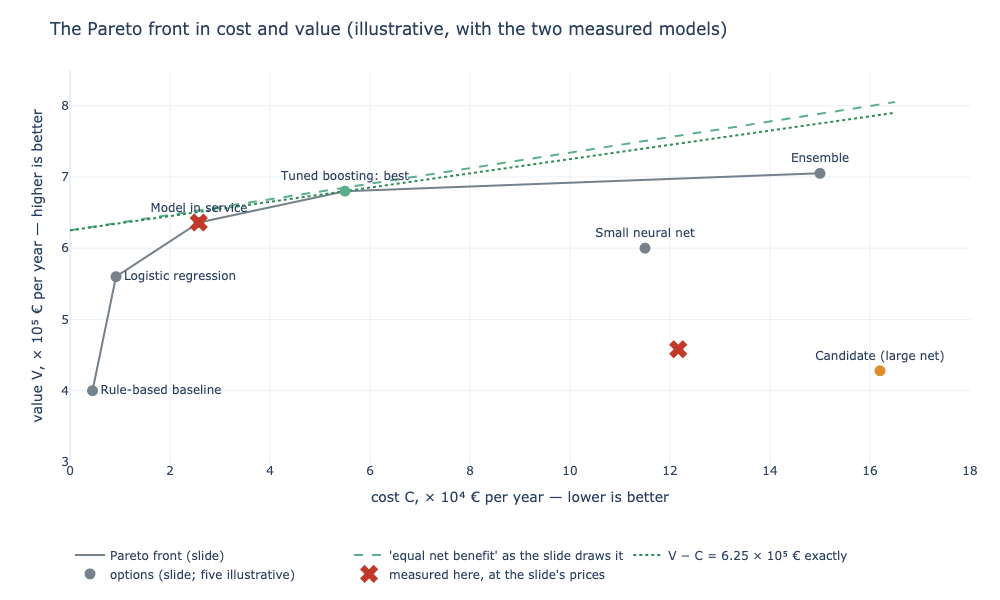

  tuned boosting's net benefit, 10^5 euro (6.80 - 0.55)              deck 6.25       computed 6.25
  its lead over the model in service, 10^4 euro                      deck 1.5        computed 1.5
  candidate, V and C at the slide's prices (10^5 and 10^4 euro): computed here 4.58 and 12.17, stated 4.28 and 16.2 — the slide adds latency and size penalties, and more development hours, that it does not state
  slope of the slide's dashed line: computed here 0.109 (10^5 € per 10^4 €), stated 0.100 for equal V − C — the dashed line ends at 8.05 where equal net benefit gives 7.90; it misses tuned boosting by 0.05 × 10^5 €


In [54]:
names = ["Rule-based baseline", "Logistic regression", "Model in service", "Tuned boosting: best",
         "Small neural net", "Ensemble", "Candidate (large net)"]
cost_1e4 = [0.45, 0.92, 2.58, 5.5, 11.5, 15, 16.2]           # the slide's chart values
value_1e5 = [4, 5.6, 6.36, 6.8, 6, 7.05, 4.28]
front = [0, 1, 2, 3, 5]
fig = go.Figure()
fig.add_scatter(x=[cost_1e4[i] for i in front], y=[value_1e5[i] for i in front], mode="lines",
                line=dict(color="#76818B", width=2), name="Pareto front (slide)")
fig.add_scatter(x=[0, 16.5], y=[6.25, 8.05], mode="lines", line=dict(color="#5CAF8D", dash="dash"),
                name="'equal net benefit' as the slide draws it")
fig.add_scatter(x=[0, 16.5], y=[6.25, 6.25 + 1.65], mode="lines", line=dict(color="#2E8B57", dash="dot"),
                name="V − C = 6.25 × 10⁵ € exactly")
fig.add_scatter(x=cost_1e4, y=value_1e5, mode="markers+text", text=names,
                textposition=["middle right", "middle right"] + ["top center"] * 5,
                marker=dict(size=11, color=["#76818B"] * 3 + ["#5CAF8D"] + ["#76818B"] * 2 + ["#DF8E2E"]),
                name="options (slide; five illustrative)")
C_candidate = float(C_expr.subs(PRICES | {wk: sp.Float(WORK_PER_REQUEST["v2"]["decision_nodes_per_request"])}))
V_candidate = float(V_expr.subs(PRICES | {acc: sp.Rational(7291, 10000)}))
fig.add_scatter(x=[C_service / 1e4, C_candidate / 1e4], y=[V_service / 1e5, V_candidate / 1e5],
                mode="markers", marker=dict(size=16, symbol="x", color="#C0392B"),
                name="measured here, at the slide's prices")
fig.update_layout(title="The Pareto front in cost and value (illustrative, with the two measured models)",
                  xaxis_title="cost C, × 10⁴ € per year — lower is better",
                  yaxis_title="value V, × 10⁵ € per year — higher is better",
                  xaxis_range=[0, 18], yaxis_range=[3, 8.5], legend=dict(orientation="h", y=-0.2))
show(fig, "pareto_cost_value", height=600)
agrees("tuned boosting's net benefit, 10^5 euro (6.80 - 0.55)", 6.80 - 0.55, 6.25, 2)
agrees("its lead over the model in service, 10^4 euro", (6.25e5 - 6.10e5) / 1e4, 1.5, 1)
beside("candidate, V and C at the slide's prices (10^5 and 10^4 euro)",
       f"{V_candidate / 1e5:.2f} and {C_candidate / 1e4:.2f}", "4.28 and 16.2",
       "the slide adds latency and size penalties, and more development hours, that it does not state")
beside("slope of the slide's dashed line", f"{(8.05 - 6.25) / 16.5:.3f} (10^5 € per 10^4 €)", "0.100 for equal V − C",
       "the dashed line ends at 8.05 where equal net benefit gives 7.90; it misses tuned boosting by 0.05 × 10^5 €")

**Goal.** Compute the promotion cost J = 1 − accuracy the slide logs to MLflow.

**Why.** With every weight but accuracy at nought, the cost function is one minus accuracy, and the gate compares it for the two versions.

**What the code does.** Evaluates J for both.

**So what.** 0.2709 against 0.182: higher cost, so the alias stays on v1.

In [55]:
agrees("J for the candidate", 1 - METRICS["v2"]["accuracy"], 0.2709, 4)
agrees("J for the champion", 1 - METRICS["v1"]["accuracy"], 0.182, 3)

  J for the candidate                                                deck 0.2709     computed 0.2709
  J for the champion                                                 deck 0.182      computed 0.182


### The gate and the promotion verdict

*Slides: "Definition — the gate" and "Definition — the promotion verdict".*

**Goal.** Write the gate, and draw the comparison the slide draws.

**Why.** A candidate is promoted only if it beats the model in service by more than the margin δ, which is nought here, so an equal score is refused.

**What the code does.** Writes the rule in sympy and evaluates it on the two measured accuracies, and on a tie.

**So what.** 0.0889 short: refused; and a tie is refused too.

In [56]:
m_c, m_a, delta = (sp.Symbol(r"m(\mathrm{candidate})"), sp.Symbol(r"m(\mathrm{approved})"), sp.Symbol(r"\delta"))
gate_rule = sp.StrictGreaterThan(m_c, sp.Add(m_a, delta, evaluate=False))
formula(sp.Equivalent(sp.Symbol(r"\mathrm{promote}(\mathrm{candidate})"), gate_rule))
decided = gate_rule.subs({m_c: METRICS["v2"]["accuracy"], m_a: METRICS["v1"]["accuracy"], delta: 0})
print("promote the candidate?", bool(decided))
print("a tie promoted?", bool(gate_rule.subs({m_c: 0.818, m_a: 0.818, delta: 0})))

<IPython.core.display.Math object>

promote the candidate? False
a tie promoted? False


**Goal.** Draw the comparison the slide draws, from `metrics.json`.

**Why.** The slide shows the two scores as bars on one accuracy axis, with the model in service as the line to beat.

**What the code does.** Draws the two accuracies as horizontal bars with the line at the model in service, and records the one difference from the slide.

**So what.** The slide's drawn caption reads "≥", while its definition, the lab and the check use ">" — at δ = 0 only ">" refuses a tie.

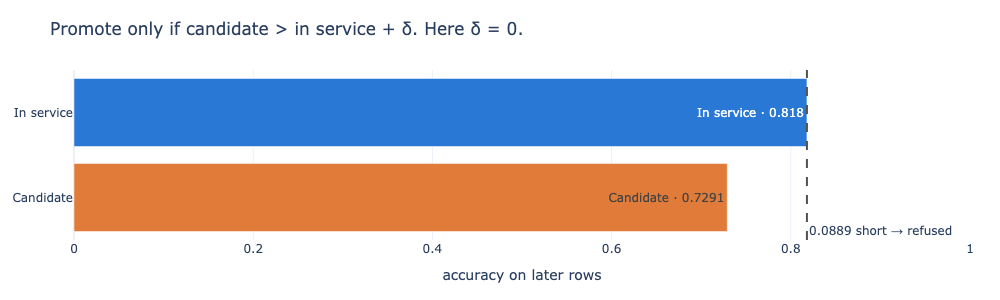

  the candidate's shortfall                                          deck 0.0889     computed 0.0889
  the rule the slide's drawn caption states: computed here candidate > in service + δ (definition, lab, check), stated candidate ≥ in service + δ — a slip in the drawing; with δ = 0 the '≥' would promote a tie, which the definition card and Lab 1 refuse


In [57]:
shortfall = METRICS["v1"]["accuracy"] - METRICS["v2"]["accuracy"]
fig = go.Figure(go.Bar(y=["Candidate", "In service"], x=[METRICS["v2"]["accuracy"], METRICS["v1"]["accuracy"]],
                       orientation="h", marker_color=["#E07B39", "#2A78D6"],
                       text=[f"Candidate · {METRICS['v2']['accuracy']:.4f}", f"In service · {METRICS['v1']['accuracy']:.3f}"],
                       textposition="inside"))
fig.add_vline(x=METRICS["v1"]["accuracy"], line=dict(color="#52514E", dash="dash"),
              annotation_text=f"{shortfall:.4f} short → refused", annotation_position="bottom right")
fig.update_layout(title="Promote only if candidate > in service + δ. Here δ = 0.",
                  xaxis_title="accuracy on later rows", xaxis_range=[0, 1], showlegend=False)
show(fig, "gate_bar", height=300)
agrees("the candidate's shortfall", shortfall, 0.0889, 4)
beside("the rule the slide's drawn caption states", "candidate > in service + δ (definition, lab, check)",
       "candidate ≥ in service + δ", "a slip in the drawing; with δ = 0 the '≥' would promote a tie, "
                                      "which the definition card and Lab 1 refuse")

**Goal.** Write the promotion verdict.

**Why.** The gate compares one number. The release decision is made by a person who sees everything the gate refuses to look at, in the unit the operator pays in.

**What the code does.** Writes the three rules of the definition card in sympy, with hold as neither of the other two.

**So what.** Three calls, each a condition on measured numbers.

In [58]:
m_ = sp.Function("m")
K_ = sp.Function("K")
delta_back = sp.Symbol(r"\delta_r")
roll_back = sp.Lt(m_(sp.Symbol(r"\mathrm{now}")),
                  sp.Add(m_(sp.Symbol(r"\mathrm{at\ promotion}")), -delta_back, evaluate=False))
promote_call = sp.And(sp.Lt(K_(sp.Symbol(r"\mathrm{candidate}")), K_(sp.Symbol(r"\mathrm{approved}"))),
                      sp.Lt(K_(sp.Symbol(r"\mathrm{candidate}")), K_(sp.Symbol(r"\mathrm{trivial}"))),
                      sp.Le(sp.Symbol("p_{95}"), sp.Symbol(r"\mathrm{budget}")))
formula(sp.Equivalent(sp.Symbol(r"\mathrm{roll\ back}"), roll_back))
formula(sp.Equivalent(sp.Symbol(r"\mathrm{promote}"), promote_call))
formula(sp.Equivalent(sp.Symbol(r"\mathrm{hold}"),
                      sp.And(sp.Not(sp.Symbol(r"\mathrm{promote}")), sp.Not(sp.Symbol(r"\mathrm{roll\ back}")))))

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

**Goal.** Define the verdict as the Lab 1 solution writes it.

**Why.** The verdict is where cost, latency and size come back in, with a reason a person can check (Provost & Fawcett, 2013, ch. 7–8; Sculley et al., 2015).

**What the code does.** Copies the verdict's constants and `promotion_verdict` from `solutions/lab_01.py`, verbatim.

**So what.** Promote, hold or roll back — with a reason built out of measured numbers. A more accurate candidate that is dearer at the priced cutoff is held.

In [59]:
# Source: Module 3/exercises/solutions/lab_01.py — VERDICT_CALLS, EVIDENCE_KEYS, REGRESSION_MARGIN, LATENCY_PERCENTILE, promotion_verdict, verbatim
# References: (Provost & Fawcett, 2013, ch. 7–8; Sculley et al., 2015)

import json
import pathlib
import sys
import tempfile
import mlflow
import mlflow.sklearn
import pandas as pd
from mlflow.models import infer_signature
from mlflow.tracking import MlflowClient


# --------------------------------------------------------------------------
# Part (c) — the verdict a person signs
# --------------------------------------------------------------------------
VERDICT_CALLS = ("promote", "hold", "roll back")


EVIDENCE_KEYS = (
    "candidate_accuracy", "approved_accuracy", "approved_accuracy_at_promotion",
    "candidate_realised_cost", "approved_realised_cost", "trivial_baseline_cost",
    "candidate_latency_p95", "latency_budget",
    "candidate_megabytes", "approved_megabytes",
)


REGRESSION_MARGIN = 0.02


LATENCY_PERCENTILE = 95.0


def promotion_verdict(evidence: dict) -> tuple[str, str]:
    """One of three words, and the argument for it.

    Definition graded by the check:
        verdict(evidence) = (call, reason), call ∈ {promote, hold, roll back}; roll back ⇔ m(approved, now) < m(approved, at promotion) − δ_r; promote ⇔ ¬roll back ∧ K(candidate) < K(approved) ∧ K(candidate) < K(trivial) ∧ p95(candidate) ≤ budget; otherwise hold
        (Provost & Fawcett, 2013, ch. 7-8; Sculley et al., 2015). Slide:
        "Definition — the promotion verdict".

    Three things about this function are worth more than the code in it.

    **The order of the tests.** The health of the model in service is asked
    first, and it does not depend on the candidate at all. A service that has
    fallen below what it promised is not repaired by releasing something new
    into it: the release path and the recovery path would then run at the same
    time, at the worst possible moment, and nobody would know afterwards which
    of the two changed the number. Put the previous version back, then argue
    about the candidate on a Tuesday.

    **The unit.** Nothing here compares accuracies to decide a release. Accuracy
    weights every mistake the same, and this operator does not: a passenger left
    standing was priced at four times a shuttle sent for nobody. The candidate
    that is more accurate and dearer at the priced threshold is held, and a
    dashboard showing accuracy would have released it.

    **The floor.** Being cheaper than the model in service is not enough. The
    honest question is whether the service earns its keep at all, and the
    comparison that answers it is against the best policy that never asks a
    model. Quote the saving against the habit alone and you have quoted the
    flattering half (Provost & Fawcett, 2013).
    """
    given = {key: float(evidence[key]) for key in EVIDENCE_KEYS if key in evidence}
    missing = [key for key in EVIDENCE_KEYS if key not in given]
    if missing:
        return "hold", (f"the evidence is incomplete: {', '.join(missing)} was not "
                        "measured, and a verdict on evidence nobody gathered is a guess")

    # 1. Is the model already in service still the model that was promoted?
    if given["approved_accuracy_at_promotion"] - given["approved_accuracy"] > REGRESSION_MARGIN:
        return "roll back", (
            f"the approved accuracy at promotion was "
            f"{given['approved_accuracy_at_promotion']:.4f} and the approved accuracy is "
            f"{given['approved_accuracy']:.4f} now, a fall past the {REGRESSION_MARGIN} "
            "regression margin, so the service in place has regressed; the previous version "
            "goes back before any candidate is discussed")

    # 2. Does the candidate cost less than what is running, in the operator's unit?
    if given["candidate_realised_cost"] >= given["approved_realised_cost"]:
        return "hold", (
            f"the candidate realised cost is {given['candidate_realised_cost']:.0f} against "
            f"the approved realised cost {given['approved_realised_cost']:.0f} at the priced "
            "threshold, so the release buys the operator nothing; the candidate accuracy of "
            f"{given['candidate_accuracy']:.4f} is measured with every mistake priced the "
            "same, which this operator does not do")

    # 3. Does it clear the floor — the best thing you could do with no model at all?
    if given["candidate_realised_cost"] >= given["trivial_baseline_cost"]:
        return "hold", (
            f"the candidate realised cost is {given['candidate_realised_cost']:.0f} and the "
            f"trivial baseline cost is {given['trivial_baseline_cost']:.0f} on the same rows, "
            "so the service is dearer than answering without a model at all; cheaper than "
            f"the approved realised cost {given['approved_realised_cost']:.0f} is the "
            "flattering half of that comparison")

    # 4. Is it inside the budget the service agreement promised its callers?
    if given["candidate_latency_p95"] > given["latency_budget"]:
        return "hold", (
            f"the candidate latency p95 is {given['candidate_latency_p95']:.0f} milliseconds "
            f"against a latency budget of {given['latency_budget']:.0f}, so one request in "
            "twenty breaks the agreement; the candidate realised cost of "
            f"{given['candidate_realised_cost']:.0f} is bought with a delay somebody has "
            "already promised not to impose")

    return "promote", (
        f"the candidate realised cost is {given['candidate_realised_cost']:.0f} against the "
        f"approved realised cost {given['approved_realised_cost']:.0f} and the trivial "
        f"baseline cost {given['trivial_baseline_cost']:.0f}, so it is cheaper than what is "
        "running and cheaper than using no model at all, and the candidate latency p95 of "
        f"{given['candidate_latency_p95']:.0f} milliseconds is inside the "
        f"{given['latency_budget']:.0f} budget")

### The gate margin

*Slides: "Definition — the gate margin", "Every symbol in the margin formula, and what makes it move", "The multiplier z is a confidence choice, not a magic number", "The number of labels a margin needs is found in three steps" and "The formula assumes independent labels; tumbling windows are not".*

**Goal.** Write the smallest margin measurement error can justify, and prove it is the Wilson score interval's half-width.

**Why.** If three labels in a hundred are wrong, a lead of one in a hundred is noise. The margin must be at least the size of the measurement error (Wilson, 1927; Brown, Cai & DasGupta, 2001).

**What the code does.** Builds the slide's formula in k and n, builds the Wilson half-width in the observed share p̂ = k/n, and simplifies the difference of their squares; then evaluates the margin for the champion's own count on the 3,241 test rows.

**So what.** The two are the same function. On these rows a lead below about 1.3 points is noise — the candidate's 8.9-point deficit is not.

In [60]:
k, n, z = sp.symbols("k n z", positive=True)
p_hat = sp.Symbol(r"\hat{p}", positive=True)
margin_slide = z / (n + z**2) * sp.sqrt(k * (n - k) / n + z**2 / 4)
wilson_half = z * sp.sqrt(p_hat * (1 - p_hat) / n + z**2 / (4 * n**2)) / (1 + z**2 / n)
formula(sp.GreaterThan(sp.Symbol(r"\delta"), margin_slide), sp.Eq(z, sp.Float("1.96", 3)))
print("slide margin² - Wilson half-width² at p̂ = k/n, simplified:",
      sp.simplify(margin_slide**2 - wilson_half.subs(p_hat, k / n)**2))
right = int(((P_TEST >= 0.5).astype(int) == Y_TEST).sum())
margin_here = float(margin_slide.subs({k: right, n: len(Y_TEST), z: stats.norm.ppf(0.975)}))
print(f"the champion: k = {right:,} right of n = {len(Y_TEST):,}; smallest defensible margin δ = {margin_here:.4f}")

<IPython.core.display.Math object>

slide margin² - Wilson half-width² at p̂ = k/n, simplified: 0
the champion: k = 2,651 right of n = 3,241; smallest defensible margin δ = 0.0133


**Goal.** Read z off the normal distribution rather than a table.

**Why.** z counts how many standard errors the margin covers; 1.96 covers 95 in 100 with the error split between two tails, 1.645 puts it all in one — the right choice for a gate that only asks whether the candidate is better.

**What the code does.** Computes the two-sided quantiles the slide tabulates, and the one-sided one.

**So what.** The table is four quantiles of one curve. Fix z before the scores are seen.

In [61]:
for level, stated in ((0.90, 1.645), (0.95, 1.960), (0.99, 2.576), (0.999, 3.291)):
    agrees(f"z, two-sided, {100 * level:g} per cent", stats.norm.ppf(1 - (1 - level) / 2), stated, 3)
agrees("z, one-sided, 95 per cent", stats.norm.ppf(0.95), 1.645, 3)

  z, two-sided, 90 per cent                                          deck 1.645      computed 1.645
  z, two-sided, 95 per cent                                          deck 1.96       computed 1.96
  z, two-sided, 99 per cent                                          deck 2.576      computed 2.576
  z, two-sided, 99.9 per cent                                        deck 3.291      computed 3.291
  z, one-sided, 95 per cent                                          deck 1.645      computed 1.645


**Goal.** Invert the margin for the number of labels it needs.

**Why.** A small margin is expensive: the labels grow with one over the margin squared.

**What the code does.** Solves δ = z √(p(1 − p)/n) for n in sympy and evaluates the slide's example — one point of margin at an expected accuracy of 0.9 — then converts it into hours of five-minute windows.

**So what.** About 3,460 labels, 288 hours, 12 days — if the windows are independent. One fault that lasts thirty minutes fills six windows with the same label, so with correlated labels 12 days is the floor, not the answer.

In [62]:
p_, d_, n_ = sp.symbols("p delta n", positive=True)
labels_needed_expr = sp.solve(sp.Eq(d_, z * sp.sqrt(p_ * (1 - p_) / n_)), n_)[0]
formula(sp.Eq(sp.Symbol(r"n"), labels_needed_expr, evaluate=False))
labels = float(labels_needed_expr.subs({z: 1.96, p_: 0.9, d_: 0.01}))
agrees("labels for one point at 0.9, thousands", labels / 1000, 3.46, 2)
agrees("minutes of five-minute windows, 10^4", 3.46e3 * 5 / 1e4, 1.73, 2)
agrees("hours", 3.46e3 * 5 / 60, 288, 0)
agrees("days", 3.46e3 * 5 / 60 / 24, 12, 0)
agrees("halving the margin multiplies the labels by", float(labels_needed_expr.subs({z: 1.96, p_: 0.9, d_: 0.005})) / labels, 4, 0)

<IPython.core.display.Math object>

  labels for one point at 0.9, thousands                             deck 3.46       computed 3.46
  minutes of five-minute windows, 10^4                               deck 1.73       computed 1.73
  hours                                                              deck 288        computed 288
  days                                                               deck 12         computed 12
  halving the margin multiplies the labels by                        deck 4          computed 4


*Slide: "Many classes or a regression target: same gate, different noise estimate".* With C classes and a gate on one class rate, keep Wilson and raise z (Bonferroni (Goodman, 1965)). With a regression target, compare per-row differences of absolute error with a paired t multiplier (Student, 1908), or bootstrap the mean difference for RMSE (Efron, 1979). δ is then in the units of the target, and it is not Glass's delta, the effect size of Module 4 (Glass, 1976).

**Goal.** Check the slide's two regression examples and its Bonferroni z.

**Why.** The δ² rule holds for any gate: halve the margin, quadruple the labels.

**What the code does.** Evaluates n ≈ z² s_d² / δ² as the slide writes it, with z² = 3.84, and exactly; then the z values for five classes.

**So what.** 61.4, so 62 rows, and 246 at half the margin. The slide's z for five classes is 2.58, which is the quantile at 1 − 0.05/(2C), the two-sided Bonferroni value; the slide's words say 1 − 0.05/C, whose quantile is 2.33.

In [63]:
s_d, delta_r = sp.symbols("s_d delta", positive=True)
rows_needed = z**2 * s_d**2 / delta_r**2
formula(sp.Eq(sp.Symbol("n"), rows_needed, evaluate=False))
agrees("rows, s_d = 2.0, delta = 0.5, z² = 3.84", float(rows_needed.subs({z: sp.sqrt(sp.Float(3.84)), s_d: 2, delta_r: 0.5})), 61.4, 1)
agrees("rows, rounded up", math.ceil(float(rows_needed.subs({z: 1.96, s_d: 2, delta_r: 0.5}))), 62, 0)
agrees("rows at delta = 0.25", float(rows_needed.subs({z: 1.96, s_d: 2, delta_r: 0.25})), 246, 0)
beside("z for five classes", f"{stats.norm.ppf(1 - 0.05 / 5):.3f} at 1 − 0.05/C; "
       f"{stats.norm.ppf(1 - 0.05 / 10):.3f} at 1 − 0.05/(2C)", "2.58 'for 1 − 0.05/C'",
       "the slide's number is the two-sided Bonferroni quantile; its formula in words is the one-sided one")

<IPython.core.display.Math object>

  rows, s_d = 2.0, delta = 0.5, z² = 3.84                            deck 61.4       computed 61.4
  rows, rounded up                                                   deck 62         computed 62
  rows at delta = 0.25                                               deck 246        computed 246
  z for five classes: computed here 2.326 at 1 − 0.05/C; 2.576 at 1 − 0.05/(2C), stated 2.58 'for 1 − 0.05/C' — the slide's number is the two-sided Bonferroni quantile; its formula in words is the one-sided one


*Slide: "The gate decides in four steps, and writes its reason down".* Take rows from a later period than either model trained on; compute the agreed metric for both; promote only if the lead exceeds the margin; whatever the outcome, write both scores and the decision into the record.

## Laboratory 1 — The gate, and the record behind it

*Slide: "Lab 1 — The gate, and the record behind it".* Part (a): the fifty-line
registry. Part (b): the same two models in MLflow, and the champion alias. Part (c):
the verdict, written last, once Labs 3 and 4 have measured the costs and the
latency. Twenty-five minutes, and ten more for part (c).

**The exercise, exactly as `Module 3/exercises/labs/01_the_gate.py` states it.**

> Lab 1 — The gate, and the record behind it.
>
> Why this lab exists: a model reaches production because somebody moved a
> pointer, and a gate is a rule attached to that move; months later, "which model
> answered, trained on what, with which settings?" has to be a lookup rather than
> an investigation. You build the pointer and the gate in fifty lines, then record
> the same two models in a real registry -- settings, metrics, environment,
> signature -- and move the alias the way release moves it.
> Where it sits: Block 1 — "Release is moving a pointer" and "Aliases: promotion
> is a pointer move", and the definition slides "Definition — release by
> indirection", "Definition — the gate", "Definition — model signature" and
> "Definition — release by alias".
> What the check grades: part (a) — the worse and the tied candidate are refused
> with the registry unchanged and a reason quoting a measured score, a better one
> is promoted, rollback steps back to v1; part (b) — in a fresh store, two runs
> named v1 and v2 carry the module's metrics, the alias `champion` sits on the
> version with the higher accuracy, and its signature carries the four feature
> names in order; part (c) — the verdict, on six sets of evidence whose right call
> is not the same, with a reason built out of the numbers you were handed.
> Needs: mlflow (start_run, log_params, log_metrics, mlflow.scikit-learn, infer_signature,
>     MlflowClient), pandas.
>
> Twenty-five minutes.
>
> Part (a) — the fifty-line registry.
>
> A model reaches production because somebody moved a pointer. That is the whole
> mechanism, and it is worth making explicit: the service loads "the approved
> model" by *name*, the registry says which *version* that name currently means,
> and releasing is changing one line. Rollback is changing it back.
>
> What that buys you is the question you can answer months later — "which model
> gave this answer?" — as a lookup rather than an investigation.
>
> And it gives you somewhere to put a rule. The rule here is a gate: a candidate
> is promoted only if it measures better than the model it would replace, on the
> agreed metric, on the agreed data.
>
> Refusing a broken model is easy. This lab asks you to refuse a model that is:
>
>     five times the trees        more capacity
>     two hundred times the size  more disk, more memory
>     seventeen times the work    more cost per request
>     nine points worse           on data from a later stretch of time
>
> Everything about it says "newer and bigger". The only thing that matters says
> "worse". Read `service/artefacts/metrics.json` and see for yourself.
>
> What you write: promote_if_better(registry, candidate, metrics).
>
>     Return (promoted: bool, reason: str).
>
>     Promote only if the candidate's value of the agreed metric is strictly
>     greater than the approved model's. On promotion, write the registry so that
>     `approved` names the candidate and `history` keeps every version that has
>     ever been approved, in order, so that rollback is possible.
>
>     On refusal, change nothing, and give a reason a person can act on. "Refused"
>     is not a reason. "candidate v2 scored 0.7291 against approved v1 at 0.8180"
>     is.
>
> Also write: rollback(registry) — move `approved` back to the previous entry in
> history, and return the version now approved.
>
> Part (b) — the same two models, in a real registry.
>
> The fifty lines above are the idea. MLflow is the idea kept the way industry
> keeps it: every training run recorded *as it happens* -- parameters, metrics,
> the environment, the data window and its checksum, and the artefact itself with
> a **signature**: the column names, their types and their order, inferred when
> the model is logged and enforced when it is asked. The signature is the
> mechanism that stops columns being switched around at serving time; Lab 4 shows
> it refusing.
>
> What you write: log_training_run(name, model, X, y_pred, params, metrics).
>
>     Inside one run named `name`: log `params`, log `metrics`, then log `model`
>     with `mlflow.sklearn.log_model(...)`, a signature inferred from `X` and
>     `y_pred`, `X.head(2)` as the input example, and the registered model name
>     REGISTERED_MODEL, so that the run becomes a *version* of one named model.
>     Return that version number.
>
>     `model` is the artefact as one object -- lab_support.as_pipeline(artefact):
>     the stored transform first, then the forest, so the preparation travels
>     with the model. Ask it for probabilities, not labels: pass
>     `pyfunc_predict_fn="predict_proba"`. Record the environment as it actually
>     is: `pip_requirements=environment_pins()`.
>
> Then: promote_by_alias(client, name, version, alias="champion").
>
>     Move the alias onto `version`. That is release. Rollback is the same call
>     with the previous version, and the service loads `models:/aboard@champion`
>     without ever knowing a version number.
>
> Part (c) — the verdict a person signs.
>
> The gate in part (a) compares one number, agreed before there was a candidate,
> and that narrowness is its whole value. It is not the release decision. The
> release decision is made by a person who can see everything the gate refuses to
> look at, and who has to say one of three words and defend it: **promote**,
> **hold**, or **roll back**.
>
> What you write: promotion_verdict(evidence).
>
>     `evidence` is EVIDENCE_KEYS — ten numbers you measured with the other three
>     labs: the two accuracies, what the model in service scored on the day it was
>     promoted, what the candidate and the model in service cost at the priced
>     threshold of Lab 3, what the best policy that uses no model at all costs on
>     the same rows, the ninety-fifth percentile latency of Lab 4 against the
>     budget the service agreement allows, and the two sizes on disk.
>
>     Return (call, reason). The call is one of VERDICT_CALLS. The reason is the
>     argument, and the check grades it as hard as it grades the call: every
>     number in it must be one of the numbers you were handed, to the digit, and
>     it must name at least two of the quantities it weighed. A sentence copied
>     off a slide fails, because the numbers on the slide are not the numbers in
>     your hand.
>
>     The unit the decision is made in is the one the operator pays in. Block
>     three spent five slides establishing that accuracy weights every mistake
>     equally and the operator does not, so a candidate that is more accurate and
>     dearer at the priced threshold is a candidate to hold. That is not a trick
>     question; it is the module's argument, and one of the six sets of evidence
>     is exactly it.
>
>     Write this part last. The quantities it weighs are measured by Lab 3 (the
>     two realised costs and the no-model floor) and by Lab 4 (the ninety-fifth
>     percentile), so part (c) is the ten minutes at the end of the day when the
>     room has them in front of it. The check grades it whenever you run it.
>
> The check passes when the worse candidate and the tied candidate are both refused
> with the registry left exactly as it was; when the refusal's reason runs to more
> than fifteen characters and quotes one of the two measured scores; when a
> genuinely better candidate is promoted, `approved` names it and `history` ends
> with it; when rollback(registry) both returns "v1" and leaves `approved` at
> "v1"; in a fresh store of its own, when your two runs carry the module's
> metrics, `champion` points at the more accurate version, and that version's
> signature names speed, rssi1, rssi2, rssiC in that order; and when your verdict
> gives the right call on six sets of evidence whose right calls differ, keeps
> giving it when the check moves one number at a time, and argues for each of them
> out of the numbers it was handed.

```python
def promote_if_better(registry: dict, candidate: str, metrics: dict):
    """Promote `candidate` only if it measures better than what is approved.
    
    Args:
        registry:  {"approved": version, "history": [version, ...]} — modify in place.
        candidate: the version being proposed, e.g. "v2".
        metrics:   {version: {"accuracy": float, ...}} from metrics.json.
    
    Returns:
        (promoted, reason)
    
    Definition graded by the check:
        promote(candidate) ⇔ m(candidate) > m(approved) + δ, with δ = 0 here (a tie is refused) and δ = 0.01 in Module 5
        (Zaharia et al., 2018). Choices: m is METRIC, agreed before any candidate;
        the margin δ is a choice — nought here, 0.01 in Module 5, and Module 4's
        Wilson interval on the label count is where a principled δ comes from.
        Slide: "Definition — the gate".
    Needs: dict access, string formatting — no library."""
```

```python
def rollback(registry: dict) -> str:
    """Move `approved` back to the previous approved version. Return it.
    
    Definition graded by the check:
        serve(name) = artefact[approved]; promote: approved ← candidate, history ← history + [candidate]; rollback: history ← history[:−1], approved ← history[−1]
        (Zaharia et al., 2018; Schelter et al., 2018). Choices: history is
        append-only, and rollback is the release move reversed, not a separate
        procedure. Slide: "Definition — release by indirection".
    Needs: list.pop — no library."""
```

```python
def log_training_run(name: str, model, X, y_pred, params: dict, metrics: dict) -> int:
    """Record one training run in the store MLflow currently points at; return the version.
    
    Args:
        name:    the run name, "v1" or "v2".
        model:   the artefact as one scikit-learn object (lab_support.as_pipeline).
        X:       raw rows with all four features present — the signature is inferred from them.
        y_pred:  model.predict_proba(X), so the output schema is inferred too.
        params:  what was set before training (trees, depth, seed, data window, checksum).
        metrics: what was measured after (accuracy, size in bytes).
    
    Definition graded by the check:
        S = (name_i, type_i)_{i=1..k}, recorded with the model; accept(x) ⇔ ∀i: name_i ∈ columns(x) ∧ type(x[name_i]) = type_i; input = (x[name_1], …, x[name_k])
        (Zaharia et al., 2018). Choices: the signature is inferred from `X` and
        `y_pred` at logging time; probabilities, not labels
        (pyfunc_predict_fn="predict_proba"); the environment is recorded as the
        versions actually running (environment_pins()); the artefact is written
        with cloudpickle (serialization_format=SERIALIZATION_FORMAT_CLOUDPICKLE),
        because the pipeline carries a class this course wrote and MLflow 3's
        default format refuses to serialise a type it does not know. Slide:
        "Definition — model signature".
    Needs: mlflow.start_run, mlflow.log_params, mlflow.log_metrics, mlflow.scikit-learn,
        mlflow.models.infer_signature"""
```

```python
def promote_by_alias(client: MlflowClient, name: str, version, alias: str = CHAMPION) -> str:
    """Move `alias` of the registered model `name` onto `version`. Return the version now aliased.
    
    Definition graded by the check:
        alias: name@alias → version; promote: alias[champion] ← version; rollback: alias[champion] ← previous version; serve(models:/name@champion)
        (Zaharia et al., 2018). Choices: the alias is `champion`; the service
        loads models:/aboard@champion and never a version number; rollback is the
        same call with the previous version. Slide: "Definition — release by
        alias".
    Needs: MlflowClient.set_registered_model_alias,
        MlflowClient.get_model_version_by_alias"""
```

```python
def promotion_verdict(evidence: dict) -> tuple[str, str]:
    """Say what to do with this release, and why. Return (call, reason).
    
    `call` is one of VERDICT_CALLS:
    
        "promote"    the candidate replaces the model in service. It is cheaper
                     than the model in service on the rows you both measured,
                     cheaper than the best policy that uses no model at all, and
                     inside the latency budget the service agreement allows.
        "hold"       nothing moves. The candidate has not earned the risk of a
                     release — it is dearer, or level, or it does not clear the
                     no-model floor, or it is too slow.
        "roll back"  the model *in service* has fallen below what it scored on
                     the day it was promoted by more than REGRESSION_MARGIN. Put
                     the previous version back. A candidate is not the answer to
                     a service that has already broken, and rollback is the same
                     move as release, run backwards.
    
    `reason` is the argument, in one or two sentences, and it is graded:
    
      * every number in it must be one of the numbers in `evidence`, to the
        digit. A figure remembered from a slide is exactly the habit this course
        exists to break, and the numbers on the slides are not yours;
      * it must name at least two of EVIDENCE_KEYS in words — "the candidate's
        realised cost", "the trivial baseline cost". A verdict rests on a
        comparison and a comparison has two sides;
      * it must name the quantity that actually decided this case. A reason that
        would fit any of the six sets of evidence is an argument about none of
        them.
    
    Notice what the call is decided in. Not accuracy: accuracy weights every
    mistake equally, which is the assumption block three spent five slides
    rejecting. A candidate that is more accurate *and* dearer at the priced
    threshold is held, and if that feels wrong, the feeling is the lesson.
    
    Definition graded by the check:
        verdict(evidence) = (call, reason), call ∈ {promote, hold, roll back}; roll back ⇔ m(approved, now) < m(approved, at promotion) − δ_r; promote ⇔ ¬roll back ∧ K(candidate) < K(approved) ∧ K(candidate) < K(trivial) ∧ p95(candidate) ≤ budget; otherwise hold
        (Provost & Fawcett, 2013, ch. 7-8; Sculley et al., 2015). m is the agreed
        metric of the gate card, K the realised cost of Lab 3's card, p95 the
        nearest-rank percentile of Lab 4's, and δ_r is REGRESSION_MARGIN. Choices:
        the decision is priced in what the operator pays and not in accuracy;
        the no-model floor has to be cleared as well as the model in service,
        because a saving against the habit alone is the flattering half; a tie
        is not an improvement, exactly as in the gate. Slide: "Definition — the
        promotion verdict".
    
    Needs: the evidence dictionary, the constants declared above, and a sentence
        you would be willing to defend to somebody who was not in the room"""
```

### The solution, step by step

The five functions were defined above, where the deck introduces each concept:
`promote_if_better` and `rollback` with the registry, `log_training_run` and
`promote_by_alias` with MLflow, `promotion_verdict` with the verdict. First the lab
file's own demonstration, run on the solved functions; then the solution's own
demonstration, `python3 solutions/lab_01.py`, one paragraph of its `__main__` block
per cell.

**Goal.** Run the stub's own `__main__` block against the solved functions.

**Why.** It is what a student sees when the file is complete.

**What the code does.** The lines below are the stub's demonstration, verbatim.

**So what.** v2 refused, and the registry unchanged.

In [64]:
# Source: Module 3/exercises/labs/01_the_gate.py — demonstration step 0, verbatim

registry = json.loads(registry_path().read_text())
metrics = load_metrics()
print("approved before:", registry["approved"])
print(promote_if_better(registry, "v2", metrics))
print("approved after: ", registry["approved"])

approved before: v1
(False, 'candidate v2 scored 0.7291 on accuracy against approved v1 at 0.8180; not promoted')
approved after:  v1


**Goal.** Let the solution's paths resolve in the working copy.

**Why.** The solution puts its MLflow store beside the exercises folder it finds from `__file__`, which a notebook does not have.

**What the code does.** Points `__file__` at `solutions/lab_01.py` in the working copy.

**So what.** Its store goes under the copy's `out/lab_01_store`, not under your `exercises/`.

In [65]:
__file__ = str(WORK / "solutions" / "lab_01.py")

**Goal.** Import what the demonstration needs beyond the functions above.

**Why.** The block brings its own plotting and narration tools, and `shutil` to clear an old store.

**What the code does.** Imports `contextlib`, `io` and `shutil`, plotly, and the narration helpers; `_narrate` resolves to the module the set-up registered.

**So what.** Nothing runs yet.

In [66]:
# Source: Module 3/exercises/solutions/lab_01.py — demonstration, paragraph 1 of 14, verbatim

import contextlib
import io
import shutil
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from _narrate import narrator, show_table, save_figure

**Goal.** Start the narration.

**Why.** Every line the solution prints goes through `say`, stamped with the seconds since the notebook began.

**What the code does.** Creates the narrator for Lab 1 and prints the demonstration's one-line summary.

**So what.** The timings at the start of each line differ from run to run; nothing else does.

In [67]:
# Source: Module 3/exercises/solutions/lab_01.py — demonstration, paragraph 2 of 14, verbatim

say = narrator(LAB)
say.info("Lab 1 — the gate refuses a bigger, newer, dearer candidate that is not better; "
         "then the same two models go into a real registry with their signature")

  9.25s  lab 1  Lab 1 — the gate refuses a bigger, newer, dearer candidate that is not better; then the same two models go into a real registry with their signature


**Goal.** Read what the two versions measured.

**Why.** The gate decides on these numbers and on nothing else.

**What the code does.** Loads `metrics.json` and prints each version's accuracy on the later 30 per cent of rows, its size on disk and its training rows.

**So what.** v1 at 0.8180, v2 at 0.7291 and 258 times larger.

In [68]:
# Source: Module 3/exercises/solutions/lab_01.py — demonstration, paragraph 3 of 14, verbatim

metrics = load_metrics()
say.info("loaded service/artefacts/metrics.json — %d versions, measured by "
         "service/models.py on Module 2's generated table (seed 20200122)", len(metrics))
for version, facts in metrics.items():
    say.info("  %s: accuracy %.4f on the later 30 per cent of rows, %s bytes on disk, "
             "trained on %d rows", version, facts["accuracy"], f"{facts['size_bytes']:,}",
             facts["trained_on_rows"])

  9.25s  lab 1  loaded service/artefacts/metrics.json — 2 versions, measured by service/models.py on Module 2's generated table (seed 20200122)


  9.25s  lab 1    v1: accuracy 0.8180 on the later 30 per cent of rows, 368,336 bytes on disk, trained on 7559 rows


  9.25s  lab 1    v2: accuracy 0.7291 on the later 30 per cent of rows, 94,917,711 bytes on disk, trained on 7559 rows


**Goal.** Part (a): ask the gate about the measured candidate, then about a hypothetical better one, then roll back.

**Why.** The check grades three behaviours: a worse candidate refused with the registry untouched, a better one promoted, and rollback returning the previous version.

**What the code does.** Reads `registry.json`, asks `promote_if_better` about v2, prints the registry after the refusal, raises v2's accuracy five points in a copy of the metrics, asks again, and rolls back.

**So what.** Refused with both scores quoted; promoted when better; the rollback returns v1.

In [69]:
# Source: Module 3/exercises/solutions/lab_01.py — demonstration, paragraph 4 of 14, verbatim

# Part (a): the gate, on the measured candidate, then on a hypothetical better one.
registry = json.loads(registry_path().read_text())
say.info("registry.json says approved = %s, history = %s", registry["approved"],
         registry["history"])
promoted, reason = promote_if_better(registry, "v2", metrics)
say.info("promote v2? %s — %s", promoted, reason)
say.info("the registry after the refusal is unchanged: approved = %s, because a refusal "
         "must leave the pointer exactly where it was", registry["approved"])
better = {v: dict(f) for v, f in metrics.items()}
better["v2"]["accuracy"] = round(metrics["v1"]["accuracy"] + 0.05, 4)
promoted, reason = promote_if_better(registry, "v2", better)
say.info("with a candidate five points better (hypothetical): promoted = %s; approved = %s, "
         "history = %s", promoted, registry["approved"], registry["history"])
say.info("rollback → approved = %s; the same move reversed, not a separate procedure",
         rollback(registry))

  9.26s  lab 1  registry.json says approved = v1, history = ['v1']


  9.26s  lab 1  promote v2? False — candidate v2 scored 0.7291 on accuracy against approved v1 at 0.8180; not promoted


  9.26s  lab 1  the registry after the refusal is unchanged: approved = v1, because a refusal must leave the pointer exactly where it was


  9.26s  lab 1  with a candidate five points better (hypothetical): promoted = True; approved = v2, history = ['v1', 'v2']


  9.26s  lab 1  rollback → approved = v1; the same move reversed, not a separate procedure


**Goal.** Part (b): log both models to a fresh MLflow store, with their signature, and put the alias on the better one.

**Why.** The real registry keeps the same record as the fifty-line one, and in addition enforces the columns.

**What the code does.** Deletes and reopens `out/lab_01_store`; for each version wraps the artefact as a pipeline and logs its parameters, metrics, environment and a signature inferred from 200 complete rows, sending MLflow's own messages to a sink; then moves `champion` to the more accurate version.

**So what.** Two registered versions, and `champion` on v1.

In [70]:
# Source: Module 3/exercises/solutions/lab_01.py — demonstration, paragraph 5 of 14, verbatim

# Part (b): a fresh store under out/, so nothing here touches what the checks read.
store = pathlib.Path(__file__).resolve().parent.parent / "out" / "lab_01_store"
if store.exists():
    shutil.rmtree(store)
client = open_store(store)
say.info("opened a fresh MLflow store at out/lab_01_store (sqlite tracking + registry, "
         "artefacts beside it) — the labs' own store in exercises/ is untouched")
table = load_table()
say.info("loaded the table: %d rows, generated (seed 20200122); signature inferred from "
         "the rows where all four features are present", len(table))
example = table[FEATURES].dropna().head(200).reset_index(drop=True)
versions = {}
for version in ("v1", "v2"):
    artefact = load_artefact(version)
    pipeline = as_pipeline(artefact)
    params = {"n_estimators": artefact["model"].n_estimators,
              "max_depth": artefact["model"].max_depth,
              "random_state": metrics[version]["seed"],
              "features": ",".join(FEATURES),
              "train_rows": metrics[version]["trained_on_rows"]}
    logged = {"accuracy": metrics[version]["accuracy"],
              "size_bytes": float(metrics[version]["size_bytes"])}
    # MLflow narrates its own registry writes on standard error ("Created
    # version '1' of model 'aboard'"). True, and not this demonstration's
    # sentence: the line below says the same thing with the numbers that
    # matter, so the tool's copy goes to a sink.
    with contextlib.redirect_stderr(io.StringIO()):
        versions[version] = log_training_run(version, pipeline, example,
                                             pipeline.predict_proba(example),
                                             params, logged)
    say.info("logged run %s → registered version %d of '%s', with %d params, %d metrics, "
             "the environment (%s) and the signature %s", version, versions[version],
             REGISTERED_MODEL, len(params), len(logged), ", ".join(environment_pins()),
             FEATURES)
champion = max(metrics, key=lambda v: metrics[v]["accuracy"])
now = promote_by_alias(client, REGISTERED_MODEL, versions[champion], CHAMPION)
say.info("alias %s → version %s (%s), because it has the higher accuracy; the service "
         "loads models:/%s@%s and never a version number", CHAMPION, now, champion,
         REGISTERED_MODEL, CHAMPION)

 10.05s  lab 1  opened a fresh MLflow store at out/lab_01_store (sqlite tracking + registry, artefacts beside it) — the labs' own store in exercises/ is untouched


 10.06s  lab 1  loaded the table: 10800 rows, generated (seed 20200122); signature inferred from the rows where all four features are present


 10.26s  lab 1  logged run v1 → registered version 1 of 'aboard', with 5 params, 2 metrics, the environment (scikit-learn==1.5.2, pandas==2.2.3, numpy==2.1.3, cloudpickle==3.1.2) and the signature ['speed', 'rssi1', 'rssi2', 'rssiC']


 11.24s  lab 1  logged run v2 → registered version 2 of 'aboard', with 5 params, 2 metrics, the environment (scikit-learn==1.5.2, pandas==2.2.3, numpy==2.1.3, cloudpickle==3.1.2) and the signature ['speed', 'rssi1', 'rssi2', 'rssiC']


 11.25s  lab 1  alias champion → version 1 (v1), because it has the higher accuracy; the service loads models:/aboard@champion and never a version number


**Goal.** Read the registry back, and the champion's signature.

**Why.** A record is only as useful as the query that reads it months later.

**What the code does.** Fetches each registered version and its run through `MlflowClient`, tabulates alias, accuracy, size and settings, then loads the champion by alias and prints the input names its signature enforces.

**So what.** The table the check reads, and speed, rssi1, rssi2, rssiC in that order.

In [71]:
# Source: Module 3/exercises/solutions/lab_01.py — demonstration, paragraph 6 of 14, verbatim

rows = []
for version in ("v1", "v2"):
    model_version = client.get_model_version(REGISTERED_MODEL, str(versions[version]))
    run = client.get_run(model_version.run_id)
    rows.append({"run": version, "registered version": int(model_version.version),
                 "alias": ",".join(model_version.aliases) or "—",
                 "accuracy": run.data.metrics["accuracy"],
                 "size_bytes": int(run.data.metrics["size_bytes"]),
                 "n_estimators": run.data.params["n_estimators"],
                 "max_depth": run.data.params["max_depth"]})
show_table(pd.DataFrame(rows), "the registry, read back through MlflowClient", logger=say)
loaded = mlflow.pyfunc.load_model(f"models:/{REGISTERED_MODEL}@{CHAMPION}")
say.info("the champion's signature, as the platform will enforce it: %s",
         loaded.metadata.get_input_schema().input_names())

 11.28s  lab 1  --- the registry, read back through MlflowClient (2 rows) ---


 11.28s  lab 1        run  registered version     alias  accuracy  size_bytes n_estimators max_depth


 11.28s  lab 1      0  v1                   1  champion     0.818      368336          100         6


 11.28s  lab 1      1  v2                   2         —    0.7291    94917711          500      None


 11.33s  lab 1  the champion's signature, as the platform will enforce it: ['speed', 'rssi1', 'rssi2', 'rssiC']


**Goal.** Draw what matters against what is persuasive.

**Why.** A candidate 258 times larger looks like progress; the gate looks only at accuracy on later rows.

**What the code does.** Draws two bar charts side by side — accuracy on later data, megabytes on disk — through the notebook's `save_figure`.

**So what.** The bigger bar belongs to the worse model.

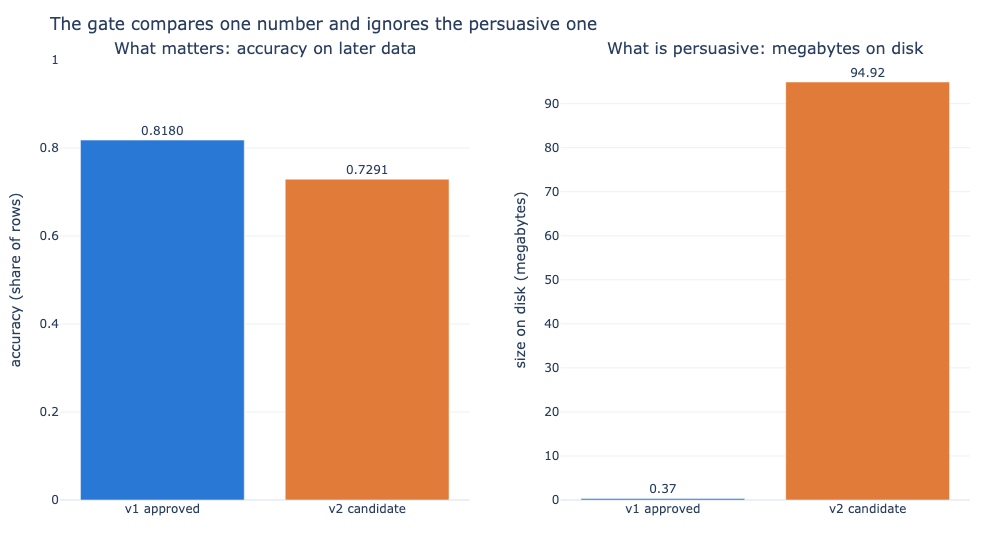

In [72]:
# Source: Module 3/exercises/solutions/lab_01.py — demonstration, paragraph 7 of 14, verbatim

# The figure: what matters against what is persuasive.
fig = make_subplots(rows=1, cols=2, subplot_titles=("What matters: accuracy on later data",
                                                    "What is persuasive: megabytes on disk"))
names = ["v1 approved", "v2 candidate"]
colours = ["#2A78D6", "#E07B39"]
fig.add_trace(go.Bar(x=names, y=[metrics["v1"]["accuracy"], metrics["v2"]["accuracy"]],
                     marker_color=colours, text=[f"{metrics[v]['accuracy']:.4f}" for v in ("v1", "v2")],
                     textposition="outside", showlegend=False), row=1, col=1)
fig.add_trace(go.Bar(x=names, y=[metrics["v1"]["size_bytes"] / 1e6, metrics["v2"]["size_bytes"] / 1e6],
                     marker_color=colours, text=[f"{metrics[v]['size_bytes'] / 1e6:.2f}" for v in ("v1", "v2")],
                     textposition="outside", showlegend=False), row=1, col=2)
fig.update_yaxes(title_text="accuracy (share of rows)", range=[0, 1.0], row=1, col=1)
fig.update_yaxes(title_text="size on disk (megabytes)", row=1, col=2)
fig.update_layout(title="The gate compares one number and ignores the persuasive one")
save_figure(fig, "gate_bars", LAB, logger=say)

**Goal.** Part (c): import what the verdict's measurements need.

**Why.** The verdict is handed evidence measured here — Lab 3's bills and Lab 4's percentile — rather than numbers quoted from a slide.

**What the code does.** Imports NumPy and `time`.

**So what.** Nothing runs yet.

In [73]:
# Source: Module 3/exercises/solutions/lab_01.py — demonstration, paragraph 8 of 14, verbatim

# Part (c): the verdict, on evidence this module actually measured. The two
# accuracies come from metrics.json, the two bills and the no-model floor are
# Lab 3's arithmetic at the priced threshold, and the percentile is Lab 4's,
# measured here rather than quoted -- which is the point of the exercise.
import numpy as np
import time

**Goal.** Take the test period, its truth and the operator's prices.

**Why.** Both bills must be counted on the same rows at the same cutoff.

**What the code does.** Splits the table by time at 70 per cent, marks the aboard rows, and sets the priced cutoff 0.2 with a false positive at 1 and a false negative at 4.

**So what.** The 3,241 test rows of Block three.

In [74]:
# Source: Module 3/exercises/solutions/lab_01.py — demonstration, paragraph 9 of 14, verbatim

table = load_table()
test = table.iloc[int(len(table) * 0.7):]
truth = (test["label2"] == "IN").astype(int).to_numpy()
priced, cost_fp, cost_fn = 0.2, 1.0, 4.0

**Goal.** Define the bill of one version at the priced cutoff.

**Why.** Each version must be prepared with its own stored transform, or the comparison measures the preparation rather than the model.

**What the code does.** Fills and scales the test rows with the version's stored medians, means and standard deviations, asks for probabilities, and prices the false positives at 1 and the false negatives at 4; returns the bill, the prepared rows and the artefact.

**So what.** One function, applied to both versions in the next cell.

In [75]:
# Source: Module 3/exercises/solutions/lab_01.py — demonstration, paragraph 10 of 14, verbatim

def bill(version):
    artefact = load_artefact(version)
    fitted = artefact["transform"]
    prepared = np.column_stack([
        ((test[f].astype(float).fillna(fitted["medians"][f]) - fitted["means"][f])
         / fitted["stds"][f]).to_numpy() for f in fitted["features"]])
    probabilities = artefact["model"].predict_proba(prepared)[:, 1]
    said = probabilities >= priced
    return (cost_fp * float(((said == 1) & (truth == 0)).sum())
            + cost_fn * float(((said == 0) & (truth == 1)).sum())), prepared, artefact

**Goal.** Price both versions, and the best rule that uses no model.

**Why.** The verdict promotes only a candidate cheaper than the model in service and cheaper than using no model at all.

**What the code does.** Bills v1 and v2, and takes the cheaper of the two no-model rules: answer aboard to everyone, or not aboard to everyone.

**So what.** Three bills for the verdict to compare.

In [76]:
# Source: Module 3/exercises/solutions/lab_01.py — demonstration, paragraph 11 of 14, verbatim

approved_cost, prepared_v1, artefact_v1 = bill("v1")
candidate_cost, _, _ = bill("v2")
trivial = min(cost_fp * float((truth == 0).sum()), cost_fn * float((truth == 1).sum()))

**Goal.** Measure the 95th-percentile duration of one request, on this machine.

**Why.** A latency budget can only be checked against a duration that happened.

**What the code does.** Times 200 single-row predictions in milliseconds, sorts them and takes the nearest-rank 95th percentile. The rows timed are `prepared_v1` on `artefact_v1`, the model in service; the next cell files the result as `candidate_latency_p95`.

**So what.** A number that changes from run to run, which is why the deck reports work in decision nodes instead.

In [77]:
# Source: Module 3/exercises/solutions/lab_01.py — demonstration, paragraph 12 of 14, verbatim

durations = []
for index in range(200):
    row = prepared_v1[index % len(prepared_v1)].reshape(1, -1)
    started = time.perf_counter()
    artefact_v1["model"].predict_proba(row)
    durations.append((time.perf_counter() - started) * 1000)
ordered = sorted(durations)
rank = max(1, int(-(-LATENCY_PERCENTILE / 100 * len(ordered)) // 1))
p95 = ordered[rank - 1]

**Goal.** Hand the verdict its evidence, twice.

**Why.** The verdict must be right on the measured case and on the uncomfortable one: a candidate more accurate than the model in service and still dearer.

**What the code does.** Gathers the ten measured numbers, prints them, asks `promotion_verdict`, then raises only the candidate's accuracy five points above v1 and asks again.

**So what.** HOLD, because the candidate's realised cost is higher; and HOLD again for the more accurate but dearer candidate. Accuracy alone does not buy a promotion.

In [78]:
# Source: Module 3/exercises/solutions/lab_01.py — demonstration, paragraph 13 of 14, verbatim

measured = {
    "candidate_accuracy": metrics["v2"]["accuracy"],
    "approved_accuracy": metrics["v1"]["accuracy"],
    "approved_accuracy_at_promotion": metrics["v1"]["accuracy"],
    "candidate_realised_cost": candidate_cost,
    "approved_realised_cost": approved_cost,
    "trivial_baseline_cost": trivial,
    "candidate_latency_p95": round(p95, 2),
    "latency_budget": 120.0,
    "candidate_megabytes": round(metrics["v2"]["size_bytes"] / 1e6, 2),
    "approved_megabytes": round(metrics["v1"]["size_bytes"] / 1e6, 2),
}
say.info("the evidence, measured on the %d test rows at the priced threshold %.2f "
         "(false positive 1, false negative 4): %s", len(test), priced,
         ", ".join(f"{k} {v}" for k, v in measured.items()))
call, reason = promotion_verdict(measured)
say.info("verdict: %s — %s", call.upper(), reason)
say.info("and the case that decides the module: a candidate MORE accurate than what is "
         "running and dearer at the priced threshold")
# Everything measured, one number moved: the candidate's accuracy raised above
# the model in service. Its bill at the priced threshold is left exactly as it
# was measured, which is what makes the case uncomfortable.
dearer = {**measured, "candidate_accuracy": round(metrics["v1"]["accuracy"] + 0.05, 4)}
call, reason = promotion_verdict(dearer)
say.info("verdict: %s — %s", call.upper(), reason)
say.info("the latency budget of %.0f milliseconds is an agreement, not a measurement; the "
         "%.0fth percentile beside it is measured on this machine today and belongs in no "
         "slide", measured["latency_budget"], LATENCY_PERCENTILE)

 12.68s  lab 1  the evidence, measured on the 3241 test rows at the priced threshold 0.20 (false positive 1, false negative 4): candidate_accuracy 0.7291, approved_accuracy 0.818, approved_accuracy_at_promotion 0.818, candidate_realised_cost 1745.0, approved_realised_cost 1590.0, trivial_baseline_cost 1663.0, candidate_latency_p95 4.77, latency_budget 120.0, candidate_megabytes 94.92, approved_megabytes 0.37


 12.68s  lab 1  verdict: HOLD — the candidate realised cost is 1745 against the approved realised cost 1590 at the priced threshold, so the release buys the operator nothing; the candidate accuracy of 0.7291 is measured with every mistake priced the same, which this operator does not do


 12.68s  lab 1  and the case that decides the module: a candidate MORE accurate than what is running and dearer at the priced threshold


 12.68s  lab 1  verdict: HOLD — the candidate realised cost is 1745 against the approved realised cost 1590 at the priced threshold, so the release buys the operator nothing; the candidate accuracy of 0.8680 is measured with every mistake priced the same, which this operator does not do


 12.68s  lab 1  the latency budget of 120 milliseconds is an agreement, not a measurement; the 95th percentile beside it is measured on this machine today and belongs in no slide


**Goal.** Say what the check grades.

**Why.** A student should know what a pass means before running the check.

**What the code does.** Prints the solution's one-line summary of the check's requirements.

**So what.** Nothing is computed here.

In [79]:
# Source: Module 3/exercises/solutions/lab_01.py — demonstration, paragraph 14 of 14, verbatim

say.info("what the check grades: v2 and a tied candidate refused with the registry unchanged "
         "and a reason quoting a score; a better candidate promoted; rollback returns v1; "
         "and in a fresh store two runs carry the module's metrics, champion sits on the "
         "more accurate version, and its signature names %s in order; and the verdict on six "
         "sets of evidence whose right calls differ, with a reason built from the numbers "
         "it was handed", FEATURES)

 12.69s  lab 1  what the check grades: v2 and a tied candidate refused with the registry unchanged and a reason quoting a score; a better candidate promoted; rollback returns v1; and in a fresh store two runs carry the module's metrics, champion sits on the more accurate version, and its signature names ['speed', 'rssi1', 'rssi2', 'rssiC'] in order; and the verdict on six sets of evidence whose right calls differ, with a reason built from the numbers it was handed


---
## Block two — Checking every request before the model sees it

*Slide: "A model cannot object, so something in front of it has to".* Module 1 wrote
down each measurement's unit, source, valid range and owner. That document had no
power: nothing stopped a request from breaking it. A model will accept a walking
speed of nine hundred metres per second and answer. A contract is the same
declaration, checked before the model is asked (Breck et al., 2019).

**Goal.** Write the contract's acceptance rule.

**Why.** Present and null are two rules, not one: a missing *field* is a request the service cannot answer — the model's door is four columns wide — while a null *value* is a measurement that was not made, which the stored median fills.

**What the code does.** Writes the three clauses of the definition card in sympy, one field f at a time, with acceptance as a product of indicators over the fields.

**So what.** A request is accepted only when every field passes all three clauses.

In [80]:
f_, F_ = sp.symbols("f F", integer=True, positive=True)
x_f = sp.Symbol("x[f]")
null = sp.Symbol(r"\mathrm{null}")
field = lambda name: sp.Symbol(rf"\mathrm{{{name}}}_f")
clauses = sp.And(sp.Implies(field("required"), sp.Symbol(r"f \in x")),
                 sp.Implies(sp.Eq(x_f, null), field("nullable")),
                 sp.Implies(sp.Ne(x_f, null),
                            sp.And(sp.Eq(sp.Function(r"\mathrm{type}")(x_f), field("type")),
                                   sp.Le(sp.Symbol(r"\min_f"), x_f), sp.Le(x_f, sp.Symbol(r"\max_f")))))
# "for every field f" as a product of indicators, since sympy has no quantifier
formula(sp.Eq(sp.Function(r"\mathbf{1}")(sp.Function(r"\mathrm{accept}")(sp.Symbol("x"))),
              sp.Product(sp.Function(r"\mathbf{1}")(sp.Symbol(r"\mathrm{ok}_f")), (f_, 1, F_))))
formula(sp.Equivalent(sp.Symbol(r"\mathrm{ok}_f"), clauses))

<IPython.core.display.Math object>

<IPython.core.display.Math object>

**Goal.** Define the contract as Lab 2 declares it.

**Why.** The contract is a Python dictionary, so the door, the check and the appendix table all read the same rules.

**What the code does.** Copies the lab number, the measured speed bounds, the margin, the nullable fields and `CONTRACT` from `solutions/lab_02.py`, verbatim.

**So what.** Four fields, five rules each. A contract must not bound a field at the measured extreme with no margin.

In [81]:
# Source: Module 3/exercises/solutions/lab_02.py — LAB, SPEED_MEASURED_MIN, SPEED_MEASURED_MAX, SPEED_MARGIN, NULLABLE_BY_MEASUREMENT, CONTRACT, verbatim
# References: (Breck et al., 2019)

import pathlib
import sys


LAB = 2


SPEED_MEASURED_MIN = -3.361


SPEED_MEASURED_MAX = 3.555


SPEED_MARGIN = 1.0


# Every field is required to be PRESENT, because the model's door is four
# columns wide and a column that is not there cannot be reordered into place.
# Only the three signal strengths may be present and NULL, because a phone hears
# whichever beacons are in range: speed carries a value on 100.0 per cent of the
# training day's rows and the signal strengths on 11.3, 25.1 and 30.7 per cent.
# A null is a measurement that was not made, and the stored median fills it.
NULLABLE_BY_MEASUREMENT = "speed is present on every row; the signal strengths are not"


CONTRACT = {
    "speed": {"required": True, "nullable": False, "type": "number",
              "min": SPEED_MEASURED_MIN - SPEED_MARGIN,
              "max": SPEED_MEASURED_MAX + SPEED_MARGIN,
              "units": "metres per second, signed"},
    "rssi1": {"required": True, "nullable": True, "type": "number",
              "min": -120.0, "max": 0.0, "units": "decibel-milliwatts"},
    "rssi2": {"required": True, "nullable": True, "type": "number",
              "min": -120.0, "max": 0.0, "units": "decibel-milliwatts"},
    "rssiC": {"required": True, "nullable": True, "type": "number",
              "min": -120.0, "max": 0.0, "units": "decibel-milliwatts"},
}

**Goal.** Check the contract's numbers against the measurements they come from.

**Why.** The numbers in a contract are measurements, not guesses. Speed is present on every training row, so an empty speed is refused; a signal strength is present only when its beacon was in range, so an empty one is allowed. Speed's bounds are Module 1's measured range for this vehicle, widened by one metre per second each way.

**What the code does.** Measures the share of the training day's rows on which each field carries a value, reads Module 1's measured speed range, and compares both with the contract and the slide.

**So what.** 100 per cent for speed, 11.3 to 30.7 per cent for the signal strengths; −4.361 to 4.555 metres per second accepted.

In [82]:
training_day = build_table()
for field, stated in (("speed", 100.0), ("rssi1", 11.3), ("rssi2", 25.1), ("rssiC", 30.7)):
    agrees(f"rows on which {field} carries a value, per cent", 100 * training_day[field].notna().mean(), stated, 1)
module1 = json.loads((COURSE / "Module 1" / "slides" / "measured.json").read_text())
low, high = module1["speed_range_m_per_s"]["value"]
agrees("Module 1's measured minimum speed", low, SPEED_MEASURED_MIN, 3)
agrees("Module 1's measured maximum speed", high, SPEED_MEASURED_MAX, 3)
agrees("contract minimum, m/s", CONTRACT["speed"]["min"], -4.361, 3)
agrees("contract maximum, m/s", CONTRACT["speed"]["max"], 4.555, 3)
print("nullable:", {field: rule["nullable"] for field, rule in CONTRACT.items()})

  rows on which speed carries a value, per cent                      deck 100.0      computed 100.0
  rows on which rssi1 carries a value, per cent                      deck 11.3       computed 11.3
  rows on which rssi2 carries a value, per cent                      deck 25.1       computed 25.1
  rows on which rssiC carries a value, per cent                      deck 30.7       computed 30.7
  Module 1's measured minimum speed                                  deck -3.361     computed -3.361
  Module 1's measured maximum speed                                  deck 3.555      computed 3.555
  contract minimum, m/s                                              deck -4.361     computed -4.361
  contract maximum, m/s                                              deck 4.555      computed 4.555
nullable: {'speed': False, 'rssi1': True, 'rssi2': True, 'rssiC': True}


### The rules, and the check at the door

*Slides: "A field carries five rules, and each rule has a plain meaning" and "The check at the door runs in four steps, and never asks the model early".* Presence, emptiness, type, range, unit. For each required field confirm it is present; for each present value confirm type and range; if any note was written, refuse with every note; only otherwise pass the request on.

**Goal.** Define the check at the door as the Lab 2 solution writes it.

**Why.** A refusal that does not name its field is one the caller will retry unchanged. And in Python `True` is an instance of `int`, so a naive type check lets `"speed": true` through as one metre per second.

**What the code does.** Copies `_is_number` and `validate` from `solutions/lab_02.py`, verbatim.

**So what.** Every complaint names its field and the rule it broke.

In [83]:
# Source: Module 3/exercises/solutions/lab_02.py — _is_number, validate, verbatim
# References: (Breck et al., 2019)

import pathlib
import sys


def _is_number(value) -> bool:
    """A boolean is not a number here, whatever Python thinks.

    In Python, True is an instance of int. Left alone, that means a request
    carrying `"speed": true` sails through a naive type check and reaches the
    model as 1.0 metres per second. Excluding bool explicitly is one line and it
    closes a real hole.
    """
    return isinstance(value, (int, float)) and not isinstance(value, bool)


def validate(request: dict, contract: dict = CONTRACT) -> list:
    """Every way the request breaks the contract, each naming its field.

    Definition graded by the check:
        accept(x) ⇔ ∀f: (required_f ⇒ f ∈ x) ∧ (f ∈ x ∧ x[f] = null ⇒ nullable_f) ∧ (f ∈ x ∧ x[f] ≠ null ⇒ type(x[f]) = type_f ∧ min_f ≤ x[f] ≤ max_f); otherwise the refusal names every f that failed
        (Breck et al., 2019). Slide: "Definition — the data contract at the door".

    Present and null are two rules and not one. The field has to be there,
    because the model was fitted on four columns and the platform's signature
    will refuse a request that carries three; whether it may be EMPTY is a
    separate question, answered by whether the measurement is one that is always
    made. Speed always is. A signal strength is made only when a beacon is in
    range, so a null there is information, and the stored median stands in for it.

    Naming the field is not politeness. A refusal that says only "invalid
    request" is one the caller will retry unchanged, because they have no way to
    know what to change. Then you have two problems: a broken client and a
    service being hammered by it.

    The bounds are a decision, not a fact. Module 1 measured this vehicle at
    -3.361 to 3.555 metres per second; a contract set exactly there refuses the
    first slightly faster day that ever occurs, and one set at "minus five to
    thirty" — as this lab used to declare — refuses nothing a vehicle could do.
    The rule taken from that: bound at the measurement plus a margin you state
    out loud, so the next person can argue with the margin instead of guessing
    at the intent.
    """
    complaints = []
    for field, rule in contract.items():
        if field not in request:
            if rule.get("required"):
                complaints.append(
                    f"{field}: required, and the field is absent; the model's door is "
                    f"{len(contract)} columns wide")
            continue

        value = request[field]
        if value is None:
            # Present and empty. Allowed only where the measurement is one that
            # is not always made, and then the stored median stands in for it.
            if not rule.get("nullable"):
                complaints.append(
                    f"{field}: present but null, and this field is never empty in the "
                    f"data the model was fitted on ({rule['units']})")
            continue
        if rule.get("type") == "number" and not _is_number(value):
            complaints.append(
                f"{field}: expected a number in {rule['units']}, got "
                f"{type(value).__name__}")
            continue

        low, high = rule.get("min"), rule.get("max")
        if low is not None and value < low:
            complaints.append(
                f"{field}: {value} is below the minimum {low} ({rule['units']})")
        if high is not None and value > high:
            complaints.append(
                f"{field}: {value} is above the maximum {high} ({rule['units']})")

    # A field nobody declared is not automatically wrong, but it is worth saying
    # so: silently accepting it is how a caller comes to believe it has an
    # effect. Naming it is itself a complaint, so the request is refused rather
    # than answered with the field quietly dropped.
    for field in request:
        if field not in contract:
            complaints.append(f"{field}: not in the contract, so the request is refused")
    return complaints

**Goal.** Ask the check about three requests: an impossible speed, a speed sent as `true`, and a valid request.

**Why.** The two failures are the ones a naive check lets through: a number far outside the measured range, and a boolean that Python counts as an integer.

**What the code does.** Defines the valid request used from here to the end of the notebook — speed 1.2 and three signal strengths — and prints `validate()` for each case.

**So what.** One complaint each for the first two, both naming `speed`; none for the valid request.

In [84]:
GOOD_REQUEST = {"speed": 1.2, "rssi1": -70.0, "rssi2": -80.0, "rssiC": -75.0}
print(validate({**GOOD_REQUEST, "speed": 900.0}))
print(validate({**GOOD_REQUEST, "speed": True}))
print(validate(GOOD_REQUEST), "<- the valid request draws no complaint")

['speed: 900.0 is above the maximum 4.555 (metres per second, signed)']
['speed: expected a number in metres per second, signed, got bool']
[] <- the valid request draws no complaint


### Status codes

*Slides: "Definition — the status code" and "The four status codes this service
returns, and who acts on each"* (Fielding, Nottingham & Reschke, 2022).

| Code | What it means | When this service returns it | What the caller then does |
|---|---|---|---|
| 200 | Accepted and answered | every rule in the contract was satisfied | reads the probability, decision, cutoff and version |
| 422 | Well formed, contents unacceptable (§ 15.5.21) | a speed of nine hundred; a missing field; text where a number was declared | corrects the values and sends again |
| 400 | The request itself was malformed (§ 15.5.1) | the message could not be read at all | corrects the program that builds the message |
| 500 | The fault is ours (§ 15.6.1) | the model file failed to load; the registry could not be reached | escalates — a person is woken for this |

A refusal must not be reported as 500, because 500 wakes an engineer for a caller's
mistake.

**Goal.** Write refusal and provenance.

**Why.** Validation happens before the model is asked, because a model given nonsense returns a number, not an objection. And the answer carries the version and the cutoff that produced it, so a complaint months later is settled by reading the answer itself (Fielding, Nottingham & Reschke, 2022; Sculley et al., 2015).

**What the code does.** Writes the two statements of the definition card in sympy, with the complaints counted: none, or at least one.

**So what.** A refusal never reaches the model; an answer always carries its provenance.

In [85]:
complaints = sp.Symbol(r"|\mathrm{complaints}|")
status, calls = sp.Symbol(r"\mathrm{status}"), sp.Symbol(r"\mathrm{model\ calls}")
answer = sp.Symbol(r"\mathrm{answer}")
provenance = sp.Tuple(sp.Symbol("p"), sp.Symbol(r"\mathrm{decision}"), sp.Symbol(r"\mathrm{version}"), sp.Symbol("t"))
formula(sp.Implies(sp.Gt(complaints, 0), sp.And(sp.Eq(status, 422), sp.Eq(calls, 0))))
formula(sp.Implies(sp.Eq(complaints, 0), sp.And(sp.Eq(status, 200), sp.Eq(answer, provenance))))

<IPython.core.display.Math object>

<IPython.core.display.Math object>

**Goal.** Define the response as the Lab 2 solution writes it.

**Why.** Validate first, and only then ask the model; answer with the version and the cutoff that produced the decision (Fielding, Nottingham & Reschke, 2022; Sculley et al., 2015).

**What the code does.** Copies `respond` from `solutions/lab_02.py`, verbatim.

**So what.** 422 with the complaints, or 200 with probability, decision, version and threshold.

In [86]:
# Source: Module 3/exercises/solutions/lab_02.py — respond, verbatim
# References: (Fielding, Nottingham & Reschke, 2022)

import pathlib
import sys


def respond(request: dict, contract: dict, artefact: dict, threshold: float = 0.5) -> dict:
    """Refuse at the door, or answer with provenance.

    Definition graded by the check:
        complaints ≠ ∅ ⇒ (status 422, every complaint naming its field, model calls = 0); complaints = ∅ ⇒ (status 200, probability p, decision = aboard iff p ≥ t, model_version, threshold t)
        (Fielding, Nottingham & Reschke, 2022, RFC 9110 §15.5.21). Slide:
        "Definition — refusal at the door, and provenance in the answer".

    The ordering is the lesson. Validation happens *before* the model is asked,
    because a model given nonsense returns a number rather than an objection —
    it has no way to know the request was impossible. An unchecked service
    therefore answers every request successfully, including the meaningless
    ones, and the only trace is a slightly worse metric somewhere downstream
    several weeks later.

    Provenance goes in every response, not only the interesting ones. "Which
    model gave this answer?" is a question that arrives months later about a
    single request, and it should be answerable from the answer itself rather
    than by correlating timestamps against a deployment log.

    The decision boundary is the one Lab 3 derives: aboard when the probability
    is at or above the threshold. Immaterial for a continuous score, and it is
    still written the same way in every file of this module.
    """
    complaints = validate(request, contract)
    if complaints:
        return {"status": 422, "complaints": complaints}

    transform = artefact["transform"]
    row = [[
        (float(request.get(feature, transform["medians"][feature])
               if request.get(feature) is not None else transform["medians"][feature])
         - transform["means"][feature]) / transform["stds"][feature]
        for feature in transform["features"]
    ]]
    probability = float(artefact["model"].predict_proba(row)[0][1])

    return {
        "status": 200,
        "probability": round(probability, 6),
        "decision": "aboard" if probability >= threshold else "not aboard",
        "model_version": artefact.get("version", "v1"),
        "threshold": threshold,
    }

**Goal.** Answer one valid request, in the five steps of the slide.

**Why.** Check at the door, prepare with the stored constants, ask the model, compare with the cutoff, answer with provenance. Every classifier library uses 0.5 unless told otherwise; here the cutoff is 0.2, because a missed passenger costs four times a wasted trip.

**What the code does.** Loads the approved artefact, answers the request at 0.2, and again at 0.5.

**So what.** The same probability, 0.458, is aboard at 0.2 and not aboard at 0.5. Part 3.2 follows this request through the whole day.

In [87]:
SERVED = load_artefact("v1")
SERVED["version"] = "v1"
at_priced = respond(GOOD_REQUEST, CONTRACT, SERVED, 0.2)
at_half = respond(GOOD_REQUEST, CONTRACT, SERVED, 0.5)
print(at_priced)
print(at_half)
print(respond({**GOOD_REQUEST, "speed": 900.0}, CONTRACT, SERVED, 0.2))

{'status': 200, 'probability': 0.457884, 'decision': 'aboard', 'model_version': 'v1', 'threshold': 0.2}
{'status': 200, 'probability': 0.457884, 'decision': 'not aboard', 'model_version': 'v1', 'threshold': 0.5}
{'status': 422, 'complaints': ['speed: 900.0 is above the maximum 4.555 (metres per second, signed)']}


### Changing the contract, and who owns it

*Slides: "Changing the contract: which changes are safe, and which one is a trap" and
"Most failures of a model in use are organisational, not mathematical".* A safe
change lets every old request still work (add an optional field, widen a range); a
breaking change makes some fail at the door, and the caller gets a 422 and knows. The
trap is a change that keeps a field's name and changes its meaning: the door accepts
it, the model reads it, every answer is wrong and no error is raised. A breaking
change therefore gets a new version of the service beside the old one. And a service
has an owner — a named person and a deputy — and an agreement promising response time
for the slowest requests, not the average; undeclared consumers — systems silently
using a model's output — are a debt of their own (Sculley et al., 2015, § 2).

## Laboratory 2 — The contract at the door

*Slide: "Lab 2 — The contract at the door".* Write `validate` and `respond`. Eight
impossible requests must each draw a refusal that names its own field; two must be
accepted — the valid one, and one whose signal strength is empty. A counting stand-in
replaces the model: ask it about an invalid request and fail. Twenty-five minutes.

**The exercise, exactly as `Module 3/exercises/labs/02_the_contract.py` states it.**

> Lab 2 — The contract at the door.
>
> Why this lab exists: a model cannot object. Given a speed of nine hundred metres
> per second it returns a probability, so the only thing standing between a
> nonsense request and a confident answer is a rule checked before the model is
> asked. You write that rule, refuse eight impossible requests by name, and make
> every answer carry the version that produced it.
> Where it sits: Block 2 — "The data dictionary, with consequences", "Four kinds of
> rule, and the one people forget" and "Refusing well", and the definition slides
> "Definition — the data contract at the door" and "Definition — refusal at the
> door, and provenance in the answer".
> What the check grades: all eight impossible requests draw at least one complaint
> naming the offending field, the two acceptable ones draw none, every refusal is
> status 422 with its complaints attached, the model — replaced by a spy that
> counts — is asked exactly once, for the valid request, and the 200 response
> carries the probability, the decision, the model version and the threshold. The
> contract's fields are also compared against the table Module 2 hands over: a
> service that accepts fields its own input table does not promise is a service
> documenting something else.
> Needs: isinstance, dict.get, model.predict_proba.
>
> Twenty-five minutes.
>
> Module 1 wrote a data dictionary: for every field, the unit, the source, the
> valid range, the owner. That document had no consequences. A contract is the
> same declaration with consequences attached — the service states what it will
> accept and refuses everything else *before the model is asked*.
>
> Why before. A model given nonsense returns a number. It does not know the
> request was impossible; it has no way to know. So an unchecked service answers
> every request successfully, including the ones that are meaningless, and the
> only trace is a slightly worse metric somewhere downstream weeks later.
>
> What you write: validate(request, contract).
>
>     Return a list of complaints, one per violated rule, empty if the request is
>     acceptable. Each complaint must name the offending **field** — a refusal
>     that does not say which field is a refusal somebody will retry unchanged.
>
>     Five kinds of rule, all in the contract you are given:
>
>       required   the field must be PRESENT. All four are, because the model's
>                  door needs four columns -- read the note above CONTRACT.
>       nullable   whether a present field may carry null. Speed may not; the
>                  three signal strengths may, and a null is what Lab 4's stored
>                  median fills.
>       type       "number" -- bool is not a number here, and a string is not
>                  either, however numeric it looks
>       range      minimum and maximum, inclusive, checked only on a value that
>                  is actually there
>       units      declared for the reader; not enforced, but printed in the
>                  refusal so the caller can see what was expected
>
>     Present and null are different failures. Conflating them is what made an
>     earlier version of this lab contradict itself, and the note above CONTRACT
>     says how.
>
> Then write: respond(request, contract, artefact, threshold).
>
>     If validate returns complaints, return
>         {"status": 422, "complaints": [...]}
>     and **do not touch the model**. The check watches; asking the model on an
>     invalid request fails the lab.
>
>     Otherwise return
>         {"status": 200, "probability": float, "decision": "aboard"|"not aboard",
>          "model_version": str, "threshold": float}
>
>     Provenance in every response, not only the failures. "Which model gave this
>     answer?" has to be answerable from the answer itself, months later, without
>     a log search.
>
> Status 422 rather than 400 or 500: the request was well-formed and its contents
> were unacceptable (Fielding, Nottingham & Reschke, 2022). 500 would claim the
> fault is ours; 400 says the bytes were malformed. Say what actually happened.
>
> The check passes when all eight impossible requests draw at least one complaint
> naming the offending field, when the valid request and the one whose signal
> strength is null draw none at all, when every impossible request gets status 422
> with its complaints attached, when the model is asked exactly once — for the
> valid request, and never for an invalid one — and when the 200 response carries
> probability, decision, model_version and threshold.

```python
def validate(request: dict, contract: dict = CONTRACT) -> list:
    """Every way `request` breaks `contract`. Empty list means acceptable.
    
    Definition graded by the check:
        accept(x) ⇔ ∀f: (required_f ⇒ f ∈ x) ∧ (f ∈ x ∧ x[f] = null ⇒ nullable_f) ∧ (f ∈ x ∧ x[f] ≠ null ⇒ type(x[f]) = type_f ∧ min_f ≤ x[f] ≤ max_f); otherwise the refusal names every f that failed
        (Breck et al., 2019). Choices: a missing field and a null value are
        different failures, because the model's door needs four columns and the
        stored median fills an empty one; bool is not a number, however Python
        counts it; the bounds are inclusive and are checked only on a value that
        is there; speed's bounds are Module 1's measured range for this vehicle
        widened by a stated margin of 1 metre per second on each side. Slide:
        "Definition — the data contract at the door".
    Needs: isinstance, dict.get"""
```

```python
def respond(request: dict, contract: dict, artefact: dict, threshold: float = 0.5) -> dict:
    """Refuse at the door, or answer with provenance.
    
    Definition graded by the check:
        complaints ≠ ∅ ⇒ (status 422, every complaint naming its field, model calls = 0); complaints = ∅ ⇒ (status 200, probability p, decision = aboard iff p ≥ t, model_version, threshold t)
        (Fielding, Nottingham & Reschke, 2022, RFC 9110 §15.5.21). Choices: 422
        rather than 400 (the bytes parsed) or 500 (the fault is not ours); the
        decision boundary is p ≥ t, as Lab 3 derives it; the version travels in
        every response, not only the failures. Slide: "Definition — refusal at
        the door, and provenance in the answer".
    Needs: model.predict_proba, dict"""
```

### The solution, step by step

The functions were defined above. First the lab file's own demonstration.

**Goal.** Run the stub's own `__main__` block against the solved functions.

**Why.** It is what a student sees when the file is complete.

**What the code does.** The lines below are the stub's demonstration, verbatim (the stub's default cutoff is 0.5).

**So what.** One answer with provenance, one refusal naming speed.

In [88]:
# Source: Module 3/exercises/labs/02_the_contract.py — demonstration step 0, verbatim

artefact = load_artefact("v1")
good = {"speed": 1.2, "rssi1": -70.0, "rssi2": -80.0, "rssiC": -75.0}
print(respond(good, CONTRACT, artefact))
print(respond({**good, "speed": 900.0}, CONTRACT, artefact))

{'status': 200, 'probability': 0.457884, 'decision': 'not aboard', 'model_version': 'v1', 'threshold': 0.5}
{'status': 422, 'complaints': ['speed: 900.0 is above the maximum 4.555 (metres per second, signed)']}


**Goal.** Let the solution's paths resolve in the working copy.

**Why.** The solution reads the vehicle slice relative to its own file.

**What the code does.** Points `__file__` at `solutions/lab_02.py` in the working copy.

**So what.** The next cells are `python3 solutions/lab_02.py`, one paragraph of its `__main__` block per cell.

In [89]:
__file__ = str(WORK / "solutions" / "lab_02.py")

**Goal.** Import what the demonstration needs beyond the functions above.

**Why.** The block tabulates with pandas, draws with plotly and narrates with `_narrate`.

**What the code does.** Imports pandas, plotly and the narration helpers the set-up registered.

**So what.** Nothing runs yet.

In [90]:
# Source: Module 3/exercises/solutions/lab_02.py — demonstration, paragraph 1 of 8, verbatim

import pandas as pd
import plotly.graph_objects as go
from _narrate import narrator, show_table, save_figure

**Goal.** Start the narration.

**Why.** Every line the solution prints goes through `say`, stamped with the seconds since the notebook began.

**What the code does.** Creates the narrator for Lab 2 and prints the demonstration's one-line summary.

**So what.** The timings differ from run to run; nothing else does.

In [91]:
# Source: Module 3/exercises/solutions/lab_02.py — demonstration, paragraph 2 of 8, verbatim

say = narrator(LAB)
say.info("Lab 2 — the door: eight impossible requests refused by name, two acceptable "
         "ones let through, and the valid one answered with the version that answered it")

 12.81s  lab 2  Lab 2 — the door: eight impossible requests refused by name, two acceptable ones let through, and the valid one answered with the version that answered it


**Goal.** Load the approved model and state where the speed bounds come from.

**Why.** The contract's numbers must be traceable to a measurement.

**What the code does.** Loads v1's artefact, tags it with its version, and prints the contract's speed bounds beside Module 1's measured range and the margin.

**So what.** −4.361 to 4.555 metres per second: the measured range widened by one each way.

In [92]:
# Source: Module 3/exercises/solutions/lab_02.py — demonstration, paragraph 3 of 8, verbatim

artefact = load_artefact("v1")
artefact["version"] = "v1"
say.info("loaded the approved artefact (v1): the forest and the fitted transform "
         "together, from service/artefacts/model_v1.pkl (generated)")
say.info("the contract's speed bounds: %.3f to %.3f metres per second — Module 1's "
         "measured range for this vehicle, %.3f to %.3f, widened by a stated margin "
         "of %.1f on each side", CONTRACT["speed"]["min"], CONTRACT["speed"]["max"],
         SPEED_MEASURED_MIN, SPEED_MEASURED_MAX, SPEED_MARGIN)

 12.82s  lab 2  loaded the approved artefact (v1): the forest and the fitted transform together, from service/artefacts/model_v1.pkl (generated)


 12.82s  lab 2  the contract's speed bounds: -4.361 to 4.555 metres per second — Module 1's measured range for this vehicle, -3.361 to 3.555, widened by a stated margin of 1.0 on each side


**Goal.** Write down one valid request and eight impossible ones.

**Why.** Each impossible request breaks exactly one rule, so each refusal can be checked for naming the right field.

**What the code does.** Builds the valid request and eight variants: a required field missing, a declared column absent, a None speed, a number as text, a boolean as a number, a speed above the maximum, a signal strength above zero and one below the minimum.

**So what.** Nothing is sent yet.

In [93]:
# Source: Module 3/exercises/solutions/lab_02.py — demonstration, paragraph 4 of 8, verbatim

good = {"speed": 1.2, "rssi1": -70.0, "rssi2": -80.0, "rssiC": -75.0}
impossible = [
    ("required field missing", {k: v for k, v in good.items() if k != "speed"}),
    ("a declared column absent", {k: v for k, v in good.items() if k != "rssi1"}),
    ("required field is None", {**good, "speed": None}),
    ("a number sent as text", {**good, "speed": "1.2"}),
    ("a boolean sent as a number", {**good, "speed": True}),
    ("above the declared maximum", {**good, "speed": 900.0}),
    ("signal strength above zero", {**good, "rssi1": 40.0}),
    ("below the declared minimum", {**good, "rssiC": -400.0}),
]

**Goal.** Send the eight, and then the two edge cases that must be accepted.

**Why.** A refusal must be 422 and name its field, the model must not be asked, and a null value must not be confused with an absent field.

**What the code does.** Answers each impossible request at the cutoff 0.2 and tabulates status, number of complaints and the first complaint; then compares an absent `rssi1` with a null `rssi1` and answers the null one.

**So what.** Eight 422s, each naming its field; the absent `rssi1` refused and the null one answered from the stored median.

In [94]:
# Source: Module 3/exercises/solutions/lab_02.py — demonstration, paragraph 5 of 8, verbatim

rows = []
for description, request in impossible:
    answer = respond(request, CONTRACT, artefact, 0.2)
    rows.append({"what was wrong": description, "status": answer["status"],
                 "complaints": len(answer["complaints"]),
                 "first complaint": answer["complaints"][0]})
show_table(pd.DataFrame(rows), "eight impossible requests, eight refusals", logger=say)
say.info("every refusal names its field, so the caller can act without asking us; "
         "every one is 422, because the request parsed and its contents were "
         "unacceptable — 400 would send them looking at their bytes and 500 would "
         "page us for their mistake (Fielding, Nottingham & Reschke, 2022)")
say.info("the model was not asked once in those eight: a model given nonsense returns "
         "a number, so the order — validate, then ask — is the whole lesson")
empty = {**good, "rssi1": None}
say.info("and the pair that used to contradict each other: rssi1 ABSENT draws %d "
         "complaint(s) — the signature needs four columns — while rssi1 present and "
         "NULL draws %d, because a null is a measurement that was not made and Lab 4 "
         "fills it from the stored median", len(validate({k: v for k, v in good.items()
                                                          if k != "rssi1"}, CONTRACT)),
         len(validate(empty, CONTRACT)))
filled = respond(empty, CONTRACT, artefact, 0.2)
say.info("the null request is answered: probability %.4f, decision %r — the median "
         "stood in for the beacon that was not heard", filled["probability"],
         filled["decision"])

 12.83s  lab 2  --- eight impossible requests, eight refusals (8 rows) ---


 12.83s  lab 2                     what was wrong  status  complaints                                                                                                         first complaint


 12.83s  lab 2      0      required field missing     422           1                                            speed: required, and the field is absent; the model's door is 4 columns wide


 12.83s  lab 2      1    a declared column absent     422           1                                            rssi1: required, and the field is absent; the model's door is 4 columns wide


 12.83s  lab 2      2      required field is None     422           1  speed: present but null, and this field is never empty in the data the model was fitted on (metres per second, signed)


...

 12.84s  lab 2      7  below the declared minimum     422           1                                                          rssiC: -400.0 is below the minimum -120.0 (decibel-milliwatts)


 12.84s  lab 2  every refusal names its field, so the caller can act without asking us; every one is 422, because the request parsed and its contents were unacceptable — 400 would send them looking at their bytes and 500 would page us for their mistake (Fielding, Nottingham & Reschke, 2022)


 12.84s  lab 2  the model was not asked once in those eight: a model given nonsense returns a number, so the order — validate, then ask — is the whole lesson


 12.84s  lab 2  and the pair that used to contradict each other: rssi1 ABSENT draws 1 complaint(s) — the signature needs four columns — while rssi1 present and NULL draws 0, because a null is a measurement that was not made and Lab 4 fills it from the stored median


 12.84s  lab 2  the null request is answered: probability 0.4579, decision 'aboard' — the median stood in for the beacon that was not heard


**Goal.** Answer the valid request.

**Why.** The answer must carry its own provenance, so a complaint months later is settled by reading it.

**What the code does.** Answers the valid request at 0.2 and prints probability, decision, version and threshold, then states the boolean trap.

**So what.** Aboard at 0.2, from version v1.

In [95]:
# Source: Module 3/exercises/solutions/lab_02.py — demonstration, paragraph 6 of 8, verbatim

answer = respond(good, CONTRACT, artefact, 0.2)
say.info("the valid request %s", good)
say.info("answered: probability %.4f, decision %r, model_version %r, threshold %.2f — "
         "provenance in the answer itself, not in a log somebody has to join against",
         answer["probability"], answer["decision"], answer["model_version"],
         answer["threshold"])
say.info("the boolean case is the one people lose: isinstance(True, int) is True in "
         "Python, so an unchecked service reads `\"speed\": true` as one metre per "
         "second and answers happily")

 12.85s  lab 2  the valid request {'speed': 1.2, 'rssi1': -70.0, 'rssi2': -80.0, 'rssiC': -75.0}


 12.86s  lab 2  answered: probability 0.4579, decision 'aboard', model_version 'v1', threshold 0.20 — provenance in the answer itself, not in a log somebody has to join against


 12.86s  lab 2  the boolean case is the one people lose: isinstance(True, int) is True in Python, so an unchecked service reads `"speed": true` as one metre per second and answers happily


**Goal.** Draw the contract's speed band against the speeds the vehicle recorded.

**Why.** A bound is only credible beside the data it was drawn from.

**What the code does.** Reads the vehicle slice relative to the solution's file, draws a histogram of its speeds with the measured and the contract bounds, and marks the refused 900.

**So what.** Every recorded speed lies inside the band; 900 is far outside it.

 13.14s  lab 2  the archive slice for this vehicle: 48290 speed readings, -3.361 to 3.555 metres per second (archive)


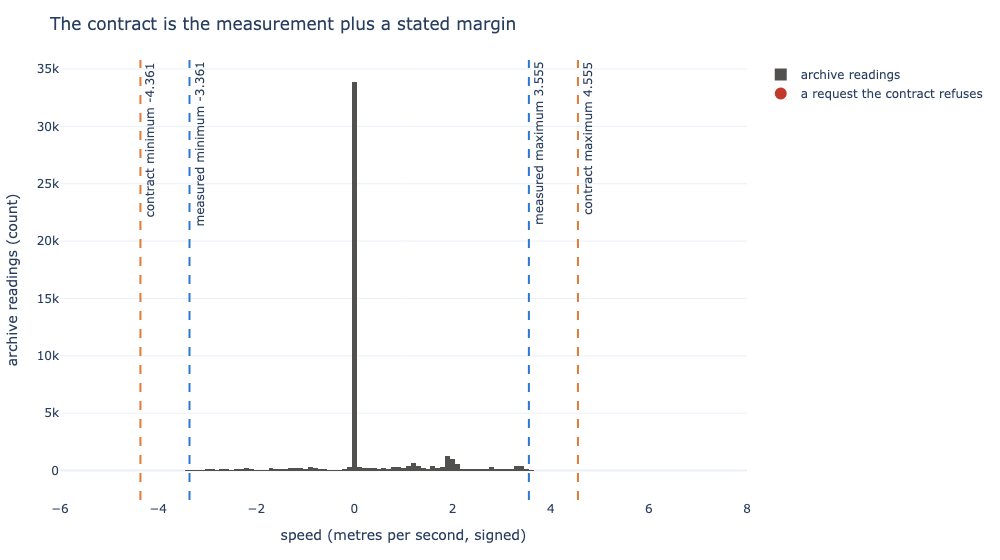

In [96]:
# Source: Module 3/exercises/solutions/lab_02.py — demonstration, paragraph 7 of 8, verbatim

# What the bounds mean, against what the vehicle actually did.
slice_path = pathlib.Path(__file__).resolve().parent.parent / "data" / "bus_slice.csv.gz"
speeds = pd.read_csv(slice_path, low_memory=False)["speed"].dropna()
say.info("the archive slice for this vehicle: %d speed readings, %.3f to %.3f metres "
         "per second (archive)", len(speeds), speeds.min(), speeds.max())
fig = go.Figure()
fig.add_trace(go.Histogram(x=speeds, nbinsx=80, marker_color="#52514E",
                           name="archive readings"))
for value, colour, label in (
        (SPEED_MEASURED_MIN, "#2A78D6", "measured minimum"),
        (SPEED_MEASURED_MAX, "#2A78D6", "measured maximum"),
        (CONTRACT["speed"]["min"], "#E07B39", "contract minimum"),
        (CONTRACT["speed"]["max"], "#E07B39", "contract maximum")):
    fig.add_vline(x=value, line_color=colour, line_dash="dash",
                  annotation_text=f"{label} {value:.3f}", annotation_textangle=-90)
fig.add_trace(go.Scatter(x=[900.0], y=[1], mode="markers+text", text=["refused: 900"],
                         textposition="middle left", marker=dict(color="#C0392B", size=12),
                         name="a request the contract refuses"))
fig.update_layout(template="plotly_white",
                  title="The contract is the measurement plus a stated margin",
                  xaxis_title="speed (metres per second, signed)",
                  yaxis_title="archive readings (count)", xaxis_type="log")
fig.update_xaxes(type="linear", range=[-6, 8])
save_figure(fig, "contract_bounds", LAB, logger=say)

**Goal.** Say what the check grades.

**Why.** A student should know what a pass means before running the check.

**What the code does.** Prints the solution's one-line summary of the check's requirements.

**So what.** Nothing is computed here.

In [97]:
# Source: Module 3/exercises/solutions/lab_02.py — demonstration, paragraph 8 of 8, verbatim

say.info("what the check grades: eight refusals each naming their field, no complaint "
         "for the valid request or the null one, status 422 with complaints on every refusal, the "
         "model asked exactly once — for the valid request — and probability, "
         "decision, model_version and threshold in the 200 response")

 13.40s  lab 2  what the check grades: eight refusals each naming their field, no complaint for the valid request or the null one, status 422 with complaints on every refusal, the model asked exactly once — for the valid request — and probability, decision, model_version and threshold in the 200 response


---
## Block three — What a mistake costs

*Slides: "A probability becomes a decision only when it is compared with a cutoff",
"One half assumes both mistakes cost the same, and they rarely do" and "The cheapest
cutoff for the operator makes the passenger wait".*

The model answers with a probability; the service must answer with a decision. A
false positive sends a bus for nobody: price C_FP = 1 vehicle-hour. A false negative
leaves a passenger waiting: a second vehicle plus a contract penalty of about three,
so C_FN = 4. The prices are the operator's, not the model builder's — a passenger
would set them differently — and a cutoff that minimises cost favours whoever wrote
the cost. The passenger's only protection is C_FN: whoever sets it decides how long
passengers wait.

**Goal.** Define the block's prices and constants as the Lab 3 solution writes them.

**Why.** Every number of this block — the two prices, the departure's seats and mean demand, the calibration bands — is set once, in the lab, and read from there.

**What the code does.** Copies the lab number, C_FP = 1, C_FN = 4, 12 seats, a mean demand of 10, the band edges and the smallest band worth believing from `solutions/lab_03.py`, verbatim.

**So what.** The operator's prices, in vehicle-hours, are now names the rest of the block uses.

In [98]:
# Source: Module 3/exercises/solutions/lab_03.py — LAB, COST_FALSE_POSITIVE, COST_FALSE_NEGATIVE, SEATS, MEAN_DEMAND, CALIBRATION_EDGES, CALIBRATION_MINIMUM_ROWS, verbatim

import pathlib
import sys
import numpy as np
from scipy import stats


LAB = 3


COST_FALSE_POSITIVE = 1.0


COST_FALSE_NEGATIVE = 4.0


SEATS = 12


MEAN_DEMAND = 10.0


CALIBRATION_EDGES = (0.0, 0.2, 0.4, 0.6, 0.8, 1.0)


CALIBRATION_MINIMUM_ROWS = 50

### The cost-sensitive threshold

*Slides: "Definition — the cost-sensitive threshold" and "The cutoff is derived in four steps, and the model appears in none of them".*

**Goal.** Derive the cutoff from the two prices, symbolically.

**Why.** Answering aboard costs C_FP times the chance of not aboard; answering not aboard costs C_FN times the chance of aboard. Answer aboard when the first is no larger (Elkan, 2001, § 1.3).

**What the code does.** Solves (1 − p) C_FP = p C_FN for p with sympy, checks that the difference of the two costs rises with p (so the rule is p at or above the solution), displays the threshold and the decision rule, and evaluates the operator's prices (1, 4) and a passenger's (0, any).

**So what.** t* = C_FP / (C_FP + C_FN) = 0.2. The model appears nowhere in it, so two services may share a model and differ in their cutoff; and it needs a calibrated p.

In [99]:
p = sp.Symbol("p", positive=True)
C_fp, C_fn = sp.symbols(r"C_{fp} C_{fn}", positive=True)
advantage = p * C_fn - (1 - p) * C_fp            # cost of "not aboard" minus cost of "aboard"
boundary = sp.solve(sp.Eq(advantage, 0), p)[0]
t_star = C_fp / (C_fp + C_fn)
formula(sp.Le((1 - p) * C_fp, p * C_fn), sp.Le(C_fp, p * (C_fp + C_fn)),
        sp.Ge(p, t_star))
print("the two costs are equal at p =", boundary, "; the difference rises with p at rate",
      sp.diff(advantage, p), "> 0, so aboard is the cheaper answer for every p at or above it")
assert sp.simplify(boundary - t_star) == 0
formula(sp.Eq(sp.Symbol("t^{*}"), t_star, evaluate=False),
        sp.Equivalent(sp.Symbol(r"\mathrm{decide\ aboard}"), sp.Ge(p, sp.Symbol("t^{*}"))))
agrees("operator's cutoff, C_FP = 1, C_FN = 4", t_star.subs({C_fp: 1, C_fn: 4}), 0.2, 3)
print("passenger's cutoff, C_FP = 0: t* =", sp.limit(t_star, C_fp, 0))

<IPython.core.display.Math object>

the two costs are equal at p = C_{fp}/(C_{fn} + C_{fp}) ; the difference rises with p at rate C_{fn} + C_{fp} > 0, so aboard is the cheaper answer for every p at or above it


<IPython.core.display.Math object>

  operator's cutoff, C_FP = 1, C_FN = 4                              deck 0.2        computed 0.2
passenger's cutoff, C_FP = 0: t* = 0


**Goal.** Define the threshold as the Lab 3 solution writes it.

**Why.** The lab states the cutoff as one line of arithmetic on the two prices.

**What the code does.** Copies `threshold_from_costs` from `solutions/lab_03.py`, verbatim.

**So what.** The next cell checks it against the sympy expression.

In [100]:
# Source: Module 3/exercises/solutions/lab_03.py — threshold_from_costs, verbatim
# References: (Elkan, 2001, § 1.3)

import pathlib
import sys
import numpy as np
from scipy import stats


def threshold_from_costs(cost_false_positive: float, cost_false_negative: float) -> float:
    """The cutoff follows from the consequences, not from the classifier.

    Definition graded by the check:
        t* = C_fp / (C_fp + C_fn); decide aboard ⇔ p ≥ t*
        (Elkan, 2001, pp. 973-978). Slide: "Definition — the cost-sensitive threshold".

    Decide "aboard" when the expected cost of doing so is no higher than the
    expected cost of not. With p the probability of being aboard:

        say aboard      : correct costs nothing, wrong costs C_fp, and it is
                          wrong with probability (1 - p)     ->  (1 - p) . C_fp
        say not aboard  : wrong costs C_fn, with probability p  ->  p . C_fn

    Say aboard when (1 - p) . C_fp <= p . C_fn, which rearranges to

        p >= C_fp / (C_fp + C_fn)

    Note what is absent from that expression: the model. The threshold is a
    property of the operator's consequences (Elkan, 2001). Two services using
    the identical model should use different cutoffs if their mistakes cost
    different amounts, and a service whose costs change should move its cutoff
    without retraining anything.

    Here a passenger left standing costs four times a wasted vehicle-hour, so
    the cutoff is 1 / 5 = 0.2, not 0.5. We are willing to be wrong about "aboard"
    four times as often, because that mistake is a quarter as expensive.

    One half is not a neutral default. It is the specific claim that both
    mistakes cost the same, made by someone who did not check.

    The boundary itself, p exactly equal to t*, is a choice with no consequence
    and it still has to be made once: at equality the two expected costs are the
    same number, so either answer is defensible. This module says "aboard", and
    the stub, the checks, the figures and the slides all say it.
    """
    total = cost_false_positive + cost_false_negative
    if total <= 0:
        raise ValueError("costs must not both be zero")
    return cost_false_positive / total

**Goal.** Check that the lab's function is the formula, and fix the priced cutoff.

**Why.** The check grades the ratio on twenty-nine pairs of costs, not only the round ones.

**What the code does.** Turns the sympy threshold into a function and compares it with `threshold_from_costs` on a grid of 29 cost pairs; then sets `PRICED` from the operator's prices and records how the slide writes the boundary.

**So what.** Identical everywhere. The rule is written p ≥ t* in the definition, the lab and the check; the derivation slide ends with p > t* — for a continuous score the two differ on a set of probability nought, and at equality either answer costs the same.

In [101]:
as_function = sp.lambdify((C_fp, C_fn), t_star)
pairs = [(a, b) for a in (0.5, 1, 2, 3.7, 10) for b in (0.25, 1, 4, 7.5, 20, 33)][:29]
worst = max(abs(threshold_from_costs(a, b) - as_function(a, b)) for a, b in pairs)
print(f"{len(pairs)} cost pairs: largest difference between the lab's function and the formula {worst:.1e}")
PRICED = threshold_from_costs(COST_FALSE_POSITIVE, COST_FALSE_NEGATIVE)
beside("the decision rule at the boundary", "p ≥ t* (definition card, Lab 3, check, figures)",
       "p > t* (last line of the derivation slide)",
       "the derivation's strict inequality; Elkan (2001) notes either class is optimal at equality")

29 cost pairs: largest difference between the lab's function and the formula 0.0e+00
  the decision rule at the boundary: computed here p ≥ t* (definition card, Lab 3, check, figures), stated p > t* (last line of the derivation slide) — the derivation's strict inequality; Elkan (2001) notes either class is optimal at equality


**Goal.** Draw how a probability becomes a priced decision, on the model's own test rows.

**Why.** The slide draws the probability axis cut at t = 0.2: left of it the service says not aboard and risks a false negative at 4; right of it, aboard, and a false positive at 1.

**What the code does.** Plots the champion's probabilities on the 3,241 test rows, aboard and not aboard separately, with the cutoff, and counts the mistakes each side of it makes.

**So what.** The false positives are many and cheap, the false negatives few and dear: that trade is the whole point of the cutoff.

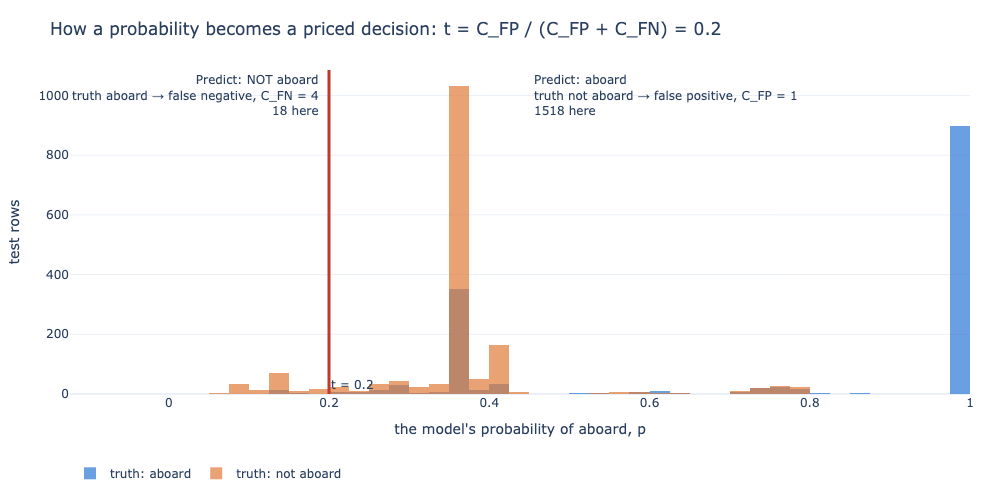

K(0.2) = 1 x 1518 + 4 x 18 = 1,590 vehicle-hours


In [102]:
said = P_TEST >= PRICED
false_positives = int((said & (Y_TEST == 0)).sum())
false_negatives = int((~said & (Y_TEST == 1)).sum())
fig = go.Figure()
for truth_value, colour, name in ((1, "#2A78D6", "truth: aboard"), (0, "#E07B39", "truth: not aboard")):
    fig.add_histogram(x=P_TEST[Y_TEST == truth_value], xbins=dict(start=0, end=1, size=0.025),
                      marker_color=colour, opacity=0.7, name=name)
fig.add_vline(x=PRICED, line=dict(color="#C0392B", width=3), annotation_text="t = 0.2",
              annotation_position="bottom right")
fig.add_annotation(x=0.19, y=1, yref="paper", xanchor="right", showarrow=False, align="right",
                   text=f"Predict: NOT aboard<br>truth aboard → false negative, C_FN = 4<br>{false_negatives} here")
fig.add_annotation(x=0.62, y=1, yref="paper", showarrow=False, align="left",
                   text=f"Predict: aboard<br>truth not aboard → false positive, C_FP = 1<br>{false_positives} here")
fig.update_layout(barmode="overlay", title="How a probability becomes a priced decision: t = C_FP / (C_FP + C_FN) = 0.2",
                  xaxis_title="the model's probability of aboard, p", yaxis_title="test rows",
                  legend=dict(orientation="h", y=-0.2))
show(fig, "priced_decision", height=500)
print(f"K(0.2) = {COST_FALSE_POSITIVE:g} x {false_positives} + {COST_FALSE_NEGATIVE:g} x {false_negatives} "
      f"= {COST_FALSE_POSITIVE * false_positives + COST_FALSE_NEGATIVE * false_negatives:,.0f} vehicle-hours")

### The realised cost of a threshold

*Slides: "Definition — realised cost of a threshold", "The realised cost is counted in four steps, one test row at a time" and "A line of arithmetic saves 22.6 per cent against the usual cutoff".*

**Goal.** Write the realised cost.

**Why.** Price and cost are different things: the price is fixed per mistake, the cost is the price times how often the mistake happened. The realised cost is a count on a finite set of rows, not a forecast (Elkan, 2001; Provost & Fawcett, 2013, ch. 7).

**What the code does.** Writes K(t) in sympy with the two counts as symbols, and each count as a sum of indicators over the n rows, then checks the slide's toy example.

**So what.** Ten false positives and five false negatives cost 30.

In [103]:
n_fp, n_fn = sp.symbols("n_FP n_FN", nonnegative=True)
K = C_fp * n_fp + C_fn * n_fn
row, rows_n = sp.Symbol("i", integer=True), sp.Symbol("n", integer=True, positive=True)
p_i, y_i, t_ = sp.IndexedBase("p")[row], sp.IndexedBase("y")[row], sp.Symbol("t")
one = sp.Function(r"\mathbf{1}")
formula(sp.Eq(sp.Symbol("K(t)"), K, evaluate=False))
formula(sp.Eq(n_fp, sp.Sum(one(sp.And(sp.Ge(p_i, t_), sp.Eq(y_i, 0))), (row, 1, rows_n))),
        sp.Eq(n_fn, sp.Sum(one(sp.And(sp.Lt(p_i, t_), sp.Eq(y_i, 1))), (row, 1, rows_n))))
agrees("toy example: 10 false positives and 5 false negatives", K.subs({C_fp: 1, C_fn: 4, n_fp: 10, n_fn: 5}), 30, 0)

<IPython.core.display.Math object>

<IPython.core.display.Math object>

  toy example: 10 false positives and 5 false negatives              deck 30         computed 30


**Goal.** Define the realised cost as the Lab 3 solution writes it.

**Why.** The lab counts the two mistakes on the rows and prices each.

**What the code does.** Copies `realised_cost` from `solutions/lab_03.py`, verbatim.

**So what.** The next cell prices the two cutoffs with it.

In [104]:
# Source: Module 3/exercises/solutions/lab_03.py — realised_cost, verbatim
# References: (Elkan, 2001; Provost & Fawcett, 2013, ch. 7)

import pathlib
import sys
import numpy as np
from scipy import stats


def realised_cost(probabilities, truth, threshold: float,
                  cost_false_positive: float, cost_false_negative: float) -> float:
    """What this cutoff cost, counted rather than argued.

    Definition graded by the check:
        K(t) = C_fp · #{i : p_i ≥ t and y_i = 0} + C_fn · #{i : p_i < t and y_i = 1}
        (Elkan, 2001; Provost & Fawcett, 2013, ch. 7). Slide: "Definition —
        realised cost of a threshold".

    The name is the lesson. The derivation above is a claim about expectations,
    made before anything happens. This is the bill afterwards: the decisions this
    threshold produced on the rows we have, priced. It was called expected_cost
    in an earlier version of this lab, and it was never an expectation -- it is a
    total over a finite test period, and a student who reads "expected" learns the
    wrong word for a quantity they can see.

    Measuring it is the only way to know whether the costs you were given
    describe the world you are in.
    """
    probabilities = np.asarray(probabilities, dtype=float)
    truth = np.asarray(truth).astype(int)
    said_aboard = probabilities >= threshold

    false_positives = int((said_aboard & (truth == 0)).sum())
    false_negatives = int((~said_aboard & (truth == 1)).sum())
    return (false_positives * cost_false_positive
            + false_negatives * cost_false_negative)

**Goal.** Price the priced cutoff and the habit on the 3,241 test rows.

**Why.** The saving is the whole argument of the block, so it is counted, not estimated.

**What the code does.** Computes the realised cost at 0.2 and at 0.5 with the lab's function, checks both and their difference against the slide, and against `make_figs.py`'s own count.

**So what.** 1,590 at 0.2 against 2,054 at 0.5: the priced cutoff saves 464.

In [105]:
COST_PRICED = realised_cost(P_TEST, Y_TEST, PRICED, COST_FALSE_POSITIVE, COST_FALSE_NEGATIVE)
COST_HALF = realised_cost(P_TEST, Y_TEST, 0.5, COST_FALSE_POSITIVE, COST_FALSE_NEGATIVE)
agrees("realised cost at 0.2", COST_PRICED, 1590, 0)
agrees("realised cost at 0.5", COST_HALF, 2054, 0)
agrees("saving", COST_HALF - COST_PRICED, 464, 0)
assert COST_PRICED == total_cost(P_TEST, Y_TEST, PRICED), "the lab and make_figs.py count differently"

  realised cost at 0.2                                               deck 1590       computed 1590
  realised cost at 0.5                                               deck 2054       computed 2054
  saving                                                             deck 464        computed 464


**Goal.** Define the cost-curve figure as the deck's script writes it.

**Why.** The slide's picture is drawn by `make_figs.py`; the notebook draws it with the same function.

**What the code does.** Copies `figure_threshold()` from `make_figs.py`, verbatim.

**So what.** The next cell draws it on the model's test rows.

In [106]:
# Source: Module 3/slides/make_figs.py — figure_threshold, verbatim

import json
import sys
from pathlib import Path
import numpy as np
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from scipy import stats


def figure_threshold(probabilities, truth):
    """Cost against threshold, with the two policies that use no model at all.

    A model is only worth its cost if it beats doing nothing, so the sweep draws
    the trivial policy as well: say "aboard" to everybody. Without it the picture
    answers "is the priced threshold better than the habit?" and quietly skips
    "is any of this better than no model?".
    """
    thresholds = np.linspace(0.0, 1.0, 201)
    costs = [total_cost(probabilities, truth, t) for t in thresholds]
    priced = COST_FALSE_POSITIVE / (COST_FALSE_POSITIVE + COST_FALSE_NEGATIVE)
    always_aboard = cost_of_always_aboard(truth)

    figure = go.Figure()
    figure.add_trace(go.Scatter(x=thresholds, y=costs, mode="lines",
                                line=dict(color=BLUE, width=2.5),
                                name="the model, at each threshold"))
    figure.add_trace(go.Scatter(
        x=[0, 1], y=[always_aboard, always_aboard], mode="lines",
        line=dict(color=ORANGE, width=2, dash="dash"),
        name=f"always say aboard — no model — {always_aboard:,.0f}"))
    for value, colour, name in ((priced, ORANGE, "priced"), (0.5, GREY, "the habit")):
        here = total_cost(probabilities, truth, value)
        figure.add_trace(go.Scatter(
            x=[value], y=[here], mode="markers+text", marker=dict(size=13, color=colour),
            text=[f"{name} {value:.2f} → {here:,.0f}"], textposition="top center",
            showlegend=False))
    figure.update_layout(
        title="One half is a claim that both mistakes cost the same",
        xaxis_title="threshold on the predicted probability (aboard when p ≥ t)",
        yaxis_title="realised cost of the decisions (vehicle-hour equivalents)",
        legend=dict(x=0.02, y=0.98))
    write(figure, "threshold")

**Goal.** Draw the cost of every cutoff from 0 to 1, with the priced one and the habit marked.

**Why.** The formula never looked at the curve; it used only the two prices. The picture shows whether it lands near the bottom anyway.

**What the code does.** Runs `figure_threshold()` on the test rows, checks the saving the slide prints, and finds the exact cheapest cutoff by scanning the predicted probabilities.

**So what.** 22.6 per cent saved against 0.5. The curve is flat near its bottom — the cheapest cutoff on these rows is 0.217 at 1,580 — so the prices need only be roughly right.

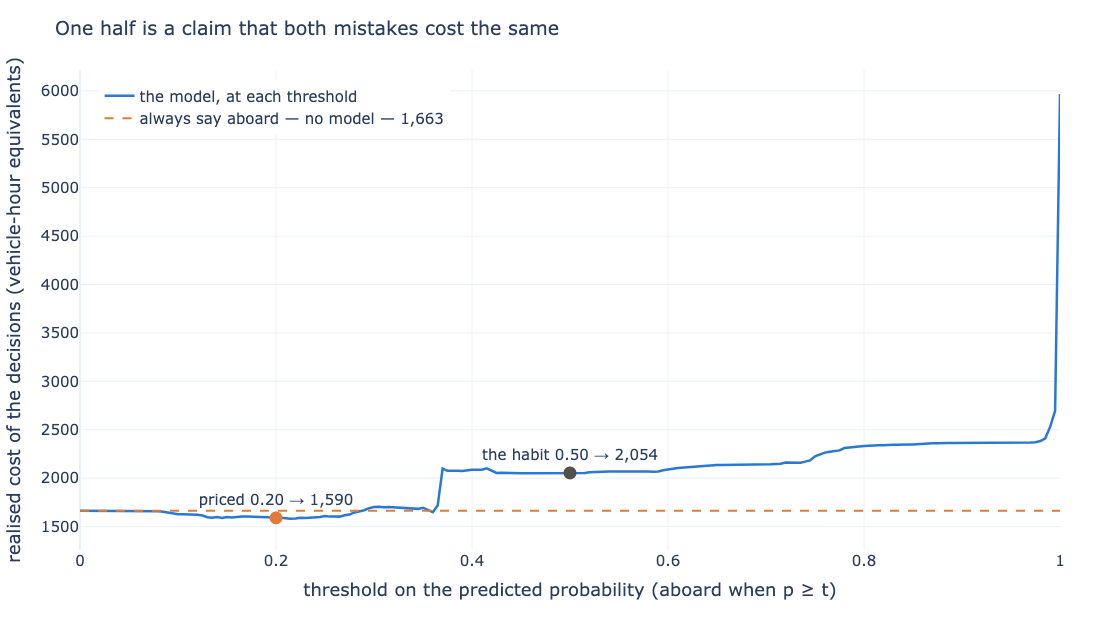

  saving against 0.5, per cent                                       deck 22.6       computed 22.6
the cheapest cutoff on these rows: 0.217, costing 1,580 (make_figs.py records 0.217)


In [107]:
figure_threshold(P_TEST, Y_TEST)
agrees("saving against 0.5, per cent", 100 * (1 - COST_PRICED / COST_HALF), 22.6, 1)
cheapest_at, cheapest_cost = cheapest_threshold(P_TEST, Y_TEST)
print(f"the cheapest cutoff on these rows: {cheapest_at:.3f}, costing {cheapest_cost:,.0f} "
      f"(make_figs.py records {json.loads((SLIDES / 'measured.json').read_text())['cheapest_threshold']['value']})")

### Against a rule that uses no model

*Slides: "How much is the model worth? Compare it with a rule that uses no model", "Four rules ranked by what they cost the operator" and "The cheaper service is the less accurate one".*

**Goal.** Rank the four rules by what they cost, with their accuracy beside.

**Why.** A saving against the habit measures the cutoff; a saving against the best rule that uses no model measures the model. Quote both — quoting only the first oversells the service (Provost & Fawcett, 2013, ch. 7).

**What the code does.** Prices always-not-aboard, the 0.5 cutoff, always-aboard and the 0.2 cutoff on the 3,241 rows, with each rule's accuracy.

**So what.** The trained model with the library's cutoff costs more than answering aboard to everything. The cheaper service, at 0.2, is the less accurate one: accuracy prices every mistake at one.

In [108]:
rules = [("Always answer not aboard", 1.01, False), ("The usual cutoff of 0.5", 0.5, True),
         ("Always answer aboard", 0.0, False), ("The priced cutoff of 0.2", PRICED, True)]
ranked = pd.DataFrame([{"rule": name, "cutoff": ("1" if cut > 1 else f"{cut:g}"),
                        "cost on the test rows": realised_cost(P_TEST, Y_TEST, cut, COST_FALSE_POSITIVE, COST_FALSE_NEGATIVE),
                        "accuracy": round(float(((P_TEST >= cut).astype(int) == Y_TEST).mean()), 4),
                        "uses the model": uses} for name, cut, uses in rules]).set_index("rule")
display(ranked)
costs = ranked["cost on the test rows"]
agrees("always not aboard", costs.iloc[0], 6312, 0)
agrees("always aboard, the no-model floor", costs.iloc[2], 1663, 0)
agrees("accuracy of always aboard (the aboard base rate)", ranked["accuracy"].iloc[2], 0.4869, 4)
agrees("accuracy at 0.5", ranked["accuracy"].iloc[1], 0.818, 3)
agrees("accuracy at 0.2", ranked["accuracy"].iloc[3], 0.5261, 4)
agrees("0.5 is worse than no model by, per cent", 100 * (COST_HALF / costs.iloc[2] - 1), 24, 0)
agrees("0.2 saves against the floor, per cent", 100 * (1 - COST_PRICED / costs.iloc[2]), 4.4, 1)

,cutoff,cost on the test rows,accuracy,uses the model
rule,,,,
Always answer not aboard,1,6312.0,0.5131,False
The usual cutoff of 0.5,0.5,2054.0,0.8180,True
Always answer aboard,0,1663.0,0.4869,False
The priced cutoff of 0.2,0.2,1590.0,0.5261,True


  always not aboard                                                  deck 6312       computed 6312
  always aboard, the no-model floor                                  deck 1663       computed 1663
  accuracy of always aboard (the aboard base rate)                   deck 0.4869     computed 0.4869
  accuracy at 0.5                                                    deck 0.818      computed 0.818
  accuracy at 0.2                                                    deck 0.5261     computed 0.5261
  0.5 is worse than no model by, per cent                            deck 24         computed 24
  0.2 saves against the floor, per cent                              deck 4.4        computed 4.4


### Calibration: is the probability honest?

*Slides: "Definition — calibration: is the probability honest?", "Definition — honesty is checked in bands, not one row at a time", "The reliability diagram is the band check drawn as a picture, in five steps" and "This model is not honest: it promises more aboard than happens".*

**Goal.** Write calibration, and look at the band the slide quotes.

**Why.** The cutoff 0.2 trusted p to be the real chance of aboard. A forecaster is well calibrated if, among the cases where the prediction was x, the long-run frequency is also x (DeGroot & Fienberg, 1983, § 2); good accuracy or a good area under the ROC curve does not make the probabilities honest (Niculescu-Mizil & Caruana, 2005, § 1).

**What the code does.** Writes the definition in sympy and measures the band from 0.6 to 0.8.

**So what.** The model promises 0.74 there and 49 in 100 were aboard. The slide says it said p ≈ 0.74 on one row in five; on these test rows that band holds one row in nineteen.

In [109]:
s_ = sp.Symbol("s", real=True)
formula(sp.Eq(sp.Function("P")(sp.Symbol(r"Y = 1 \mid \mathrm{score} = s")), s_),
        sp.Contains(s_, sp.Interval(0, 1)))
band = (P_TEST >= 0.6) & (P_TEST < 0.8)
agrees("the band 0.6 to 0.8 promises", P_TEST[band].mean(), 0.74, 2)
agrees("and delivers", Y_TEST[band].mean(), 0.49, 2)
beside("share of test rows in that band", f"{int(band.sum())} of {len(P_TEST):,} = 1 in {len(P_TEST) / band.sum():.0f}",
       "1 in 5", "the slide's proportion does not match the band's row count; the 1,678 rows of the band "
                 "0.2 to 0.4 are the ones near one in two")

<IPython.core.display.Math object>

  the band 0.6 to 0.8 promises                                       deck 0.74       computed 0.74
  and delivers                                                       deck 0.49       computed 0.49
  share of test rows in that band: computed here 169 of 3,241 = 1 in 19, stated 1 in 5 — the slide's proportion does not match the band's row count; the 1,678 rows of the band 0.2 to 0.4 are the ones near one in two


**Goal.** Write the band check.

**Why.** One row cannot check one probability. Group rows with similar p into bands of width 0.2, compare the mean promise with the share that happened, and drop a band too small to believe.

**What the code does.** Writes the three statements of the definition card in sympy, with membership of band j written as an indicator b_ij over the n rows, so the band's size, its mean promise and its share that happened are sums.

**So what.** The largest gap is the one-number summary of calibration.

In [110]:
row, band, rows_n = sp.Symbol("i", integer=True), sp.Symbol("j", integer=True), sp.Symbol("n", integer=True, positive=True)
p_i, y_i, e_ = sp.IndexedBase("p")[row], sp.IndexedBase("y")[row], sp.IndexedBase("e")
in_band = sp.Symbol("b_{ij}")
size_j, r_ = sp.Abs(sp.Symbol("B_j")), sp.Symbol("r", positive=True)
one = sp.Function(r"\mathbf{1}")
formula(sp.Eq(in_band, one(sp.And(sp.Le(e_[band], p_i), sp.Lt(p_i, e_[band + 1])))),
        sp.Eq(size_j, sp.Sum(in_band, (row, 1, rows_n))), sp.Ge(size_j, r_))
formula(sp.Eq(sp.Symbol(r"\mathrm{predicted}_j"), sp.Sum(in_band * p_i, (row, 1, rows_n)) / size_j),
        sp.Eq(sp.Symbol(r"\mathrm{actual}_j"), sp.Sum(in_band * y_i, (row, 1, rows_n)) / size_j))
formula(sp.Eq(sp.Symbol(r"\mathrm{largest\ gap}"),
              sp.Function(r"\max_j")(sp.Abs(sp.Symbol(r"\mathrm{predicted}_j") - sp.Symbol(r"\mathrm{actual}_j")))))

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

**Goal.** Define the band check as the Lab 3 solution writes it.

**Why.** The check grades the bands against its own arithmetic and against two invented models.

**What the code does.** Copies `reliability` from `solutions/lab_03.py`, verbatim. The last band is closed at the top, so a probability of exactly one is not quietly dropped.

**So what.** The function the diagram below is drawn from.

In [111]:
# Source: Module 3/exercises/solutions/lab_03.py — reliability, verbatim
# References: (DeGroot & Fienberg, 1983; Niculescu-Mizil & Caruana, 2005, § 4)

import pathlib
import sys
import numpy as np
from scipy import stats


def reliability(probabilities, truth, edges=CALIBRATION_EDGES,
                minimum_rows: int = CALIBRATION_MINIMUM_ROWS) -> dict:
    """The promise against the outcome, band by band, and the worst distance between them.

    Definition graded by the check:
        B_j = {i : e_j ≤ p_i < e_(j+1)}, the last band closed at the top; predicted_j = mean_{i ∈ B_j} p_i, actual_j = mean_{i ∈ B_j} y_i, kept when |B_j| ≥ r; largest gap = max_j |predicted_j − actual_j|
        (DeGroot & Fienberg, 1983; Niculescu-Mizil & Caruana, 2005). Slide:
        "Definition — reliability in bands, and the largest gap".

    Two lines of it are decisions rather than arithmetic, and both were got
    wrong here once.

    **The last band is closed at the top.** Written as `low <= p < high` all the
    way along, the table silently drops every probability of exactly one -- and
    those are the rows a forest is most confident and most nearly right about.
    Excluding the best-calibrated rows from a calibration table is not a
    rounding decision.

    **A band too small to believe is dropped rather than drawn.** A point on a
    reliability diagram carries the same visual weight whether it rests on six
    rows or a thousand, and the eye reads the six as a failure of the model
    rather than as a shortage of evidence.

    And the property itself is worth stating in the room's own currency: take
    every request the model scored 0.7 and count how many were aboard. A
    calibrated model gives you seven in ten. Ranking and calibration are
    different virtues -- a model can order every request perfectly and still
    promise numbers that mean nothing, which is why a threshold derived from
    PRICES is a starting point on an uncalibrated model rather than a guarantee
    (Niculescu-Mizil & Caruana, 2005).
    """
    scores = np.asarray(probabilities, dtype=float)
    outcomes = np.asarray(truth, dtype=float)
    bands, gaps = {}, []
    for index in range(len(edges) - 1):
        low, high = float(edges[index]), float(edges[index + 1])
        last = index == len(edges) - 2
        inside = (scores >= low) & (scores <= high if last else scores < high)
        if int(inside.sum()) < minimum_rows:
            continue
        promised, happened = float(scores[inside].mean()), float(outcomes[inside].mean())
        bands[f"p{int(round(low * 100)):02d}_{int(round(high * 100)):02d}"] = {
            "rows": int(inside.sum()), "predicted": promised, "actual": happened}
        gaps.append(abs(promised - happened))
    return {"bands": bands, "largest_gap": max(gaps) if gaps else 0.0}

**Goal.** Define the reliability diagram as the deck's script writes it.

**Why.** The slide's picture is drawn by `make_figs.py`.

**What the code does.** Copies `figure_reliability()` from `make_figs.py`, verbatim.

**So what.** The next cell feeds it the lab's bands.

In [112]:
# Source: Module 3/slides/make_figs.py — figure_reliability, verbatim

import json
import sys
from pathlib import Path
import numpy as np
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from scipy import stats


def figure_reliability(calibration):
    """The reliability diagram: what was promised against what happened.

    A score is calibrated when the event happens as often as the score says. The
    diagonal is that promise; a point below it is a band where the model
    over-predicted. This model sits below the diagonal almost everywhere, which
    is why block three calls the derived threshold a starting point rather than
    an optimum.
    """
    bands = list(calibration)
    predicted = [calibration[b]["predicted"] for b in bands]
    actual = [calibration[b]["actual"] for b in bands]
    rows = [calibration[b]["rows"] for b in bands]

    figure = go.Figure()
    figure.add_trace(go.Scatter(x=[0, 1], y=[0, 1], mode="lines",
                                line=dict(color=GREY, dash="dash", width=2),
                                name="perfect calibration"))
    figure.add_trace(go.Scatter(
        x=predicted, y=actual, mode="markers+lines+text",
        marker=dict(size=[12 + 22 * r / max(rows) for r in rows], color=BLUE),
        line=dict(color=BLUE, width=1.5),
        text=[f"{b.replace('p', '').replace('_', '–')}, {r:,} rows"
              for b, r in zip(bands, rows)],
        # The last band sits against the right edge, so its label goes inwards;
        # the middle two would otherwise collide, so they alternate.
        textposition=(["bottom right", "top left", "bottom right", "bottom right"]
                      + ["middle left"])[:len(bands)],
        name="this model, by band"))
    figure.update_layout(
        title="Promised against happened: the reliability diagram",
        xaxis_title="mean predicted probability of aboard, within the band (dimensionless)",
        yaxis_title="share of those rows that were aboard (dimensionless)",
        xaxis=dict(range=[0, 1.05]), yaxis=dict(range=[0, 1.05]),
        legend=dict(x=0.02, y=0.98))
    write(figure, "reliability")

**Goal.** Draw the reliability diagram of the model in service.

**Why.** Points below the diagonal promise more than happens; with inflated p, the formula sends buses too often.

**What the code does.** Computes the bands with the lab's `reliability()`, rounds them as `make_figs.py` records them, runs `figure_reliability()`, and scores two invented models: one that answers 0.6 to everything and one that answers 0.3 and 0.7 and means it.

**So what.** Below the diagonal almost everywhere; the worst band misses by 0.247. The derived cutoff is a starting point, and a sweep over cutoffs measures what the dishonesty costs. Of the two invented models, the more accurate one is the badly calibrated one.

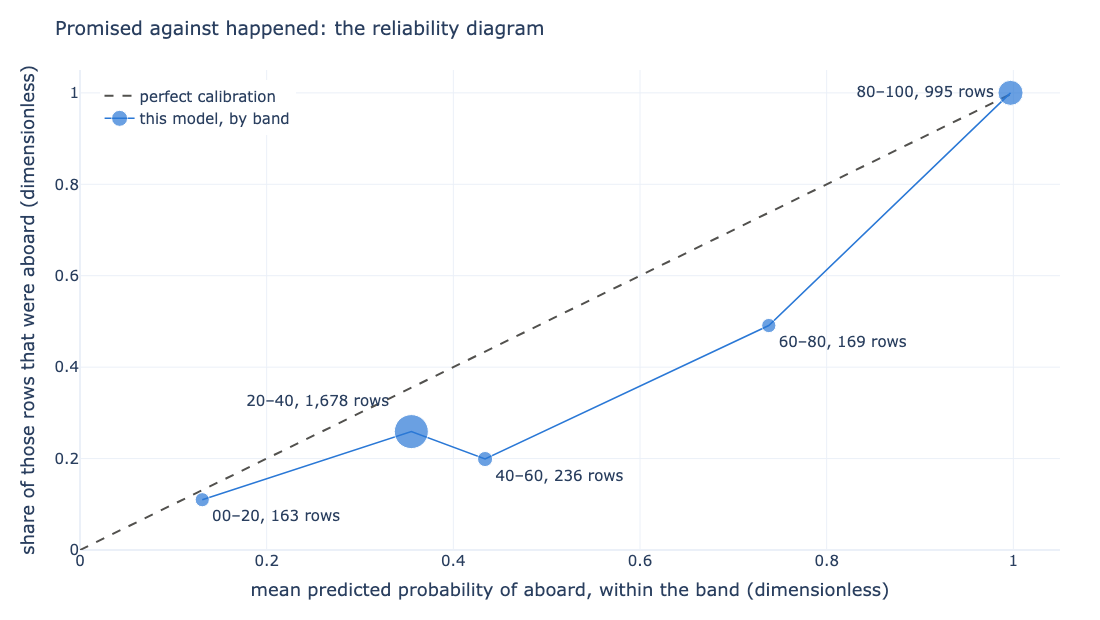

  band 0.6-0.8, promised                                             deck 0.738      computed 0.738
  band 0.6-0.8, happened                                             deck 0.491      computed 0.491
  largest gap                                                        deck 0.247      computed 0.247
  invented model that answers 0.6 to everything          accuracy 0.88, largest gap 0.28
  invented model that answers 0.3 and 0.7, and means it  accuracy 0.70, largest gap 0.00


In [113]:
DIAGRAM = reliability(P_TEST, Y_TEST, CALIBRATION_EDGES, CALIBRATION_MINIMUM_ROWS)
bands = {label: {"rows": b["rows"], "predicted": round(b["predicted"], 3), "actual": round(b["actual"], 3)}
         for label, b in DIAGRAM["bands"].items()}
figure_reliability(bands)
agrees("band 0.6-0.8, promised", bands["p60_80"]["predicted"], 0.738, 3)
agrees("band 0.6-0.8, happened", bands["p60_80"]["actual"], 0.491, 3)
agrees("largest gap", DIAGRAM["largest_gap"], 0.247, 3)
loud, loud_truth = np.full(2000, 0.6), np.r_[np.ones(1760, int), np.zeros(240, int)]
quiet = np.r_[np.full(1000, 0.3), np.full(1000, 0.7)]
quiet_truth = np.r_[np.ones(300, int), np.zeros(700, int), np.ones(700, int), np.zeros(300, int)]
for name, scores, outcomes in (("answers 0.6 to everything", loud, loud_truth),
                               ("answers 0.3 and 0.7, and means it", quiet, quiet_truth)):
    print(f"  invented model that {name:34} accuracy {((scores >= 0.5) == outcomes).mean():.2f}, "
          f"largest gap {reliability(scores, outcomes)['largest_gap']:.2f}")

### Second use of the prices: planning seats

*Slides: "Second use of the prices: planning seats, where demand is uncertain", "Jensen's inequality: cost of the average day ≠ average cost of the days", "A plan checked on the average forecast is optimistic" and "The mean cost of the departure is computed in four steps".* (The stress test of the cutoff at six cost ratios is on a hidden slide; it returns as a practice question at the end.)

**Goal.** Write the cost at the mean and the mean cost, and compute the second exactly.

**Why.** One departure, 12 seats, demand X Poisson with mean 10, a missed passenger priced at 4. The shortfall max(X − 12, 0) bends, and for a bending cost the average of the costs is at least the cost of the average (Jensen, 1906). Poisson is the law of independent arrivals; the capacity question is the classic inventory problem (Arrow, Harris & Marschak, 1951, § 3).

**What the code does.** Writes both in sympy, with the Poisson probabilities as sympy's own Poisson mass function, and sums the series exactly — the tail above 12 as the mean minus the finite sum below it.

**So what.** Cost at the mean 0; mean cost 2.124 vehicle-hours. The plan checked on the average day reports nothing wrong.

In [114]:
from sympy.stats import Poisson, density
lam, c, d = sp.symbols(r"\lambda c d", positive=True)
C_miss = sp.Symbol(r"C_{\mathrm{fn}}")
demand = Poisson("D", lam)
mass = density(demand)(d)                          # lambda^d e^(-lambda) / d!
formula(sp.Eq(sp.Symbol(r"g(E[D])"), C_miss * sp.Max(0, sp.Symbol("E[D]") - c), evaluate=False))
formula(sp.Eq(sp.Symbol(r"E[g(D)]"), C_miss * sp.Sum((d - c) * mass, (d, c + 1, sp.oo)), evaluate=False),
        sp.Eq(sp.Symbol("P(D = d)"), mass))
# E[max(D - c, 0)] = E[D] - c + sum_{d <= c} (c - d) P(D = d): an exact, finite sum
shortfall = 10 - 12 + sum((12 - dd) * sp.exp(-10) * sp.Integer(10)**dd / sp.factorial(dd) for dd in range(13))
exact_mean_cost = 4 * shortfall
agrees("mean cost, exact (sympy)", sp.N(exact_mean_cost, 30), 2.124, 3)

<IPython.core.display.Math object>

<IPython.core.display.Math object>

  mean cost, exact (sympy)                                           deck 2.124      computed 2.124


**Goal.** Define the departure's two numbers as the Lab 3 solution writes them.

**Why.** The optional fourth function of the lab computes the cost at the mean demand and the mean cost over the demand.

**What the code does.** Copies `cost_at_mean_versus_mean_cost` from `solutions/lab_03.py`, verbatim.

**So what.** The next cell compares it with the exact sum.

In [115]:
# Source: Module 3/exercises/solutions/lab_03.py — cost_at_mean_versus_mean_cost, verbatim
# References: (Jensen, 1906; Arrow, Harris & Marschak, 1951, § 3)

import pathlib
import sys
import numpy as np
from scipy import stats


def cost_at_mean_versus_mean_cost(capacity: int, mean_demand: float,
                                  price_false_negative: float):
    """The plan made on the average demand, against the average of the plans.

    Definition graded by the check:
        g(E[D]) = C_fn · max(0, E[D] − c) and E[g(D)] = C_fn · Σ_{d>c} (d − c) · P(D = d), with D ~ Poisson(λ)
        (Jensen, 1906; Module 4 block two proves the inequality). Slide:
        "Definition — cost at the mean versus mean cost".

    Everything above this function priced a mistake at a constant: a wasted
    vehicle-hour is one, a passenger left standing is four, whatever the day
    looks like. Under two constants the expected cost of a decision is a straight
    line in the probability, and the threshold rule is the whole story.

    Let the price grow with the size of the miss and the story changes. Twelve
    seats, demand around ten: at exactly ten passengers nobody is left behind and
    the cost is nought, so a plan checked against the average demand looks
    perfect. Average the cost over the days instead and it is not nought, because
    the days with sixteen passengers cost far more than the days with four save.
    The hinge max(0, D - c) bends upwards, and for a bending cost the average of
    the costs is at least the cost of the average (Jensen, 1906).

    Exactly, not by simulation: demand is Poisson, so the sum over the mass
    function is a closed computation that gives every machine the same number.
    """
    demand = np.arange(0, int(mean_demand) + 200)          # the tail past 200 above the mean is below 1e-300
    mass = stats.poisson.pmf(demand, mean_demand)
    cost_at_mean = price_false_negative * max(0.0, mean_demand - capacity)
    mean_cost = price_false_negative * float(
        (np.maximum(0, demand - capacity) * mass).sum())
    return cost_at_mean, mean_cost

**Goal.** Check the lab's departure against the exact sum, and the slide's three example days.

**Why.** A numerical sum can be truncated or rounded; the exact one cannot.

**What the code does.** Runs the lab's function with 12 seats, a mean demand of 10 and a miss priced at 4, compares its mean cost with the sympy value to 10⁻¹², and prices days with 13, 15 and 18 passengers.

**So what.** The same 2.124 both ways; one, three and six passengers left behind cost 4, 12 and 24.

In [116]:
at_mean, mean_cost = cost_at_mean_versus_mean_cost(SEATS, MEAN_DEMAND, COST_FALSE_NEGATIVE)
print(f"lab: cost at the mean {at_mean}, mean cost {mean_cost:.12f};  exact {sp.N(exact_mean_cost, 13)}")
assert abs(mean_cost - float(exact_mean_cost)) < 1e-12
for passengers, stated in ((13, 4), (15, 12), (18, 24)):
    agrees(f"cost of a day with {passengers} passengers", COST_FALSE_NEGATIVE * max(passengers - SEATS, 0), stated, 0)

lab: cost at the mean 0.0, mean cost 2.123665014830;  exact 2.123665014830
  cost of a day with 13 passengers                                   deck 4          computed 4
  cost of a day with 15 passengers                                   deck 12         computed 12
  cost of a day with 18 passengers                                   deck 24         computed 24


**Goal.** Define the two routes of Jensen's inequality, with the standalone deck's own code.

**Why.** The picture is the inequality itself: average the inputs and apply the curve, or apply the curve and average the outputs. For a curve that bends upward the second is higher. The picture and its argument follow a video lecture by Rich (2020).

**What the code does.** Copies the sample, the curve and `draw_two_routes()` from `standalone/jensens_inequality/slides/make_figs.py`, verbatim. The sample is thirty seeded normal draws; the curve is exp(0.75 x).

**So what.** Nothing is drawn yet; the gap between the two routes is already computed, as `GAP`.

In [117]:
# Source: standalone/jensens_inequality/slides/make_figs.py — BLUE, GREY, SCREEN, LAYOUT, RATE, SEED, SPREAD, SAMPLE_SIZE, TRUNCATE_AT, draw_sample, SAMPLE, curve, slope, MEAN_INPUT, OUTPUTS, OUTPUT_OF_MEAN, MEAN_OUTPUT, GAP, RATIO, grid, X_LOW, Y_LOW, X_RUG, Y_RUG, rugs, axis_marks, frame, draw_two_routes, verbatim
# References: (Rich, 2020; Jensen, 1906)

import json
import math
import random
from pathlib import Path
from statistics import NormalDist
import plotly.graph_objects as go
from plotly.subplots import make_subplots


# The palette of the shared specification: blue for the curve, red for the
# output of the average input, green for the average output, grey scaffolding.
BLUE, RED, GREEN = "#2A78D6", "#C0392B", "#1E8449"


GREY, GRID = "#52514E", "#E6E5E2"


# The picture reaches the slide 5.45 inches wide on a 13.33 inch canvas, so it
# is reduced to about a half on the way. Type set at 15 arrives at 7 point and is
# unreadable from the back of a room. SCREEN is the size that arrives at roughly
# the deck's own 17 point body, and every label below is set from it.
SCREEN = 34


LAYOUT = dict(template="plotly_white", font=dict(size=SCREEN, color="#0B0B0B"),
              plot_bgcolor="white", paper_bgcolor="white",
              margin=dict(l=110, r=40, t=70, b=96))


# The curve, and a real sample of the random variable.
#
# An earlier version of this file used eight equally spaced values. That is a
# ruler, not a random variable: it shows none of the crowding near the middle and
# thinning at the edges that makes the picture say anything, and it hides the
# thing Jensen's inequality is actually about — where the curve sends a sample.
# So X is drawn here, thirty values from a normal distribution, through the
# inverse distribution function of a seeded uniform stream. That is reproducible
# to the bit on any Python, and it still looks like a draw.
RATE = 0.75


SEED = 20260903


SPREAD = 1.05


SAMPLE_SIZE = 30


# One draw in a hundred lands past two and a third standard deviations and then
# owns the whole vertical axis, which squashes everything the picture is for.
# The draw is therefore truncated, and the slide is a picture rather than a claim
# about tails, so the choice costs nothing it needs.
TRUNCATE_AT = 2.35


def draw_sample() -> list[float]:
    stream = random.Random(SEED)
    normal = NormalDist(0.0, SPREAD)
    kept = []
    while len(kept) < SAMPLE_SIZE:
        value = normal.inv_cdf(stream.random())
        if abs(value) <= TRUNCATE_AT:
            kept.append(value)
    return sorted(kept)


SAMPLE = draw_sample()


def curve(x: float) -> float:
    return math.exp(RATE * x)


def slope(x: float) -> float:
    return RATE * math.exp(RATE * x)


MEAN_INPUT = sum(SAMPLE) / len(SAMPLE)


OUTPUTS = [curve(x) for x in SAMPLE]


OUTPUT_OF_MEAN = curve(MEAN_INPUT)          # the left side, f(E X)


MEAN_OUTPUT = sum(OUTPUTS) / len(OUTPUTS)   # the right side, E f(X)


GAP = MEAN_OUTPUT - OUTPUT_OF_MEAN


RATIO = MEAN_OUTPUT / OUTPUT_OF_MEAN


def grid(a: float, b: float, n: int = 361):
    return [a + (b - a) * i / (n - 1) for i in range(n)]


# The frame. Both pictures use it, so the sample sits in the same place on both
# and the room can carry the first slide's geometry onto the second.
X_LOW, X_HIGH = min(SAMPLE) - 0.95, max(SAMPLE) + 0.62


Y_LOW, Y_HIGH = -0.42, max(OUTPUTS) + 0.38


X_RUG = Y_LOW + 0.13          # where the draws of X are ticked, on the horizontal


Y_RUG = X_LOW + 0.17          # where their outputs are ticked, on the vertical


def rugs(fig, values, outputs, colour=GREY):
    """The sample on the horizontal axis, and where the curve sends it, on the
    vertical one. The thin elbows are the journey each draw makes: up to the
    curve, then across. They are what shows the crowding — draws sit thickest
    near the middle of X, and their outputs sit thickest near the bottom of Y.
    """
    xs, ys = [], []
    for value, output in zip(values, outputs):
        xs += [value, value, Y_RUG, None]
        ys += [X_RUG, output, output, None]
    fig.add_trace(go.Scatter(x=xs, y=ys, mode="lines",
                             line=dict(color="#D8D7D3", width=1),
                             hoverinfo="skip", showlegend=False))
    fig.add_trace(go.Scatter(x=values, y=[X_RUG] * len(values), mode="markers",
                             marker=dict(color=GREY, size=17, symbol="line-ns-open",
                                         line=dict(width=2, color=GREY)),
                             name="sample of X, and its outputs",
                             hovertemplate="draw %{x:.2f}<extra></extra>"))
    fig.add_trace(go.Scatter(x=[Y_RUG] * len(outputs), y=outputs, mode="markers",
                             marker=dict(color=GREY, size=17, symbol="line-ew-open",
                                         line=dict(width=2, color=GREY)),
                             showlegend=False,
                             hovertemplate="output %{y:.2f}<extra></extra>"))


def axis_marks(fig):
    """The two answers, ticked on the axis they are read from. Both routes end on
    the vertical axis, and the picture should say so without a caption."""
    fig.add_trace(go.Scatter(x=[Y_RUG, Y_RUG], y=[OUTPUT_OF_MEAN, MEAN_OUTPUT],
                             mode="markers", showlegend=False, hoverinfo="skip",
                             marker=dict(size=30, symbol="line-ew-open",
                                         color=[RED, GREEN],
                                         line=dict(width=5, color=[RED, GREEN]))))


def frame(fig, legend_y=0.99, y_low=None):
    fig.update_layout(
        legend=dict(x=0.115, y=legend_y, xanchor="left", yanchor="top",
                    bgcolor="rgba(255,255,255,0.86)", borderwidth=0,
                    font=dict(size=SCREEN)))
    fig.update_xaxes(title_text="values of X", range=[X_LOW, X_HIGH])
    fig.update_yaxes(title_text="values of Y = f(X)", dtick=1,
                     range=[Y_LOW if y_low is None else y_low, Y_HIGH])
    fig.update_xaxes(dtick=1)


def draw_two_routes() -> str:
    """The inequality itself: a sample on one axis, its outputs on the other.

    Route one goes along the red path — average the draws on the horizontal axis,
    up to the curve, across to the vertical one. Route two averages the ticks
    already sitting on the vertical axis. The two do not meet, and the whole of
    Jensen's inequality is which of them is higher.
    """
    xs = grid(X_LOW, X_HIGH)
    fig = go.Figure()
    rugs(fig, SAMPLE, OUTPUTS)
    fig.add_trace(go.Scatter(x=xs, y=[curve(x) for x in xs], mode="lines",
                             line=dict(color=BLUE, width=4), name="the curve, Y = f(X)",
                             hovertemplate="x %{x:.2f} → %{y:.2f}<extra></extra>"))

    # Route two: the average of the ticks on the vertical axis.
    fig.add_hline(y=MEAN_OUTPUT, line=dict(color=GREEN, width=3))
    fig.add_trace(go.Scatter(x=[None], y=[None], mode="lines",
                             line=dict(color=GREEN, width=3),
                             name="avg f(X), average output"))
    # Route one: the average of the ticks on the horizontal axis, taken up to the
    # curve and across. The path is drawn, because the path is the argument.
    fig.add_trace(go.Scatter(x=[MEAN_INPUT, MEAN_INPUT, Y_RUG],
                             y=[X_RUG, OUTPUT_OF_MEAN, OUTPUT_OF_MEAN],
                             mode="lines", line=dict(color=RED, width=3),
                             name="f(avg X), output of the average",
                             hoverinfo="skip"))
    fig.add_trace(go.Scatter(x=[MEAN_INPUT], y=[X_RUG], mode="markers",
                             marker=dict(color=RED, size=17, symbol="triangle-up"),
                             showlegend=False, hoverinfo="skip"))
    fig.add_trace(go.Scatter(x=[MEAN_INPUT], y=[OUTPUT_OF_MEAN], mode="markers",
                             marker=dict(color=RED, size=15), showlegend=False,
                             hoverinfo="skip"))
    fig.add_annotation(x=MEAN_INPUT + 0.13, y=X_RUG + 0.12, text="avg X",
                       showarrow=False, xanchor="left", yanchor="bottom",
                       font=dict(color=RED, size=SCREEN))

    # The gap, read on the vertical axis where both routes finish.
    bar = Y_RUG + 0.30
    fig.add_shape(type="line", x0=bar, x1=bar, y0=OUTPUT_OF_MEAN, y1=MEAN_OUTPUT,
                  line=dict(color=GREY, width=3))
    fig.add_annotation(x=bar + 0.10, y=(OUTPUT_OF_MEAN + MEAN_OUTPUT) / 2,
                       text=f"the gap, {GAP:.2f}", showarrow=False,
                       xanchor="left", yanchor="middle",
                       font=dict(color=GREY, size=SCREEN))
    axis_marks(fig)
    frame(fig)
    return save(fig, "two_routes")

**Goal.** Show the standalone script's figure in place instead of writing it to disk.

**Why.** There `save()` writes `figures/<name>.png` for its deck.

**What the code does.** Defines `save()` with the script's layout and font sizes, drawing the figure in place — the one function of that script that is not copied.

**So what.** `draw_two_routes()` runs unchanged in the next cell.

In [118]:
def save(fig, name, width=1100, height=740):
    """The standalone script's save(), shown in place instead of written to figures/."""
    settings = dict(LAYOUT)
    if fig.layout.margin.t is not None:
        settings.pop("margin")
    fig.update_layout(width=width, height=height, **settings)
    for note in fig.layout.annotations:
        if note.font.size is None or note.font.size == 16:
            note.font.size = SCREEN
    fig.update_xaxes(gridcolor=GRID, zerolinecolor=GRID)
    fig.update_yaxes(gridcolor=GRID, zerolinecolor=GRID)
    display(Image(fig.to_image(format="png", width=width, height=height, scale=1)))
    return name

**Goal.** Draw the two routes, and write the inequality they illustrate.

**Why.** The slide shows this picture; the inequality is its one-line summary.

**What the code does.** Runs `draw_two_routes()`, checks the gap the slide prints, and writes Jensen's inequality for a sample of n inputs in sympy: if the curve bends upward (its second derivative is positive), the curve at the mean input is at most the mean of the curve's outputs.

**So what.** A gap of 0.28 in the picture — the same shape as the departure's 2.124 vehicle-hours.

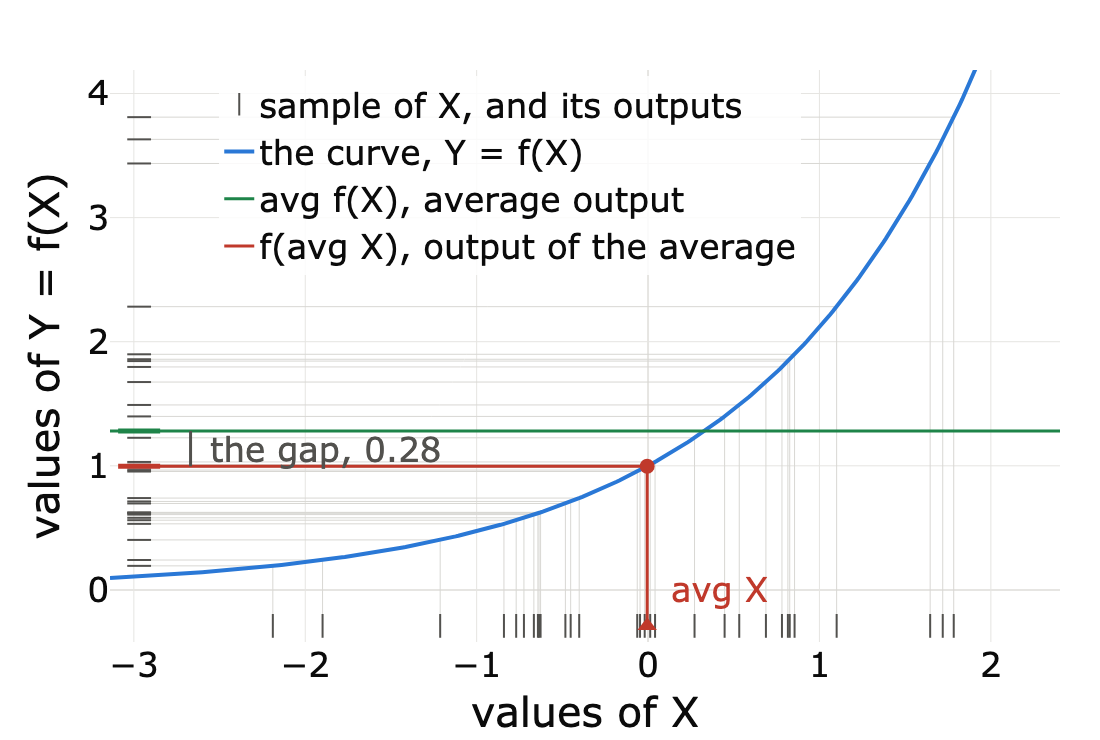

  the gap in the picture                                             deck 0.28       computed 0.28


<IPython.core.display.Math object>

In [119]:
draw_two_routes()
agrees("the gap in the picture", GAP, 0.28, 2)
f_, u_ = sp.Function("f"), sp.Symbol("x")
j_, n_j = sp.Symbol("i", integer=True), sp.Symbol("n", integer=True, positive=True)
X_i = sp.IndexedBase("X")[j_]
formula(sp.Implies(sp.Gt(sp.Derivative(f_(u_), (u_, 2)), 0),
                   sp.Le(f_(sp.Sum(X_i, (j_, 1, n_j)) / n_j), sp.Sum(f_(X_i), (j_, 1, n_j)) / n_j)))

**Goal.** Put the course's seed back.

**Why.** The standalone script has its own `SEED`, 20260903, and its cell just set the global name to it; the module's code reads 20200122.

**What the code does.** Restores the module's seed.

**So what.** Nothing below is drawn from the Jensen sample's seed.

In [120]:
SEED = 20200122

**Goal.** Define the departure figure as the deck's script writes it.

**Why.** The slide's picture is drawn by `make_figs.py`.

**What the code does.** Copies `figure_jensen()` from `make_figs.py`, verbatim.

**So what.** The next cell feeds it the departure's numbers.

In [121]:
# Source: Module 3/slides/make_figs.py — figure_jensen, verbatim

import json
import sys
from pathlib import Path
import numpy as np
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from scipy import stats


def figure_jensen(shared):
    """The hinge over the demand, with the cost at the mean and the mean cost.

    Two constant prices give a cost that is linear in the probability, and then
    the threshold rule is the whole story. Price a miss by how many people are
    left standing and the cost bends: nought at ten passengers in twelve seats,
    and not nought on average, because the sixteen-passenger days cost more than
    the four-passenger days save.
    """
    demand = np.arange(0, 21)
    mass = stats.poisson.pmf(demand, MEAN_DEMAND)
    cost = COST_FALSE_NEGATIVE * np.maximum(0, demand - SEATS)

    figure = make_subplots(specs=[[{"secondary_y": True}]])
    figure.add_trace(go.Bar(x=demand, y=mass, marker_color=GREY, opacity=0.45,
                            name="probability of that demand"), secondary_y=True)
    figure.add_trace(go.Scatter(x=demand, y=cost, mode="lines+markers",
                                line=dict(color=BLUE, width=3),
                                name="cost of the day: 4 × max(0, D − 12)"),
                     secondary_y=False)
    figure.add_trace(go.Scatter(
        x=[MEAN_DEMAND], y=[shared["cost_at_mean_demand"]], mode="markers+text",
        marker=dict(color=ORANGE, size=15), textposition="top right",
        text=[f"cost at the mean demand: {shared['cost_at_mean_demand']:.3f}"],
        name="cost at the mean"), secondary_y=False)
    figure.add_trace(go.Scatter(
        x=[0, 20], y=[shared["mean_cost"], shared["mean_cost"]], mode="lines",
        line=dict(color=RED, width=2, dash="dash"),
        name=f"mean cost over the days: {shared['mean_cost']:.3f}"), secondary_y=False)
    figure.add_vline(x=MEAN_DEMAND, line_color=ORANGE, line_dash="dot")
    figure.update_layout(
        title="The cost of the average day is not the average cost of the days",
        xaxis_title="demand at the departure (passengers)",
        legend=dict(x=0.02, y=0.98))
    figure.update_yaxes(title_text="cost of the day (vehicle-hour equivalents)",
                        secondary_y=False, rangemode="tozero")
    figure.update_yaxes(title_text="probability of that demand (dimensionless)",
                        secondary_y=True, rangemode="tozero", showgrid=False)
    write(figure, "jensen")

**Goal.** Draw the departure: the cost of each day's demand, the chance of that demand, and the two numbers.

**Why.** The same shape as the previous picture, with the module's own numbers.

**What the code does.** Computes the departure with `jensen_departure()` (copied from `make_figs.py` earlier), draws it with `figure_jensen()`, checks the two numbers the slide prints, and records where the slide's footer says they come from.

**So what.** Cost at the mean 0, mean cost 2.124. And the capacity that balances the two prices is the 0.8 quantile of demand, 13 seats — the same ratio as the cutoff, read as a demand quantile.

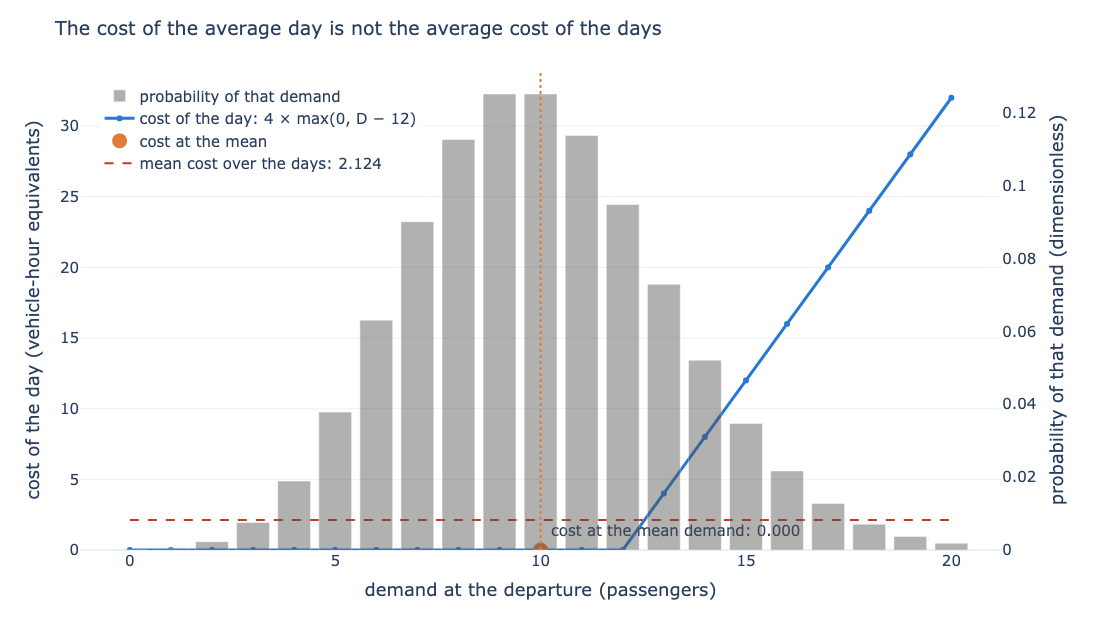

  cost at the mean demand                                            deck 0          computed 0.0
  mean cost over the days                                            deck 2.124      computed 2.124
critical fractile C_fn / (C_fp + C_fn) = 0.8, capacity at it: 13 seats
  where the slide's footer says these numbers come from: computed here the Poisson mass function (make_figs.py, jensen_departure), stated "service/models.py, trained on Module 2's generated table" — the figure's own credit line is right; the numbers line on that slide is the deck's template footer


In [122]:
departure = jensen_departure()
figure_jensen(departure)
agrees("cost at the mean demand", departure["cost_at_mean_demand"], 0, 3)
agrees("mean cost over the days", departure["mean_cost"], 2.124, 3)
print(f"critical fractile C_fn / (C_fp + C_fn) = {departure['critical_fractile']}, "
      f"capacity at it: {departure['capacity_at_critical_fractile']} seats")
beside("where the slide's footer says these numbers come from", "the Poisson mass function (make_figs.py, jensen_departure)",
       "\"service/models.py, trained on Module 2's generated table\"",
       "the figure's own credit line is right; the numbers line on that slide is the deck's template footer")

## Laboratory 3 — Price the threshold

*Slide: "Lab 3 — Price the threshold: you write the three functions this block
used".* `threshold_from_costs`, `realised_cost`, `reliability`, and an optional
fourth, `cost_at_mean_versus_mean_cost`. What you take away: the prices, not the
model, decide the cutoff; the cost, not accuracy, decides whether it is good; and a
probability must be checked before it is trusted.

**The exercise, exactly as `Module 3/exercises/labs/03_the_threshold.py` states it.**

> Lab 3 — What a mistake costs.
>
> Why this lab exists: a model returns a probability and a service must return a
> decision, so somebody has to choose the cutoff — and the cutoff almost everybody
> uses, one half, is the specific claim that the two mistakes cost the same. You
> derive the cutoff from the two prices instead, measure what it saves against the
> habit and against using no model at all, and then meet the case the derivation
> does not cover: a price that grows with the size of the miss.
> Where it sits: Block 3 — "The threshold is a property of the costs, not of the
> model", "Price against doing nothing, as well as against the habit" and "When the
> price of a miss is not a constant", and the definition slides "Definition — the
> cost-sensitive threshold", "Definition — realised cost of a threshold" and
> "Definition — cost at the mean versus mean cost".
> What the check grades: threshold_from_costs() returns C_fp / (C_fp + C_fn) for
> all twenty-nine pairs of costs it is given, not only the round ones;
> reliability() bins the model's own probabilities the way the deck's diagram does
> and reports the largest distance from the diagonal, on the service's output and
> on two invented models — one accurate and badly calibrated, one calibrated and
> less accurate;
> realised_cost() prices the derived threshold below one half on the model's own
> output and prices a threshold of nought at exactly the number of rows that were
> not aboard; and, if you write the optional cost_at_mean_versus_mean_cost(), the
> mean cost it returns is at least the cost at the mean demand and equals the
> module's measured value for the shared twelve-seat departure.
> Needs: numpy, scipy.
>
> Twenty-five minutes.
>
> A model returns a probability. A service returns a decision. Turning one into
> the other requires a cutoff, and the cutoff most people use is one half —
> because it is the middle, not because anybody priced anything.
>
> One half is correct in exactly one circumstance: when the two mistakes cost the
> same. They almost never do.
>
> Our service answers "is this passenger aboard?" Consider what each mistake does:
>
>     a false positive   we say aboard, they are not. The vehicle is recorded
>                        fuller than it is; dispatch may send a shuttle nobody
>                        needs. Cost: one wasted vehicle-hour.
>
>     a false negative   we say not aboard, they are. The vehicle is recorded
>                        emptier than it is; a passenger is left at a stop
>                        because the system believes there is room where there is
>                        not. Cost: a person waiting in January, and a complaint.
>
> If the second is four times worse than the first, one half is not a defensible
> cutoff and nobody chose it.
>
> What you write: threshold_from_costs(cost_false_positive, cost_false_negative).
>
>     The arithmetic, from expected value. Decide "aboard" when the expected cost
>     of doing so is no higher than the expected cost of not:
>
>         p . 0 + (1-p) . C_fp   <=   p . C_fn + (1-p) . 0
>
>     which rearranges to p >= C_fp / (C_fp + C_fn). That ratio is the threshold.
>     Note what it does not contain: the model. The cutoff is a property of the
>     consequences, not of the classifier (Elkan, 2001).
>
>     Sanity checks you can do in your head: equal costs give one half; a false
>     negative four times worse gives one fifth; a false positive that costs
>     nothing gives zero, and the service should say "aboard" every time.
>
> Then write: realised_cost(probabilities, truth, threshold, cost_fp, cost_fn).
>
>     The word matters. This is not an expectation: it is the total the decisions
>     that threshold produces actually cost on the rows you have, counted after
>     the fact. An expected cost would be an average over a distribution of
>     outcomes that has not happened yet. The check uses this one to confirm your
>     derived threshold costs less than one half — measured, on the model's own
>     output, rather than argued.
>
> Then write: reliability(probabilities, truth, edges, minimum_rows).
>
>     The derivation above assumed something without saying so: that when the
>     model says 0.7, the thing happens about seven times in ten. That property is
>     called **calibration**, and prices need it, because a price multiplies a
>     probability. Measure whether this model has it.
>
>     Sort the probabilities into bands between `edges`, and for each band report
>     how many rows fell in it, the mean probability the model promised, and the
>     share that were actually aboard. Report the largest distance between the two
>     across the bands. That is the reliability diagram of block three, as a
>     number.
>
>     Two bands' worth of arithmetic, and one uncomfortable result: the check
>     hands you a model that is more accurate than another and much worse
>     calibrated. Accuracy and calibration are different properties of the same
>     numbers, and a service that prices its decisions needs the second.
>
> Then, optional and graded only if you write it:
> cost_at_mean_versus_mean_cost(capacity, mean_demand, price_false_negative).
>
>     The two prices above are constants, so the expected cost of a decision is a
>     straight line in the probability and the threshold rule is the whole story.
>     Now let the price of a miss grow with the size of the miss: one departure,
>     `capacity` seats, demand D uncertain with mean `mean_demand`. The passengers
>     left standing are max(0, D - capacity), and that hinge bends.
>
>     Return two numbers: the cost computed at the average demand, and the average
>     of the cost over the demand. They are not the same number, and the second is
>     never the smaller — Jensen's inequality (Jensen, 1906), which Module 4
>     proves and which reuses this exact departure.
>
> The check passes when threshold_from_costs() returns C_fp / (C_fp + C_fn) for
> every one of the twenty-nine pairs of costs it tries — not only the round ones —
> when realised_cost() prices the derived threshold below the habitual one half
> on the model's own output, and prices a threshold of zero at exactly the number
> of rows that were not aboard, and when reliability() reproduces the check's own
> bands on the service's output, puts a probability of exactly one in the last
> band, drops a band too small to believe, and reports a gap of nought for a
> calibrated model and a large one for an accurate model that is not calibrated. Write the optional function and it is graded too:
> mean cost at least the cost at the mean, and the module's measured gap for the
> twelve-seat departure to within a thousandth.

```python
def threshold_from_costs(cost_false_positive: float, cost_false_negative: float) -> float:
    """The probability at or above which "aboard" is the cheaper decision.
    
    Definition graded by the check:
        t* = C_fp / (C_fp + C_fn); decide aboard ⇔ p ≥ t*
        (Elkan, 2001, pp. 973-978). Choices: the boundary is decided in favour of
        "aboard" (p ≥ t*, not p > t*); for a continuous score the two rules
        differ on a set of probability nought, and this module picks one and
        uses it in the stub, the check, the slides and the figures. Slide:
        "Definition — the cost-sensitive threshold".
    Needs: no library — two costs in, one number out"""
```

```python
def realised_cost(probabilities, truth, threshold: float,
                  cost_false_positive: float, cost_false_negative: float) -> float:
    """What this cutoff cost on the rows you have — counted, not expected.
    
    Args:
        probabilities: predicted probability of "aboard", one per row.
        truth:         1 where actually aboard, 0 where not.
    
    Definition graded by the check:
        K(t) = C_fp · #{i : p_i ≥ t and y_i = 0} + C_fn · #{i : p_i < t and y_i = 1}
        (Elkan, 2001; Provost & Fawcett, 2013, ch. 7). Choices: the total over
        the test period, not an average and not an expectation; the decision rule
        is p ≥ t, the same one threshold_from_costs derives; correct decisions
        are priced at nought. Slide: "Definition — realised cost of a threshold".
    Needs: numpy"""
```

```python
def reliability(probabilities, truth, edges=CALIBRATION_EDGES,
                minimum_rows: int = CALIBRATION_MINIMUM_ROWS) -> dict:
    """What the model promised against what happened, band by band.
    
    Args:
        probabilities: predicted probability of "aboard", one per row.
        truth:         1 where actually aboard, 0 where not.
        edges:         the band boundaries, in order.
        minimum_rows:  bands holding fewer rows than this are dropped.
    
    Returns:
        {"bands": {label: {"rows": int, "predicted": float, "actual": float}},
         "largest_gap": float}
    
        The label of the band between low and high is "pLL_HH" -- the two edges
        as whole percentages, two digits each, so the band from 0.6 to 0.8 is
        "p60_80" and the first is "p00_20".
    
    Definition graded by the check:
        B_j = {i : e_j ≤ p_i < e_(j+1)}, the last band closed at the top; predicted_j = mean_{i ∈ B_j} p_i, actual_j = mean_{i ∈ B_j} y_i, kept when |B_j| ≥ r; largest gap = max_j |predicted_j − actual_j|
        (DeGroot & Fienberg, 1983; Niculescu-Mizil & Caruana, 2005). e_j are
        `edges` and r is `minimum_rows`. Choices: bands of equal width rather
        than equal count; half-open except the last, which is closed so that a
        probability of exactly one is not quietly dropped; a band below the floor
        is dropped rather than reported, because a handful of rows promises
        nothing. Slide: "Definition — reliability in bands, and the largest gap".
    Needs: numpy"""
```

```python
def cost_at_mean_versus_mean_cost(capacity: int, mean_demand: float,
                                  price_false_negative: float):
    """Optional, and graded if you write it: the plan on the average against the average of the plans.
    
    Definition graded by the check:
        g(E[D]) = C_fn · max(0, E[D] − c) and E[g(D)] = C_fn · Σ_{d>c} (d − c) · P(D = d), with D ~ Poisson(λ)
        (Jensen, 1906; Module 4 block two proves the inequality). Choices: demand
        is Poisson with mean λ = mean_demand, so the sum is exact and no seed is
        involved; only the shortfall is priced here, because the empty seat is
        the other module's half of the example. Slide: "Definition — cost at the
        mean versus mean cost".
    Needs: scipy, numpy"""
```

### The solution, step by step

The four functions were defined above. First the lab file's own demonstration; then the solution's own, one paragraph of its `__main__` block per cell.

**Goal.** Run the stub's own `__main__` block against the solved functions.

**Why.** It is what a student sees when the file is complete.

**What the code does.** The lines below are the stub's demonstration, verbatim.

**So what.** 0.200 against the habit's 0.500.

In [123]:
# Source: Module 3/exercises/labs/03_the_threshold.py — demonstration step 0, verbatim

priced = threshold_from_costs(COST_FALSE_POSITIVE, COST_FALSE_NEGATIVE)
print(f"priced threshold: {priced:.3f}   (the habit: 0.500)")

priced threshold: 0.200   (the habit: 0.500)


**Goal.** Import what the demonstration needs beyond the functions above.

**Why.** The block draws with plotly, tabulates with pandas and narrates with `_narrate`.

**What the code does.** Imports plotly, pandas and the narration helpers the set-up registered. From here on the cells are `python3 solutions/lab_03.py`, one paragraph of its `__main__` block per cell.

**So what.** Nothing runs yet.

In [124]:
# Source: Module 3/exercises/solutions/lab_03.py — demonstration, paragraph 1 of 12, verbatim

import plotly.graph_objects as go
import pandas as pd
from _narrate import narrator, show_table, save_figure

**Goal.** Start the narration.

**Why.** Every line the solution prints goes through `say`, stamped with the seconds since the notebook began.

**What the code does.** Creates the narrator for Lab 3 and prints the demonstration's one-line summary.

**So what.** The timings differ from run to run; nothing else does.

In [125]:
# Source: Module 3/exercises/solutions/lab_03.py — demonstration, paragraph 2 of 12, verbatim

say = narrator(LAB)
say.info("Lab 3 — the cutoff comes from the two prices, and then it is measured "
         "against the habit and against using no model at all")

 14.54s  lab 3  Lab 3 — the cutoff comes from the two prices, and then it is measured against the habit and against using no model at all


**Goal.** Load the champion and cut the test period.

**Why.** The cost must be counted on rows the model never trained on, and later in time than the rows it did.

**What the code does.** Loads v1's artefact and its stored transform, loads the table, and keeps the later 30 per cent of rows.

**So what.** The same 3,241 rows as the rest of the notebook.

In [126]:
# Source: Module 3/exercises/solutions/lab_03.py — demonstration, paragraph 3 of 12, verbatim

artefact = load_artefact("v1")
transform = artefact["transform"]
table = load_table()
test = table.iloc[int(len(table) * 0.7):]
say.info("loaded the champion (v1) and the table: %d rows, generated (seed 20200122); "
         "the later 30 per cent, %d rows, is the test period — split by time, because "
         "a random split would let the model see the future", len(table), len(test))

 14.56s  lab 3  loaded the champion (v1) and the table: 10800 rows, generated (seed 20200122); the later 30 per cent, 3241 rows, is the test period — split by time, because a random split would let the model see the future


**Goal.** Score the test period.

**Why.** Prices multiply probabilities, so the probabilities come first.

**What the code does.** Fills and scales the test rows with the stored medians, means and standard deviations, asks the forest for the probability of aboard, and marks the truth.

**So what.** A probability and a true answer for every test row.

In [127]:
# Source: Module 3/exercises/solutions/lab_03.py — demonstration, paragraph 4 of 12, verbatim

prepared = np.column_stack([
    ((test[f].astype(float).fillna(transform["medians"][f]) - transform["means"][f])
     / transform["stds"][f]).to_numpy() for f in transform["features"]])
probabilities = artefact["model"].predict_proba(prepared)[:, 1]
truth = (test["label2"] == "IN").astype(int).to_numpy()
say.info("scored the test period: %d rows, %d recorded aboard, %d not",
         len(truth), int(truth.sum()), int((truth == 0).sum()))

 14.58s  lab 3  scored the test period: 3241 rows, 1578 recorded aboard, 1663 not


**Goal.** Derive the cutoff from the two prices.

**Why.** The cutoff is the operator's arithmetic, not the model's.

**What the code does.** Calls `threshold_from_costs(1, 4)` and prints the ratio.

**So what.** 0.200, computed without looking at the model.

In [128]:
# Source: Module 3/exercises/solutions/lab_03.py — demonstration, paragraph 5 of 12, verbatim

priced = threshold_from_costs(COST_FALSE_POSITIVE, COST_FALSE_NEGATIVE)
say.info("prices from the operator: a false positive costs %.0f wasted vehicle-hour, a "
         "false negative %.0f — so the cutoff is C_fp / (C_fp + C_fn) = %.3f, and the "
         "model never entered that arithmetic", COST_FALSE_POSITIVE,
         COST_FALSE_NEGATIVE, priced)

 14.59s  lab 3  prices from the operator: a false positive costs 1 wasted vehicle-hour, a false negative 4 — so the cutoff is C_fp / (C_fp + C_fn) = 0.200, and the model never entered that arithmetic


**Goal.** Price four policies on the test rows.

**Why.** A saving against the habit measures the cutoff; a saving against the best rule without a model measures the model.

**What the code does.** Computes the realised cost at 0.2, at 0.5, for answering aboard to everyone and for answering not aboard to everyone, and prints the two savings.

**So what.** 22.6 per cent saved against 0.5, and 4.4 per cent against the no-model floor of 1,663 — which 0.5 itself does not beat.

In [129]:
# Source: Module 3/exercises/solutions/lab_03.py — demonstration, paragraph 6 of 12, verbatim

at_priced = realised_cost(probabilities, truth, priced,
                          COST_FALSE_POSITIVE, COST_FALSE_NEGATIVE)
at_half = realised_cost(probabilities, truth, 0.5,
                        COST_FALSE_POSITIVE, COST_FALSE_NEGATIVE)
always_aboard = realised_cost(probabilities, truth, 0.0,
                              COST_FALSE_POSITIVE, COST_FALSE_NEGATIVE)
always_not = realised_cost(probabilities, truth, 1.01,
                           COST_FALSE_POSITIVE, COST_FALSE_NEGATIVE)
say.info("realised cost at the priced threshold %.2f: %.0f (vehicle-hour equivalents, "
         "on the test period)", priced, at_priced)
say.info("realised cost at the habitual 0.50: %.0f — the priced cutoff saves %.1f per "
         "cent against the habit", at_half, (1 - at_priced / at_half) * 100)
say.info("and against no model at all: say aboard to everybody %.0f, say not aboard to "
         "everybody %.0f — the floor is %.0f, so the model plus its threshold saves "
         "%.1f per cent against the best thing you could do without it", always_aboard,
         always_not, min(always_aboard, always_not),
         (1 - at_priced / min(always_aboard, always_not)) * 100)
say.info("note which comparison flatters: one half is dearer than answering aboard "
         "without asking the model, so a saving quoted only against the habit hides "
         "that the habit was worse than doing nothing")

 14.60s  lab 3  realised cost at the priced threshold 0.20: 1590 (vehicle-hour equivalents, on the test period)


 14.60s  lab 3  realised cost at the habitual 0.50: 2054 — the priced cutoff saves 22.6 per cent against the habit


 14.60s  lab 3  and against no model at all: say aboard to everybody 1663, say not aboard to everybody 6312 — the floor is 1663, so the model plus its threshold saves 4.4 per cent against the best thing you could do without it


 14.60s  lab 3  note which comparison flatters: one half is dearer than answering aboard without asking the model, so a saving quoted only against the habit hides that the habit was worse than doing nothing


**Goal.** Tabulate the four policies with their accuracy beside their cost.

**Why.** Accuracy prices both mistakes the same; the table shows where that misleads.

**What the code does.** Builds one table of threshold, realised cost and accuracy for the four policies.

**So what.** The cheapest policy is not the most accurate one.

In [130]:
# Source: Module 3/exercises/solutions/lab_03.py — demonstration, paragraph 7 of 12, verbatim

show_table(pd.DataFrame({
    "policy": ["priced threshold", "the habit, one half", "always aboard, no model",
               "always not aboard, no model"],
    "threshold": [round(priced, 3), 0.5, 0.0, float("nan")],
    "realised cost": [at_priced, at_half, always_aboard, always_not],
    "accuracy": [float(((probabilities >= t).astype(int) == truth).mean())
                 for t in (priced, 0.5, 0.0, 1.01)]}),
    "four policies, priced", logger=say)
say.info("accuracy disagrees with cost on purpose: it weighs both mistakes the same, "
         "which is the assumption this block spent its time rejecting")

 14.61s  lab 3  --- four policies, priced (4 rows) ---


 14.61s  lab 3                              policy  threshold  realised cost  accuracy


 14.61s  lab 3      0             priced threshold        0.2           1590    0.5261


 14.61s  lab 3      1          the habit, one half        0.5           2054     0.818


 14.61s  lab 3      2      always aboard, no model          0           1663    0.4869


 14.61s  lab 3      3  always not aboard, no model        NaN           6312    0.5131


 14.61s  lab 3  accuracy disagrees with cost on purpose: it weighs both mistakes the same, which is the assumption this block spent its time rejecting


**Goal.** Check calibration band by band, and on two invented models.

**Why.** The derivation assumed the probabilities were honest without saying so.

**What the code does.** Computes the reliability bands of the test period, prints the largest gap, then scores a model that answers 0.6 to everything and one that answers 0.3 and 0.7 and means it.

**So what.** Largest gap 0.247; and of the two invented models, the more accurate is the one whose probabilities mean nothing.

In [131]:
# Source: Module 3/exercises/solutions/lab_03.py — demonstration, paragraph 8 of 12, verbatim

# Calibration: the assumption the derivation made without saying so.
diagram = reliability(probabilities, truth, CALIBRATION_EDGES, CALIBRATION_MINIMUM_ROWS)
show_table(pd.DataFrame([{"band": label, **band}
                         for label, band in diagram["bands"].items()]),
           "promised against happened, by band (bands under "
           f"{CALIBRATION_MINIMUM_ROWS} rows dropped)", logger=say)
say.info("largest distance from the diagonal: %.3f — this model over-predicts almost "
         "everywhere, so the derived threshold is a principled starting point rather "
         "than a guaranteed optimum (Niculescu-Mizil & Caruana, 2005)",
         diagram["largest_gap"])
say.info("and the pair the check grades, because accuracy and calibration are different "
         "properties of the same numbers:")
loud = np.full(2000, 0.6)
loud_truth = np.zeros(2000, dtype=int); loud_truth[:1760] = 1
quiet = np.concatenate([np.full(1000, 0.3), np.full(1000, 0.7)])
quiet_truth = np.zeros(2000, dtype=int)
quiet_truth[:300] = 1; quiet_truth[1000:1700] = 1
for name, scores, outcomes in (("answers 0.6 to everything", loud, loud_truth),
                               ("answers 0.3 and 0.7, and means it", quiet, quiet_truth)):
    measured = reliability(scores, outcomes, CALIBRATION_EDGES, CALIBRATION_MINIMUM_ROWS)
    say.info("  %-34s accuracy at one half %.2f, largest gap %.2f", name,
             float(((scores >= 0.5).astype(int) == outcomes).mean()),
             measured["largest_gap"])
say.info("the more accurate of those two is the one whose probabilities mean nothing, "
         "and a price multiplies a probability")

 14.62s  lab 3  --- promised against happened, by band (bands under 50 rows dropped) (5 rows) ---


 14.62s  lab 3            band  rows  predicted  actual


 14.63s  lab 3      0   p00_20   163     0.1313  0.1104


 14.63s  lab 3      1   p20_40  1678     0.3546  0.2592


 14.63s  lab 3      2   p40_60   236     0.4341  0.1992


...

 14.63s  lab 3  largest distance from the diagonal: 0.247 — this model over-predicts almost everywhere, so the derived threshold is a principled starting point rather than a guaranteed optimum (Niculescu-Mizil & Caruana, 2005)


 14.63s  lab 3  and the pair the check grades, because accuracy and calibration are different properties of the same numbers:


 14.63s  lab 3    answers 0.6 to everything          accuracy at one half 0.88, largest gap 0.28


 14.63s  lab 3    answers 0.3 and 0.7, and means it  accuracy at one half 0.70, largest gap 0.00


 14.63s  lab 3  the more accurate of those two is the one whose probabilities mean nothing, and a price multiplies a probability


**Goal.** Draw the reliability bands.

**Why.** The table of bands is easier to read as distance from the diagonal.

**What the code does.** Plots each band's promise against what happened, sized by its rows, beside the diagonal of perfect calibration.

**So what.** Almost every band sits below the diagonal: the model promises more aboard than happens.

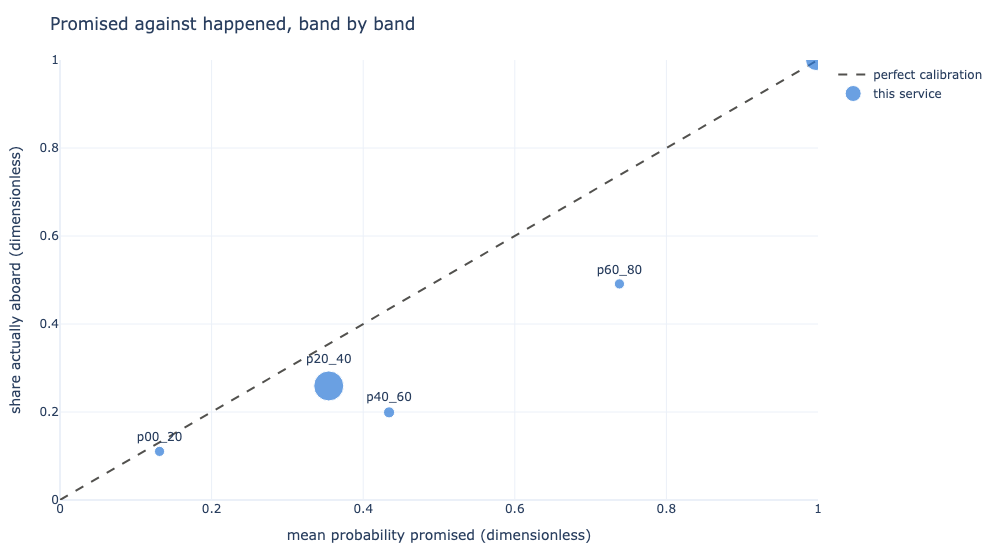

In [132]:
# Source: Module 3/exercises/solutions/lab_03.py — demonstration, paragraph 9 of 12, verbatim

fig = go.Figure()
labels = list(diagram["bands"])
fig.add_trace(go.Scatter(x=[0, 1], y=[0, 1], mode="lines", line=dict(dash="dash",
                         color="#52514E"), name="perfect calibration"))
fig.add_trace(go.Scatter(
    x=[diagram["bands"][b]["predicted"] for b in labels],
    y=[diagram["bands"][b]["actual"] for b in labels], mode="markers+text",
    text=labels, textposition="top center", name="this service",
    marker=dict(color="#2A78D6",
                size=[8 + 22 * (diagram["bands"][b]["rows"] / max(
                    diagram["bands"][x]["rows"] for x in labels)) for b in labels])))
fig.update_layout(template="plotly_white",
                  title="Promised against happened, band by band",
                  xaxis_title="mean probability promised (dimensionless)",
                  yaxis_title="share actually aboard (dimensionless)")
fig.update_xaxes(range=[0, 1]); fig.update_yaxes(range=[0, 1])
save_figure(fig, "reliability_bands", LAB, logger=say)

**Goal.** Draw the realised cost at every cutoff.

**Why.** The formula chose 0.2 from the prices alone; the curve shows where that lands.

**What the code does.** Prices 201 cutoffs from 0 to 1, draws the curve with the no-model floor, and marks the priced cutoff and the habit.

**So what.** 0.2 sits near the flat bottom; 0.5 sits above the floor.

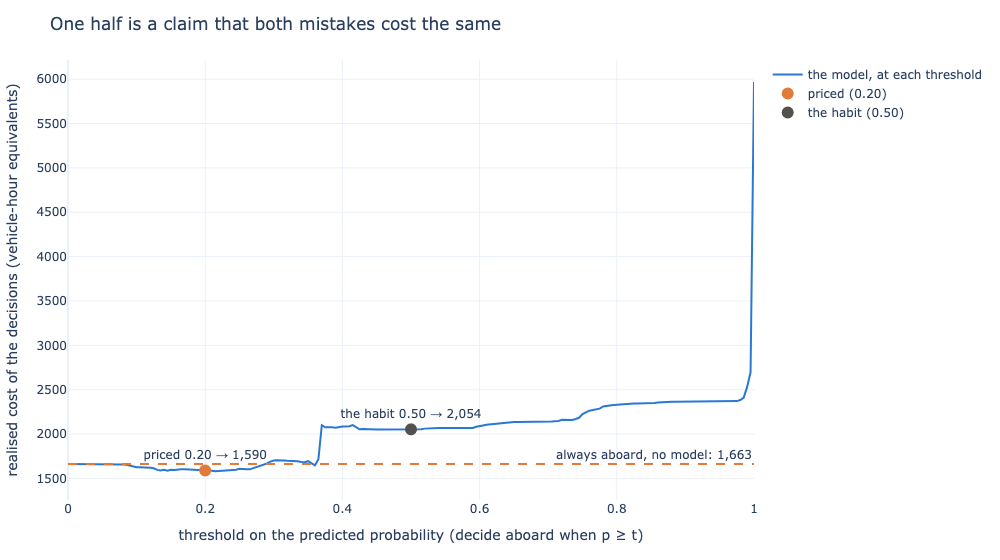

In [133]:
# Source: Module 3/exercises/solutions/lab_03.py — demonstration, paragraph 10 of 12, verbatim

thresholds = np.linspace(0.0, 1.0, 201)
costs = [realised_cost(probabilities, truth, t, COST_FALSE_POSITIVE, COST_FALSE_NEGATIVE)
         for t in thresholds]
fig = go.Figure()
fig.add_trace(go.Scatter(x=thresholds, y=costs, mode="lines", name="the model, at each threshold",
                         line=dict(color="#2A78D6", width=2)))
fig.add_hline(y=always_aboard, line_dash="dash", line_color="#E07B39",
              annotation_text=f"always aboard, no model: {always_aboard:,.0f}",
              annotation_position="top right")
for value, colour, name in ((priced, "#E07B39", "priced"), (0.5, "#52514E", "the habit")):
    here = realised_cost(probabilities, truth, value, COST_FALSE_POSITIVE, COST_FALSE_NEGATIVE)
    fig.add_trace(go.Scatter(x=[value], y=[here], mode="markers+text",
                             text=[f"{name} {value:.2f} → {here:,.0f}"],
                             textposition="top center", marker=dict(size=12, color=colour),
                             name=f"{name} ({value:.2f})"))
fig.update_layout(template="plotly_white",
                  title="One half is a claim that both mistakes cost the same",
                  xaxis_title="threshold on the predicted probability (decide aboard when p ≥ t)",
                  yaxis_title="realised cost of the decisions (vehicle-hour equivalents)")
save_figure(fig, "cost_by_threshold", LAB, logger=say)

**Goal.** Price the departure where the cost bends.

**Why.** A plan checked at the average demand is optimistic when the cost of a shortfall bends.

**What the code does.** Calls `cost_at_mean_versus_mean_cost(12, 10, 4)`, prints both numbers, and the capacity at the C_FN / (C_FP + C_FN) quantile of Poisson demand.

**So what.** 0 at the mean, 2.124 on average; 13 seats at the 0.8 quantile.

In [134]:
# Source: Module 3/exercises/solutions/lab_03.py — demonstration, paragraph 11 of 12, verbatim

cost_at_mean, mean_cost = cost_at_mean_versus_mean_cost(SEATS, MEAN_DEMAND,
                                                        COST_FALSE_NEGATIVE)
say.info("the departure where the price of a miss is not a constant: %d seats, demand "
         "Poisson with mean %.0f, a passenger left standing priced at %.0f",
         SEATS, MEAN_DEMAND, COST_FALSE_NEGATIVE)
say.info("cost computed at the average demand: %.3f — at ten passengers in twelve seats "
         "nobody is left behind, so the plan looks perfect", cost_at_mean)
say.info("average of the cost over the demand: %.3f vehicle-hour equivalents — the gap "
         "is %.3f, and it is not noise: max(0, D - c) bends, so the average of the costs "
         "is at least the cost of the average (Jensen, 1906; Module 4 proves it)",
         mean_cost, mean_cost - cost_at_mean)
say.info("the closure: the capacity that balances the two prices is the "
         "C_fn / (C_fp + C_fn) = %.1f quantile of demand, %d seats — the same ratio as "
         "this lab's threshold, read as a demand quantile rather than a probability",
         COST_FALSE_NEGATIVE / (COST_FALSE_POSITIVE + COST_FALSE_NEGATIVE),
         int(stats.poisson.ppf(COST_FALSE_NEGATIVE
                               / (COST_FALSE_POSITIVE + COST_FALSE_NEGATIVE), MEAN_DEMAND)))

 14.91s  lab 3  the departure where the price of a miss is not a constant: 12 seats, demand Poisson with mean 10, a passenger left standing priced at 4


 14.91s  lab 3  cost computed at the average demand: 0.000 — at ten passengers in twelve seats nobody is left behind, so the plan looks perfect


 14.91s  lab 3  average of the cost over the demand: 2.124 vehicle-hour equivalents — the gap is 2.124, and it is not noise: max(0, D - c) bends, so the average of the costs is at least the cost of the average (Jensen, 1906; Module 4 proves it)


 14.91s  lab 3  the closure: the capacity that balances the two prices is the C_fn / (C_fp + C_fn) = 0.8 quantile of demand, 13 seats — the same ratio as this lab's threshold, read as a demand quantile rather than a probability


**Goal.** Say what the check grades.

**Why.** A student should know what a pass means before running the check.

**What the code does.** Prints the solution's one-line summary of the check's requirements, with the departure's mean cost.

**So what.** Nothing new is computed here.

In [135]:
# Source: Module 3/exercises/solutions/lab_03.py — demonstration, paragraph 12 of 12, verbatim

say.info("what the check grades: the ratio C_fp / (C_fp + C_fn) at twenty-nine pairs of "
         "costs, the realised cost of the priced threshold below that of one half, the "
         "cost at threshold nought equal to the not-aboard rows, the reliability bands "
         "against its own arithmetic and against two invented models — one accurate "
         "and badly calibrated, one calibrated and less accurate — and, if written, the "
         "mean cost at least the cost at the mean and equal to the module's measured "
         "%.3f", mean_cost)

 14.91s  lab 3  what the check grades: the ratio C_fp / (C_fp + C_fn) at twenty-nine pairs of costs, the realised cost of the priced threshold below that of one half, the cost at threshold nought equal to the not-aboard rows, the reliability bands against its own arithmetic and against two invented models — one accurate and badly calibrated, one calibrated and less accurate — and, if written, the mean cost at least the cost at the mean and equal to the module's measured 2.124


### Appendix — how to calibrate a model's probabilities

*Slide: "Appendix — how to calibrate a model's probabilities" (3.1 and 3.2).* Do not retrain the model: fit a small second function g on its scores, on rows it never trained on, and check the result with the reliability bands on a third set.

**Goal.** Write the three calibration maps, and try the first two on the model in service.

**Why.** Platt scaling fits an S-shape and corrects best a sigmoid-shaped distortion; isotonic regression fits any never-decreasing step function, and so corrects any monotone distortion, but overfits when calibration rows are few (Niculescu-Mizil & Caruana, 2005, § 1–2; Platt, 1999; Zadrozny & Elkan, 2002); temperature scaling divides a network's logits by one number (Guo et al., 2017).

**What the code does.** Writes the three maps in sympy — the isotonic map as a function g that never decreases, temperature scaling as a softmax over the K classes — then splits the 3,241 test rows alternately into a calibration half and an evaluation half, fits a logistic curve and an isotonic step function to the model's probabilities on the first half, and measures the largest reliability gap on the second half before and after.

**So what.** Isotonic regression cuts the largest gap from about 0.28 to 0.08 without touching the forest, fitted on about 1,600 rows — above the thousand or so calibration cases from which Niculescu-Mizil and Caruana found it as good as Platt scaling or better (Niculescu-Mizil & Caruana, 2005, § 5). Platt scaling does not help here: this forest over-promises in almost every band rather than bending both ends towards the middle. And honest probabilities do not make 0.2 cheaper on these rows — calibration buys the right to trust p, and the check afterwards is what tells you whether the priced cutoff still holds.

In [136]:
a_, b_, s_, T_ = sp.symbols("a b s T")
s_1, s_2 = sp.symbols("s_1 s_2")
g_ = sp.Function("g")
k_c, j_c, K_c = sp.Symbol("k", integer=True), sp.Symbol("j", integer=True), sp.Symbol("K", integer=True, positive=True)
z_ = sp.IndexedBase("z")
formula(sp.Eq(sp.Symbol(r"p_{\mathrm{Platt}}"), 1 / (1 + sp.exp(a_ * s_ + b_)), evaluate=False))
formula(sp.Eq(sp.Symbol(r"p_{\mathrm{isotonic}}"), g_(s_)), sp.Implies(sp.Le(s_1, s_2), sp.Le(g_(s_1), g_(s_2))))
formula(sp.Eq(sp.Symbol(r"p_{\mathrm{temperature},\,k}"),
              sp.exp(z_[k_c] / T_) / sp.Sum(sp.exp(z_[j_c] / T_), (j_c, 1, K_c))))
from sklearn.isotonic import IsotonicRegression
from sklearn.linear_model import LogisticRegression
fit_half, check_half = np.arange(len(P_TEST)) % 2 == 0, np.arange(len(P_TEST)) % 2 == 1
platt = LogisticRegression().fit(P_TEST[fit_half].reshape(-1, 1), Y_TEST[fit_half])
isotonic = IsotonicRegression(out_of_bounds="clip").fit(P_TEST[fit_half], Y_TEST[fit_half])
for name, calibrated in (("raw forest", P_TEST[check_half]),
                         ("Platt scaling", platt.predict_proba(P_TEST[check_half].reshape(-1, 1))[:, 1]),
                         ("isotonic regression", isotonic.predict(P_TEST[check_half]))):
    gap = reliability(calibrated, Y_TEST[check_half])["largest_gap"]
    cost = realised_cost(calibrated, Y_TEST[check_half], PRICED, COST_FALSE_POSITIVE, COST_FALSE_NEGATIVE)
    print(f"  {name:20} largest gap {gap:.3f}   realised cost at 0.2 on the evaluation half {cost:,.0f}")

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

  raw forest           largest gap 0.279   realised cost at 0.2 on the evaluation half 740
  Platt scaling        largest gap 0.291   realised cost at 0.2 on the evaluation half 821
  isotonic regression  largest gap 0.082   realised cost at 0.2 on the evaluation half 784


---
# Part 3.2 — Deploying a model as a service, II

*Deck: `Module3.2.pptx`.* The second lecture opens with a recap poster, the course's
position slide, the case and the layered-data picture of 3.1. The poster is an
AI-generated infographic and the others are the video frame and the medallion
picture, none reproduced (see `figure_map.json`); the route of the case is the map
drawn from the slice at the start of Part 3.1.

## Block four — Training–serving skew, and latency percentiles

### The failure where nothing goes wrong

*Slides: "Look first: one model, the same 3,241 requests, two batches, all requests successful", "27.1 per cent of decisions changed and every request returned 200" and "A model does not know its columns by name, only by position".*

**Goal.** Send the same 3,241 requests twice — once as trained, once with two columns swapped in the preparation — and draw both batches of answers.

**Why.** Every request succeeds both times, the status is 200 and the response time is unchanged. The model knows position one, two and three, not names: hand it signal strength where it expects speed and it answers just as confidently.

**What the code does.** Copies `figure_skew()` from `make_figs.py`, verbatim: it swaps the first two prepared columns, speed and rssi1, asks the champion again and draws both batches.

**So what.** The next cell runs it on the test period.

In [137]:
# Source: Module 3/slides/make_figs.py — figure_skew, verbatim

import json
import sys
from pathlib import Path
import numpy as np
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from scipy import stats


def figure_skew(artefact, prepared, probabilities):
    """What happens when two columns are swapped and nothing complains."""
    swapped = prepared.copy()
    swapped[:, [0, 1]] = swapped[:, [1, 0]]
    skewed = artefact["model"].predict_proba(swapped)[:, 1]

    figure = go.Figure()
    figure.add_trace(go.Histogram(x=probabilities, xbins=dict(start=0, end=1, size=0.025),
                                  marker_color=BLUE, name="columns as trained"))
    figure.add_trace(go.Histogram(x=skewed, xbins=dict(start=0, end=1, size=0.025),
                                  marker_color=ORANGE, opacity=0.75,
                                  name="two columns swapped"))
    figure.update_layout(
        barmode="overlay", title="Every request succeeded. Both times.",
        xaxis_title="predicted probability of aboard (dimensionless)",
        yaxis_title="requests in the test period (count)",
        legend=dict(x=0.34, y=0.98))
    write(figure, "skew")
    return skewed

**Goal.** Run the swap on the 3,241 test rows and count what changed.

**Why.** The damage of a skew is measured in decisions, at the cutoff the service uses.

**What the code does.** Runs `figure_skew()` on the champion and the prepared test rows, then counts the decisions that changed at the priced cutoff and the accuracy before and after.

**So what.** 27.1 per cent of decisions changed and accuracy fell from 0.5261 to 0.4428, with no error anywhere. Only the spread of the probabilities changed — which a watcher of the outputs could have caught.

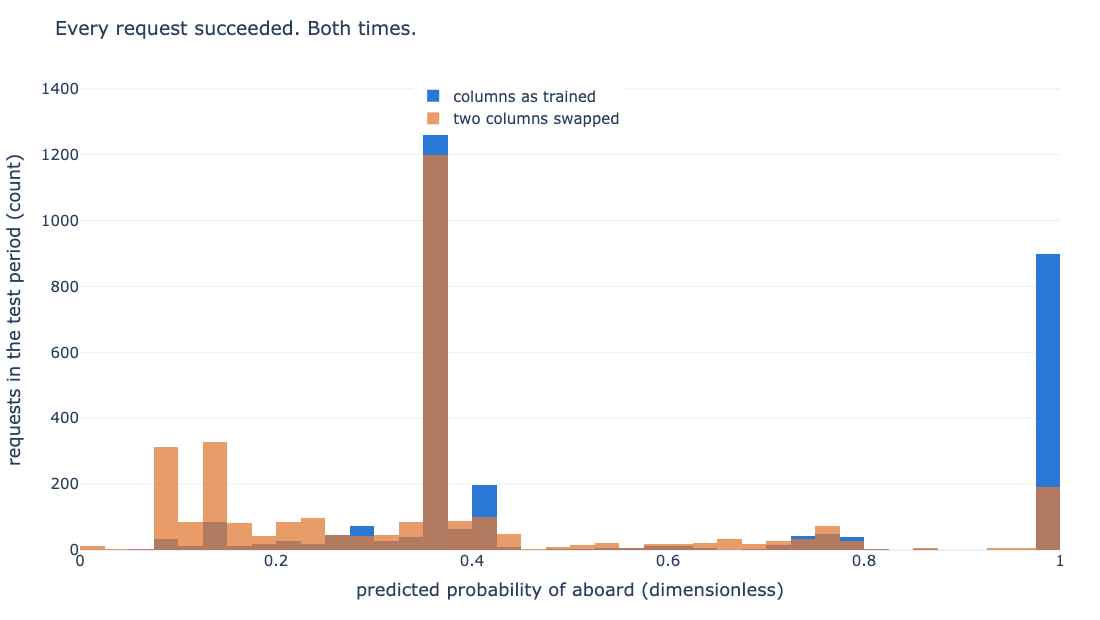

  decisions changed, per cent                                        deck 27.1       computed 27.1
  accuracy before the swap, at 0.2                                   deck 0.5261     computed 0.5261
  accuracy after the swap, at 0.2                                    deck 0.4428     computed 0.4428


In [138]:
SKEWED = figure_skew(ARTEFACT_V1, X_TEST, P_TEST)
before_swap, after_swap = P_TEST >= PRICED, SKEWED >= PRICED
agrees("decisions changed, per cent", 100 * (before_swap != after_swap).mean(), 27.1, 1)
agrees("accuracy before the swap, at 0.2", ((before_swap.astype(int)) == Y_TEST).mean(), 0.5261, 4)
agrees("accuracy after the swap, at 0.2", ((after_swap.astype(int)) == Y_TEST).mean(), 0.4428, 4)

**Goal.** Write training–serving skew and its cure.

**Why.** Skew is the input prepared one way at fitting and another at asking; the most common cause is two code paths for the same preparation (Breck et al., 2019, § 4; Huyen, 2022). The cure is one preparation, looped over the *stored* order and filled from the *stored* median, never from the request's keys or live traffic.

**What the code does.** Writes the two statements of the definition card in sympy: skew as the two preparations disagreeing, and the one preparation as a fill then a z-score, each with the stored constants of the j-th field in the stored order.

**So what.** One preparation, whose every constant was fixed at fitting.

In [139]:
x_ = sp.Symbol("x")
formula(sp.Equivalent(sp.Symbol(r"\mathrm{skew}"),
                      sp.Ne(sp.Function(r"\mathrm{prepare}_{\mathrm{serve}}")(x_),
                            sp.Function(r"\mathrm{prepare}_{\mathrm{train}}")(x_))))
stored_constant = lambda what: sp.Symbol(rf"\mathrm{{{what}}}_{{f_j}}")      # fitted once, on the training rows
x_fj, v_ = sp.IndexedBase("x")[sp.Symbol("f_j")], sp.Symbol("v_j")
formula(sp.Eq(v_, sp.Piecewise((x_fj, sp.Ne(x_fj, sp.Symbol(r"\mathrm{null}"))), (stored_constant("median"), True))),
        sp.Eq(sp.Symbol(r"\mathrm{input}_j"), (v_ - stored_constant("mean")) / stored_constant("std"), evaluate=False))

<IPython.core.display.Math object>

<IPython.core.display.Math object>

**Goal.** Define the cure as the Lab 4 solution writes it.

**Why.** The cure loops over the *stored* order and fills from the *stored* median, never from the request's keys or live traffic.

**What the code does.** Copies Lab 4's constants and `prepare` from `solutions/lab_04.py`, verbatim.

**So what.** The next cell checks it against the service's own preparation.

In [140]:
# Source: Module 3/exercises/solutions/lab_04.py — LAB, PRICED_THRESHOLD, TARGET, SKEW_EXCHANGE, prepare, verbatim
# References: (Breck et al., 2019; Huyen, 2022)

import math
import pathlib
import sys
import time
import numpy as np
import pandas as pd
from mlflow.exceptions import MlflowException


LAB = 4


PRICED_THRESHOLD = 0.2


TARGET, ABOARD = "label2", "IN"


SKEW_EXCHANGE = ("speed", "rssi1")


def prepare(request: dict, transform: dict):
    """Build the model's input from the transform, never from the request.

    Definition graded by the check:
        skew ⇔ prepare_serve(x) ≠ prepare_train(x); cure: input_j = ((x[f_j] if present else median_{f_j}) − mean_{f_j}) / std_{f_j} for f_j in the stored order, j = 1..k
        (Breck et al., 2019). Slide: "Definition — training–serving skew".

    The single line that matters is the loop being over `transform["features"]`
    rather than over the request's own keys. A model does not know its columns
    by name — it knows position one, position two, position three. Iterate over
    whatever order the caller happened to send and one day a client library
    changes its serialiser, the keys arrive alphabetically, signal strength
    lands where speed is expected, and every request still succeeds.

    That is what makes training-serving skew so unpleasant: there is no error to
    find. The service is healthy, the latency is fine, the responses are
    well-formed, and the answers are wrong. The only symptom is a metric drifting
    somewhere downstream, and by then the cause is weeks behind you.

    Filling a missing optional field with the *stored* median matters for the
    same reason. Compute a median from live traffic and the service is preparing
    input differently from how the model was taught — the same failure wearing
    different clothes.
    """
    row = []
    for feature in transform["features"]:
        value = request.get(feature)
        if value is None:
            value = transform["medians"][feature]
        row.append((float(value) - transform["means"][feature]) / transform["stds"][feature])
    return [row]

**Goal.** Check that `prepare()` is the service's preparation, whatever order the keys arrive in.

**Why.** Two implementations of one preparation are how skew starts; the lab's must equal the stored transform's to the last bit.

**What the code does.** Cuts the test period from the table, sends every test row through `prepare()` with its keys reversed, and compares with `apply_transform()` on the same rows.

**So what.** Identical to the last bit, whatever order the request's keys arrive in.

In [141]:
whole_table = build_table()
TEST_ROWS = whole_table.iloc[int(len(whole_table) * 0.7):].reset_index(drop=True)
stored = ARTEFACT_V1["transform"]
by_prepare = np.array([prepare({f: (None if pd.isna(r[f]) else float(r[f])) for f in reversed(FEATURES)}, stored)[0]
                       for _, r in TEST_ROWS.iterrows()])
by_service = apply_transform(TEST_ROWS, stored).to_numpy()
print(f"prepare() with the keys reversed against apply_transform(), {len(TEST_ROWS):,} rows: "
      f"largest difference {np.abs(by_prepare - by_service).max():.1e}")

prepare() with the keys reversed against apply_transform(), 3,241 rows: largest difference 0.0e+00


*Slides: "One example pipeline. This service prepares its input in four steps" and
"Skew can be caught. Four checks, from cheapest to strongest".* The four steps are
the stored order, the stored median, and the stored mean and standard deviation;
any cleaning, imputation, encoding or scaling of Modules 1 and 2 could stand in each
step, as long as each is fitted on the training rows and replayed at serving. The
four checks: validate the request against the stored schema; compare live inputs
with training inputs field by field; compare live outputs with training outputs —
the spread of the probabilities, which is exactly what changed in the skew figure
above; and run the same preparation on a stored table and on single requests and
require identical numbers, which is Lab 4 (Breck et al., 2019, § 3–4).

**Goal.** Record where the third check's changing spread is actually drawn.

**Why.** Slide 12 says "Slide 74 shows this spread changing". This deck has no slide 74; the number belongs to the earlier single deck, whose slide 74 is now hidden in 3.1 and shows the cost-ratio stress test.

**What the code does.** Prints the difference and adds it to the closing table.

**So what.** The spread is the skew figure above, 3.2 slides 7 and 8.

In [142]:
beside("where the third check's changing spread is shown", "the skew figure, 3.2 slides 7-8 (above)",
       "\"Slide 74\"", "a reference to a slide number of the earlier single deck; 3.1 slide 74 is hidden "
                        "and shows the cost-ratio stress test, not the spread")

  where the third check's changing spread is shown: computed here the skew figure, 3.2 slides 7-8 (above), stated "Slide 74" — a reference to a slide number of the earlier single deck; 3.1 slide 74 is hidden and shows the cost-ratio stress test, not the spread


**Goal.** Write the measurement of a caused skew.

**Why.** A failure you have produced is one you recognise. The share is of *decisions*, because a probability that moves without crossing the cutoff costs nothing.

**What the code does.** Writes the definition card's formula in sympy — the share of the n rows whose decision at t differs once the exchange π is applied — and the two conditions on it.

**So what.** A caused skew is a share of decisions, no failures, and nought after the cure.

In [143]:
row, rows_n, t_ = sp.Symbol("i", integer=True), sp.Symbol("n", integer=True, positive=True), sp.Symbol("t")
pi_ = sp.Symbol(r"\pi")
one = sp.Function(r"\mathbf{1}")
p_i, p_i_pi = sp.IndexedBase("p")[row], sp.IndexedBase(r"p^{\pi}")[row]
changed = sp.Function(r"\mathrm{changed}")
formula(sp.Eq(changed(pi_), sp.Sum(one(sp.Ne(one(sp.Ge(p_i, t_)), one(sp.Ge(p_i_pi, t_)))), (row, 1, rows_n)) / rows_n))
formula(sp.Eq(sp.Function(r"\mathrm{failures}")(pi_), 0),
        sp.Eq(changed(sp.Symbol(r"\pi_{\mathrm{stored\ order}}")), 0))

<IPython.core.display.Math object>

<IPython.core.display.Math object>

**Goal.** Define the caused skew as the Lab 4 solution writes it.

**Why.** The lab causes the skew in the requests themselves — two fields exchanged, the row built in arrival order — and then cures it.

**What the code does.** Copies `cause_and_cure_skew` from `solutions/lab_04.py`, verbatim.

**So what.** The next cell runs it for the slide's two exchanges.

In [144]:
# Source: Module 3/exercises/solutions/lab_04.py — cause_and_cure_skew, verbatim
# References: (Breck et al., 2019; Huyen, 2022)

import math
import pathlib
import sys
import time
import numpy as np
import pandas as pd
from mlflow.exceptions import MlflowException


def cause_and_cure_skew(frame, artefact: dict, exchange=SKEW_EXCHANGE,
                        threshold: float = PRICED_THRESHOLD) -> dict:
    """Produce the failure, count it, and put it right.

    Definition graded by the check:
        changed(π) = |{i : 1[p_i ≥ t] ≠ 1[p_i^π ≥ t]}| / n, where p_i^π is the same request with two declared fields exchanged and the row assembled in the order the keys arrived; failures(π) = 0; and re-assembling in the stored order gives changed = 0
        (Breck et al., 2019; Huyen, 2022, ch. 7). Slide: "Definition — causing
        the skew, and measuring it".

    The bug is one word. `for name in request` instead of
    `for name in transform["features"]`. Each field is scaled by its own stored
    mean and standard deviation, so every number handed to the model is a
    perfectly good number -- it is simply in the wrong seat. That is why nothing
    catches it: a range check passes, a type check passes, a null check passes,
    the request returns 200 in the usual few milliseconds, and the only thing
    that is wrong is the answer.

    Count the failures even though the count is nought. A student who has
    written `failures = 0` into a report and then watched a quarter of the
    decisions change has learned the shape of this failure better than any
    slide can teach it: the dashboard is green, the error rate is zero, the
    latency is unchanged, and the service is wrong.
    """
    fitted = artefact["transform"]
    stored = list(fitted["features"])
    first, second = exchange

    def scaled(name, value):
        if value is None or value != value:                 # absent, or not a number
            value = fitted["medians"][name]
        return (float(value) - fitted["means"][name]) / fitted["stds"][name]

    honest, caused, cured, failures = [], [], [], 0
    for _, record in frame.iterrows():
        request = {name: (float(record[name]) if record[name] == record[name] else None)
                   for name in stored}

        # The cause: the same four fields, two of them exchanged in the
        # dictionary's own order. Nothing about the request is invalid.
        order = [second if name == first else first if name == second else name
                 for name in stored]
        reordered = {name: request[name] for name in order}

        try:
            honest.append([scaled(name, request[name]) for name in stored])
            # The bug: the row is assembled in the order the keys arrived.
            caused.append([scaled(name, reordered[name]) for name in reordered])
            # The cure: the stored order, whatever order the caller sent.
            cured.append(prepare(reordered, fitted)[0])
        except Exception:                                   # never happens, and that is the point
            failures += 1

    model = artefact["model"]
    before = model.predict_proba(np.asarray(honest, dtype=float))[:, 1] >= threshold
    after = model.predict_proba(np.asarray(caused, dtype=float))[:, 1] >= threshold
    healed = model.predict_proba(np.asarray(cured, dtype=float))[:, 1] >= threshold
    truth = (frame[TARGET].to_numpy() == ABOARD).astype(int)

    return {
        "requests": int(len(frame)),
        "failures": int(failures),
        "exchange": tuple(exchange),
        "threshold": float(threshold),
        "decisions_changed_percent": float((before != after).mean()) * 100,
        "accuracy_before": float((before.astype(int) == truth).mean()),
        "accuracy_after": float((after.astype(int) == truth).mean()),
        "decisions_changed_percent_after_cure": float((before != healed).mean()) * 100,
    }

**Goal.** Measure the caused skew for the slide's two exchanges, then for all six.

**Why.** The damage depends on which two columns are exchanged, so one pair is not the whole story.

**What the code does.** Runs `cause_and_cure_skew` on the test period for speed with rssi1 and for rssi2 with rssiC; then measures all six exchanges the way `make_figs.py` does, by swapping prepared columns, and compares with the recorded `measured.json`.

**So what.** 27.1 per cent for speed and rssi1, 6.9 for rssi2 and rssiC — the damage is a property of the pair — no failed request in either, and nought after the cure.

In [145]:
for exchange, stated in ((("speed", "rssi1"), 27.1), (("rssi2", "rssiC"), 6.9)):
    report = cause_and_cure_skew(TEST_ROWS, ARTEFACT_V1, exchange, PRICED_THRESHOLD)
    agrees(f"{exchange[0]} and {exchange[1]} exchanged: decisions changed, per cent",
           report["decisions_changed_percent"], stated, 1)
    print(f"    failures {report['failures']}, changed after the cure {report['decisions_changed_percent_after_cure']}")
pairs = {}
for first in range(len(FEATURES)):
    for second in range(first + 1, len(FEATURES)):
        exchanged = X_TEST.copy()
        exchanged[:, [first, second]] = exchanged[:, [second, first]]
        moved = ARTEFACT_V1["model"].predict_proba(exchanged)[:, 1] >= PRICED
        pairs[f"{FEATURES[first]} and {FEATURES[second]}"] = round(100 * float((before_swap != moved).mean()), 1)
recorded = json.loads((SLIDES / "measured.json").read_text())["skew_by_exchange"]["value"]
by_pair = pd.DataFrame({"decisions changed, per cent": pairs})
by_pair["slides/measured.json"] = list(recorded.values())
display(by_pair)
assert list(pairs.values()) == list(recorded.values())

  speed and rssi1 exchanged: decisions changed, per cent             deck 27.1       computed 27.1
    failures 0, changed after the cure 0.0


  rssi2 and rssiC exchanged: decisions changed, per cent             deck 6.9        computed 6.9
    failures 0, changed after the cure 0.0


,"decisions changed, per cent",slides/measured.json
speed and rssi1,27.1,27.1
speed and rssi2,7.3,7.3
speed and rssiC,7.3,7.3
rssi1 and rssi2,5.9,5.9
rssi1 and rssiC,9.7,9.7
rssi2 and rssiC,6.9,6.9


*Slide: "Lab 4 causes the skew in five steps, then measures it".* Send every request the right way; swap two fields and build the row in arrival order; send again; count the changed decisions; rebuild in the stored order and confirm nothing changes.

### One preparation, two paths

*Slides: "One preparation, written once, is used for one request and for a whole table", "Definition — one preparation, two paths" and "The two paths are compared in three steps, and must agree to a billionth".*

**Goal.** Write the agreement the two paths owe each other.

**Why.** A batch answers a whole table at once. If it is a second implementation of the preparation, there are two things to keep correct, maintained by different people (Huyen, 2022).

**What the code does.** Writes the definition card's inequality in sympy, row by row.

**So what.** The two paths must agree to a billionth on every row.

In [146]:
row_ = sp.Symbol("i", integer=True)
batch_i = sp.Indexed(sp.IndexedBase(r"\mathrm{batch}(\mathrm{frame})"), row_)
single_i = sp.Function(r"\mathrm{model}")(sp.Function(r"\mathrm{prepare}")(sp.Indexed(sp.IndexedBase(r"\mathrm{row}"), row_)))
formula(sp.Lt(sp.Abs(sp.Add(batch_i, -single_i, evaluate=False), evaluate=False),
              sp.Pow(sp.Pow(10, 9, evaluate=False), -1, evaluate=False)))

<IPython.core.display.Math object>

**Goal.** Define the batch path as the Lab 4 solution writes it.

**Why.** A batch answers a whole table at once, and must reuse the request path's preparation rather than a second implementation of it.

**What the code does.** Copies `batch_predict` from `solutions/lab_04.py`, verbatim.

**So what.** The next cell compares it with the request path.

In [147]:
# Source: Module 3/exercises/solutions/lab_04.py — batch_predict, verbatim
# References: (Huyen, 2022)

import math
import pathlib
import sys
import time
import numpy as np
import pandas as pd
from mlflow.exceptions import MlflowException


def batch_predict(frame, artefact: dict):
    """The whole table at once, using the same transform as the single path.

    Definition graded by the check:
        batch(frame)_i = model(prepare(row_i)) for every row i, |difference| < 10⁻⁹
        (Breck et al., 2019; Huyen, 2022). Slide: "Definition — one preparation, two paths".

    The rule this obeys: one implementation of the preparation, used by both
    paths. It is tempting to write a fast vectorised version for the batch and
    keep the simple one for requests — and then there are two things that must
    agree forever, maintained by different people under different pressures.
    The check compares the two paths element by element for exactly this reason.
    """
    transform = artefact["transform"]
    prepared = pd.DataFrame(index=frame.index)
    for feature in transform["features"]:
        values = pd.Series(frame[feature], index=frame.index, dtype="float64")
        values = values.fillna(transform["medians"][feature])
        prepared[feature] = (values - transform["means"][feature]) / transform["stds"][feature]
    # .to_numpy(): the model was fitted on plain arrays, and handing it a named
    # frame is a mismatch sklearn will warn about -- and a mismatch is exactly
    # what this lab is about, so it is not one to leave in place.
    return artefact["model"].predict_proba(
        prepared[transform["features"]].to_numpy())[:, 1]

**Goal.** Compare the batch path with the request path on four hundred test rows.

**Why.** Agreement must be checked on real rows, empty signal strengths included.

**What the code does.** Answers the first 400 test rows once as a table with `batch_predict` and once one request at a time through `prepare()`, and prints the largest difference.

**So what.** A difference of exactly nought is the normal result, because it is the same code.

In [148]:
rows400 = TEST_ROWS.head(400)
batch = batch_predict(rows400, ARTEFACT_V1)
single = np.array([ARTEFACT_V1["model"].predict_proba(prepare(
    {f: (None if pd.isna(r[f]) else float(r[f])) for f in FEATURES}, stored))[0][1] for _, r in rows400.iterrows()])
print(f"batch path against request path, 400 rows: largest difference {np.abs(batch - single).max():.1e}")

batch path against request path, 400 rows: largest difference 0.0e+00


### Skew is in the pipeline; shift is in the world

*Slides: "Skew is a change in the pipeline, and dataset shift is a change in the
world" and "Definition — dataset shift".* Skew is one measurement prepared two ways,
and one preparation cures it. Dataset shift is the world changing between fitting
and asking, and no pipeline cures it: the inputs, the share of aboard, or the
instrument may change. A changed unit of measurement is what Storkey calls domain
shift (Storkey, 2009, § 1.8); the deck calls skew its self-inflicted case. That reading
is the deck's: Storkey's examples of domain shift — units, lighting, inflation — all
come from outside the pipeline, and the shift he calls deliberate is a rebalanced
training set (Storkey, 2009, § 1.3, § 1.7). A model must not be assumed valid under
shift because it was valid without it; Module 4 measures how different is different,
and Module 5 watches for it.

**Goal.** Draw a speed distribution on the day the model was fitted and on the next day.

**Why.** The slide draws two constructed bells for its example "trains now run faster, so speed values move". The shipped vehicle slice has a real, modest version of it. It is the vehicle's speed, standing in for the concept: the model's own `speed` feature is the phone's, in the generated traces, and those do not shift.

**What the code does.** Reads the slice and draws, for each day, the size of the speed — its absolute value — while the vehicle moves. The absolute value matters: on 22 January about half the moving readings are negative, because the vehicle went back and forth on one stretch (see the route map), so the signed means differ mostly by sign. Then prints the same summaries, and the mean of the model's `speed` feature in the generated traces for each day.

**So what.** Moving at 1.51 metres per second on average on 22 January and 1.79 on 23 January: a modest covariate shift, P(x) changing. Whether P(aboard | speed) also moved, unlabelled traffic cannot say — and the lab data cannot show it, since the generator uses one set of rates for every day.

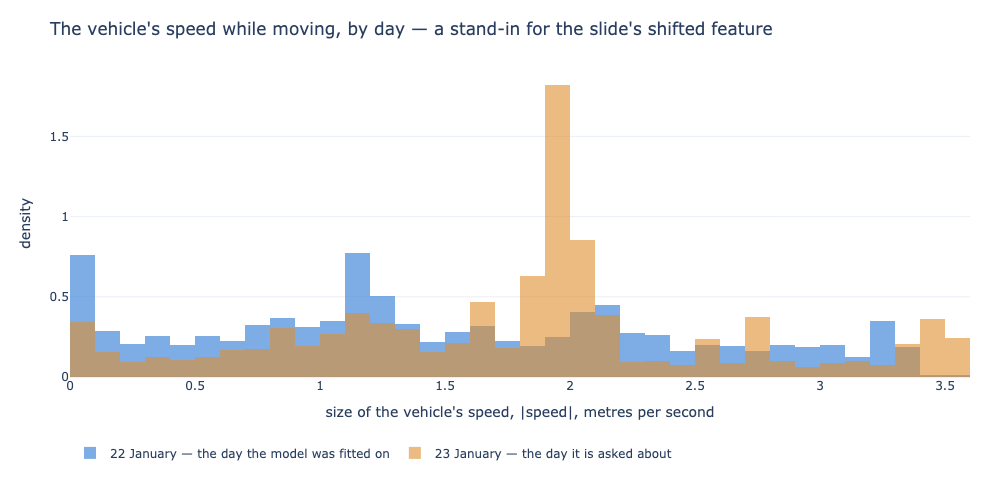

2020-01-22: vehicle moving 31.2 % of 27,324 readings, mean |speed| while moving 1.51 m/s (median 1.35), negative 48.7 % of moving readings, signed mean 0.042; the model's speed feature (generated phones) mean 1.29 m/s
2020-01-23: vehicle moving 30.1 % of 20,966 readings, mean |speed| while moving 1.79 m/s (median 1.92), negative 4.5 % of moving readings, signed mean 0.517; the model's speed feature (generated phones) mean 1.29 m/s


In [149]:
bus = pd.read_csv("data/bus_slice.csv.gz", low_memory=False)
day = pd.to_datetime(bus["utc_time"], utc=True).dt.date.astype(str)
moving = bus["speed"].ne(0)
fig = go.Figure()
for which, colour, name in (("2020-01-22", "#2A78D6", "22 January — the day the model was fitted on"),
                            ("2020-01-23", "#DF8E2E", "23 January — the day it is asked about")):
    here = (day == which) & moving
    fig.add_histogram(x=bus.loc[here, "speed"].abs(), histnorm="probability density", xbins=dict(start=0, end=3.6, size=0.1),
                      marker_color=colour, opacity=0.6, name=name)
fig.update_layout(barmode="overlay",
                  title="The vehicle's speed while moving, by day — a stand-in for the slide's shifted feature",
                  xaxis_title="size of the vehicle's speed, |speed|, metres per second", yaxis_title="density",
                  legend=dict(orientation="h", y=-0.2))
show(fig, "speed_two_days", height=480)
for which in ("2020-01-22", "2020-01-23"):
    speeds = bus.loc[day == which, "speed"]
    in_motion = speeds[speeds.ne(0)]
    phones = pd.read_parquet(f"data/phones_{which}.parquet")["speed"]
    print(f"{which}: vehicle moving {100 * speeds.ne(0).mean():.1f} % of {len(speeds):,} readings, "
          f"mean |speed| while moving {in_motion.abs().mean():.2f} m/s (median {in_motion.abs().median():.2f}), "
          f"negative {100 * (in_motion < 0).mean():.1f} % of moving readings, signed mean {speeds.mean():.3f}; "
          f"the model's speed feature (generated phones) mean {phones.mean():.2f} m/s")

**Goal.** Answer the slide's challenge on a sigmoid: does the average prediction follow the prediction at the average input?

**Why.** The model is nonlinear. By Jensen's inequality the average of a convex function lies above the function of the average, and below it for a concave one (Jensen, 1906); in risk analysis the mistake is called the flaw of averages (Savage, 2009).

**What the code does.** Draws the slide's curve — the logistic function, which its chart samples at the integers from −8 to 8 — and computes, by numerical integration, the average output for normal inputs of spread 0.5 and 2, centred left of the midpoint, at it, and right of it; then writes Jensen's inequality in sympy for a curve bending up (second derivative at least nought) and one bending down.

**So what.** Question 1: no — the average output is not f(mean x). Question 2: yes — with the mean fixed, a wider spread moves the average output. Question 3: left of the midpoint, where the curve is convex, it pushes the average up; right of it, where it is concave, down; at the midpoint the two cancel.

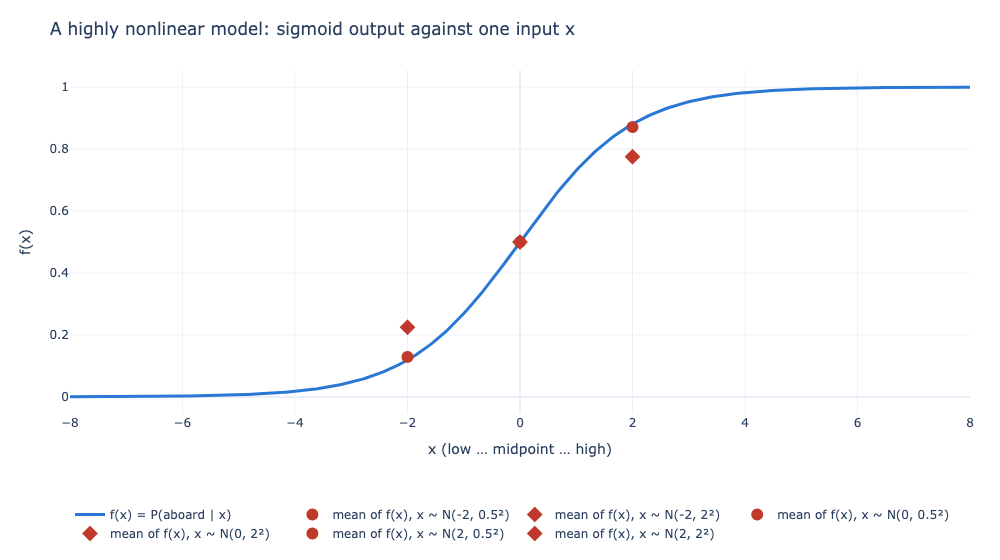

,mean of x,spread of x,f(mean x),mean of f(x),Jensen gap
0,-2.0,0.5,0.1192,0.1290,0.0098
1,-2.0,2.0,0.1192,0.2248,0.1056
2,0.0,0.5,0.5000,0.5000,0.0000
3,0.0,2.0,0.5000,0.5000,0.0000
4,2.0,0.5,0.8808,0.8710,-0.0098
5,2.0,2.0,0.8808,0.7752,-0.1056


<IPython.core.display.Math object>

In [150]:
from scipy import integrate
xs = np.linspace(-8, 8, 401)
logistic = lambda x: 1 / (1 + np.exp(-x))
chart = [0, 0.001, 0.002, 0.007, 0.018, 0.047, 0.119, 0.269, 0.5, 0.731, 0.881, 0.953, 0.982, 0.993, 0.998, 0.999, 1]
assert np.allclose(logistic(np.arange(-8, 9)), chart, atol=6e-4), "the slide's curve is the logistic function"
fig = go.Figure()
fig.add_scatter(x=xs, y=logistic(xs), mode="lines", line=dict(color="#2A78D6", width=3), name="f(x) = P(aboard | x)")
rows = []
for centre in (-2.0, 0.0, 2.0):
    for spread, symbol in ((0.5, "circle"), (2.0, "diamond")):
        mean_output = integrate.quad(lambda x: logistic(x) * stats.norm.pdf(x, centre, spread), -40, 40)[0]
        rows.append({"mean of x": centre, "spread of x": spread, "f(mean x)": round(float(logistic(centre)), 4),
                     "mean of f(x)": round(mean_output, 4), "Jensen gap": round(mean_output - float(logistic(centre)), 4)})
        fig.add_scatter(x=[centre], y=[mean_output], mode="markers", marker=dict(size=12, symbol=symbol, color="#C0392B"),
                        name=f"mean of f(x), x ~ N({centre:g}, {spread:g}²)")
fig.update_layout(title="A highly nonlinear model: sigmoid output against one input x",
                  xaxis_title="x (low … midpoint … high)", yaxis_title="f(x)", legend=dict(orientation="h", y=-0.25))
show(fig, "sigmoid", height=560)
display(pd.DataFrame(rows))
f_, x_ = sp.Function("f"), sp.Symbol("x")
E_ = sp.Function(r"\mathbb{E}")
bend = sp.Derivative(f_(x_), (x_, 2))
formula(sp.Implies(sp.Ge(bend, 0), sp.Ge(E_(f_(x_)), f_(E_(x_)))),       # convex
        sp.Implies(sp.Le(bend, 0), sp.Le(E_(f_(x_)), f_(E_(x_)))))       # concave

**Goal.** Write the joint distribution two ways and name the three shifts.

**Why.** Shift means one factor of P(x, y) changed between training and serving: P(x) with P(y | x) fixed is covariate shift (Storkey, 2009, § 1.4); P(y) with P(x | y) fixed is prior probability, or label, shift (Storkey, 2009, § 1.5); P(y | x) itself is concept shift. The three-way naming is the deck's, after Moreno-Torres et al. (2012); Storkey's chapter uses neither "concept shift" nor "label shift", and lists more kinds of shift than three.

**What the code does.** Writes the product rule in sympy, both factorisations.

**So what.** Covariate shift is drawn above on the real speeds. The other two cannot be drawn on the lab data, and the next two figures say why.

In [151]:
P_ = sp.Function("P")
x_s, y_s = sp.symbols("x y")
given = lambda a, b: sp.Symbol(rf"{a} \mid {b}")
formula(sp.Eq(P_(x_s, y_s), P_(x_s) * P_(given("y", "x"))), sp.Eq(P_(x_s, y_s), P_(y_s) * P_(given("x", "y"))))

<IPython.core.display.Math object>

**Goal.** Draw concept shift as the slide draws it.

**Why.** Concept shift is P(y | x) changing: after a sensor is recalibrated, the same speed means a different chance of aboard. The generated phone traces hold the rule fixed on both days by construction, so there is none to show.

**What the code does.** Redraws the slide's two curves from the chart's own values.

**So what.** Illustrative: the serving curve is the training curve moved right by about three and a half units.

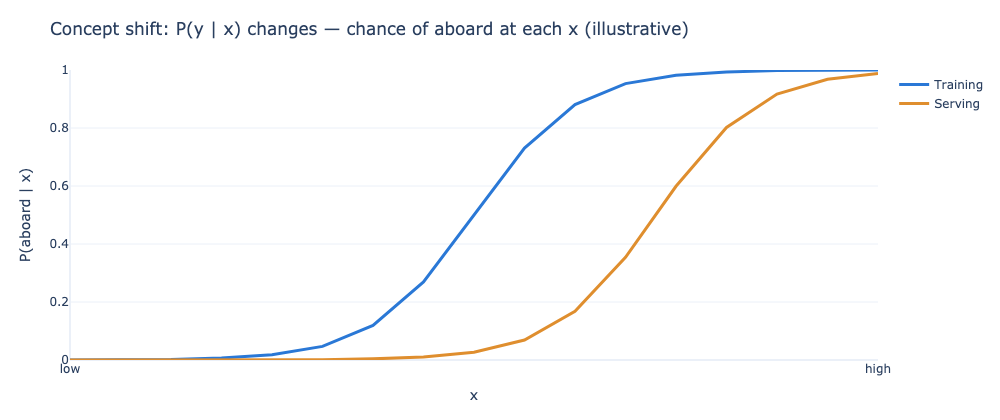

In [152]:
training = [0, 0.001, 0.002, 0.007, 0.018, 0.047, 0.119, 0.269, 0.5, 0.731, 0.881, 0.953, 0.982, 0.993, 0.998, 0.999, 1]
serving = [0, 0, 0, 0, 0.001, 0.001, 0.004, 0.01, 0.027, 0.069, 0.168, 0.354, 0.599, 0.802, 0.917, 0.968, 0.988]
fig = go.Figure()
fig.add_scatter(y=training, mode="lines", line=dict(color="#2A78D6", width=3), name="Training")
fig.add_scatter(y=serving, mode="lines", line=dict(color="#DF8E2E", width=3), name="Serving")
fig.update_layout(title="Concept shift: P(y | x) changes — chance of aboard at each x (illustrative)",
                  xaxis=dict(tickvals=[0, 16], ticktext=["low", "high"], title="x"), yaxis_title="P(aboard | x)",
                  yaxis_range=[0, 1])
show(fig, "concept_shift", height=420)

**Goal.** Draw label shift as the slide draws it, beside the lab data's own shares.

**Why.** Label shift is P(y) changing: a new timetable puts more people aboard, and each class looks the same as before.

**What the code does.** Redraws the slide's bars (70/30 then 35/65, illustrative), and measures the aboard share of the generated traces on the two days.

**So what.** The generated traces are aboard 56.3 per cent of the time on both days — `make_phones.py` uses one measured share for every day — so the lab data carries no label shift.

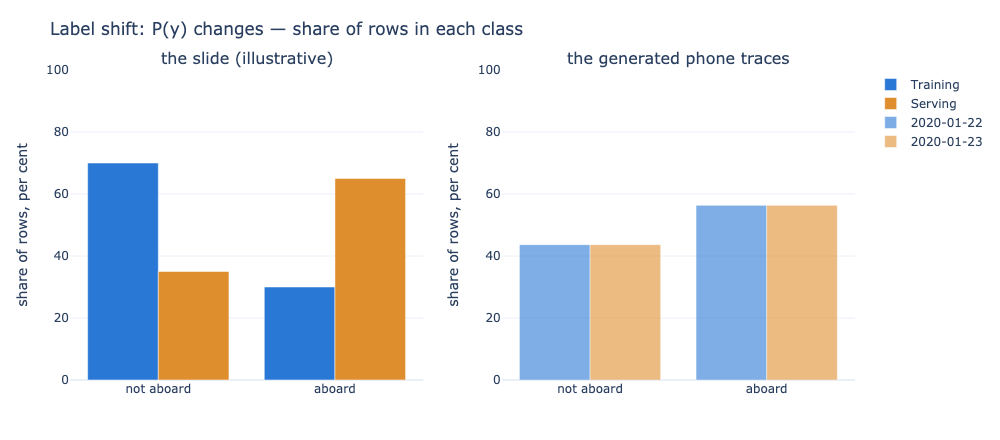

2020-01-22: aboard 56.3 per cent of rows
2020-01-23: aboard 56.3 per cent of rows


In [153]:
shares = {which: 100 * pd.read_parquet(f"data/phones_{which}.parquet")["label2"].eq("IN").mean()
          for which in ("2020-01-22", "2020-01-23")}
fig = make_subplots(rows=1, cols=2, subplot_titles=("the slide (illustrative)", "the generated phone traces"))
for name, values, colour in (("Training", [70, 30], "#2A78D6"), ("Serving", [35, 65], "#DF8E2E")):
    fig.add_bar(x=["not aboard", "aboard"], y=values, name=name, marker_color=colour, row=1, col=1)
for (which, share), colour in zip(shares.items(), ("#2A78D6", "#DF8E2E")):
    fig.add_bar(x=["not aboard", "aboard"], y=[100 - share, share], name=which, marker_color=colour,
                opacity=0.6, row=1, col=2)
fig.update_yaxes(title_text="share of rows, per cent", range=[0, 100])
fig.update_layout(title="Label shift: P(y) changes — share of rows in each class", barmode="group")
show(fig, "label_shift", height=440)
for which, share in shares.items():
    print(f"{which}: aboard {share:.1f} per cent of rows")

### Is the model fast enough to serve?

*Slides: "Second half of block four — is the model fast enough to serve?", "Definition — percentile latency, nearest rank" and "The percentile is computed in three steps, and the answer is a real request".*

**Goal.** Write the latency gate and the nearest-rank percentile, and work the slide's example.

**Why.** A model can pass the accuracy gate and still be too slow. Report the 95th percentile, not the mean: the tail is what the slow user sees (Dean & Barroso, 2013). Nearest rank reports a duration that actually occurred (Hyndman & Fan, 1996, Definition 1).

**What the code does.** Writes both in sympy — the percentile as the r-th smallest duration, the gate as an implication — then takes the slide's hundred requests, 94 at 10 ms and 6 at 1 s, and computes each row of its table.

**So what.** Mean 69 ms describes nobody; the 95th percentile says 1 s. The throughput the slide prints, about 1,450 requests a second, is a hundred divided by the mean in seconds; served one after another, a hundred requests that take 6.94 s in total go through at 14.4 a second.

In [154]:
p_q, n_q = sp.symbols("p n", positive=True)
rank = sp.ceiling(p_q * n_q / 100)
r_q, i_q = sp.Symbol("r", integer=True, positive=True), sp.Symbol("i", integer=True, positive=True)
ordered_at = lambda j: sp.Symbol(rf"x_{{({sp.latex(j)})}}")      # x_(j), the j-th smallest duration
formula(sp.Eq(sp.Function("Q")(p_q), ordered_at(r_q)), sp.Eq(r_q, rank),
        sp.Le(ordered_at(i_q), ordered_at(i_q + 1)))
formula(sp.Implies(sp.Symbol(r"\mathrm{promote}"), sp.Le(sp.Symbol("p_{95}"), sp.Symbol(r"\mathrm{time\ budget}"))))
hundred = [10.0] * 94 + [1000.0] * 6
ordered = sorted(hundred)
at = lambda q: ordered[int(rank.subs({p_q: q, n_q: len(ordered)})) - 1]
agrees("mean, ms", np.mean(hundred), 69, 0)
agrees("median (p50), ms", at(50), 10, 0)
agrees("p95, ms", at(95), 1000, 0)
agrees("p99, ms", at(99), 1000, 0)
agrees("maximum, ms", max(hundred), 1000, 0)
beside("throughput of the same 100 requests", f"{len(hundred) / (sum(hundred) / 1000):.1f} requests per second, served one after another",
       "~1,450 req/s", f"1,450 = 100 / {np.mean(hundred) / 1000:.3f} s divides the count by the mean in seconds, not by the total")
agrees("work per request, candidate against baseline (decision nodes)", WORK_MULTIPLE, 17.7, 1)

<IPython.core.display.Math object>

<IPython.core.display.Math object>

  mean, ms                                                           deck 69         computed 69
  median (p50), ms                                                   deck 10         computed 10
  p95, ms                                                            deck 1000       computed 1000
  p99, ms                                                            deck 1000       computed 1000
  maximum, ms                                                        deck 1000       computed 1000
  throughput of the same 100 requests: computed here 14.4 requests per second, served one after another, stated ~1,450 req/s — 1,450 = 100 / 0.069 s divides the count by the mean in seconds, not by the total
  work per request, candidate against baseline (decision nodes)      deck 17.7       computed 17.7


**Goal.** Define the percentile as the Lab 4 solution writes it.

**Why.** Software packages disagree by default, so a report must say which definition it used.

**What the code does.** Copies `percentile_latency` from `solutions/lab_04.py`, verbatim.

**So what.** The next cell checks which definition it is.

In [155]:
# Source: Module 3/exercises/solutions/lab_04.py — percentile_latency, verbatim
# References: (Hyndman & Fan, 1996; Dean & Barroso, 2013)

import math
import pathlib
import sys
import time
import numpy as np
import pandas as pd
from mlflow.exceptions import MlflowException


def percentile_latency(durations, percentile: float = 95.0) -> float:
    """Nearest rank, so the number reported is a duration that really happened.

    Definition graded by the check:
        Q(p) = x_(⌈p · n / 100⌉), where x_(1) ≤ … ≤ x_(n) are the sorted durations
        (Hyndman & Fan, 1996, definition 1; Dean & Barroso, 2013). Slide:
        "Definition — percentile latency, nearest rank".

    Report the mean and you describe nobody. If ninety-four requests take ten
    milliseconds and six take a second, the mean is sixty-nine milliseconds — a
    true number that no user has ever experienced. The ninety-fifth percentile
    says: one request in twenty is at least this slow. That is the sentence an
    operations team can act on, and it is why Dean and Barroso talk about the
    tail and not the average.

    Nearest rank rather than interpolation because an interpolated percentile is
    a number that never occurred. For latency, where the question is "how bad
    does it get", a real observation is the more honest answer.
    """
    ordered = sorted(float(d) for d in durations)
    if not ordered:
        return float("nan")
    rank = max(1, math.ceil(percentile / 100 * len(ordered)))
    return ordered[min(rank, len(ordered)) - 1]

**Goal.** Check that the lab's percentile is Hyndman and Fan's Definition 1.

**Why.** Definition 1 is the inverse of the empirical distribution function, which NumPy implements as its `inverted_cdf` method (Hyndman & Fan, 1996, Definition 1).

**What the code does.** Compares `percentile_latency` with NumPy's `inverted_cdf` at every whole percentile, on the slide's hundred requests and on 200 seeded log-normal durations.

**So what.** The same function. Every percentile it reports is a duration that happened.

In [156]:
durations = np.random.default_rng(SEED).lognormal(1.0, 0.8, 200)
for sample in (hundred, durations):
    worst = max(abs(percentile_latency(sample, q) - np.percentile(sample, q, method="inverted_cdf"))
                for q in range(1, 101))
    print(f"{len(sample)} durations: largest difference from inverted_cdf over p = 1..100: {worst}")

100 durations: largest difference from inverted_cdf over p = 1..100: 0.0
200 durations: largest difference from inverted_cdf over p = 1..100: 0.0


## Laboratory 4 — Cause the skew, then cure it

*Slide: "Lab 4 — Cause the skew, then cure it".* Part (a): swap two fields in every
request and measure what changed; the check measures the same share its own way, and
the two have to agree; then cure it. Part (b): ask the champion by name, and watch a
renamed column be refused. Twenty-five minutes; causing the skew is most of it.

**The exercise, exactly as `Module 3/exercises/labs/04_skew_and_speed.py` states it.**

> Lab 4 — Skew, and honest speed.
>
> Why this lab exists: the most unsettling failure in the course is the one where
> nothing goes wrong — the same model, prepared differently at serving time,
> returns a well-formed answer to every request and a worse one than yesterday.
> You cause it, cure it twice (once by discipline, once by the platform's
> signature), report speed by a percentile that describes somebody's experience,
> and prove that the batch path and the request path are one implementation.
> Where it sits: Block 4 — "The failure where nothing goes wrong", "The cure is
> one preparation, used twice", "Honest speed", and the definition slides
> "Definition — training–serving skew", "Definition — model signature",
> "Definition — percentile latency, nearest rank" and "Definition — one
> preparation, two paths".
> What the check grades: cause_and_cure_skew() exchanges two fields in every
> request, reports the share of decisions that changed and the two accuracies to
> the check's own arithmetic, reports zero failed requests, and reports that the
> cure changes nothing back; prepare() returns one row inside a list built from the
> stored constants in the stored order, unchanged when the request's keys arrive
> reversed and filled from the stored median when a field is missing;
> percentile_latency() gives the nearest-rank duration at every percentile asked;
> batch_predict() agrees with the request-by-request path to within 1e-9 on four
> hundred rows; and ask_registered() returns the right probability for a request
> whose keys are reversed and None for a request with a renamed column, while the
> raw pickle silently accepts the swapped row and answers wrongly.
> Needs: math, numpy, pandas, mlflow.exceptions.MlflowException.
>
> Twenty-five minutes.
>
> The failure in this lab is the most unsettling in the course, because nothing
> goes wrong. Every request succeeds. Every response is well-formed. The service
> returns a probability, the log shows two hundred healthy requests a second, and
> the answers are quietly worse than they were yesterday.
>
> The cause: the model was trained on columns in one order and is being asked in
> another. A model does not know its columns by name. It knows position one,
> position two, position three. Hand it signal strength where it expects speed
> and it will confidently interpret one as the other.
>
> That is **training-serving skew**: the input at serving time is prepared
> differently from the input at training time. Column order is the crudest form;
> the same failure hides in a different fill value, a scaler refitted on live
> data, or a unit converted in one path and not the other.
>
> Part (a) — cause it, then cure it.
>
> You cause it first, because a failure you have produced is a failure you
> recognise. The deck's sharpest number -- two columns exchanged, every request
> answered with status 200, twenty-seven per cent of decisions different -- is a
> number this function produces. Do not take it from the slide; measure it.
>
> What you write: cause_and_cure_skew(frame, artefact, exchange, threshold).
>
>     Send every row of `frame` to the service twice.
>
>     1. Build the request as the caller would: a dictionary of the four declared
>        fields, a value or None for each.
>     2. **Cause it.** Rebuild the request with the two fields in `exchange`
>        swapped over each other in the dictionary's own order -- a caller whose
>        client library serialises its keys differently, which is all it takes.
>        Then build the model's input the way a great deal of serving code does:
>        loop over the REQUEST's keys, scale each field by its own stored mean and
>        standard deviation, and put it at the position it arrived in. Every value
>        is right. Two of them are in the wrong seat.
>     3. Ask the model. Note what does not happen: no exception, no complaint, no
>        slow request, nothing in a log. Count the failures anyway and report
>        them, because the count being nought is the lesson.
>     4. Measure. What share of decisions changed at `threshold`, and what the
>        accuracy was before and after, against `frame[TARGET] == ABOARD`.
>     5. **Cure it.** Send the very same reordered requests through prepare(),
>        which loops over the stored order and never over the request's keys, and
>        measure the share of decisions that changed now. It is nought, exactly.
>
>     Ask the model once per path rather than once per row: collect the rows and
>     make three calls in all. A model asked four hundred times in a loop is a
>     demonstration of patience.
>
> Then: prepare(request, transform).
>
>     Build the model's input from a request dictionary, using the transform's
>     stored feature order and its stored constants. Nothing about the incoming
>     dictionary's key order may reach the model. Fill a missing field with the
>     stored median rather than refusing or guessing.
>
>     Return that row *inside a list*: [[value, value, value, value]]. A fitted
>     model is asked about a batch of rows, so one request is a batch of one.
>
> Then: percentile_latency(durations, percentile).
>
>     Report the 95th percentile, not the mean. A mean hides the tail, and the
>     tail is what your users experience: if one request in twenty takes a second,
>     a mean of forty milliseconds is a true number that describes nobody's
>     experience. Use nearest rank on the sorted durations -- no interpolation,
>     so the answer is always a duration that actually happened.
>
> Then: batch_predict(frame, artefact) — the same answers, computed all at once.
>
>     The batch path exists because per-request work is wasteful when the answers
>     are wanted for a whole table. The check confirms your batch agrees with the
>     request-by-request path exactly. If the two disagree, the batch path is a
>     second implementation of the model, and now you have two things to keep
>     correct.
>
> Part (b) — the cure by the platform.
>
> Lab 1 registered the same model with a **signature**: the column names, their
> types and their order, inferred at logging and enforced at prediction. Load
> the champion from the store and ask it with a *named* request instead of a
> positional row.
>
> What you write: ask_registered(request, registered).
>
>     `registered` is the pyfunc model behind models:/aboard@champion
>     (lab_support.load_registered()). Put the request into a one-row pandas
>     DataFrame -- its keys become column names, in whatever order they came --
>     and call registered.predict(frame). The platform matches columns by name,
>     restores the stored order, and hands the artefact its own preparation. Return
>     the probability of aboard: column 1 of the result, exactly as predict_proba.
>     If the platform refuses the request (a renamed or missing column raises
>     MlflowException: Failed to enforce schema), return None -- the service turns
>     that into a 422 naming the schema.
>
>     Three outcomes to see for yourself, in the check and in the solution: the
>     raw pickle silently accepts a row with two positions swapped and answers
>     wrongly; the registered model, given the same request with its keys
>     reversed, answers correctly; given a renamed column, it refuses.
>
> The check passes when cause_and_cure_skew() reports the share of changed
> decisions and the two accuracies that the check measures for itself on the same
> rows and the same exchange, reports no failed requests, reports exactly nought
> changed after the cure, and gives a different answer for a different exchange;
> when prepare() returns one row inside a list whose values come from the stored
> constants, unchanged when the request's keys arrive reversed and
> filled from the stored median when a field is missing; when percentile_latency()
> gives the nearest-rank duration at every percentile it is asked for, not only at
> 95; when batch_predict() agrees with the request-by-request path to within
> 1e-9 on all four hundred rows; and when ask_registered() answers the reversed
> request to within 1e-9 of the correctly prepared pickle path and returns None
> for the renamed column, while the pickle accepts the swapped row without a word.

```python
def cause_and_cure_skew(frame, artefact: dict, exchange=SKEW_EXCHANGE,
                        threshold: float = PRICED_THRESHOLD) -> dict:
    """Cause training-serving skew on purpose, measure it, then cure it.
    
    Returns a dictionary with, at least:
    
        requests                              how many were sent
        failures                              how many did not return an answer
        decisions_changed_percent             at `threshold`, cause against truth-blind
        accuracy_before                       before the exchange, at `threshold`
        accuracy_after                        after it
        decisions_changed_percent_after_cure  after prepare() is used instead
    
    Definition graded by the check:
        changed(π) = |{i : 1[p_i ≥ t] ≠ 1[p_i^π ≥ t]}| / n, where p_i^π is the same request with two declared fields exchanged and the row assembled in the order the keys arrived; failures(π) = 0; and re-assembling in the stored order gives changed = 0
        (Breck et al., 2019; Huyen, 2022, ch. 7). π is the exchange, t the
        threshold. Choices: the decision rule is p ≥ t, as everywhere in this
        module; the share is of decisions and not of probabilities, because a
        probability that moves without crossing the cutoff costs nothing; each
        field keeps its OWN stored mean and standard deviation and only its
        position is wrong, which is the ordinary form of this bug. Slide:
        "Definition — causing the skew, and measuring it".
    Needs: numpy, pandas"""
```

```python
def prepare(request: dict, transform: dict):
    """One request, as the model expects it: stored order, stored constants.
    
    Return one row inside a list -- [[value, value, value, value]] -- not four
    bare numbers. The model is asked about a batch of rows and a single request
    is a batch of one; hand it a flat list and scikit-learn refuses with
    "Expected 2D array, got 1D array instead".
    
    Definition graded by the check:
        skew ⇔ prepare_serve(x) ≠ prepare_train(x); cure: input_j = ((x[f_j] if present else median_{f_j}) − mean_{f_j}) / std_{f_j} for f_j in the stored order, j = 1..k
        (Breck et al., 2019). Choices: the order is transform["features"], the
        fill is the stored median, the scale is the stored mean and population
        standard deviation (ddof = 0), all fitted on the training rows by
        service/models.py. Slide: "Definition — training–serving skew".
    Needs: dict.get, float — no library."""
```

```python
def percentile_latency(durations, percentile: float = 95.0) -> float:
    """Nearest-rank percentile of `durations`, so the answer really happened.
    
    Definition graded by the check:
        Q(p) = x_(⌈p · n / 100⌉), where x_(1) ≤ … ≤ x_(n) are the sorted durations
        (Hyndman & Fan, 1996, definition 1; Dean & Barroso, 2013). Choices:
        nearest rank, never interpolation, so the number reported is a duration
        that occurred; the 95th percentile is the reporting convention. Slide:
        "Definition — percentile latency, nearest rank".
    Needs: sorted, math"""
```

```python
def batch_predict(frame, artefact: dict):
    """Probabilities for a whole table, agreeing exactly with the per-request path.
    
    Definition graded by the check:
        batch(frame)_i = model(prepare(row_i)) for every row i, |difference| < 10⁻⁹
        (Breck et al., 2019; Huyen, 2022). Choices: one implementation of the
        preparation — the stored order, the stored median, the stored scale —
        applied to a whole frame; the model asked once. Slide: "Definition — one
        preparation, two paths".
    Needs: pandas, model.predict_proba"""
```

```python
def ask_registered(request: dict, registered):
    """The registered model, asked by name: the probability of aboard, or None if refused.
    
    Definition graded by the check:
        S = (name_i, type_i)_{i=1..k}, recorded with the model; accept(x) ⇔ ∀i: name_i ∈ columns(x) ∧ type(x[name_i]) = type_i; input = (x[name_1], …, x[name_k])
        (Zaharia et al., 2018). Choices: the request travels as a one-row pandas
        DataFrame, keys in the caller's order; the answer is column 1 of
        registered.predict(frame), the probability of aboard; a refusal
        (MlflowException) becomes None. Slide: "Definition — model signature".
    Needs: pandas, registered.predict, mlflow.exceptions.MlflowException"""
```

**Goal.** Define the platform's cure as the Lab 4 solution writes it.

**Why.** The registered model matches columns by name, restores the stored order and hands the artefact its own preparation; a renamed or missing column is refused rather than answered wrongly. (The deck and the docstring credit the signature to Zaharia et al. (2018); that paper predates MLflow's signatures — see the closing notes.)

**What the code does.** Copies `ask_registered` from `solutions/lab_04.py`, verbatim.

**So what.** The last of the five functions; the others were defined above.

In [157]:
# Source: Module 3/exercises/solutions/lab_04.py — ask_registered, verbatim
# References: (Zaharia et al., 2018, the deck's attribution — see the closing notes)

import math
import pathlib
import sys
import time
import numpy as np
import pandas as pd
from mlflow.exceptions import MlflowException


def ask_registered(request: dict, registered):
    """The platform's cure: columns matched by name, order restored, strangers refused.

    Definition graded by the check:
        S = (name_i, type_i)_{i=1..k}, recorded with the model; accept(x) ⇔ ∀i: name_i ∈ columns(x) ∧ type(x[name_i]) = type_i; input = (x[name_1], …, x[name_k])
        (Zaharia et al., 2018). Slide: "Definition — model signature".

    The request goes in as a one-row frame, so its keys are column names. The
    signature recorded in Lab 1 says which names, which types, in which order;
    the platform reorders the columns to match and hands the artefact its own
    preparation, so a caller who reversed the keys gets the right answer. A
    caller who renamed a column gets a refusal, not a wrong number — the
    opposite of what the raw pickle does with a swapped row.
    """
    frame = pd.DataFrame([request])
    try:
        answer = registered.predict(frame)
    except MlflowException:
        return None                                   # refused: the service says 422
    return float(np.asarray(answer)[0][1])            # column 1: aboard, as predict_proba

### The solution, step by step

First the lab file's own demonstration; then the solution's own, `python3 solutions/lab_04.py`, one paragraph of its `__main__` block per cell.

**Goal.** Run the stub's own `__main__` block against the solved functions.

**Why.** It is what a student sees when the file is complete.

**What the code does.** The lines below are the stub's demonstration, verbatim.

**So what.** A mean probability for the last 500 rows, and the 95th percentile of 1 to 100: 95.

In [158]:
# Source: Module 3/exercises/labs/04_skew_and_speed.py — demonstration step 0, verbatim

artefact = load_artefact("v1")
table = load_table().tail(500)
print("batch mean probability:", float(batch_predict(table, artefact).mean()).__round__(4))
print("95th percentile of [1,2,3,...,100]:", percentile_latency(list(range(1, 101)), 95))

batch mean probability: 0.4074
95th percentile of [1,2,3,...,100]: 95.0


**Goal.** Import what the demonstration needs beyond the functions above.

**Why.** The block draws with plotly and narrates with `_narrate`.

**What the code does.** Imports plotly and the narration helpers the set-up registered.

**So what.** Nothing runs yet.

In [159]:
# Source: Module 3/exercises/solutions/lab_04.py — demonstration, paragraph 1 of 10, verbatim

import plotly.graph_objects as go
from _narrate import narrator, show_table, save_figure

**Goal.** Start the narration.

**Why.** Every line the solution prints goes through `say`, stamped with the seconds since the notebook began.

**What the code does.** Creates the narrator for Lab 4 and prints the demonstration's one-line summary.

**So what.** The timings differ from run to run; nothing else does.

In [160]:
# Source: Module 3/exercises/solutions/lab_04.py — demonstration, paragraph 2 of 10, verbatim

say = narrator(LAB)
say.info("Lab 4 — cause the skew, cure it twice, report speed honestly, and prove the "
         "batch path is the request path")

 18.78s  lab 4  Lab 4 — cause the skew, cure it twice, report speed honestly, and prove the batch path is the request path


**Goal.** Load the champion and cut the test period.

**Why.** The skew and the speed are measured on the rows the model never trained on.

**What the code does.** Loads v1's artefact and its stored transform, loads the table and keeps the later 30 per cent of rows.

**So what.** The same 3,241 rows as the rest of the notebook.

In [161]:
# Source: Module 3/exercises/solutions/lab_04.py — demonstration, paragraph 3 of 10, verbatim

artefact = load_artefact("v1")
transform = artefact["transform"]
table = load_table()
test = table.iloc[int(len(table) * 0.7):].reset_index(drop=True)
say.info("loaded the champion (v1) and the table: %d rows, generated (seed 20200122); "
         "the later 30 per cent, %d rows, is the test period", len(table), len(test))

 18.80s  lab 4  loaded the champion (v1) and the table: 10800 rows, generated (seed 20200122); the later 30 per cent, 3241 rows, is the test period


**Goal.** Show the skew on one request.

**Why.** One visible wrong answer teaches more than a percentage; a change in the third decimal would teach that the failure is small.

**What the code does.** Finds the first complete test row on which exchanging the first and last prepared positions, speed and rssiC, moves the probability by more than 0.1; prepares it with its keys in the stored order and reversed; and asks the raw pickle about the right row and the exchanged one.

**So what.** Reversed keys change nothing, because `prepare()` loops over the stored order; the exchanged row is answered without a word, with a different probability.

In [162]:
# Source: Module 3/exercises/solutions/lab_04.py — demonstration, paragraph 4 of 10, verbatim

# The skew, on one request: reversed keys, same row -- and what a positional
# swap does to the same model.
complete = test.dropna(subset=FEATURES)
# The first complete row where exchanging two positions moves the answer by
# more than a tenth. On many rows the forest is unmoved, and a demonstration
# of a change in the third decimal teaches that the failure is small.
for index in range(len(complete)):
    natural = {f: float(complete.iloc[index][f]) for f in FEATURES}
    straight = prepare(natural, transform)
    exchanged = [list(straight[0])]
    exchanged[0][0], exchanged[0][-1] = exchanged[0][-1], exchanged[0][0]
    if abs(float(artefact["model"].predict_proba(exchanged)[0][1])
           - float(artefact["model"].predict_proba(straight)[0][1])) > 0.1:
        break
reversed_keys = {f: natural[f] for f in reversed(FEATURES)}
say.info("one request with all four fields, %s", natural)
say.info("prepare() with keys in the stored order    -> %s", [round(v, 4) for v in straight[0]])
say.info("prepare() with keys reversed               -> %s (identical: the loop is over "
         "the stored order, never the request's keys)",
         [round(v, 4) for v in prepare(reversed_keys, transform)[0]])
right = float(artefact["model"].predict_proba(straight)[0][1])
wrong = float(artefact["model"].predict_proba(exchanged)[0][1])
say.info("the raw pickle, row prepared correctly: probability of aboard %.4f", right)
say.info("the raw pickle, speed and rssiC exchanged by position: %.4f — accepted without "
         "a word, no exception, status would be 200; at the priced threshold 0.20 that "
         "is the decision %r instead of %r", wrong,
         "aboard" if wrong >= 0.2 else "not aboard",
         "aboard" if right >= 0.2 else "not aboard")

 18.85s  lab 4  one request with all four fields, {'speed': 0.359, 'rssi1': -78.8, 'rssi2': -72.0, 'rssiC': -77.9}


 18.85s  lab 4  prepare() with keys in the stored order    -> [-0.9933, -0.7658, 0.4519, -0.258]


 18.85s  lab 4  prepare() with keys reversed               -> [-0.9933, -0.7658, 0.4519, -0.258] (identical: the loop is over the stored order, never the request's keys)


 18.87s  lab 4  the raw pickle, row prepared correctly: probability of aboard 0.1400


 18.87s  lab 4  the raw pickle, speed and rssiC exchanged by position: 0.3929 — accepted without a word, no exception, status would be 200; at the priced threshold 0.20 that is the decision 'aboard' instead of 'not aboard'


**Goal.** Cause the skew over the whole test period, then cure it.

**Why.** The slide's number is produced here, in the requests rather than in a matrix.

**What the code does.** Runs `cause_and_cure_skew` with the lab's exchange, speed and rssi1, and again with rssi2 and rssiC, and prints the share of decisions changed, the accuracy before and after, the failed requests and the share changed after the cure.

**So what.** 27.1 and 6.9 per cent of decisions changed, no failed request, and nought after the cure.

In [163]:
# Source: Module 3/exercises/solutions/lab_04.py — demonstration, paragraph 5 of 10, verbatim

# The whole test period, caused in the request rather than in a matrix: the
# number on the deck, produced here.
report = cause_and_cure_skew(test, artefact, SKEW_EXCHANGE, PRICED_THRESHOLD)
say.info("caused: %s and %s exchanged in every one of %d requests, the row assembled in "
         "the order the keys arrived", report["exchange"][0], report["exchange"][1],
         report["requests"])
say.info("measured: %.1f per cent of decisions changed at the priced threshold %.2f; "
         "accuracy %.4f -> %.4f; requests that failed: %d",
         report["decisions_changed_percent"], report["threshold"],
         report["accuracy_before"], report["accuracy_after"], report["failures"])
say.info("cured: the same reordered requests through prepare(), which loops over the "
         "stored order — decisions changed now: %.1f per cent",
         report["decisions_changed_percent_after_cure"])
other = cause_and_cure_skew(test, artefact, ("rssi2", "rssiC"), PRICED_THRESHOLD)
say.info("a different pair, rssi2 and rssiC: %.1f per cent — the damage is a property of "
         "which two columns, not a constant",
         other["decisions_changed_percent"])

 19.15s  lab 4  caused: speed and rssi1 exchanged in every one of 3241 requests, the row assembled in the order the keys arrived


 19.15s  lab 4  measured: 27.1 per cent of decisions changed at the priced threshold 0.20; accuracy 0.5261 -> 0.4428; requests that failed: 0


 19.15s  lab 4  cured: the same reordered requests through prepare(), which loops over the stored order — decisions changed now: 0.0 per cent


 19.66s  lab 4  a different pair, rssi2 and rssiC: 6.9 per cent — the damage is a property of which two columns, not a constant


**Goal.** Draw both batches of probabilities.

**Why.** The only visible trace of the skew is the spread of the answers.

**What the code does.** Prepares the test rows, swaps the first two columns, asks the model both ways and overlays the two histograms.

**So what.** Every request succeeded both times; only the shape of the probabilities moved.

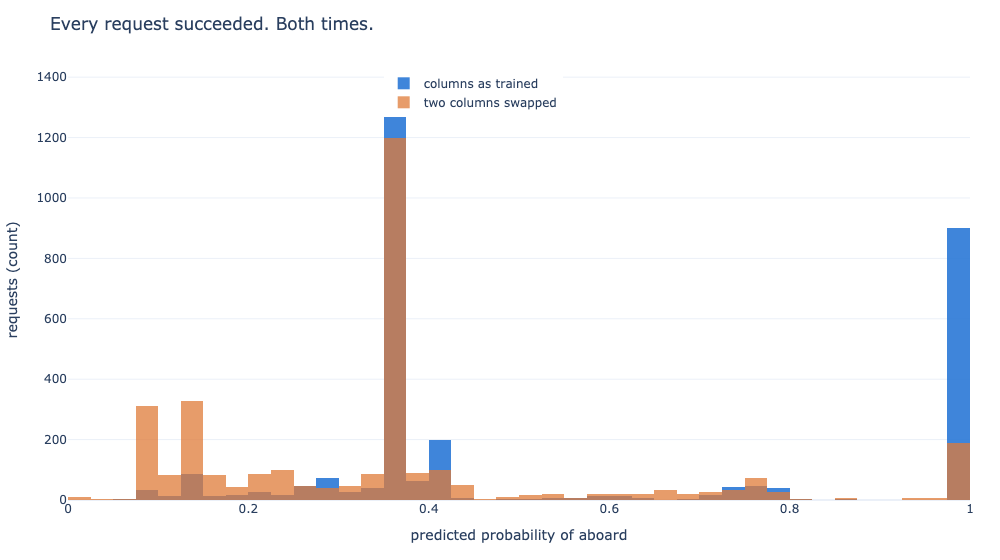

In [164]:
# Source: Module 3/exercises/solutions/lab_04.py — demonstration, paragraph 6 of 10, verbatim

# The histograms, from the same two paths the report measured.
prepared = np.column_stack([
    ((test[f].astype(float).fillna(transform["medians"][f]) - transform["means"][f])
     / transform["stds"][f]).to_numpy() for f in FEATURES])
before = artefact["model"].predict_proba(prepared)[:, 1]
swapped = prepared.copy()
swapped[:, [0, 1]] = swapped[:, [1, 0]]
after = artefact["model"].predict_proba(swapped)[:, 1]
fig = go.Figure()
edges = np.linspace(0, 1, 41)
fig.add_trace(go.Histogram(x=before, xbins=dict(start=0, end=1, size=0.025),
                           name="columns as trained", marker_color="#2A78D6", opacity=0.9))
fig.add_trace(go.Histogram(x=after, xbins=dict(start=0, end=1, size=0.025),
                           name="two columns swapped", marker_color="#E07B39", opacity=0.75))
fig.update_layout(barmode="overlay", title="Every request succeeded. Both times.",
                  xaxis_title="predicted probability of aboard",
                  yaxis_title="requests (count)", legend=dict(x=0.35, y=0.98))
save_figure(fig, "skew_histograms", LAB, logger=say)

**Goal.** Apply the platform's cure: ask the registered model by name.

**Why.** The registered model knows its columns by name, so it can reorder a request or refuse it.

**What the code does.** Loads `models:/aboard@champion`, prints its signature, and asks it about the reversed request, a request with rssiC renamed, and one with rssi1 missing.

**So what.** The reversed request gets the right probability; the renamed and the missing column are refused (`None`, which the service turns into a 422).

In [165]:
# Source: Module 3/exercises/solutions/lab_04.py — demonstration, paragraph 7 of 10, verbatim

# The platform's cure.
registered = load_registered(CHAMPION)
say.info("loaded models:/aboard@%s from the module's MLflow store; its signature: %s",
         CHAMPION, registered.metadata.get_input_schema().input_names())
say.info("registered model, keys reversed  -> %.4f (reordered by name; equals the "
         "correctly prepared pickle path %.4f)", ask_registered(reversed_keys, registered), right)
renamed = {("rssi_c" if f == "rssiC" else f): v for f, v in natural.items()}
say.info("registered model, rssiC renamed  -> %s (refused: MlflowException, failed to "
         "enforce schema; the service returns 422)", ask_registered(renamed, registered))
missing = {f: v for f, v in natural.items() if f != "rssi1"}
say.info("registered model, rssi1 missing  -> %s (refused: every feature is a required "
         "column; an absent value inside a present column is what the median fills)",
         ask_registered(missing, registered))

 19.89s  lab 4  loaded models:/aboard@champion from the module's MLflow store; its signature: ['speed', 'rssi1', 'rssi2', 'rssiC']


 19.89s  lab 4  registered model, keys reversed  -> 0.1400 (reordered by name; equals the correctly prepared pickle path 0.1400)


 19.90s  lab 4  registered model, rssiC renamed  -> None (refused: MlflowException, failed to enforce schema; the service returns 422)


 19.90s  lab 4  registered model, rssi1 missing  -> None (refused: every feature is a required column; an absent value inside a present column is what the median fills)


**Goal.** Measure honest speed on this machine.

**Why.** A latency is reported by nearest rank, so each percentile is a duration that happened.

**What the code does.** Times 200 single requests to the champion in milliseconds, prints the mean and the 50th, 95th and 99th percentiles, repeats the textbook case of 94 fast and 6 slow requests, and draws the sorted durations with the percentiles marked.

**So what.** The durations change from run to run — they belong on no slide; the textbook case gives a mean of 69.4 ms and a 95th percentile of 1,000 ms.

 20.70s  lab 4  200 single requests to the champion on this machine, today (not a slide number): mean 3.94 ms, median 3.83 ms, 95th percentile 4.85 ms, 99th 5.75 ms — nearest rank, so each is a duration that happened


 20.70s  lab 4  the textbook case, 94 requests at 10 ms and 6 at 1000 ms: mean 69.4 ms (describes nobody), 95th percentile 1000 ms (one request in twenty is at least this slow)


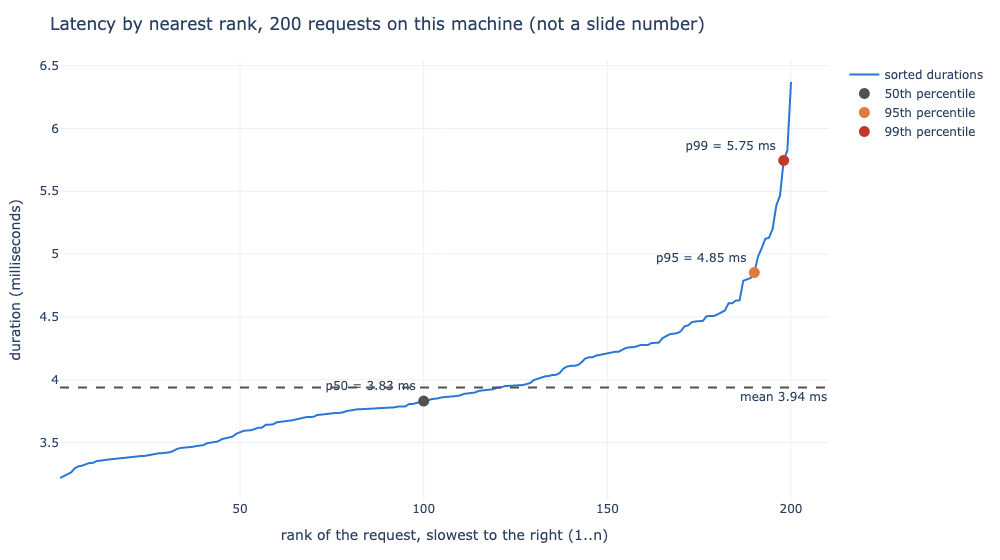

In [166]:
# Source: Module 3/exercises/solutions/lab_04.py — demonstration, paragraph 8 of 10, verbatim

# Honest speed: nearest rank on durations that happened, on this machine.
durations = []
for index in range(200):
    row = prepared[index % len(prepared)].reshape(1, -1)
    start = time.perf_counter()
    artefact["model"].predict_proba(row)
    durations.append((time.perf_counter() - start) * 1000)
say.info("200 single requests to the champion on this machine, today (not a slide "
         "number): mean %.2f ms, median %.2f ms, 95th percentile %.2f ms, 99th %.2f ms — "
         "nearest rank, so each is a duration that happened", float(np.mean(durations)),
         percentile_latency(durations, 50), percentile_latency(durations, 95),
         percentile_latency(durations, 99))
tail = [10.0] * 94 + [1000.0] * 6
say.info("the textbook case, 94 requests at 10 ms and 6 at 1000 ms: mean %.1f ms "
         "(describes nobody), 95th percentile %.0f ms (one request in twenty is at least "
         "this slow)", float(np.mean(tail)), percentile_latency(tail, 95))
ordered = sorted(durations)
fig = go.Figure()
fig.add_trace(go.Scatter(x=list(range(1, len(ordered) + 1)), y=ordered, mode="lines",
                         name="sorted durations", line=dict(color="#2A78D6")))
for p, colour in ((50, "#52514E"), (95, "#E07B39"), (99, "#C0392B")):
    rank = max(1, math.ceil(p / 100 * len(ordered)))
    fig.add_trace(go.Scatter(x=[rank], y=[ordered[rank - 1]], mode="markers+text",
                             text=[f"p{p} = {ordered[rank - 1]:.2f} ms"], textposition="top left",
                             marker=dict(color=colour, size=11), name=f"{p}th percentile"))
fig.add_hline(y=float(np.mean(durations)), line_dash="dash", line_color="#52514E",
              annotation_text=f"mean {np.mean(durations):.2f} ms", annotation_position="bottom right")
fig.update_layout(title="Latency by nearest rank, 200 requests on this machine (not a slide number)",
                  xaxis_title="rank of the request, slowest to the right (1..n)",
                  yaxis_title="duration (milliseconds)")
save_figure(fig, "latency_percentiles", LAB, logger=say)

**Goal.** Prove the batch path is the request path.

**Why.** Two implementations of one preparation are two things to keep correct.

**What the code does.** Answers the whole test period with `batch_predict`, and again one request at a time through `prepare()`, and prints the largest difference and the two means.

**So what.** A difference of nought over 3,241 rows.

In [167]:
# Source: Module 3/exercises/solutions/lab_04.py — demonstration, paragraph 9 of 10, verbatim

# One preparation, two paths.
batch = batch_predict(test, artefact)
single = np.asarray([float(artefact["model"].predict_proba(prepare(
    {f: (float(r[f]) if r[f] == r[f] else None) for f in FEATURES}, transform))[0][1])
    for _, r in test.iterrows()])
say.info("batch path against request path over %d rows: largest difference %.2e "
         "(one implementation of the preparation, used twice)", len(test),
         float(np.max(np.abs(batch - single))))
show_table(pd.DataFrame({"path": ["request, one row at a time", "batch, whole table"],
                         "mean probability": [single.mean(), batch.mean()],
                         "rows": [len(single), len(batch)]}), "the two paths", logger=say)

 33.81s  lab 4  batch path against request path over 3241 rows: largest difference 0.00e+00 (one implementation of the preparation, used twice)


 33.82s  lab 4  --- the two paths (2 rows) ---


 33.82s  lab 4                               path  mean probability  rows


 33.82s  lab 4      0  request, one row at a time            0.5665  3241


 33.82s  lab 4      1          batch, whole table            0.5665  3241


**Goal.** Say what the check grades.

**Why.** A student should know what a pass means before running the check.

**What the code does.** Prints the solution's one-line summary of the check's requirements.

**So what.** Nothing is computed here.

In [168]:
# Source: Module 3/exercises/solutions/lab_04.py — demonstration, paragraph 10 of 10, verbatim

say.info("what the check grades: the caused skew measured to the check's own arithmetic, "
         "no failed requests and exactly nought changed after the cure; prepare() "
         "identical for reversed keys and filled from the "
         "stored median; nearest-rank percentiles at 50, 90, 95, 99, 100; batch equals "
         "request within 1e-9; the pickle accepts the swapped row and answers wrongly, "
         "the registered model answers the reversed request rightly and refuses the "
         "renamed column")

 33.82s  lab 4  what the check grades: the caused skew measured to the check's own arithmetic, no failed requests and exactly nought changed after the cure; prepare() identical for reversed keys and filled from the stored median; nearest-rank percentiles at 50, 90, 95, 99, 100; batch equals request within 1e-9; the pickle accepts the swapped row and answers wrongly, the registered model answers the reversed request rightly and refuses the renamed column


## One request through the whole day

*Slides: "One request travels through the whole day in seven steps", "The same request ends with a priced decision and a signed answer" and "Three kinds of bias were met today, and two are still ahead".*

**Goal.** Follow one request — speed 1.2 metres per second and three signal strengths — through the four blocks.

**Why.** Four blocks, one request, and about forty lines of code: the door, the stored preparation, the registry's version, the priced cutoff and the signed answer.

**What the code does.** Checks the request at the door, refuses it with one field absent, answers it with one signal strength empty, and answers it in full at 0.2 and at 0.5.

**So what.** At 0.2 it is aboard; at one half the same request would answer not aboard, and a passenger would wait. Months later, a complaint about this answer is settled by reading the answer itself.

In [169]:
print("1-2. at the door:", validate(GOOD_REQUEST) or "no complaint")
print("3.   rssi1 absent:", respond({k: v for k, v in GOOD_REQUEST.items() if k != "rssi1"}, CONTRACT, SERVED, 0.2)["status"],
      "  rssi1 empty:", respond({**GOOD_REQUEST, "rssi1": None}, CONTRACT, SERVED, 0.2)["status"])
print("4-5. prepared in the stored order:", [round(v, 4) for v in prepare(GOOD_REQUEST, SERVED["transform"])[0]])
answer_priced = respond(GOOD_REQUEST, CONTRACT, SERVED, 0.2)
answer_half = respond(GOOD_REQUEST, CONTRACT, SERVED, 0.5)
print("6-7. the signed answer:", answer_priced)
print("     at one half:      ", answer_half)
assert answer_priced["decision"] == "aboard" and answer_half["decision"] == "not aboard"

1-2. at the door: no complaint
3.   rssi1 absent: 422   rssi1 empty: 200
4-5. prepared in the stored order: [-0.1197, 0.2643, -0.5906, 0.1319]
6-7. the signed answer: {'status': 200, 'probability': 0.457884, 'decision': 'aboard', 'model_version': 'v1', 'threshold': 0.2}
     at one half:       {'status': 200, 'probability': 0.457884, 'decision': 'not aboard', 'model_version': 'v1', 'threshold': 0.5}


**Goal.** Recompute the numbers of the bias table.

**Why.** Bias here is a systematic error, one that leans the same way every time: the inherited cutoff (modelling), the accuracy that picks the wrong cutoff (evaluation), and the same model prepared two ways (deployment). Dataset shift and feedback loops are Modules 4 and 5.

**What the code does.** Checks the three measurements the slide prints against the values computed above.

**So what.** 22.6 per cent, 0.818 against 0.5261, 27.1 per cent.

In [170]:
agrees("modelling: saved by the priced cutoff, per cent", 100 * (1 - COST_PRICED / COST_HALF), 22.6, 1)
agrees("evaluation: accuracy at 0.5", ((P_TEST >= 0.5).astype(int) == Y_TEST).mean(), 0.818, 3)
agrees("evaluation: accuracy at 0.2", ((P_TEST >= 0.2).astype(int) == Y_TEST).mean(), 0.5261, 4)
agrees("deployment: decisions changed by the swap, per cent", 100 * (before_swap != after_swap).mean(), 27.1, 1)

  modelling: saved by the priced cutoff, per cent                    deck 22.6       computed 22.6
  evaluation: accuracy at 0.5                                        deck 0.818      computed 0.818
  evaluation: accuracy at 0.2                                        deck 0.5261     computed 0.5261
  deployment: decisions changed by the swap, per cent                deck 27.1       computed 27.1


## Two articles of the AI Act, built for other reasons

*Slides: "Two Artificial Intelligence Act articles were built today, for other
reasons" and "Compliance is not claimed, and the duty is deferred to December 2027".*

- **Article 12, record-keeping** — events recorded automatically over the lifetime
  of the system, so its working can be traced (Regulation (EU) 2024/1689, Art. 12). Built today: the
  training record of Block one and the history that is only ever added to.
- **Article 14, human oversight** — a person can oversee the system, understand its
  answer, and step in or stop it (Regulation (EU) 2024/1689, Art. 14). Built today: the approved
  entry and the rollback, rehearsed at every ordinary release.
- **Supporting both** — the version and the cutoff carried in the body of every
  answer.

Whether this service is high-risk depends on what it is used for, not on how it is
built; Annex III lists the uses that carry the duty. The Annex III duties were to
apply from 2 August 2026 and were deferred to 2 December 2027 by the Digital Omnibus
(Regulation (EU) 2026/1744). The deferral changes when the duties apply, not what they require.
*This is the text of the Regulation, not legal advice.*

## What you can now do

*Slide: "What you can now do".* Release a model by changing one entry, and roll back
with the same move. Refuse an impossible request before the model is asked, and name
the field. Derive a cutoff from the two prices, and defend it against one half. Cause
training–serving skew, see that nothing reports an error, and then cure it. Required
reading: Sculley et al. (2015).

---
# Appendices

The decks' three appendices (identical in 3.1 and 3.2). The first, on calibration, was worked at the end of Block three.

### Appendix — where z comes from, and when one tail is enough

*Slides: "Appendix — where z comes from, and when one tail is enough" (3.1 and 3.2).*

**Goal.** Derive z as a quantile of the standard normal, and show that a two-sided 95 per cent interval is a one-sided 97.5 per cent bound.

**Why.** Repeat a measurement many times and the results pile up in a bell around the true value; z counts standard errors from the centre. Choose the coverage first, then read z off the curve (Wilson, 1927; Brown, Cai & DasGupta, 2001).

**What the code does.** Writes the margin and the quantile definition in sympy, and evaluates the normal quantile function at the levels the appendix names.

**So what.** 1.645 at 90 per cent two-sided (or 95 one-sided), 1.96 at 95, 2.576 at 99. Fix the direction before the scores are seen: choosing after the fact is a two-sided error rate in disguise.

In [171]:
alpha_ = sp.Symbol(r"\alpha", positive=True)
Phi_inverse = sp.Function(r"\Phi^{-1}")
formula(sp.Eq(sp.Symbol(r"\mathrm{margin}"), sp.Symbol("z") * sp.Symbol(r"\mathrm{SE}")),
        sp.Eq(sp.Symbol(r"z_{\text{two-sided}}"), Phi_inverse(1 - alpha_ / 2)),
        sp.Eq(sp.Symbol(r"z_{\text{one-sided}}"), Phi_inverse(1 - alpha_)))
agrees("90 per cent, two-sided", stats.norm.ppf(0.95), 1.645, 3)
agrees("95 per cent, two-sided", stats.norm.ppf(0.975), 1.96, 2)
agrees("99 per cent, two-sided", stats.norm.ppf(0.995), 2.576, 3)
agrees("95 per cent, one-sided", stats.norm.ppf(0.95), 1.645, 3)
print("a two-sided 95 % interval is a one-sided 97.5 % bound: z =", round(stats.norm.ppf(0.975), 3))

<IPython.core.display.Math object>

  90 per cent, two-sided                                             deck 1.645      computed 1.645
  95 per cent, two-sided                                             deck 1.96       computed 1.96
  99 per cent, two-sided                                             deck 2.576      computed 2.576
  95 per cent, one-sided                                             deck 1.645      computed 1.645
a two-sided 95 % interval is a one-sided 97.5 % bound: z = 1.96


### Appendix — the input contract in full

*Slides: "Appendix — the input contract in full" (3.1 and 3.2).* Twenty rules across four fields; every refusal in Lab 2 names exactly one cell of this table.

**Goal.** Print the contract as the appendix tabulates it, from the dictionary Lab 2 enforces.

**Why.** A table typed onto a slide can drift from the code; one printed from the code cannot.

**What the code does.** Builds the table from `CONTRACT`.

**So what.** Speed present and never empty, −4.361 to 4.555 metres per second; the three signal strengths present, possibly empty, −120 to 0 decibel-milliwatts.

In [172]:
display(pd.DataFrame([{"field": field, "must be present": "yes" if rule["required"] else "no",
                       "may be empty": "yes" if rule["nullable"] else "no", "type": rule["type"],
                       "accepted range": f"{rule['min']:g} to {rule['max']:g}", "unit": rule["units"]}
                      for field, rule in CONTRACT.items()]).set_index("field"))

,must be present,may be empty,type,accepted range,unit
field,,,,,
speed,yes,no,number,-4.361 to 4.555,"metres per second, signed"
rssi1,yes,yes,number,-120 to 0,decibel-milliwatts
rssi2,yes,yes,number,-120 to 0,decibel-milliwatts
rssiC,yes,yes,number,-120 to 0,decibel-milliwatts


---
## Practice

1. **Would a cost-of-serving gate change the decision?** Add a second rule to
   `promote_if_better`: refuse a candidate that does more than twice the approved
   model's work per request. Success criterion: v2 is refused, and your reason names
   both numbers. (Work, not wall-clock latency, so that the answer is the same on
   every machine.)
2. **How wrong can the prices be?** Sweep the cost ratio C_FN : C_FP over 1, 2, 3, 4,
   8 and 20, derive the cutoff for each, and compare its realised cost with one half's.
   Success criterion: you can name the ratios where the derivation loses, and say why
   — look at the reliability diagram again. (This is the hidden stress-test slide of
   3.1.)
3. **Which column swap hurts most?** Swap each pair of the four features in turn and
   measure the accuracy at the priced cutoff. Success criterion: a table of six pairs
   ordered by damage, and one sentence on why the worst pair is the worst.

Answers below — try first.

**Goal.** Leave room for your own attempt.

**Why.** The answers follow directly below; an attempt made first is worth more than one made after reading them.

**What the code does.** Nothing: an empty cell with a comment.

**So what.** Write your workings here, with the functions defined above.

In [173]:
# Your workings here.

### Answers

**Goal.** Answer the three questions with the functions defined above.

**Why.** Each answer is a measurement, so it is computed rather than asserted.

**What the code does.** 1: compares the two versions' decision nodes per request. 2: for each ratio, prices the derived cutoff and one half on the test rows — a tie is not a win, exactly as in the gate. 3: swaps each pair of prepared columns and measures accuracy at 0.2.

**So what.** v2 does 17.7 times the work and is refused. The derivation wins at three ratios, ties at one and loses at two — at the ratio 2 it costs 1,538 where one half costs 1,078 — because the model's probabilities are inflated and the derived cutoff trusts them. The worst swap puts a signal strength where speed belongs: speed is the feature the forest leans on most.

In [174]:
# 1. A cost-of-serving gate refuses v2 as well.
work = {v: WORK_PER_REQUEST[v]["decision_nodes_per_request"] for v in ("v1", "v2")}
print(f"v1 {work['v1']} nodes per request, v2 {work['v2']}: "
      f"{'refused' if work['v2'] > 2 * work['v1'] else 'allowed'} by a two-times work rule")

# 2. The derived cutoff against one half, at six prices of a miss.
recorded = json.loads((SLIDES / "measured.json").read_text())["derived_against_habit"]["value"]
outcome = {"win": 0, "tie": 0, "loss": 0}
print("\nratio   cutoff   cost derived   cost at 0.5   result")
for ratio in (1, 2, 3, 4, 8, 20):
    derived = threshold_from_costs(1.0, ratio)
    mine, habit = (realised_cost(P_TEST, Y_TEST, t, 1.0, ratio) for t in (derived, 0.5))
    result = "win" if mine < habit else ("tie" if mine == habit else "loss")
    outcome[result] += 1
    print(f"1:{ratio:<5} {derived:7.3f} {mine:14,.0f} {habit:13,.0f}   {result}")
    assert (mine, habit) == (recorded[f"1:{ratio}"]["cost_derived"], recorded[f"1:{ratio}"]["cost_at_half"])
print("wins, ties, losses:", outcome, "- as slides/measured.json records them")

# 3. The six swaps, ordered by the accuracy left.
damage = []
for first in range(len(FEATURES)):
    for second in range(first + 1, len(FEATURES)):
        variant = X_TEST.copy()
        variant[:, [first, second]] = variant[:, [second, first]]
        accuracy = float(((ARTEFACT_V1["model"].predict_proba(variant)[:, 1] >= PRICED).astype(int) == Y_TEST).mean())
        damage.append((f"{FEATURES[first]} <-> {FEATURES[second]}", round(accuracy, 4)))
print()
display(pd.DataFrame(sorted(damage, key=lambda item: item[1]), columns=["swapped pair", "accuracy at 0.2"])
        .set_index("swapped pair"))
print(f"no swap: {((P_TEST >= PRICED).astype(int) == Y_TEST).mean():.4f}")
print("importance of each feature in the forest:",
      {name: round(float(value), 3) for name, value in zip(FEATURES, ARTEFACT_V1["model"].feature_importances_)})

v1 575.4 nodes per request, v2 10165.1: refused by a two-times work rule

ratio   cutoff   cost derived   cost at 0.5   result
1:1       0.500            590           590   tie
1:2       0.333          1,538         1,078   loss
1:3       0.250          1,578         1,566   loss
1:4       0.200          1,590         2,054   win
1:8       0.111          1,626         4,006   win
1:20      0.048          1,663         9,862   win
wins, ties, losses: {'win': 3, 'tie': 1, 'loss': 2} - as slides/measured.json records them



,accuracy at 0.2
swapped pair,
speed <-> rssi1,0.4428
speed <-> rssi2,0.4604
speed <-> rssiC,0.4674
rssi1 <-> rssi2,0.5122
rssi1 <-> rssiC,0.5443
rssi2 <-> rssiC,0.5643


no swap: 0.5261
importance of each feature in the forest: {'speed': 0.805, 'rssi1': 0.038, 'rssi2': 0.087, 'rssiC': 0.071}


### On the stand-in

Everything in Parts 3.1 and 3.2 ran against two forests trained in seconds from the
generated table. That is deliberate, and it is the argument for release by
indirection: the service, the contract, the cutoff and the skew are indifferent to
which model sits behind the name. When the modelling sessions hand over an artefact,
it goes into `service/artefacts/`, the pointer and the alias move, and every number
in this notebook changes while not one line of it does.

**Goal.** Remove the working copy.

**Why.** It holds two trained forests, two MLflow stores and a 95-megabyte candidate three times over — several hundred megabytes nobody needs once the notebook has run.

**What the code does.** Moves back to `exercises/` and deletes the temporary folder made at the start.

**So what.** Your `exercises/` folder is as you left it, and nothing is left behind.

In [175]:
os.chdir(SOURCE)
shutil.rmtree(WORK.parent)
print("working copy removed:", not WORK.exists())

working copy removed: True


---
## Where this notebook and the slides differ, and why

The slides are the master and are not changed. Where a number computed here does
not match the number a slide prints, the notebook printed both at that point, with
the reason. The table gathers every one of them, as they were printed in this run.

Differences in wording and labels, which the table cannot hold:

- **3.0, slides 13 and 15**: slide 13 reads "10,000 receipts a day", slide 15
  "N = 10,000 receipts per week". The notebook takes both examples as the slides give
  them: slide 13's stock as a count per 10,000 receipts, whatever the period, and slide
  15's margin for 10,000 receipts per week. The simulation behind them averages about
  1,726 receipts a day; its own layout example, at that volume, is printed beside
  slide 15's.
- **3.1, slides 20–24** (and the Lab 1 and Lab 4 docstrings): the registry, aliases
  and signatures are credited to Zaharia et al. (2018), a paper that describes
  MLflow's tracking, projects and models components only. The notebook cites it for
  the run record alone.
- **3.1, slide 34**: the drawn caption says "candidate ≥ in service + δ"; the gate's
  definition, the lab and the check use ">", so a tie is refused.
- **3.1, slide 41**: the text says "z for 1 − 0.05/C" but prints 2.58 for C = 5, which
  is the two-sided quantile for 1 − 0.05/(2C); the one-sided value is 2.33.
- **3.1, slide 62**: the derivation ends "p > C_fp/(C_fp + C_fn) = t", while the
  definition card, Lab 3, its check and the figures decide aboard when p ≥ t; at
  equality both answers cost the same.
- **3.2, slide 12**: "Slide 74 shows this spread" points to a slide number of an
  earlier deck; the spread is drawn on this deck's skew figure (slides 7–8).
- **3.2, slides 19 and 21**: the two constructed bells of covariate shift are replaced
  by the size of the vehicle's speed on the two days, a stand-in for the model's
  feature: in the generated phone traces the model's own `speed` does not shift.
- **3.2, slide 21**: the names "label shift" and "concept shift" follow Moreno-Torres et
  al. (2012); Storkey's chapter, cited beside them, calls the first prior probability
  shift and has no name for the second.
- **3.2, slide 22**: "~1,450 req/s" divides 100 by the mean time of one request;
  served one after another, the 100 requests run at the rate the latency cell prints.
- Several sources named in the slide text (Moreno-Torres et al., 2012; Savage, 2009;
  Goodman, 1965; Student, 1908) are missing from the decks' reference slides.

**Goal.** Gather every number this notebook printed beside a slide's number.

**Why.** A reader should find every difference between the notebook and the slides in one place, with its reason, without searching the notebook.

**What the code does.** Tabulates what each `beside()` call recorded during this run: the quantity, the value computed here, the value on the slide or in the archive, and why they differ.

**So what.** Every row is explained where it first appears; none of them is a change to the slides.

In [176]:
with pd.option_context("display.max_colwidth", None):     # the reasons, in full
    display(pd.DataFrame(DIFFERENCES, columns=["quantity", "computed here",
                                               "the slide or the archive", "why they differ"]))

,quantity,computed here,the slide or the archive,why they differ
0,"the simulation's own layout example (measured_3.0.json, not on a slide): margin per day, far and near","6,213 and 6,233 DKK, gain 20 DKK","N = 10,000 per week","that example uses the simulation's 1,726 receipts a day, beer as well as diapers, and a hypothesised 10 % rise in parents' beer; the slide's example is diapers only"
1,rows in the vehicle file,"48,290 rows, 22 columns, 1 vehicle","53,155 rows and 22 columns from 2 vehicles","the slide counts the archive's bus file, which is not shipped; the labs ship the slice of one vehicle, and the route box is the same"
2,"rows carrying a label on 2020-01-22, per cent",100.0 (generated phones),"100.0 (archive, Module 2's measured.json)",make_phones.py labels every row it generates; only the archive lacks the second day's labels
3,"rows carrying a label on 2020-01-23, per cent",100.0 (generated phones),"0.0 (archive, Module 2's measured.json)",make_phones.py labels every row it generates; only the archive lacks the second day's labels
4,"candidate, V and C at the slide's prices (10^5 and 10^4 euro)",4.58 and 12.17,4.28 and 16.2,"the slide adds latency and size penalties, and more development hours, that it does not state"
5,slope of the slide's dashed line,0.109 (10^5 € per 10^4 €),0.100 for equal V − C,the dashed line ends at 8.05 where equal net benefit gives 7.90; it misses tuned boosting by 0.05 × 10^5 €
6,the rule the slide's drawn caption states,"candidate > in service + δ (definition, lab, check)",candidate ≥ in service + δ,"a slip in the drawing; with δ = 0 the '≥' would promote a tie, which the definition card and Lab 1 refuse"
7,z for five classes,2.326 at 1 − 0.05/C; 2.576 at 1 − 0.05/(2C),2.58 'for 1 − 0.05/C',the slide's number is the two-sided Bonferroni quantile; its formula in words is the one-sided one
8,the decision rule at the boundary,"p ≥ t* (definition card, Lab 3, check, figures)",p > t* (last line of the derivation slide),the derivation's strict inequality; Elkan (2001) notes either class is optimal at equality
9,share of test rows in that band,"169 of 3,241 = 1 in 19",1 in 5,"the slide's proportion does not match the band's row count; the 1,678 rows of the band 0.2 to 0.4 are the ones near one in two"


## References

- Abadie, A., Diamond, A. & Hainmueller, J. (2010). Synthetic control methods for comparative case studies. Journal of the American Statistical Association 105(490), 493–505. — *not in the course's literature folders; cited as the deck cites it*
- Agrawal, R., Imieliński, T. & Swami, A. (1993). Mining association rules between sets of items in large databases. Proc. ACM SIGMOD, 207–216. — *not in the course's literature folders; cited as the deck cites it*
- Arrow, K. J., Harris, T. & Marschak, J. (1951). Optimal inventory policy. Econometrica 19(3), 250–272. — *checked against* `Module 3/literature/arrow1951.pdf`, § 3, a static model with uncertainty
- Box, G. E. P. & Tiao, G. C. (1975). Intervention analysis with applications to economic and environmental problems. Journal of the American Statistical Association 70(349), 70–79. — *not in the course's literature folders; cited as the deck cites it*
- Breck, E., Polyzotis, N., Roy, S., Whang, S. E. & Zinkevich, M. (2019). Data validation for machine learning. Proceedings of Machine Learning and Systems 1. — *checked against* `Module 3/literature/MLSys-2019-data-validation-for-machine-learning-Paper.pdf`, § 3, single-batch validation against a schema; § 4, training–serving skew, whose most common cause is different code paths for training and serving data
- Brin, S., Motwani, R. & Silverstein, C. (1997). Beyond market baskets: generalizing association rules to correlations. Proc. ACM SIGMOD, 265–276. — *not in the course's literature folders; cited as the deck cites it*
- Brown, L. D., Cai, T. T. & DasGupta, A. (2001). Interval estimation for a binomial proportion. Statistical Science 16(2), 101–133. — *checked against* `Module 4/literature/brown2001.pdf`, abstract and § 2: the erratic coverage of the standard interval
- Card, D. & Krueger, A. B. (1994). Minimum wages and employment: a case study of the fast-food industry in New Jersey and Pennsylvania. American Economic Review 84(4), 772–793. — *not in the course's literature folders; cited as the deck cites it*
- Dean, J. & Barroso, L. A. (2013). The tail at scale. Communications of the ACM 56(2), 74–80. — *checked against* `Module 3/literature/dean2013.pdf`, tail latency: the 99th-percentile examples on the first pages
- DeGroot, M. H. & Fienberg, S. E. (1983). The comparison and evaluation of forecasters. The Statistician 32(1/2), 12–22. — *checked against* `Module 3/literature/degroot1983.pdf`, § 2, calibration: well calibrated if, among the days the prediction is x, the long-run relative frequency is also x
- Donoho, D. (2017). 50 years of data science. Journal of Computational and Graphical Statistics 26(4), 745–766. — *not in the course's literature folders; cited as the deck cites it*
- Drèze, X., Hoch, S. J. & Purk, M. E. (1994). Shelf management and space elasticity. Journal of Retailing 70(4), 301–326. — *not in the course's literature folders; cited as the deck cites it*
- Efron, B. (1979). Bootstrap methods: another look at the jackknife. The Annals of Statistics 7(1), 1–26. — *checked against* `Module 4/literature/efron1979.pdf`
- Elkan, C. (2001). The foundations of cost-sensitive learning. Proceedings of the 17th International Joint Conference on Artificial Intelligence, 973–978. — *checked against* `Module 3/literature/Elkan-2001-Cost-Sensitive-Learning.pdf`, § 1.3, making optimal decisions: predict class 1 iff its expected cost is no greater; at equality either class is optimal
- Fielding, R., Nottingham, M. & Reschke, J. (2022). HTTP Semantics. RFC 9110, IETF, §§ 15.5.1, 15.5.21, 15.6.1. — *not in the course's literature folders; cited as the deck cites it*
- Glass, G. V. (1976). Primary, secondary, and meta-analysis of research. Educational Researcher 5(10), 3–8. — *checked against* `Module 4/literature/glass1976.pdf`
- Goodman, L. A. (1965). On simultaneous confidence intervals for multinomial proportions. Technometrics 7(2), 247–254. — *not in the course's literature folders; cited as the deck cites it*
- Guo, C., Pleiss, G., Sun, Y. & Weinberger, K. Q. (2017). On calibration of modern neural networks. Proceedings of ICML. — *not in the course's literature folders; cited as the deck cites it*
- Hand, D. J., Mannila, H. & Smyth, P. (2001). Principles of Data Mining. MIT Press. — *not in the course's literature folders; cited as the deck cites it*
- Henrich, J., Heine, S. J. & Norenzayan, A. (2010). The weirdest people in the world? Behavioral and Brain Sciences 33(2–3), 61–83. — *not in the course's literature folders; cited as the deck cites it*
- Huyen, C. (2022). Designing Machine Learning Systems. O'Reilly. The deck cites ch. 7. — *checked against* `Module 1/literature/Huyen-2022-Designing-ML-Systems-EarlyRelease.pdf`, the early release held in the folder, ch. 6 "Model Deployment": online and batch prediction, and fig. 6-7, two pipelines for training and inference a common source of bugs (ch. 7 of the printed edition the deck cites)
- Hyndman, R. J. & Fan, Y. (1996). Sample quantiles in statistical packages. The American Statistician 50(4), 361–365. — *checked against* `Module 3/literature/hyndman1996.pdf`, Definition 1, the inverse of the empirical distribution function
- Jensen, J. L. W. V. (1906). Sur les fonctions convexes et les inégalités entre les valeurs moyennes. Acta Mathematica 30, 175–193. — *checked against* `Module 3/literature/jensen1906.pdf`, § 1, convex and concave functions; § 2, the general inequality, formula (5)
- Kohavi, R., Tang, D. & Xu, Y. (2020). Trustworthy Online Controlled Experiments. Cambridge University Press. — *not in the course's literature folders; cited as the deck cites it*
- Kreuzberger, D., Kühl, N. & Hirschl, S. (2023). Machine learning operations (MLOps): overview, definition, and architecture. IEEE Access 11, 31866–31879. — *checked against* `Module 3/literature/Machine-Learning-Operations-MLOps-Overview-Definition-and-Architecture.pdf`, component C6, the model registry (MLflow, SageMaker and Azure ML named as examples)
- Lucas, R. E. (1976). Econometric policy evaluation: a critique. Carnegie-Rochester Conference Series on Public Policy 1, 19–46. — *not in the course's literature folders; cited as the deck cites it*
- Manchanda, P., Ansari, A. & Gupta, S. (1999). The "shopping basket": a model for multicategory purchase incidence decisions. Marketing Science 18(2), 95–114. — *not in the course's literature folders; cited as the deck cites it*
- Moreno-Torres, J. G., Raeder, T., Alaiz-Rodríguez, R., Chawla, N. V. & Herrera, F. (2012). A unifying view on dataset shift in classification. Pattern Recognition 45(1), 521–530. — *not in the course's literature folders; cited as the deck cites it*
- Niculescu-Mizil, A. & Caruana, R. (2005). Predicting good probabilities with supervised learning. Proceedings of the 22nd ICML, 625–632. — *checked against* `Module 3/literature/niculescu-mizil2005.pdf`, § 1 (good accuracy or AUC is not enough for good probabilities; Platt scaling suits a sigmoid-shaped distortion, isotonic regression any monotone one but overfits on little data), p. 625; § 2, Platt scaling and isotonic regression, fitted on an independent calibration set, pp. 625–626; § 4, reliability diagrams, p. 627; § 5, isotonic as good as Platt or better from about 1,000 calibration cases, pp. 630–631. A scanned copy, read page by page
- Pearl, J. & Bareinboim, E. (2014). External validity: from do-calculus to transportability across populations. Statistical Science 29(4), 579–595. — *not in the course's literature folders; cited as the deck cites it*
- Pearl, J. (2009). Causality: Models, Reasoning, and Inference, 2nd ed. Cambridge University Press. — *not in the course's literature folders; cited as the deck cites it*
- Pearl, J. (2014). Comment: understanding Simpson's paradox. The American Statistician 68(1), 8–13. — *checked against* `Module 2/literature/Pearl-CommentUnderstandingSimpsons-2014.pdf`, the reversal attributed to causal interpretation: which table to consult is decided by the causal story, not the data
- Platt, J. (1999). Probabilistic outputs for support vector machines and comparisons to regularized likelihood methods. In Advances in Large Margin Classifiers. MIT Press. — *not in the course's literature folders; cited as the deck cites it*
- Power, D. J. (2002). What is the "true story" about data mining, beer and diapers? DSS News 3(23), 10 November 2002. — *not in the course's literature folders; cited as the deck cites it*
- Provost, F. & Fawcett, T. (2013). Data Science for Business. O'Reilly. — *checked against* `Module 3/literature/Provost-Fawcett-2013-Data-Science-for-Business.pdf`, ch. 7, Decision Analytic Thinking I (expected value as the evaluation framework; comparative baselines); ch. 8, Visualizing Model Performance
- Regulation (EU) 2024/1689 of the European Parliament and of the Council laying down harmonised rules on artificial intelligence (Artificial Intelligence Act). Official Journal L, 12.7.2024. — *checked against* `Module 3/literature/OJ%3AL_202401689%3AEN%3ATXT.pdf`, Article 12 (record-keeping: automatic recording of events over the lifetime of the system) and Article 14 (human oversight)
- Regulation (EU) 2026/1744 of the European Parliament and of the Council of 8 July 2026 amending Regulations (EU) 2024/1689, (EU) 2018/1139 and (EU) 2023/1230 (Digital Omnibus on AI). Official Journal L, 24.7.2026. — *checked against* `Module 3/literature/OJ%3AL_202601744%3AEN%3ATXT.pdf`, the application of Chapter III to high-risk AI systems under Article 6(2) and Annex III set to 2 December 2027
- Rich, D. (2020). Jensen's Inequality. Mutual Information, video lecture. https://youtu.be/u0_X2hX6DWE — *checked against* `Module 3/literature/Jensen's Inequality.txt`, the transcript held in the folder
- Savage, S. L. (2009). The Flaw of Averages. Wiley. — *not in the course's literature folders; cited as the deck cites it*
- Schelter, S., Biessmann, F., Januschowski, T., Salinas, D., Seufert, S. & Szarvas, G. (2018). On challenges in machine learning model management. IEEE Data Engineering Bulletin 41(4), 5–15. — *checked against* `Module 3/literature/on-challenges-in-machine-learning-model-management.pdf`, § 2, automating model metadata tracking; § 3.2, querying model metadata and lineage
- Sculley, D., Holt, G., Golovin, D., Davydov, E., Phillips, T., Ebner, D., Chaudhary, V., Young, M., Crespo, J.-F. & Dennison, D. (2015). Hidden technical debt in machine learning systems. Advances in Neural Information Processing Systems 28. — *checked against* `Module 3/literature/Sculley-2015-Hidden-Technical-Debt.pdf`, § 2, undeclared consumers; § 7, monitoring and testing in a changing world
- Simpson, E. H. (1951). The interpretation of interaction in contingency tables. Journal of the Royal Statistical Society B 13(2), 238–241. — *checked against* `Module 2/literature/Simpson-InterpretationInteractionContingency-1951.pdf`, the 2 × 2 × 2 table and second-order interaction
- Storkey, A. (2009). When training and test sets are different: characterizing learning transfer. In Quiñonero-Candela, J., Sugiyama, M., Schwaighofer, A. & Lawrence, N. D. (eds), Dataset Shift in Machine Learning, ch. 1, 3–28. MIT Press. — *checked against* `Module 3/literature/Dataset Shift Ch. 1.pdf`, § 1.3, reasons for shift, deliberate shift (p. 7); § 1.4 simple covariate shift (p. 8); § 1.5 prior probability shift (p. 12); § 1.7 imbalanced data, shift by design (p. 16); § 1.8 domain shift, changes in measurement (p. 19; fig. 1.6, p. 20). The chapter does not use the terms concept shift or label shift. A scanned copy, read page by page
- Student (1908). The probable error of a mean. Biometrika 6(1), 1–25. — *not in the course's literature folders; cited as the deck cites it*
- Tukey, J. W. (1962). The future of data analysis. The Annals of Mathematical Statistics 33(1), 1–67. — *not in the course's literature folders; cited as the deck cites it*
- Whitehorn, M. (2006). The parable of the beer and diapers. The Register, 15 August 2006. — *not in the course's literature folders; cited as the deck cites it*
- Wilson, E. B. (1927). Probable inference, the law of succession, and statistical inference. Journal of the American Statistical Association 22(158), 209–212. — *checked against* `Module 3/literature/wilson1927.pdf`, the quadratic (p₀ − p)² = λ²pq/n and its solution with the t²/4 term
- Zadrozny, B. & Elkan, C. (2002). Transforming classifier scores into accurate multiclass probability estimates. Proceedings of KDD. — *not in the course's literature folders; cited as the deck cites it*
- Zaharia, M., Chen, A., Davidson, A., Ghodsi, A., Hong, S. A., Konwinski, A., Murching, S., Nykodym, T., Ogilvie, P., Parkhe, M., Xie, F. & Zumar, C. (2018). Accelerating the machine learning lifecycle with MLflow. IEEE Data Engineering Bulletin 41(4), 39–45. — *checked against* `Module 3/literature/p39.pdf`, § 3: MLflow Tracking, Projects and Models (flavors); the notebook cites it for the run record only. The paper predates MLflow's Model Registry, aliases and model signatures, which the deck also attributes to it